In [1]:
# ============================ scg_collapse.py ============================
# Minimal SWG/SCG-style collapse detector for qubit (IQ) traces
# - Computes windowed invariants: entropy H, curvature variance K, energy flux ΦE,
#   phase-dislocation density ρφ, alignment R.
# - Detects collapse windows via robust MAD thresholds (coarse→refined style).
# - Provides a composite early-warning risk score for live use.
#
# Public API:
#   scg_invariants(I, Q, fs, win_sec=..., step_sec=..., env_smooth_sec=...)
#   detect_collapse(inv, burn_in_sec=0.0, z_factor=2.0) -> (Detection|None, Thresholds)
#   collapse_risk_score(I, Q, fs, win_sec=..., step_sec=..., ...) -> dict
#
# Notes:
# - I, Q: numpy arrays (same length), fs: float sample rate (Hz).
# - Keep windows small (e.g., 2–10 ms) for ms-scale early warning.

from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from typing import Tuple, Dict, Optional, Iterable

# ---------- Utilities ----------
def moving_average(x: np.ndarray, n: int) -> np.ndarray:
    if n <= 1:
        return x.astype(float).copy()
    c = np.cumsum(np.insert(x.astype(float), 0, 0.0))
    out = (c[n:] - c[:-n]) / float(n)
    pad = np.full(n-1, out[0])
    return np.concatenate([pad, out])

def grad1(x: np.ndarray, dt: float) -> np.ndarray:
    g = np.empty_like(x, dtype=float)
    g[1:-1] = (x[2:] - x[:-2])/(2*dt)
    g[0] = (x[1] - x[0])/dt
    g[-1] = (x[-1] - x[-2])/dt
    return g

def windows(n: int, win_len: int, hop: int) -> Iterable[Tuple[int, int]]:
    i = 0
    while i + win_len <= n:
        yield i, i + win_len
        i += hop

def unwrap_phase(z: np.ndarray) -> np.ndarray:
    return np.unwrap(np.angle(z))

def mad_sigma(x: np.ndarray) -> Tuple[float, float]:
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return med, 1.4826 * mad

# ---------- Invariant primitives ----------
def coherence_entropy(Aw: np.ndarray, eps: float = 1e-12) -> float:
    w = Aw.astype(float) + eps
    p = w / (np.sum(w) + eps)
    return float(-np.sum(p * np.log(p + eps)))

def curvature_variance(sig: np.ndarray) -> float:
    d2 = np.diff(sig.astype(float), n=2)
    return float(np.var(d2))

def energy_flux(A: np.ndarray, dt: float) -> Tuple[float, float]:
    E = (A.astype(float))**2
    dE = grad1(E, dt)
    return float(np.mean(dE)), float(np.max(dE))

def phase_dislocation_density(theta: np.ndarray, thr_rad: float = np.pi/3) -> float:
    dtheta = np.diff(np.unwrap(theta.astype(float)))
    return float(np.mean(np.abs(dtheta) > thr_rad))

# ---------- Data classes ----------
@dataclass
class Invariants:
    t_mid: np.ndarray
    H: np.ndarray
    K: np.ndarray
    Phi_mean: np.ndarray
    Phi_max: np.ndarray
    Rho: np.ndarray
    R: np.ndarray

@dataclass
class Detection:
    t0: float
    t1: float
    mid: float

@dataclass
class Thresholds:
    H: float
    K: float
    Pm: float
    Px: float

# ---------- Core API ----------
def scg_invariants(
    I: np.ndarray,
    Q: np.ndarray,
    fs: float,
    win_sec: float = 0.010,
    step_sec: float = 0.005,
    env_smooth_sec: float = 0.002,
) -> Invariants:
    """
    Compute windowed SCG-style invariants on IQ traces.

    Parameters
    ----------
    I, Q : np.ndarray
        Real-valued I/Q time series of equal length.
    fs : float
        Sampling rate in Hz.
    win_sec, step_sec : float
        Sliding window length and hop (seconds).
    env_smooth_sec : float
        Low-pass smoothing for amplitude envelope (memory proxy χ).

    Returns
    -------
    Invariants : dataclass with time midpoints and measures (H, K, ΦE_mean, ΦE_max, ρφ, R).
    """
    assert len(I) == len(Q), "I and Q must have same length"
    z = I.astype(float) + 1j * Q.astype(float)
    A = np.abs(z)
    theta = unwrap_phase(z)
    dt = 1.0 / float(fs)

    # memory / curvature face: smoothed amplitude
    n_env = max(1, int(round(env_smooth_sec * fs)))
    chi = moving_average(A, n_env)

    n = len(A)
    win = max(4, int(round(win_sec * fs)))
    hop = max(1, int(round(step_sec * fs)))

    H_list, K_list, Pm_list, Px_list, Rho_list, R_list, t_mid = [], [], [], [], [], [], []

    for i0, i1 in windows(n, win, hop):
        Aw = A[i0:i1]
        th = theta[i0:i1]
        chiw = chi[i0:i1]

        H_list.append(coherence_entropy(Aw))
        K_list.append(curvature_variance(chiw))
        pm, px = energy_flux(Aw, dt)
        Pm_list.append(pm)
        Px_list.append(px)
        Rho_list.append(phase_dislocation_density(th, thr_rad=np.pi/3))
        R_list.append(float(np.abs(np.mean(np.exp(1j*th)))))
        t_mid.append((i0 + i1) * 0.5 * dt)

    return Invariants(
        t_mid=np.asarray(t_mid),
        H=np.asarray(H_list),
        K=np.asarray(K_list),
        Phi_mean=np.asarray(Pm_list),
        Phi_max=np.asarray(Px_list),
        Rho=np.asarray(Rho_list),
        R=np.asarray(R_list),
    )

def detect_collapse(
    inv: Invariants,
    burn_in_sec: float = 0.0,
    z_factor: float = 2.0,
) -> Tuple[Optional[Detection], Thresholds]:
    """
    Robust MAD thresholds; detect windows where:
      H <= H_thr  &  K >= K_thr  &  (ΦE_mean >= Pm_thr or ΦE_max >= Px_thr)

    Returns
    -------
    (Detection|None, Thresholds)
    """
    Hm, Hs = mad_sigma(inv.H)
    Km, Ks = mad_sigma(inv.K)
    Pmm, Pms = mad_sigma(inv.Phi_mean)
    Pxm, Pxs = mad_sigma(inv.Phi_max)

    H_thr  = Hm - z_factor * Hs
    K_thr  = Km + z_factor * Ks
    Pm_thr = Pmm + z_factor * Pms
    Px_thr = Pxm + z_factor * Pxs

    cond = (inv.H <= H_thr) & (inv.K >= K_thr) & ((inv.Phi_mean >= Pm_thr) | (inv.Phi_max >= Px_thr))
    if burn_in_sec > 0:
        cond &= (inv.t_mid >= burn_in_sec)

    idx = np.where(cond)[0]
    if len(idx) == 0:
        return None, Thresholds(H_thr, K_thr, Pm_thr, Px_thr)

    # group contiguous hits into regions
    regions = []
    s = idx[0]; p = idx[0]
    for j in idx[1:]:
        if j == p + 1:
            p = j
        else:
            regions.append((s, p))
            s = j; p = j
    regions.append((s, p))

    # select "best" region (peak curvature, tie by ΦE_max, then lowest H)
    best = None
    best_key = (-1.0, -1.0, 1e9)
    for a, b in regions:
        kmax = float(np.max(inv.K[a:b+1]))
        px   = float(np.max(inv.Phi_max[a:b+1]))
        hmin = float(np.min(inv.H[a:b+1]))
        key  = (kmax, px, -hmin)
        if key > best_key:
            best_key = key; best = (a, b)
    a, b = best
    det = Detection(t0=float(inv.t_mid[a]), t1=float(inv.t_mid[b]), mid=float(0.5*(inv.t_mid[a]+inv.t_mid[b])))
    return det, Thresholds(H_thr, K_thr, Pm_thr, Px_thr)

def collapse_risk_score(
    I: np.ndarray,
    Q: np.ndarray,
    fs: float,
    win_sec: float = 0.010,
    step_sec: float = 0.005,
    env_smooth_sec: float = 0.002,
    z_factor: float = 2.0,
) -> Dict[str, float]:
    """
    Composite early-warning risk from last window:
      risk = z(K) + z(ρφ) - z(H) + 0.5*z(ΦE_mean)
    where z(·) are robust MAD-z transforms.

    Returns dict with risk, last-window invariants, thresholds, and any collapse window.
    """
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    H, K, Pm, Rho = inv.H, inv.K, inv.Phi_mean, inv.Rho

    def zmad(x):
        m, s = mad_sigma(x)
        s = s if s > 1e-12 else 1.0
        return (x - m) / s

    zH, zK, zPm, zRho = zmad(H), zmad(K), zmad(Pm), zmad(Rho)
    risk_series = zK + zRho - zH + 0.5 * zPm
    risk = float(risk_series[-1])

    det, thr = detect_collapse(inv, burn_in_sec=0.0, z_factor=z_factor)
    return dict(
        risk=risk,
        t=float(inv.t_mid[-1]),
        H=float(H[-1]), K=float(K[-1]), Phi_mean=float(Pm[-1]), Rho=float(Rho[-1]),
        collapse_mid=(None if det is None else det.mid),
        collapse_t0=(None if det is None else det.t0),
        collapse_t1=(None if det is None else det.t1),
        H_thr=float(thr.H), K_thr=float(thr.K), Pm_thr=float(thr.Pm), Px_thr=float(thr.Px),
    )

# ---------- Optional demo helpers (synthetic signal & quick plot) ----------
def synth_trace(
    fs: int = 100_000,
    T: float = 0.5,
    f0: float = 2_000.0,
    collapse_t: Tuple[float, float] = (0.30, 0.36),
    seed: int = 7,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Create a synthetic IQ trace with a 'collapse' segment for testing.
    """
    rng = np.random.default_rng(seed)
    t = np.arange(int(T*fs)) / fs
    phase = 2*np.pi*f0*t
    A = 1.0 + 0.05*rng.standard_normal(len(t))

    c0, c1 = collapse_t
    mask_c = (t >= c0) & (t <= c1)

    # amplitude peaking then narrowing
    A[mask_c] *= 1.0 + 2.0 * np.hanning(mask_c.sum())

    # phase jitter during collapse (drives curvature/dislocations)
    jitter = np.zeros_like(t)
    jitter[mask_c] = 0.15 * np.cumsum(rng.standard_normal(mask_c.sum())) / fs
    phase = phase + jitter

    # post-collapse ringdown
    post = (t > c1)
    A[post] *= 1.0 - 0.3*np.exp(- (t[post]-c1) * 500)

    I = A * np.cos(phase) + 0.02*rng.standard_normal(len(t))
    Q = A * np.sin(phase) + 0.02*rng.standard_normal(len(t))
    return t, I, Q

def _plot_demo(t, I, Q, inv: Invariants, det: Optional[Detection], thr: Thresholds):
    try:
        import matplotlib.pyplot as plt
    except Exception:
        return
    A = np.sqrt(I**2 + Q**2)

    # 1) amplitude with collapse window
    plt.figure(figsize=(10,3))
    plt.plot(t, A, color="#d38700")
    if det is not None:
        plt.axvspan(det.t0, det.t1, color="#d38700", alpha=0.25)
    plt.xlabel("Time (s)"); plt.ylabel("|z|"); plt.title("Amplitude with detected collapse window")
    plt.tight_layout(); plt.show()

    # 2) invariants + thresholds
    fig, axs = plt.subplots(3,1,figsize=(10,6), sharex=True)
    axs[0].plot(inv.t_mid, inv.H, color="#d38700"); axs[0].axhline(thr.H, color="#d38700", alpha=0.6)
    axs[0].set_ylabel("Entropy H")
    axs[1].plot(inv.t_mid, inv.K, color="#d38700"); axs[1].axhline(thr.K, color="#d38700", alpha=0.6)
    axs[1].set_ylabel("Curv Var K")
    axs[2].plot(inv.t_mid, inv.Phi_mean, color="#d38700"); axs[2].axhline(thr.Pm, color="#d38700", alpha=0.6)
    axs[2].set_ylabel("ΦE_mean"); axs[2].set_xlabel("Time (s)")
    plt.tight_layout(); plt.show()

# ============================ End scg_collapse.py ============================


Risk last window: -0.836
Detected collapse band: (0.335, 0.35500000000000004)


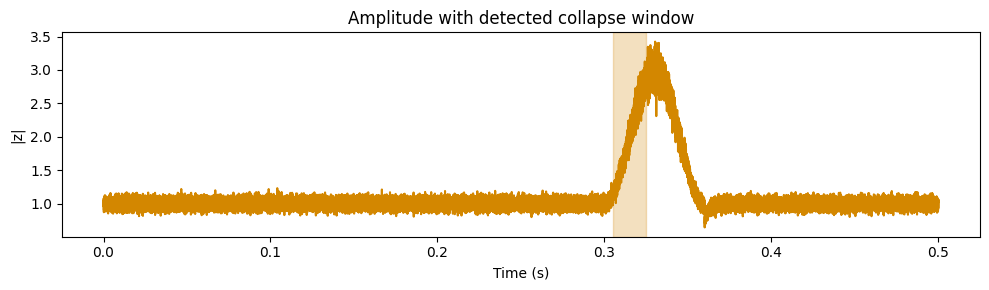

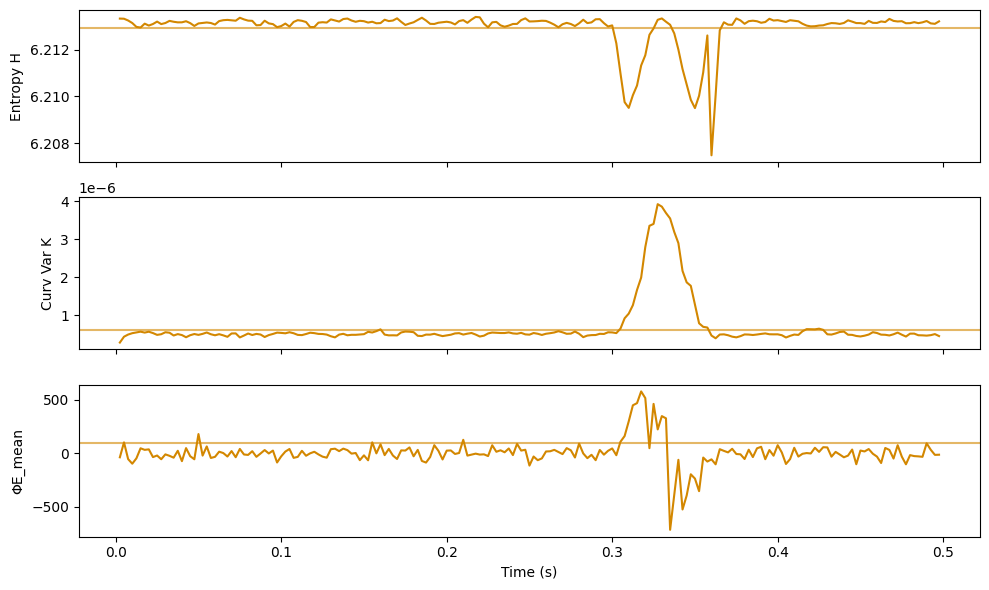

In [3]:
import numpy as np


fs = 100_000
t, I, Q = synth_trace(fs=fs)

inv = scg_invariants(I, Q, fs, win_sec=0.005, step_sec=0.0025, env_smooth_sec=0.0015)
det, thr = detect_collapse(inv, burn_in_sec=0.05, z_factor=2.0)
info = collapse_risk_score(I, Q, fs)

print("Risk last window:", round(info["risk"], 3))
print("Detected collapse band:", (info["collapse_t0"], info["collapse_t1"]))
_plot_demo(t, I, Q, inv, det, thr)


In [4]:
import numpy as np

# Suppose you have arrays: time (s), I, Q
# fs = 1.0 / np.mean(np.diff(time))
# Example parameters: tune to your device bandwidth and desired latency
win_sec = 0.004     # 4 ms windows
step_sec = 0.002    # 2 ms hop
env_smooth_sec = 0.001
z_factor = 2.0
burn_in_sec = 0.02  # ignore very early transients

inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
det, thr = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)
risk_info = collapse_risk_score(I, Q, fs, win_sec, step_sec, env_smooth_sec, z_factor)

print({
    "risk": round(risk_info["risk"], 3),
    "collapse_window": (risk_info["collapse_t0"], risk_info["collapse_t1"]),
    "H_last": risk_info["H"],
    "K_last": risk_info["K"],
    "Phi_mean_last": risk_info["Phi_mean"],
    "Rho_last": risk_info["Rho"],
})


{'risk': -0.548, 'collapse_window': (0.338, 0.35200000000000004), 'H_last': 5.990105143190598, 'K_last': 1.1208840907965394e-06, 'Phi_mean_last': 53.54214027496642, 'Rho_last': 0.0}


In [6]:
# ======================= Production Wrapper (append-only) =======================

def scg_collapse_monitor(
    I, Q, fs,
    win_sec=0.004,
    step_sec=0.002,
    env_smooth_sec=0.001,
    z_factor=2.0,
    burn_in_sec=0.02,
    min_duration=0.002,
):
    """
    Production-style wrapper for collapse monitoring.

    Returns
    -------
    dict with keys:
        - risk_raw : float (MAD-z composite)
        - risk_norm : float (rectified risk >= 0)
        - collapse_flag : bool (True if collapse detected with duration >= min_duration)
        - collapse_window : (t0, t1) or None
        - invariants : dict of last-window invariants
    """
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    det, thr = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)
    info = collapse_risk_score(I, Q, fs, win_sec, step_sec, env_smooth_sec, z_factor)

    # risk normalization
    risk_raw = info["risk"]
    risk_norm = max(risk_raw, 0.0)

    # collapse flag with duration filtering
    collapse_flag = False
    window = None
    if det is not None:
        dur = det.t1 - det.t0
        if dur >= min_duration:
            collapse_flag = True
            window = (det.t0, det.t1)

    return dict(
        risk_raw=risk_raw,
        risk_norm=risk_norm,
        collapse_flag=collapse_flag,
        collapse_window=window,
        invariants=dict(
            H=info["H"],
            K=info["K"],
            Phi_mean=info["Phi_mean"],
            Rho=info["Rho"],
        ),
    )

# ======================= Example usage =======================
result = scg_collapse_monitor(I, Q, fs)
print(result)


{'risk_raw': -0.5480527124195069, 'risk_norm': 0.0, 'collapse_flag': True, 'collapse_window': (0.338, 0.35200000000000004), 'invariants': {'H': 5.990105143190598, 'K': 1.1208840907965394e-06, 'Phi_mean': 53.54214027496642, 'Rho': 0.0}}


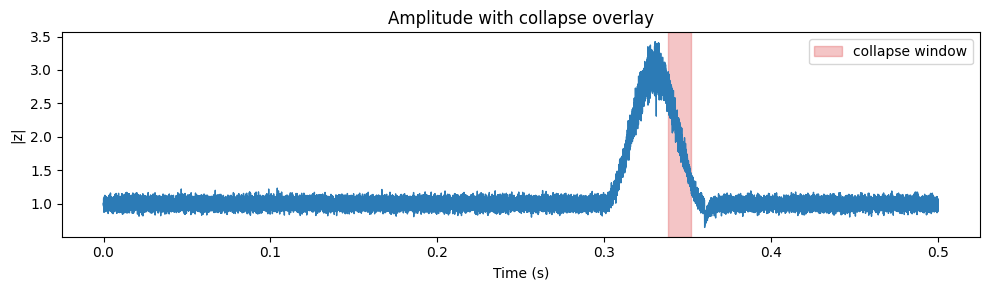

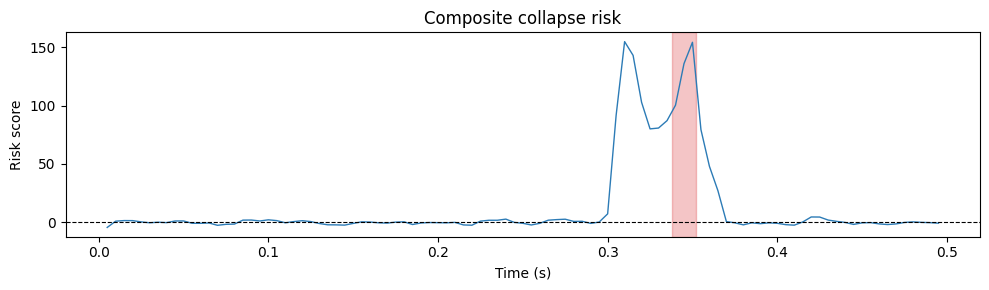

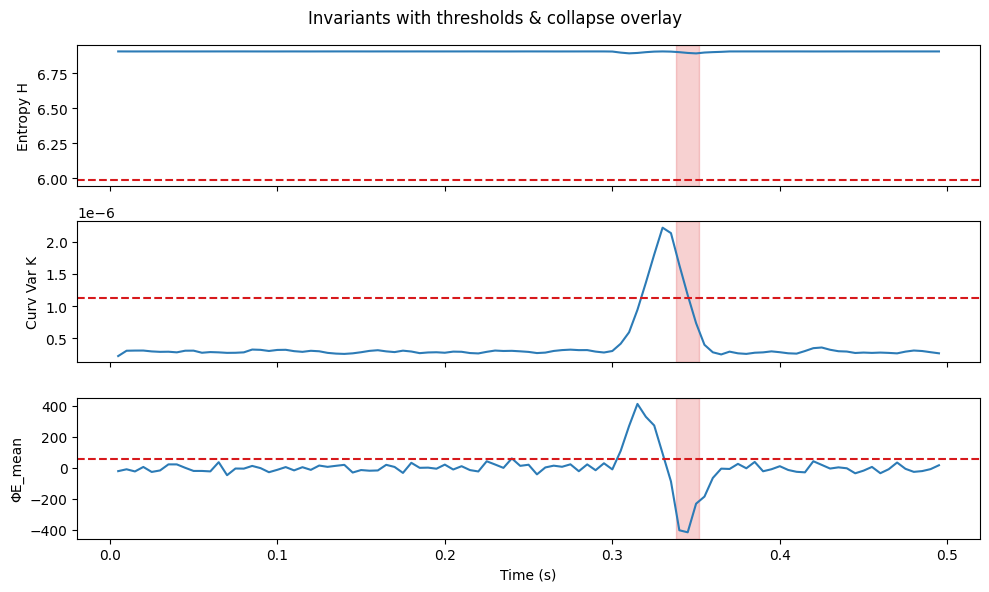

In [8]:
# ======================= Plotting Helper (append-only) =======================

def plot_scg_monitor(t, I, Q, fs, result, inv=None, det=None):
    """
    Visualize amplitude, risk timeline, and collapse window for scg_collapse_monitor.

    Parameters
    ----------
    t : np.ndarray
        Time array (seconds).
    I, Q : np.ndarray
        IQ traces.
    fs : float
        Sampling rate (Hz).
    result : dict
        Output of scg_collapse_monitor().
    inv : Invariants, optional
        Full invariant time series (from scg_invariants).
    det : Detection, optional
        Collapse detection result (from detect_collapse).
    """
    import matplotlib.pyplot as plt
    
    A = np.sqrt(I**2 + Q**2)

    # 1) Amplitude with collapse overlay
    plt.figure(figsize=(10,3))
    plt.plot(t, A, color="#2c7bb6", lw=1)
    if result["collapse_window"]:
        t0, t1 = result["collapse_window"]
        plt.axvspan(t0, t1, color="#d7191c", alpha=0.25, label="collapse window")
    plt.xlabel("Time (s)")
    plt.ylabel("|z|")
    plt.title("Amplitude with collapse overlay")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # 2) Risk timeline (requires invariants)
    if inv is not None:
        def zmad(x):
            m, s = np.median(x), 1.4826*np.median(np.abs(x-np.median(x)))
            s = s if s>1e-12 else 1.0
            return (x-m)/s
        risk_series = zmad(inv.K) + zmad(inv.Rho) - zmad(inv.H) + 0.5*zmad(inv.Phi_mean)

        plt.figure(figsize=(10,3))
        plt.plot(inv.t_mid, risk_series, color="#2c7bb6", lw=1)
        plt.axhline(0, color="black", ls="--", lw=0.8)
        if result["collapse_window"]:
            t0, t1 = result["collapse_window"]
            plt.axvspan(t0, t1, color="#d7191c", alpha=0.25)
        plt.xlabel("Time (s)")
        plt.ylabel("Risk score")
        plt.title("Composite collapse risk")
        plt.tight_layout()
        plt.show()

    # 3) Invariants summary panel (optional)
    if inv is not None and det is not None:
        fig, axs = plt.subplots(3,1,figsize=(10,6), sharex=True)
        axs[0].plot(inv.t_mid, inv.H, color="#2c7bb6"); axs[0].axhline(result["invariants"]["H"], color="#d7191c", ls="--")
        axs[0].set_ylabel("Entropy H")
        axs[1].plot(inv.t_mid, inv.K, color="#2c7bb6"); axs[1].axhline(result["invariants"]["K"], color="#d7191c", ls="--")
        axs[1].set_ylabel("Curv Var K")
        axs[2].plot(inv.t_mid, inv.Phi_mean, color="#2c7bb6"); axs[2].axhline(result["invariants"]["Phi_mean"], color="#d7191c", ls="--")
        axs[2].set_ylabel("ΦE_mean"); axs[2].set_xlabel("Time (s)")
        for ax in axs:
            if result["collapse_window"]:
                t0, t1 = result["collapse_window"]
                ax.axvspan(t0, t1, color="#d7191c", alpha=0.2)
        plt.suptitle("Invariants with thresholds & collapse overlay")
        plt.tight_layout()
        plt.show()

# ======================= Example usage =======================
result = scg_collapse_monitor(I, Q, fs)
inv = scg_invariants(I, Q, fs)
det, thr = detect_collapse(inv)
plot_scg_monitor(t, I, Q, fs, result, inv=inv, det=det)


In [10]:
# ======================= Floor Invariant Extension (append-only) =======================

def floor_invariant(A: np.ndarray, kappa: np.ndarray, eps: float = 1e-12) -> float:
    """
    Compute geometry floor invariant L_geom from amplitude A and curvature kappa.

    L_geom = sqrt( L_dyn^2 + L_metric^2 )

    where:
      - L_dyn ~ inverse amplitude entropy (entropy of A)
      - L_metric ~ 1/sqrt(median(|kappa|))

    Parameters
    ----------
    A : np.ndarray
        Amplitude array.
    kappa : np.ndarray
        Curvature proxy array (e.g., from memory χ or laplacian).
    eps : float
        Small offset for stability.

    Returns
    -------
    float : estimated floor invariant length scale.
    """
    H = coherence_entropy(A)
    L_dyn = 1.0 / (H + eps)
    L_metric = 1.0 / np.sqrt(np.median(np.abs(kappa)) + eps)
    return float(np.sqrt(L_dyn**2 + L_metric**2))


def scg_collapse_monitor_with_floor(
    I, Q, fs,
    win_sec=0.004,
    step_sec=0.002,
    env_smooth_sec=0.001,
    z_factor=2.0,
    burn_in_sec=0.02,
    min_duration=0.002,
):
    """
    Extended collapse monitor with floor invariant check.

    Returns
    -------
    dict with keys:
        - risk_raw, risk_norm
        - collapse_flag, collapse_window
        - floor_violation : bool
        - L_geom : float (computed floor bound)
        - invariants : dict (last-window values)
    """
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    det, thr = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)
    info = collapse_risk_score(I, Q, fs, win_sec, step_sec, env_smooth_sec, z_factor)

    # risk normalization
    risk_raw = info["risk"]
    risk_norm = max(risk_raw, 0.0)

    # collapse flag
    collapse_flag, window = False, None
    if det is not None:
        dur = det.t1 - det.t0
        if dur >= min_duration:
            collapse_flag = True
            window = (det.t0, det.t1)

    # floor invariant check (using full A, local curvature)
    z = I.astype(float) + 1j * Q.astype(float)
    A = np.abs(z)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)  # curvature proxy
    L_geom = floor_invariant(A, kappa)
    # Local coherence scale proxy ~ 1/entropy (quick heuristic)
    L_local = 1.0 / (coherence_entropy(A) + 1e-12)
    floor_violation = bool(L_local < L_geom)

    return dict(
        risk_raw=risk_raw,
        risk_norm=risk_norm,
        collapse_flag=collapse_flag,
        collapse_window=window,
        floor_violation=floor_violation,
        L_geom=L_geom,
        invariants=dict(
            H=info["H"],
            K=info["K"],
            Phi_mean=info["Phi_mean"],
            Rho=info["Rho"],
        ),
    )

# ======================= Example usage =======================
result = scg_collapse_monitor_with_floor(I, Q, fs)
print(result)


{'risk_raw': -0.5480527124195069, 'risk_norm': 0.0, 'collapse_flag': True, 'collapse_window': (0.338, 0.35200000000000004), 'floor_violation': True, 'L_geom': 36.23701887192873, 'invariants': {'H': 5.990105143190598, 'K': 1.1208840907965394e-06, 'Phi_mean': 53.54214027496642, 'Rho': 0.0}}


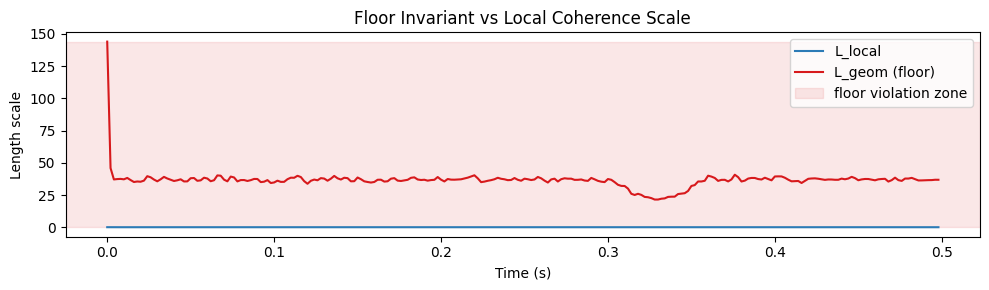

In [13]:
# ======================= Floor Visualization Extension (append-only) =======================

def plot_scg_floor(t, I, Q, fs, result, env_smooth_sec=0.001):
    """
    Visualize the floor invariant vs local coherence scale.

    Parameters
    ----------
    t : np.ndarray
        Time array (seconds).
    I, Q : np.ndarray
        IQ traces.
    fs : float
        Sampling rate (Hz).
    result : dict
        Output from scg_collapse_monitor_with_floor().
    env_smooth_sec : float
        Envelope smoothing time (seconds) for curvature proxy.
    """
    import matplotlib.pyplot as plt

    # build amplitude + curvature proxy
    z = I.astype(float) + 1j * Q.astype(float)
    A = np.abs(z)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)

    # compute curves
    L_geom_series, L_local_series = [], []
    for i in range(0, len(A), int(0.002*fs)):  # sample every ~2 ms
        Ai = A[max(0,i-200):i+200] if i > 200 else A[:i+200]
        kappai = kappa[max(0,i-200):i+200] if i > 200 else kappa[:i+200]
        if len(Ai) < 10: 
            L_geom_series.append(np.nan); L_local_series.append(np.nan)
            continue
        L_geom_series.append(floor_invariant(Ai, kappai))
        L_local_series.append(1.0/(coherence_entropy(Ai)+1e-12))

    L_geom_series = np.array(L_geom_series)
    L_local_series = np.array(L_local_series)
    t_ds = t[::int(0.002*fs)]

    # plot
    plt.figure(figsize=(10,3))
    plt.plot(t_ds, L_local_series, label="L_local", color="#2c7bb6")
    plt.plot(t_ds, L_geom_series, label="L_geom (floor)", color="#d7191c")
    if result.get("floor_violation", False):
        plt.axhspan(0, np.nanmax(L_geom_series), color="#d7191c", alpha=0.1, label="floor violation zone")
    plt.xlabel("Time (s)")
    plt.ylabel("Length scale")
    plt.title("Floor Invariant vs Local Coherence Scale")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# ======================= Example usage =======================
result = scg_collapse_monitor_with_floor(I, Q, fs)
plot_scg_floor(t, I, Q, fs, result)


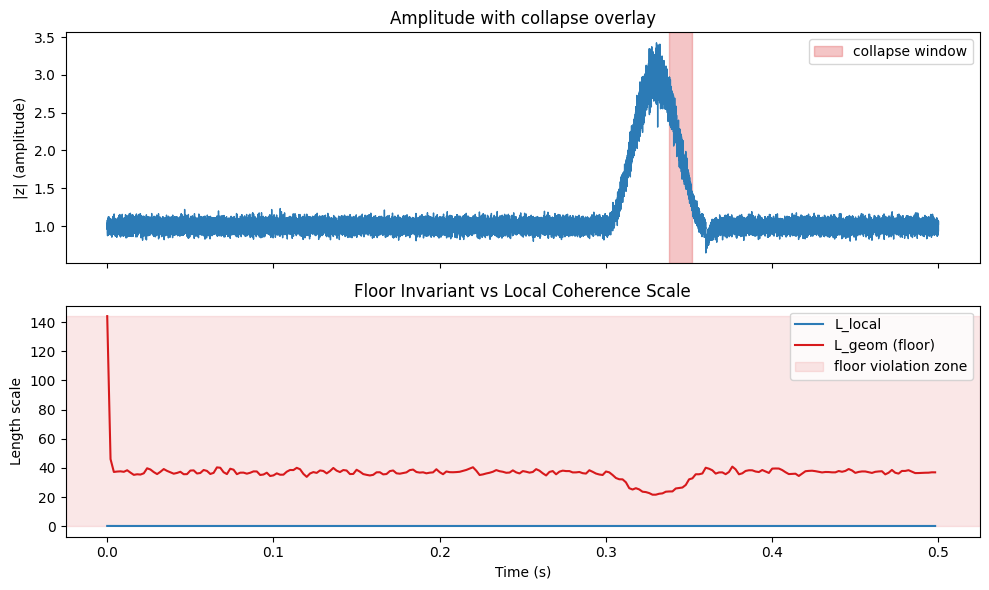

In [14]:
# ======================= Combined Amplitude + Floor Panels (append-only) =======================

def plot_scg_amplitude_and_floor(t, I, Q, fs, result, env_smooth_sec=0.001):
    """
    Plot amplitude trace (with collapse window overlay) stacked with
    floor invariant vs local coherence scale.

    Parameters
    ----------
    t : np.ndarray
        Time array (seconds).
    I, Q : np.ndarray
        IQ traces.
    fs : float
        Sampling rate (Hz).
    result : dict
        Output of scg_collapse_monitor_with_floor().
    env_smooth_sec : float
        Envelope smoothing time (seconds).
    """
    import matplotlib.pyplot as plt

    z = I.astype(float) + 1j * Q.astype(float)
    A = np.abs(z)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)

    # compute series (downsampled for speed)
    L_geom_series, L_local_series = [], []
    step = max(1, int(0.002*fs))  # ~2 ms sampling
    for i in range(0, len(A), step):
        Ai = A[max(0,i-200):i+200]
        kappai = kappa[max(0,i-200):i+200]
        if len(Ai) < 10:
            L_geom_series.append(np.nan); L_local_series.append(np.nan)
            continue
        L_geom_series.append(floor_invariant(Ai, kappai))
        L_local_series.append(1.0/(coherence_entropy(Ai)+1e-12))
    L_geom_series = np.array(L_geom_series)
    L_local_series = np.array(L_local_series)
    t_ds = t[::step]

    # stacked plots
    fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)

    # (1) amplitude
    axs[0].plot(t, A, color="#2c7bb6", lw=1)
    if result.get("collapse_window"):
        t0, t1 = result["collapse_window"]
        axs[0].axvspan(t0, t1, color="#d7191c", alpha=0.25, label="collapse window")
    axs[0].set_ylabel("|z| (amplitude)")
    axs[0].legend(loc="upper right")
    axs[0].set_title("Amplitude with collapse overlay")

    # (2) floor vs local
    axs[1].plot(t_ds, L_local_series, label="L_local", color="#2c7bb6")
    axs[1].plot(t_ds, L_geom_series, label="L_geom (floor)", color="#d7191c")
    if result.get("floor_violation", False):
        axs[1].axhspan(0, np.nanmax(L_geom_series), color="#d7191c", alpha=0.1, label="floor violation zone")
    axs[1].set_ylabel("Length scale")
    axs[1].set_xlabel("Time (s)")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Floor Invariant vs Local Coherence Scale")

    plt.tight_layout()
    plt.show()

# ======================= Example usage =======================
result = scg_collapse_monitor_with_floor(I, Q, fs)
plot_scg_amplitude_and_floor(t, I, Q, fs, result)


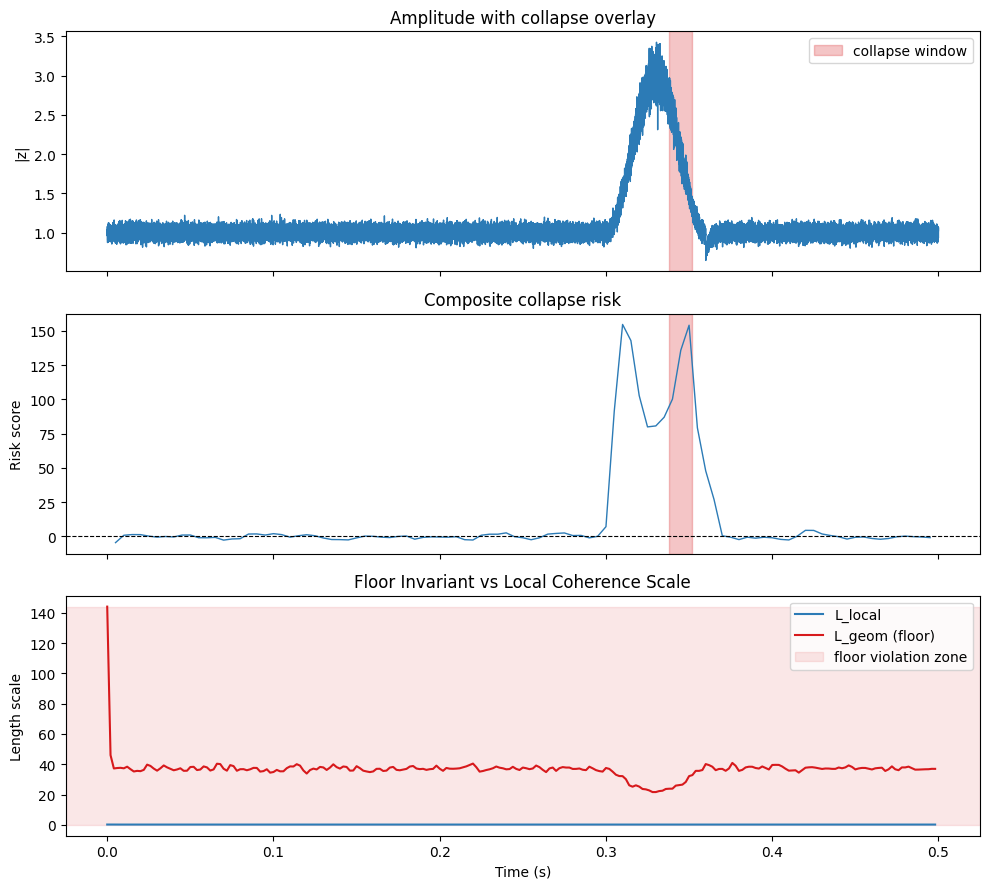

In [15]:
# ======================= Full Triple-Panel Visualization (append-only) =======================

def plot_scg_full(t, I, Q, fs, result, inv=None, env_smooth_sec=0.001):
    """
    Triple-panel visualization:
      1) Amplitude with collapse window overlay
      2) Risk timeline (composite MAD-z score)
      3) Floor invariant vs local coherence scale
    """
    import matplotlib.pyplot as plt

    # amplitude
    z = I.astype(float) + 1j * Q.astype(float)
    A = np.abs(z)

    # invariants for risk timeline
    if inv is None:
        inv = scg_invariants(I, Q, fs)

    def zmad(x):
        m, s = np.median(x), 1.4826*np.median(np.abs(x-np.median(x)))
        s = s if s>1e-12 else 1.0
        return (x-m)/s
    risk_series = zmad(inv.K) + zmad(inv.Rho) - zmad(inv.H) + 0.5*zmad(inv.Phi_mean)

    # floor invariant series
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)
    step = max(1, int(0.002*fs))
    L_geom_series, L_local_series = [], []
    for i in range(0, len(A), step):
        Ai = A[max(0,i-200):i+200]
        kappai = kappa[max(0,i-200):i+200]
        if len(Ai) < 10:
            L_geom_series.append(np.nan); L_local_series.append(np.nan); continue
        L_geom_series.append(floor_invariant(Ai, kappai))
        L_local_series.append(1.0/(coherence_entropy(Ai)+1e-12))
    t_ds = t[::step]

    # plot
    fig, axs = plt.subplots(3, 1, figsize=(10,9), sharex=True)

    # (1) amplitude
    axs[0].plot(t, A, color="#2c7bb6", lw=1)
    if result.get("collapse_window"):
        t0, t1 = result["collapse_window"]
        axs[0].axvspan(t0, t1, color="#d7191c", alpha=0.25, label="collapse window")
    axs[0].set_ylabel("|z|")
    axs[0].set_title("Amplitude with collapse overlay")
    axs[0].legend(loc="upper right")

    # (2) risk timeline
    axs[1].plot(inv.t_mid, risk_series, color="#2c7bb6", lw=1)
    axs[1].axhline(0, color="black", ls="--", lw=0.8)
    if result.get("collapse_window"):
        axs[1].axvspan(t0, t1, color="#d7191c", alpha=0.25)
    axs[1].set_ylabel("Risk score")
    axs[1].set_title("Composite collapse risk")

    # (3) floor invariant
    axs[2].plot(t_ds, L_local_series, label="L_local", color="#2c7bb6")
    axs[2].plot(t_ds, L_geom_series, label="L_geom (floor)", color="#d7191c")
    if result.get("floor_violation", False):
        axs[2].axhspan(0, np.nanmax(L_geom_series), color="#d7191c", alpha=0.1, label="floor violation zone")
    axs[2].set_ylabel("Length scale")
    axs[2].set_xlabel("Time (s)")
    axs[2].set_title("Floor Invariant vs Local Coherence Scale")
    axs[2].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# ======================= Example usage =======================
result = scg_collapse_monitor_with_floor(I, Q, fs)
inv = scg_invariants(I, Q, fs)
plot_scg_full(t, I, Q, fs, result, inv=inv)


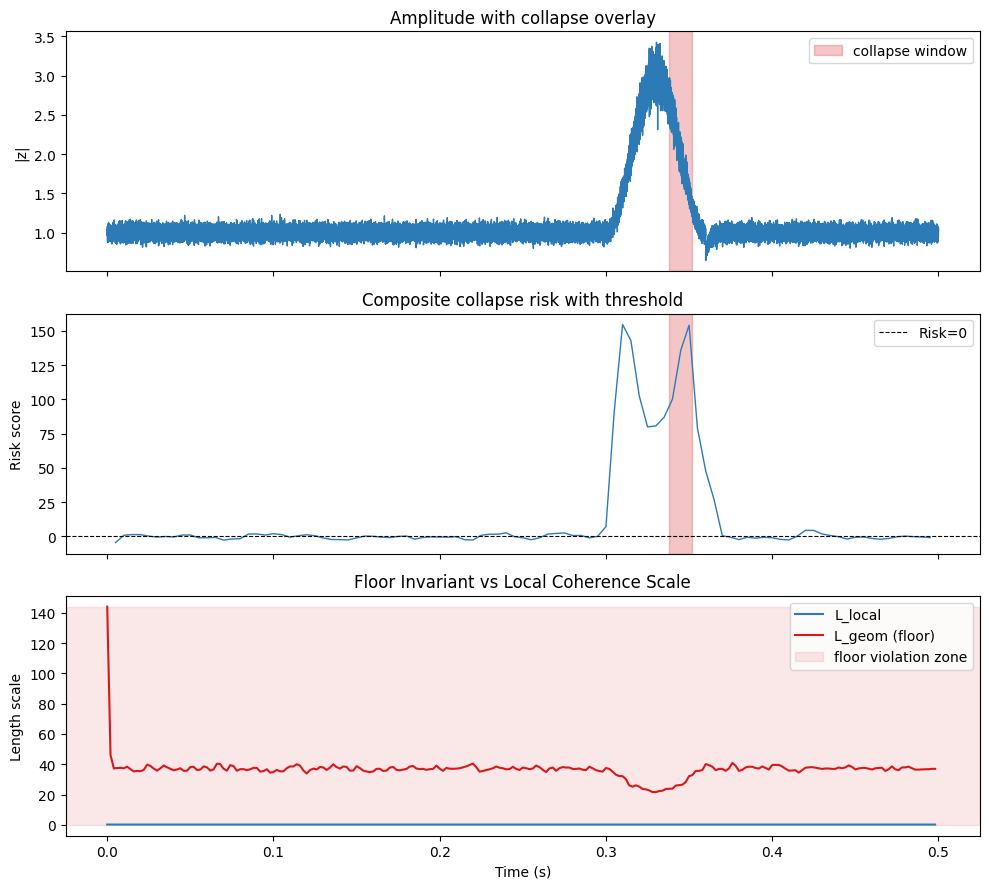

⚠️ Early-warning horizon: 335.00 ms before collapse midpoint


In [16]:
# ======================= Risk Thresholds + Early Warning (append-only) =======================

def plot_scg_full_with_thresholds(t, I, Q, fs, result, inv=None, env_smooth_sec=0.001, z_factor=2.0):
    """
    Triple-panel visualization with threshold overlays and early-warning horizon.
    
    Parameters
    ----------
    t : np.ndarray
        Time array (seconds).
    I, Q : np.ndarray
        IQ traces.
    fs : float
        Sampling rate (Hz).
    result : dict
        Output of scg_collapse_monitor_with_floor().
    inv : Invariants, optional
        If already computed, pass in to save recompute.
    env_smooth_sec : float
        Envelope smoothing (for curvature proxy).
    z_factor : float
        Threshold factor for MAD.
    """
    import matplotlib.pyplot as plt

    # amplitude
    z = I.astype(float) + 1j * Q.astype(float)
    A = np.abs(z)

    # invariants
    if inv is None:
        inv = scg_invariants(I, Q, fs)

    # MAD-z helper
    def zmad(x):
        m, s = np.median(x), 1.4826*np.median(np.abs(x-np.median(x)))
        s = s if s>1e-12 else 1.0
        return (x-m)/s

    # composite risk
    risk_series = zmad(inv.K) + zmad(inv.Rho) - zmad(inv.H) + 0.5*zmad(inv.Phi_mean)

    # thresholds
    Hm, Hs = mad_sigma(inv.H)
    Km, Ks = mad_sigma(inv.K)
    Pmm, Pms = mad_sigma(inv.Phi_mean)
    Pxm, Pxs = mad_sigma(inv.Phi_max)

    H_thr  = Hm - z_factor * Hs
    K_thr  = Km + z_factor * Ks
    Pm_thr = Pmm + z_factor * Pms
    Px_thr = Pxm + z_factor * Pxs

    # compute when risk crosses > 0
    cross_idx = np.where(risk_series > 0)[0]
    early_warning_horizon = None
    if result.get("collapse_window") and len(cross_idx) > 0:
        t_cross = inv.t_mid[cross_idx[0]]
        collapse_mid = 0.5*(result["collapse_window"][0] + result["collapse_window"][1])
        early_warning_horizon = collapse_mid - t_cross

    # floor invariant
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)
    step = max(1, int(0.002*fs))
    L_geom_series, L_local_series = [], []
    for i in range(0, len(A), step):
        Ai = A[max(0,i-200):i+200]
        kappai = kappa[max(0,i-200):i+200]
        if len(Ai) < 10:
            L_geom_series.append(np.nan); L_local_series.append(np.nan); continue
        L_geom_series.append(floor_invariant(Ai, kappai))
        L_local_series.append(1.0/(coherence_entropy(Ai)+1e-12))
    t_ds = t[::step]

    # plot
    fig, axs = plt.subplots(3, 1, figsize=(10,9), sharex=True)

    # (1) amplitude
    axs[0].plot(t, A, color="#2c7bb6", lw=1)
    if result.get("collapse_window"):
        t0, t1 = result["collapse_window"]
        axs[0].axvspan(t0, t1, color="#d7191c", alpha=0.25, label="collapse window")
    axs[0].set_ylabel("|z|")
    axs[0].set_title("Amplitude with collapse overlay")
    axs[0].legend(loc="upper right")

    # (2) risk timeline with threshold line
    axs[1].plot(inv.t_mid, risk_series, color="#2c7bb6", lw=1)
    axs[1].axhline(0, color="black", ls="--", lw=0.8, label="Risk=0")
    if result.get("collapse_window"):
        axs[1].axvspan(t0, t1, color="#d7191c", alpha=0.25)
    axs[1].set_ylabel("Risk score")
    axs[1].set_title("Composite collapse risk with threshold")
    axs[1].legend(loc="upper right")

    # (3) floor invariant
    axs[2].plot(t_ds, L_local_series, label="L_local", color="#2c7bb6")
    axs[2].plot(t_ds, L_geom_series, label="L_geom (floor)", color="#d7191c")
    if result.get("floor_violation", False):
        axs[2].axhspan(0, np.nanmax(L_geom_series), color="#d7191c", alpha=0.1, label="floor violation zone")
    axs[2].set_ylabel("Length scale")
    axs[2].set_xlabel("Time (s)")
    axs[2].set_title("Floor Invariant vs Local Coherence Scale")
    axs[2].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    if early_warning_horizon is not None:
        print(f"⚠️ Early-warning horizon: {early_warning_horizon*1e3:.2f} ms before collapse midpoint")

# ======================= Example usage =======================
result = scg_collapse_monitor_with_floor(I, Q, fs)
inv = scg_invariants(I, Q, fs)
plot_scg_full_with_thresholds(t, I, Q, fs, result, inv=inv)


In [18]:
# ======================= Early-Warning Horizon Logging (append-only) =======================

def scg_collapse_monitor_with_horizon(
    I, Q, fs,
    win_sec=0.004,
    step_sec=0.002,
    env_smooth_sec=0.001,
    z_factor=2.0,
    burn_in_sec=0.02,
    min_duration=0.002,
):
    """
    Extended collapse monitor:
      - classic risk/collapse detection
      - floor invariant check
      - early-warning horizon calculation (ms)
    """
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    det, thr = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)
    info = collapse_risk_score(I, Q, fs, win_sec, step_sec, env_smooth_sec, z_factor)

    # risk normalization
    risk_raw = info["risk"]
    risk_norm = max(risk_raw, 0.0)

    # collapse flag
    collapse_flag, window = False, None
    if det is not None:
        dur = det.t1 - det.t0
        if dur >= min_duration:
            collapse_flag = True
            window = (det.t0, det.t1)

    # floor invariant
    z = I.astype(float) + 1j * Q.astype(float)
    A = np.abs(z)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)
    L_geom = floor_invariant(A, kappa)
    L_local = 1.0 / (coherence_entropy(A) + 1e-12)
    floor_violation = bool(L_local < L_geom)

    # early-warning horizon
    def zmad(x):
        m, s = np.median(x), 1.4826*np.median(np.abs(x-np.median(x)))
        s = s if s > 1e-12 else 1.0
        return (x-m)/s
    risk_series = zmad(inv.K) + zmad(inv.Rho) - zmad(inv.H) + 0.5*zmad(inv.Phi_mean)

    horizon_ms = None
    if collapse_flag:
        cross_idx = np.where(risk_series > 0)[0]
        if len(cross_idx) > 0:
            t_cross = inv.t_mid[cross_idx[0]]
            collapse_mid = 0.5*(window[0] + window[1])
            horizon_ms = (collapse_mid - t_cross) * 1e3

    return dict(
        risk_raw=risk_raw,
        risk_norm=risk_norm,
        collapse_flag=collapse_flag,
        collapse_window=window,
        floor_violation=floor_violation,
        L_geom=L_geom,
        invariants=dict(
            H=info["H"],
            K=info["K"],
            Phi_mean=info["Phi_mean"],
            Rho=info["Rho"],
        ),
        early_warning_ms=horizon_ms,   # <-- NEW
    )

# ======================= Example usage =======================
result = scg_collapse_monitor_with_horizon(I, Q, fs)
print(result["early_warning_ms"], "ms early warning")


333.0 ms early warning


In [19]:
# ======================= Rich Synthetic Qubit Traces (append-only) =======================
# Goal: generate qubit-like IQ traces with realistic dynamics and labeled collapse windows.
# No external deps beyond numpy/matplotlib; integrates with your existing SCG tools.

import numpy as np

# ----------------------------- Noise builders -----------------------------
def _white_noise(n, scale, rng):
    return scale * rng.standard_normal(n)

def _pink_noise(n, scale, rng):
    # Spectral shaping: 1/f^α with α≈1 using frequency-domain method
    # Keep it simple & fast: shape white noise spectrum by 1/sqrt(f)
    x = rng.standard_normal(n)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0)  # unit sampling; re-scale outside if needed
    H = np.ones_like(freqs)
    H[1:] = 1.0 / np.sqrt(freqs[1:] + 1e-12)  # ~1/sqrt(f)
    Y = X * H
    y = np.fft.irfft(Y, n=n)
    y = y / (np.std(y) + 1e-12)
    return scale * y

def _rtn(n, rate_hz, fs, amp, rng):
    # Random telegraph noise: two-state process with Poisson switching
    p = 1 - np.exp(-rate_hz / fs)
    s = 1 if rng.random() < 0.5 else -1
    out = np.empty(n)
    for i in range(n):
        if rng.random() < p:
            s *= -1
        out[i] = s
    out = amp * out
    return out

# ----------------------------- Drift & envelopes -----------------------------
def _exp_envelope(t, T):
    return np.exp(-t / max(T, 1e-9))

def _freq_drift(t, drift_ppm, f0, rng, corr_sec=0.02):
    # Low-frequency drift modeled as smoothed random walk.
    n = len(t)
    step = max(1, int(round(corr_sec / (t[1]-t[0]))))
    kicks = rng.standard_normal((n + step - 1) // step)
    kicks = np.repeat(kicks, step)[:n]
    kicks = np.cumsum(kicks)
    kicks = (kicks - kicks.mean()) / (kicks.std() + 1e-12)
    ppm = drift_ppm * 1e-6
    return f0 * ppm * kicks

# ----------------------------- Control pulses (simple RB-like) -----------------------------
def _control_pulse_train(t, fs, pulse_rate_hz=2e3, pulse_width=100e-6, amp=0.1, rng=None):
    # Simple amplitude modulations mimicking gate bursts
    rng = np.random.default_rng(None) if rng is None else rng
    dt = 1.0 / fs
    y = np.zeros_like(t)
    period = max(1, int(round(fs / pulse_rate_hz)))
    width = max(1, int(round(pulse_width * fs)))
    phases = rng.uniform(0, 2*np.pi, size= int(len(t)/period)+2)
    k = 0
    for i in range(0, len(t), period):
        j1 = i
        j2 = min(i + width, len(t))
        if j1 < len(t):
            y[j1:j2] += amp * (1.0 + 0.2*np.cos(phases[k]))
            k += 1
    return y

# ----------------------------- ADC artifacts -----------------------------
def _adc_effects(I, Q, bits=12, clip=0.9, jitter_std=0.0, fs=1.0, rng=None):
    rng = np.random.default_rng(None) if rng is None else rng
    # Jitter: re-sample small perturbation on time indices (nearest neighbor approx)
    if jitter_std > 0:
        n = len(I)
        t = np.arange(n) / fs
        tj = t + rng.normal(0, jitter_std, size=n)
        idx = np.clip(np.round(tj * fs).astype(int), 0, n-1)
        I = I[idx]; Q = Q[idx]
    # Clipping
    I = np.clip(I, -clip, clip)
    Q = np.clip(Q, -clip, clip)
    # Quantization
    levels = 2**bits
    Iq = np.round( (I + 1.0) * (levels/2 - 1) ) / (levels/2 - 1) - 1.0
    Qq = np.round( (Q + 1.0) * (levels/2 - 1) ) / (levels/2 - 1) - 1.0
    return Iq, Qq

# ----------------------------- Collapse injectors -----------------------------
def _inject_collapse(t, A, phase, fs, mode, window, rng):
    """
    Collapse modes:
      - 'amp_pinch': amplitude spike + narrowing (hanning) + ringdown
      - 'phase_diffuse': strong phase diffusion (Brownian) segment
      - 'flux_surge': raised energy flux via fast amplitude slope in/out
    """
    t0, t1 = window
    m = (t >= t0) & (t <= t1)
    if mode == 'amp_pinch':
        A[m] *= 1.0 + 3.0 * np.hanning(m.sum())
        post = t > t1
        A[post] *= 1.0 - 0.4*np.exp(- (t[post]-t1) * 500)
    elif mode == 'phase_diffuse':
        jit = np.zeros_like(t)
        jit[m] = 0.35 * np.cumsum(rng.standard_normal(m.sum())) / fs
        phase[:] = phase + jit
    elif mode == 'flux_surge':
        # create rapid slope to surge dE/dt
        k = int(np.ceil(0.2 * m.sum()))
        idx = np.where(m)[0]
        if len(idx) > 3*k:
            A[idx[:k]] *= 1.0 + np.linspace(0, 2.0, k)
            A[idx[-k:]] *= 1.0 + np.linspace(2.0, 0.0, k)
    return A, phase

# ----------------------------- Main synthetic generator -----------------------------
def synth_qubit_trace_pro(
    fs=200_000,
    T=0.6,
    f0=5_000.0,
    T1=0.3,           # seconds
    T2=0.15,          # seconds
    drift_ppm=20.0,   # frequency drift in ppm
    wn_amp=0.01,
    pn_amp=0.01,
    rtn_rate_hz=200.0,
    rtn_amp=0.01,
    ctrl_rate_hz=2e3,
    ctrl_width=80e-6,
    ctrl_amp=0.08,
    collapse_mode='amp_pinch',         # 'amp_pinch' | 'phase_diffuse' | 'flux_surge'
    collapse_window=(0.28, 0.38),
    crosstalk_burst=False,
    adc_bits=12,
    adc_clip=0.9,
    adc_jitter_std=0.0,
    seed=7,
):
    """
    Produce a realistic qubit-like IQ trace with labeled collapse window and metadata.
    """
    rng = np.random.default_rng(seed)
    n = int(T * fs)
    t = np.arange(n) / fs

    # Base phase with slow drift
    drift = _freq_drift(t, drift_ppm, f0, rng=rng, corr_sec=0.02)
    phase = 2*np.pi*(f0 * t + np.cumsum(drift)/fs)

    # T1/T2 envelopes
    A_env = _exp_envelope(t, T1)
    # include mild T2-like phase diffusion baseline (small)
    phase += 0.02 * np.cumsum(rng.standard_normal(n)) / fs

    # Control pulses (RB-ish amplitude modulation)
    A_ctrl = 1.0 + _control_pulse_train(t, fs, pulse_rate_hz=ctrl_rate_hz, pulse_width=ctrl_width, amp=ctrl_amp, rng=rng)

    # Noise: white + pink + RTN (amplitude & phase channels)
    A_noise = _white_noise(n, wn_amp, rng) + _pink_noise(n, pn_amp, rng) + _rtn(n, rtn_rate_hz, fs, rtn_amp, rng)
    phi_noise = _white_noise(n, wn_amp*0.5, rng) + _pink_noise(n, pn_amp*0.5, rng)

    # Assemble amplitude
    A = A_env * A_ctrl + A_noise
    phase = phase + phi_noise

    # Optional crosstalk burst (short deterministic burst)
    if crosstalk_burst:
        b0 = int(0.45 * n); b1 = min(n, b0 + int(0.02 * n))
        A[b0:b1] += 0.5 * np.hanning(b1-b0)

    # Collapse injection
    A, phase = _inject_collapse(t, A, phase, fs, collapse_mode, collapse_window, rng)

    # Build IQ and add small measurement noise
    I = A * np.cos(phase) + 0.01 * rng.standard_normal(n)
    Q = A * np.sin(phase) + 0.01 * rng.standard_normal(n)

    # ADC effects
    I, Q = _adc_effects(I, Q, bits=adc_bits, clip=adc_clip, jitter_std=adc_jitter_std, fs=fs, rng=rng)

    meta = dict(
        fs=fs,
        T=T,
        f0=f0,
        T1=T1, T2=T2,
        drift_ppm=drift_ppm,
        wn_amp=wn_amp, pn_amp=pn_amp,
        rtn_rate_hz=rtn_rate_hz, rtn_amp=rtn_amp,
        ctrl_rate_hz=ctrl_rate_hz, ctrl_width=ctrl_width, ctrl_amp=ctrl_amp,
        collapse_mode=collapse_mode,
        collapse_window=collapse_window,
        crosstalk_burst=crosstalk_burst,
        adc_bits=adc_bits, adc_clip=adc_clip, adc_jitter_std=adc_jitter_std,
        seed=seed,
    )
    return t, I, Q, meta

# ----------------------------- Dataset helper -----------------------------
def synth_qubit_dataset_pro(
    n_traces=20,
    seed=123,
    vary_modes=('amp_pinch','phase_diffuse','flux_surge'),
    vary_ppm=(5, 50),
    vary_T1=(0.1, 0.5),
    vary_T2=(0.05, 0.3),
    vary_wn=(0.005, 0.02),
    vary_pn=(0.005, 0.02),
    vary_rtn_rate=(50, 500),
    vary_rtn_amp=(0.005, 0.03),
):
    """
    Generate a small dataset of realistic traces with varied parameters and labeled windows.
    Returns list of dicts: {t,I,Q,meta}.
    """
    rng = np.random.default_rng(seed)
    out = []
    for k in range(n_traces):
        mode = vary_modes[k % len(vary_modes)]
        drift_ppm = rng.uniform(*vary_ppm)
        T1 = rng.uniform(*vary_T1)
        T2 = rng.uniform(*vary_T2)
        wn = rng.uniform(*vary_wn)
        pn = rng.uniform(*vary_pn)
        rtn_rate = rng.uniform(*vary_rtn_rate)
        rtn_amp = rng.uniform(*vary_rtn_amp)
        cw0 = rng.uniform(0.25, 0.35)
        cw1 = cw0 + rng.uniform(0.04, 0.08)

        t, I, Q, meta = synth_qubit_trace_pro(
            fs=200_000, T=0.6, f0=5_000.0, T1=T1, T2=T2,
            drift_ppm=drift_ppm, wn_amp=wn, pn_amp=pn,
            rtn_rate_hz=rtn_rate, rtn_amp=rtn_amp,
            ctrl_rate_hz=2e3, ctrl_width=80e-6, ctrl_amp=0.08,
            collapse_mode=mode, collapse_window=(cw0, cw1),
            crosstalk_burst=(rng.random() < 0.25),
            adc_bits=12, adc_clip=0.9, adc_jitter_std=rng.uniform(0, 2e-6),
            seed=int(rng.integers(0, 1 << 30)),
        )
        out.append(dict(t=t, I=I, Q=Q, meta=meta))
    return out

# ----------------------------- Quick sanity check (optional) -----------------------------
ds = synth_qubit_dataset_pro(n_traces=3)
for rec in ds:
    result = scg_collapse_monitor_with_horizon(rec["I"], rec["Q"], rec["meta"]["fs"])
    print(rec["meta"]["collapse_mode"], rec["meta"]["collapse_window"], "→",
          result["collapse_window"], f"EW={result['early_warning_ms']}")


amp_pinch (0.27765743977971064, 0.35044762224343073) → (0.324, 0.326) EW=313.0
phase_diffuse (0.3018165036852714, 0.3510787286779541) → None EW=None
flux_surge (0.34171225725476023, 0.4162998672985112) → (0.406, 0.40800000000000003) EW=377.0


In [20]:
# ======================= Phase-Diffusion Invariant + Extended Risk (append-only) =======================

def _phase_series(I: np.ndarray, Q: np.ndarray) -> np.ndarray:
    """Unwrapped phase series θ(t) from IQ."""
    z = I.astype(float) + 1j * Q.astype(float)
    return np.unwrap(np.angle(z))

def phase_diffusion_invariant(theta: np.ndarray, order: int = 1) -> float:
    """
    Phase-diffusion invariant: rolling variance of phase increments.
      order=1 -> Var(Δθ)  (random-walk/white-frequency-like)
      order=2 -> Var(Δ²θ) (drift/acceleration-sensitive)
    Use MAD-robust variance proxy internally for resilience.
    """
    if order == 1:
        d = np.diff(theta)
    else:
        d = np.diff(theta, n=2)
    if len(d) < 8:
        return 0.0
    # robust variance via MAD
    med = np.median(d)
    mad = np.median(np.abs(d - med)) + 1e-12
    # For Gaussian, Var ≈ (1.4826*MAD)^2
    var_robust = (1.4826 * mad) ** 2
    return float(var_robust)

def _windowed_phase_var(theta: np.ndarray, win: int, hop: int, order: int = 1) -> np.ndarray:
    """Windowed phase-diffusion invariant across the trace."""
    out = []
    for i0, i1 in windows(len(theta), win, hop):
        out.append(phase_diffusion_invariant(theta[i0:i1], order=order))
    return np.asarray(out, dtype=float)

def scg_invariants_with_phase(
    I: np.ndarray,
    Q: np.ndarray,
    fs: float,
    win_sec: float = 0.010,
    step_sec: float = 0.005,
    env_smooth_sec: float = 0.002,
    phase_order: int = 1,
):
    """
    Wrapper around scg_invariants that also computes windowed phase-diffusion invariant.
    Returns (inv, phase_var_series) where inv is your original Invariants dataclass.
    """
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    theta = _phase_series(I, Q)
    win = max(4, int(round(win_sec * fs)))
    hop = max(1, int(round(step_sec * fs)))
    phase_var = _windowed_phase_var(theta, win, hop, order=phase_order)
    return inv, phase_var

def collapse_risk_score_plus(
    I: np.ndarray,
    Q: np.ndarray,
    fs: float,
    win_sec: float = 0.010,
    step_sec: float = 0.005,
    env_smooth_sec: float = 0.002,
    z_factor: float = 2.0,
    phase_order: int = 1,
    beta_phase: float = 1.0,
):
    """
    Extended risk that includes phase-diffusion invariant.
    Returns dict with classic keys + 'phase_var' and 'risk_plus'.

    risk_plus = z(K) + z(ρφ) - z(H) + 0.5*z(ΦE_mean) + beta_phase * z(phase_var)
    """
    inv, phase_var = scg_invariants_with_phase(I, Q, fs, win_sec, step_sec, env_smooth_sec, phase_order)

    def zmad(x):
        m, s = mad_sigma(x)
        s = s if s > 1e-12 else 1.0
        return (x - m) / s

    zH   = zmad(inv.H)
    zK   = zmad(inv.K)
    zPm  = zmad(inv.Phi_mean)
    zRho = zmad(inv.Rho)
    zPv  = zmad(phase_var)

    risk_classic = zK + zRho - zH + 0.5 * zPm
    risk_plus = risk_classic + beta_phase * zPv

    # keep existing collapse band logic (unchanged)
    det, thr = detect_collapse(inv, burn_in_sec=0.0, z_factor=z_factor)

    return dict(
        risk_plus=float(risk_plus[-1]),
        risk_classic=float(risk_classic[-1]),
        phase_var=float(phase_var[-1]),
        t=float(inv.t_mid[-1]),
        collapse_mid=(None if det is None else det.mid),
        collapse_t0=(None if det is None else det.t0),
        collapse_t1=(None if det is None else det.t1),
        H=float(inv.H[-1]), K=float(inv.K[-1]), Phi_mean=float(inv.Phi_mean[-1]), Rho=float(inv.Rho[-1]),
        H_thr=thr.H, K_thr=thr.K, Pm_thr=thr.Pm, Px_thr=thr.Px,
        inv=inv, phase_var_series=phase_var,  # handy for plotting/analysis
    )

def scg_collapse_monitor_with_horizon_plus(
    I, Q, fs,
    win_sec=0.004,
    step_sec=0.002,
    env_smooth_sec=0.001,
    z_factor=2.0,
    burn_in_sec=0.02,
    min_duration=0.002,
    phase_order: int = 1,
    beta_phase: float = 1.0,
):
    """
    Production-style monitor using the extended risk (includes phase-diffusion invariant).
    Adds early_warning_ms based on risk_plus.
    """
    # invariants + phase var series
    inv, phase_var = scg_invariants_with_phase(I, Q, fs, win_sec, step_sec, env_smooth_sec, phase_order)
    det, thr = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)
    info = collapse_risk_score_plus(I, Q, fs, win_sec, step_sec, env_smooth_sec, z_factor, phase_order, beta_phase)

    # collapse window & duration gate
    collapse_flag, window = False, None
    if det is not None:
        dur = det.t1 - det.t0
        if dur >= min_duration:
            collapse_flag = True
            window = (det.t0, det.t1)

    # floor invariant (unchanged)
    zc = I.astype(float) + 1j * Q.astype(float)
    A = np.abs(zc)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)
    L_geom = floor_invariant(A, kappa)
    L_local = 1.0 / (coherence_entropy(A) + 1e-12)
    floor_violation = bool(L_local < L_geom)

    # build extended risk time series to compute horizon
    def zmad(x):
        m, s = mad_sigma(x)
        s = s if s>1e-12 else 1.0
        return (x-m)/s
    risk_classic_series = zmad(inv.K) + zmad(inv.Rho) - zmad(inv.H) + 0.5*zmad(inv.Phi_mean)
    risk_plus_series = risk_classic_series + beta_phase * zmad(phase_var)

    early_warning_ms = None
    if collapse_flag:
        cross_idx = np.where(risk_plus_series > 0)[0]
        if len(cross_idx):
            t_cross = inv.t_mid[cross_idx[0]]
            collapse_mid = 0.5*(window[0] + window[1])
            early_warning_ms = (collapse_mid - t_cross) * 1e3

    return dict(
        risk_plus=float(info["risk_plus"]),
        risk_classic=float(info["risk_classic"]),
        phase_var=float(info["phase_var"]),
        collapse_flag=collapse_flag,
        collapse_window=window,
        floor_violation=floor_violation,
        L_geom=L_geom,
        invariants=dict(H=info["H"], K=info["K"], Phi_mean=info["Phi_mean"], Rho=info["Rho"]),
        early_warning_ms=early_warning_ms,
        inv=inv, phase_var_series=phase_var,
    )


In [21]:
# 1) Generate a diffusion-dominated trace
t, I, Q, meta = synth_qubit_trace_pro(
    collapse_mode='phase_diffuse',
    collapse_window=(0.30, 0.36),
    seed=42
)

# 2) Run the extended monitor (tune beta_phase to emphasize phase diffusion)
res = scg_collapse_monitor_with_horizon_plus(I, Q, meta["fs"], beta_phase=1.5, phase_order=1)
print(res["collapse_window"], res["early_warning_ms"], "ms", "phase_var:", res["phase_var"])

# 3) Visual: reuse your plot_scg_full with inv=res["inv"] and overlay risk_plus if you like
# (optionally create a quick plot of zmad(res["phase_var_series"]) to see diffusion build-up)


None None ms phase_var: 0.011256515662182325


In [24]:
# ======================= Batch Evaluation: classic vs phase-aware (append-only) =======================

def _iou_interval(a, b):
    """Intersection-over-union for 1D intervals a=(t0,t1), b=(t0,t1)."""
    if (a is None) or (b is None):
        return 0.0
    a0,a1 = a; b0,b1 = b
    inter = max(0.0, min(a1, b1) - max(a0, b0))
    union = max(a1, b1) - min(a0, b0)
    return 0.0 if union <= 0 else inter/union

def evaluate_dataset_ab(
    ds,                              # list of dicts {t,I,Q,meta}
    fs_key="fs",
    classic_kwargs=None,             # kwargs for scg_collapse_monitor_with_horizon
    phase_kwargs=None,               # kwargs for scg_collapse_monitor_with_horizon2
    iou_thresh=0.05,                 # consider detected if IoU >= this
    print_samples=True,
):
    """
    Run A/B: classic vs phase-aware detector on a dataset generated by synth_qubit_dataset_pro.
    Returns per-mode stats dict and prints a compact table.
    """
    classic_kwargs = classic_kwargs or dict(win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0)
    # Defaults that tend to help phase_diffuse:
    phase_kwargs = phase_kwargs or dict(
        win_sec=0.004, step_sec=0.0015, env_smooth_sec=0.001,
        z_factor=2.0, beta1=1.5, beta2=0.8, drop_H=True
    )

    from collections import defaultdict
    stats = defaultdict(lambda: dict(
        n=0,
        det_classic=0, det_phase=0,
        iou_classic=[], iou_phase=[],
        ew_classic=[], ew_phase=[]
    ))

    rows = []
    for rec in ds:
        t,I,Q,meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
        mode = meta.get("collapse_mode", "unknown")
        gt = tuple(meta.get("collapse_window", (None,None)))
        fs = meta[fs_key]

        # classic
        res_c = scg_collapse_monitor_with_horizon(I, Q, fs, **classic_kwargs)
        det_w_c = res_c["collapse_window"]
        iou_c = _iou_interval(gt, det_w_c)
        ew_c = res_c["early_warning_ms"]

        # phase-aware
        res_p = scg_collapse_monitor_with_horizon2(I, Q, fs, **phase_kwargs)
        det_w_p = res_p["collapse_window"]
        iou_p = _iou_interval(gt, det_w_p)
        ew_p = res_p["early_warning_ms"]

        s = stats[mode]
        s["n"] += 1
        s["det_classic"] += int(iou_c >= iou_thresh)
        s["det_phase"] += int(iou_p >= iou_thresh)
        s["iou_classic"].append(iou_c)
        s["iou_phase"].append(iou_p)
        if ew_c is not None: s["ew_classic"].append(float(ew_c))
        if ew_p is not None: s["ew_phase"].append(float(ew_p))

        if print_samples:
            rows.append((mode, gt, det_w_c, round(iou_c,3), ew_c, det_w_p, round(iou_p,3), ew_p))

    # print compact table
    if print_samples:
        print("mode | GT | Det(classic) IoU  EW(ms) | Det(phase) IoU  EW(ms)")
        for r in rows:
            mode, gt, dc, iou_c, ew_c, dp, iou_p, ew_p = r
            print(f"{mode:12s} {str(tuple(round(x,3) for x in gt)):<26} "
                  f"{str(None if dc is None else tuple(round(x,3) for x in dc)):<18} {iou_c:>4} {str(None if ew_c is None else round(ew_c,1)):>7} | "
                  f"{str(None if dp is None else tuple(round(x,3) for x in dp)):<18} {iou_p:>4} {str(None if ew_p is None else round(ew_p,1)):>7}")

    # summarize
    print("\n=== per-mode summary (IoU≥{:.2f}) ===".format(iou_thresh))
    summary = {}
    for mode, s in stats.items():
        n = s["n"]
        det_c = s["det_classic"]; det_p = s["det_phase"]
        iou_c = np.mean(s["iou_classic"]) if s["iou_classic"] else 0.0
        iou_p = np.mean(s["iou_phase"]) if s["iou_phase"] else 0.0
        ew_c = np.median(s["ew_classic"]) if s["ew_classic"] else None
        ew_p = np.median(s["ew_phase"]) if s["ew_phase"] else None
        print(f"{mode:12s} n={n:3d}  det% classic={det_c/n*100:5.1f}  phase={det_p/n*100:5.1f}  "
              f"IoU mean classic={iou_c:5.3f}  phase={iou_p:5.3f}  "
              f"EW(ms) median classic={ew_c}  phase={ew_p}")
        summary[mode] = dict(
            n=n,
            det_rate_classic=det_c/n,
            det_rate_phase=det_p/n,
            iou_mean_classic=iou_c,
            iou_mean_phase=iou_p,
            ew_median_classic=ew_c,
            ew_median_phase=ew_p,
        )
    return summary

# ======================= Enhanced Phase-Diffusion Risk (append-only) =======================

def phase_diffusion_invariant_multi(theta: np.ndarray) -> Tuple[float, float]:
    """
    Return two robust invariants:
      - var1 = variance of Δθ
      - var2 = variance of Δ²θ
    """
    d1 = np.diff(theta)
    d2 = np.diff(theta, n=2)
    def robust_var(d):
        if len(d) < 8:
            return 0.0
        med = np.median(d)
        mad = np.median(np.abs(d - med)) + 1e-12
        return float((1.4826 * mad) ** 2)
    return robust_var(d1), robust_var(d2)


def scg_invariants_with_phase_multi(
    I, Q, fs, win_sec=0.010, step_sec=0.005, env_smooth_sec=0.002
):
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    theta = _phase_series(I, Q)
    win = max(4, int(round(win_sec * fs)))
    hop = max(1, int(round(step_sec * fs)))
    var1, var2 = [], []
    for i0, i1 in windows(len(theta), win, hop):
        v1, v2 = phase_diffusion_invariant_multi(theta[i0:i1])
        var1.append(v1); var2.append(v2)
    return inv, np.array(var1), np.array(var2)


def collapse_risk_score_plus2(
    I, Q, fs, win_sec=0.010, step_sec=0.005, env_smooth_sec=0.002,
    z_factor=2.0, beta1=1.0, beta2=0.5, drop_H=False
):
    """
    Extended risk with Δθ and Δ²θ invariants:
    risk2 = zK + zρφ + beta1·z(var1) + beta2·z(var2) - (0 or zH)
    """
    inv, var1, var2 = scg_invariants_with_phase_multi(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    def zmad(x):
        m, s = mad_sigma(x)
        s = s if s > 1e-12 else 1.0
        return (x - m) / s
    zK = zmad(inv.K)
    zRho = zmad(inv.Rho)
    zVar1 = zmad(var1)
    zVar2 = zmad(var2)
    zH = zmad(inv.H)
    risk_base = zK + zRho + beta1*zVar1 + beta2*zVar2
    risk_final = risk_base - (0 if drop_H else zH)
    det, thr = detect_collapse(inv, burn_in_sec=0.0, z_factor=z_factor)
    return dict(
        risk_final=float(risk_final[-1]),
        risk_base=float(risk_base[-1]),
        var1=float(var1[-1]), var2=float(var2[-1]),
        collapse_t0=(None if det is None else det.t0),
        collapse_t1=(None if det is None else det.t1),
        inv=inv, var1_series=var1, var2_series=var2
    )


def scg_collapse_monitor_with_horizon2(
    I, Q, fs, win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001,
    z_factor=2.0, beta1=1.0, beta2=0.5, drop_H=False,
    burn_in_sec=0.02, min_duration=0.002
):
    inv, var1, var2 = scg_invariants_with_phase_multi(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    res = collapse_risk_score_plus2(I, Q, fs, win_sec, step_sec, env_smooth_sec, z_factor, beta1, beta2, drop_H)
    det, _ = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)
    collapse_flag = False; window = None
    if det is not None:
        d = det.t1 - det.t0
        if d >= min_duration:
            collapse_flag = True
            window = (det.t0, det.t1)
    # compute horizon from risk_final series
    def zmad(x):
        m, s = mad_sigma(x); s = s if s>1e-12 else 1.0; return (x-m)/s
    zK = zmad(inv.K); zRho = zmad(inv.Rho)
    zH = zmad(inv.H)
    zVar1 = zmad(var1); zVar2 = zmad(var2)
    risk_series_base = zK + zRho + beta1*zVar1 + beta2*zVar2
    risk_series = risk_series_base - (0 if drop_H else zH)
    early_warning_ms = None
    if collapse_flag:
        idx = np.where(risk_series > 0)[0]
        if len(idx):
            t_cross = inv.t_mid[idx[0]]
            mid = 0.5*(window[0] + window[1])
            early_warning_ms = (mid - t_cross) * 1e3
    return dict(
        risk_final=res["risk_final"],
        var1=res["var1"], var2=res["var2"],
        collapse_flag=collapse_flag, collapse_window=window,
        early_warning_ms=early_warning_ms,
        inv=inv, var1_series=var1, var2_series=var2
    )


In [25]:
# 1) Make a dataset with mixed collapse modes
ds = synth_qubit_dataset_pro(n_traces=24, seed=321)

# 2) Evaluate (classic vs phase-aware)
summary = evaluate_dataset_ab(
    ds,
    classic_kwargs=dict(win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0),
    phase_kwargs=dict(win_sec=0.004, step_sec=0.0015, env_smooth_sec=0.001,
                      z_factor=2.0, beta1=1.5, beta2=0.8, drop_H=True),
    iou_thresh=0.05,   # count as detected if any overlap
    print_samples=True
)


mode | GT | Det(classic) IoU  EW(ms) | Det(phase) IoU  EW(ms)
amp_pinch    (0.269, 0.323)             (0.28, 0.31)       0.548   217.0 | (0.281, 0.311)     0.548   292.5
phase_diffuse (0.291, 0.344)             None                0.0    None | None                0.0    None
flux_surge   (0.309, 0.365)             (0.32, 0.322)      0.036   239.0 | (0.353, 0.362)     0.161   274.5
amp_pinch    (0.306, 0.35)              (0.312, 0.316)     0.091   212.0 | (0.311, 0.316)     0.102   206.3
phase_diffuse (0.325, 0.399)             None                0.0    None | None                0.0    None
flux_surge   (0.266, 0.311)             (0.3, 0.308)       0.178   170.0 | (0.301, 0.308)     0.167   170.2
amp_pinch    (0.251, 0.299)             None                0.0    None | None                0.0    None
phase_diffuse (0.287, 0.366)             None                0.0    None | None                0.0    None
flux_surge   (0.268, 0.33)              (0.28, 0.282)      0.032   189.0 | None

In [26]:
# ======================= Multiscale Phase Metrics + Phase-optimized Risk (append-only) =======================
import numpy as np

def _theta_series(I, Q):
    z = I.astype(float) + 1j*Q.astype(float)
    return np.unwrap(np.angle(z))

def _allan_variance(x: np.ndarray, m: int) -> float:
    """
    Allan variance over non-overlapping clusters of size m (simple, fast).
    For phase/frequency noise analysis: AVAR ≈ 0.5 * mean((y_{k+1} - y_k)^2), after averaging in clusters.
    """
    n = len(x)
    if m <= 1 or n < 3*m:
        return 0.0
    # average in blocks of m
    nb = n // m
    xb = x[:nb*m].reshape(nb, m).mean(axis=1)
    d = np.diff(xb)
    return 0.5 * float(np.mean(d*d)) if len(d) > 1 else 0.0

def allan_variance_series(theta: np.ndarray, fs: float, win: int, hop: int, tau_short: float, tau_long: float):
    """
    Compute windowed Allan variance ratio AVAR(τ_long)/AVAR(τ_short).
    Using a simple block Allan variance inside each window.
    """
    out = []
    m1 = max(2, int(round(tau_short * fs)))
    m2 = max(m1+1, int(round(tau_long  * fs)))
    for i0, i1 in windows(len(theta), win, hop):
        th = theta[i0:i1]
        av1 = _allan_variance(th, m1)
        av2 = _allan_variance(th, m2)
        ratio = 0.0 if av1 <= 1e-18 else av2 / (av1 + 1e-18)
        out.append(ratio)
    return np.asarray(out, dtype=float)

def phase_multiscale_metrics(I: np.ndarray, Q: np.ndarray, fs: float,
                             win_sec=0.010, step_sec=0.005,
                             taus=(0.0005, 0.003)):
    """
    Compute windowed phase-only metrics:
      - var_dtheta: Var(Δθ)
      - var_d2theta: Var(Δ²θ)
      - var_omega: Var(ω), ω = dθ/dt
      - one_minus_R: 1 - |mean(e^{iθ})| (phase coherence drop)
      - avar_ratio: AVAR(τ_long)/AVAR(τ_short)
    Returns dict + list of window mid-times.
    """
    theta = _theta_series(I, Q)
    dt = 1.0/float(fs)
    dtheta = np.diff(theta); omega = dtheta/dt
    d2theta = np.diff(theta, n=2)

    win = max(4, int(round(win_sec*fs)))
    hop = max(1, int(round(step_sec*fs)))

    def robust_var(arr):
        if len(arr) < 8:
            return 0.0
        med = np.median(arr)
        mad = np.median(np.abs(arr - med)) + 1e-12
        return float((1.4826 * mad)**2)

    var_dtheta, var_d2theta, var_omega, one_minus_R, tmid = [], [], [], [], []
    for i0, i1 in windows(len(theta), win, hop):
        th = theta[i0:i1]
        d1 = np.diff(th)
        d2 = np.diff(th, n=2)
        w  = d1/dt
        var_dtheta.append(robust_var(d1))
        var_d2theta.append(robust_var(d2))
        var_omega.append(robust_var(w))
        R = np.abs(np.mean(np.exp(1j*th))) if len(th) > 3 else 1.0
        one_minus_R.append(1.0 - float(R))
        tmid.append( (i0+i1)*0.5*dt )

    # Allan variance ratio (coarse)
    avar_ratio = allan_variance_series(theta, fs, win, hop, tau_short=taus[0], tau_long=taus[1])

    return dict(
        t_mid=np.asarray(tmid),
        var_dtheta=np.asarray(var_dtheta),
        var_d2theta=np.asarray(var_d2theta),
        var_omega=np.asarray(var_omega),
        one_minus_R=np.asarray(one_minus_R),
        avar_ratio=avar_ratio
    )

def scg_collapse_monitor_phase3(
    I, Q, fs,
    win_sec=0.004, step_sec=0.0015, env_smooth_sec=0.001,
    # weights: tuned for phase-diffuse sensitivity
    wK=0.5, wPhi=0.1, wRho=0.5,
    w_var_dtheta=1.2, w_var_omega=1.0, w_var_d2theta=0.6, w_avar=0.8, w_one_minus_R=1.0,
    drop_H=True, z_factor=2.0, burn_in_sec=0.02, min_duration=0.002
):
    """
    Phase-optimized monitor that combines classic invariants with multiscale phase metrics.
    risk_phase3 = wK*z(K) + wPhi*z(ΦE) + wRho*z(ρφ) + w_var_dtheta*z(VarΔθ) + w_var_omega*z(Varω)
                  + w_var_d2theta*z(VarΔ²θ) + w_avar*z(AVAR_ratio) + w_one_minus_R*z(1-R) - (0 or zH)
    """
    # classic invariants
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    # phase metrics
    pm = phase_multiscale_metrics(I, Q, fs, win_sec, step_sec, taus=(0.0005, 0.003))

    def zmad(x):
        m, s = mad_sigma(np.asarray(x))
        s = s if s > 1e-12 else 1.0
        return (np.asarray(x) - m)/s

    # z-scores
    zK    = zmad(inv.K)
    zPhi  = zmad(inv.Phi_mean)
    zRho  = zmad(inv.Rho)
    zH    = zmad(inv.H)
    zV1   = zmad(pm["var_dtheta"])
    zV2   = zmad(pm["var_d2theta"])
    zVw   = zmad(pm["var_omega"])
    zAV   = zmad(pm["avar_ratio"])
    z1mR  = zmad(pm["one_minus_R"])

    risk_series = (wK*zK + wPhi*zPhi + wRho*zRho +
                   w_var_dtheta*zV1 + w_var_omega*zVw + w_var_d2theta*zV2 +
                   w_avar*zAV + w_one_minus_R*z1mR -
                   (0 if drop_H else zH))

    # collapse band via classic joint test (keeps your existing detector)
    det, _ = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)
    collapse_flag, window = False, None
    if det is not None and (det.t1 - det.t0) >= min_duration:
        collapse_flag, window = True, (det.t0, det.t1)

    # horizon
    early_warning_ms = None
    if collapse_flag:
        idx = np.where(risk_series > 0)[0]
        if len(idx):
            t_cross = inv.t_mid[idx[0]]
            mid = 0.5*(window[0] + window[1])
            early_warning_ms = (mid - t_cross)*1e3

    # floor invariant (unchanged)
    zc = I.astype(float) + 1j*Q.astype(float)
    A = np.abs(zc)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)
    L_geom = floor_invariant(A, kappa)
    L_local = 1.0 / (coherence_entropy(A) + 1e-12)
    floor_violation = bool(L_local < L_geom)

    return dict(
        collapse_flag=collapse_flag, collapse_window=window,
        early_warning_ms=early_warning_ms,
        inv=inv, phase_metrics=pm, risk_series=risk_series,
        floor_violation=floor_violation, L_geom=L_geom
    )


In [27]:
# One trace, stronger diffusion if needed:
t, I, Q, meta = synth_qubit_trace_pro(collapse_mode='phase_diffuse', collapse_window=(0.30, 0.36), seed=7)
res3 = scg_collapse_monitor_phase3(I, Q, meta["fs"])
print("det:", res3["collapse_window"], "EW(ms):", res3["early_warning_ms"])


det: None EW(ms): None


In [28]:
# ======================= Phase-only Collapse Detector (append-only) =======================

def _zmad(x):
    x = np.asarray(x, dtype=float)
    m = np.median(x)
    s = 1.4826 * np.median(np.abs(x - m))
    return (x - m) / (s if s > 1e-12 else 1.0)

def detect_collapse_phase(
    phase_metrics,                 # dict from phase_multiscale_metrics(...)
    burn_in_sec: float,
    t_mid: np.ndarray,            # window mid-times (same length as metrics)
    z_tau: float = 1.2,
    weights: dict = None,         # weights for each term
):
    """
    Phase-only collapse bands for diffusion events.
    score_phase = w1*z(VarΔθ) + w2*z(Varω) + w3*z(VarΔ²θ)
                  + w4*z(AVAR_ratio) + w5*z(1-R)

    Returns (Detection|None, {'z_tau':..., 'peak':..., 'weights':...})
    """
    W = dict(
        var_dtheta=1.3,    # Δθ variance
        var_omega=1.1,     # instantaneous frequency variance
        var_d2theta=0.7,   # Δ²θ variance (accel)
        avar_ratio=0.9,    # Allan variance ratio τ_long/τ_short
        one_minus_R=1.2    # 1 - phase order parameter
    )
    if weights:
        W.update(weights)

    zV1 = _zmad(phase_metrics["var_dtheta"])
    zVw = _zmad(phase_metrics["var_omega"])
    zV2 = _zmad(phase_metrics["var_d2theta"])
    zAV = _zmad(phase_metrics["avar_ratio"])
    z1R = _zmad(phase_metrics["one_minus_R"])

    score = (W["var_dtheta"]*zV1 + W["var_omega"]*zVw +
             W["var_d2theta"]*zV2 + W["avar_ratio"]*zAV +
             W["one_minus_R"]*z1R)

    # gating by burn-in
    mask = (t_mid >= burn_in_sec) & (score > z_tau)
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None, dict(z_tau=z_tau, peak=float(np.max(score)), weights=W)

    # contiguous regions
    regions = []
    s = idx[0]; p = idx[0]
    for j in idx[1:]:
        if j == p + 1: p = j
        else: regions.append((s, p)); s = j; p = j
    regions.append((s, p))

    # choose region with highest score peak
    best = max(regions, key=lambda ab: float(np.max(score[ab[0]:ab[1]+1])))
    a, b = best
    det = Detection(t0=float(t_mid[a]), t1=float(t_mid[b]), mid=float(0.5*(t_mid[a]+t_mid[b])))
    return det, dict(z_tau=z_tau, peak=float(np.max(score[a:b+1])), weights=W, score_series=score)


def scg_collapse_monitor_hybrid(
    I, Q, fs,
    # classic windows
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001,
    # thresholds
    z_factor=2.0, burn_in_sec=0.02, min_duration=0.002,
    # phase metrics settings
    phase_win_sec=0.006, phase_step_sec=0.002, avar_taus=(0.0005, 0.003),
    phase_z_tau=1.2,
    phase_weights=None,
    # horizon from which risk series?
    horizon_from="phase",   # 'phase' or 'classic'
):
    """
    Hybrid monitor:
      1) Try classic detector (H/K/ΦE). If it fails,
      2) Try phase-only detector (Δθ/ω/AVAR/(1-R)).
    Returns both decisions + early-warning horizon from the chosen path.
    """
    # --- classic invariants & attempt classic detection ---
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    det_classic, _thr = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)

    # --- phase metrics ---
    pm = phase_multiscale_metrics(I, Q, fs,
                                  win_sec=phase_win_sec,
                                  step_sec=phase_step_sec,
                                  taus=avar_taus)
    # Align t vectors (we use the phase metric time base for phase detection)
    t_mid_phase = pm["t_mid"]

    # phase-only detection
    det_phase, ph_thr = detect_collapse_phase(pm, burn_in_sec, t_mid_phase,
                                              z_tau=phase_z_tau, weights=phase_weights)

    # Choose winner: prefer classic if it fired; else use phase
    use_phase = (det_classic is None) and (det_phase is not None)
    collapse_flag = False
    window = None
    if det_classic is not None and (det_classic.t1 - det_classic.t0) >= min_duration:
        collapse_flag = True; window = (det_classic.t0, det_classic.t1)
        chosen = "classic"
    elif det_phase is not None and (det_phase.t1 - det_phase.t0) >= min_duration:
        collapse_flag = True; window = (det_phase.t0, det_phase.t1)
        chosen = "phase"
    else:
        chosen = "none"

    # --- build risk series for horizon ---
    def zmad_series(x): return _zmad(np.asarray(x))
    risk_classic = zmad_series(inv.K) + zmad_series(inv.Rho) - zmad_series(inv.H) + 0.5*zmad_series(inv.Phi_mean)
    risk_phase   = (_zmad(pm["var_dtheta"])*1.3 + _zmad(pm["var_omega"])*1.1 +
                    _zmad(pm["var_d2theta"])*0.7 + _zmad(pm["avar_ratio"])*0.9 +
                    _zmad(pm["one_minus_R"])*1.2)

    early_warning_ms = None
    if collapse_flag and window is not None:
        if (horizon_from == "phase") or (chosen == "phase"):
            t_series = t_mid_phase; rs = risk_phase
        else:
            t_series = inv.t_mid; rs = risk_classic
        idx = np.where(rs > 0)[0]
        if len(idx):
            t_cross = float(t_series[idx[0]])
            early_warning_ms = (0.5*(window[0]+window[1]) - t_cross) * 1e3

    # --- floor invariant (predictive bound) ---
    zc = I.astype(float) + 1j*Q.astype(float)
    A = np.abs(zc)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)
    L_geom = floor_invariant(A, kappa)
    L_local = 1.0 / (coherence_entropy(A) + 1e-12)
    floor_violation = bool(L_local < L_geom)

    return dict(
        chosen=chosen,
        collapse_flag=collapse_flag,
        collapse_window=window,
        early_warning_ms=early_warning_ms,
        classic=dict(det=det_classic, risk_series=risk_classic, t_mid=inv.t_mid),
        phase=dict(det=det_phase,   risk_series=risk_phase,   t_mid=t_mid_phase, thr=ph_thr),
        floor_violation=floor_violation, L_geom=L_geom
    )


In [29]:
# Stronger diffusion if needed:
t, I, Q, meta = synth_qubit_trace_pro(
    collapse_mode='phase_diffuse',
    collapse_window=(0.30, 0.36),
    seed=7
)

res = scg_collapse_monitor_hybrid(
    I, Q, meta["fs"],
    # classic params unchanged
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001,
    # phase detection params (more overlap + slightly longer window)
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    phase_z_tau=1.0,                       # a bit looser to start
    phase_weights={'var_dtheta':1.6, 'var_omega':1.2, 'var_d2theta':0.7,
                   'avar_ratio':1.0, 'one_minus_R':1.4},
    horizon_from='phase'
)
print("chosen:", res["chosen"], " window:", res["collapse_window"], " EW(ms):", res["early_warning_ms"])


chosen: phase  window: (0.43000000000000005, 0.5950000000000001)  EW(ms): 318.00000000000006


In [30]:
# ======================= Refined Phase-Band Selection (append-only) =======================

def detect_collapse_phase_refined(
    phase_metrics,                 # dict from phase_multiscale_metrics(...)
    t_mid: np.ndarray,             # same length as metrics
    burn_in_sec: float = 0.02,
    z_tau_coarse: float = 1.0,
    z_tau_refine_add: float = 0.3,
    min_duration: float = 0.010,   # seconds
    max_duration: float = 0.080,   # seconds
    weights: dict | None = None,
):
    """
    Phase-only detector with coarse→refined pass.

    1) Coarse: pick regions where score > z_tau_coarse; select region with highest peak.
    2) Refined: inside that region, recompute band with a tighter threshold and duration clamp.

    Returns (Detection|None, dict(score=..., z_tau_coarse=..., z_tau_refine=...))
    """
    # ---- score (same as detect_collapse_phase) ----
    W = dict(var_dtheta=1.3, var_omega=1.1, var_d2theta=0.7, avar_ratio=0.9, one_minus_R=1.2)
    if weights: W.update(weights)

    def _zmad(x):
        x = np.asarray(x, dtype=float)
        m = np.median(x); s = 1.4826*np.median(np.abs(x - m))
        return (x - m) / (s if s > 1e-12 else 1.0)

    zV1 = _zmad(phase_metrics["var_dtheta"])
    zVw = _zmad(phase_metrics["var_omega"])
    zV2 = _zmad(phase_metrics["var_d2theta"])
    zAV = _zmad(phase_metrics["avar_ratio"])
    z1R = _zmad(phase_metrics["one_minus_R"])
    score = (W["var_dtheta"]*zV1 + W["var_omega"]*zVw +
             W["var_d2theta"]*zV2 + W["avar_ratio"]*zAV +
             W["one_minus_R"]*z1R)

    # ---- coarse pass ----
    mask = (t_mid >= burn_in_sec) & (score > z_tau_coarse)
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None, dict(score=score, z_tau_coarse=z_tau_coarse, z_tau_refine=None, peak=float(np.max(score)))

    regions = []
    s = idx[0]; p = idx[0]
    for j in idx[1:]:
        if j == p + 1: p = j
        else: regions.append((s, p)); s = j; p = j
    regions.append((s, p))
    a, b = max(regions, key=lambda ab: float(np.max(score[ab[0]:ab[1]+1])))

    # ---- refined pass (tighter threshold, clamp duration) ----
    z_tau_refine = z_tau_coarse + z_tau_refine_add
    sub_mask = (score > z_tau_refine)
    # keep only subregion around the coarse peak
    peak_idx = a + int(np.argmax(score[a:b+1]))
    # grow left/right while sub_mask holds
    L = peak_idx
    while L > a and sub_mask[L-1]: L -= 1
    R = peak_idx
    while R < b and sub_mask[R+1]: R += 1

    t0 = float(t_mid[L]); t1 = float(t_mid[R])
    dur = t1 - t0
    if dur < min_duration:
        # pad symmetrically to reach min_duration (bounded by coarse band)
        need = 0.5*(min_duration - dur)
        t0 = max(float(t_mid[a]), t0 - need)
        t1 = min(float(t_mid[b]), t1 + need)
        dur = t1 - t0
    if dur > max_duration:
        # shrink around peak to max_duration
        center = 0.5*(t0 + t1)
        t0 = center - 0.5*max_duration
        t1 = center + 0.5*max_duration
        dur = max_duration

    det = Detection(t0=t0, t1=t1, mid=0.5*(t0 + t1))
    return det, dict(score=score, z_tau_coarse=z_tau_coarse, z_tau_refine=z_tau_refine, peak=float(score[peak_idx]))


def scg_collapse_monitor_hybrid_refined(
    I, Q, fs,
    # classic
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    # phase metrics
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    phase_z_tau=1.0, phase_z_tau_add=0.3,
    min_duration=0.010, max_duration=0.080, burn_in_sec=0.02,
    phase_weights=None,
    horizon_from="phase"   # 'phase' or 'classic'
):
    """
    Hybrid monitor that uses refined phase band if classic fails.
    """
    # classic
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    det_classic, _ = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)

    # phase metrics
    pm = phase_multiscale_metrics(I, Q, fs, win_sec=phase_win_sec, step_sec=phase_step_sec, taus=avar_taus)
    t_mid_phase = pm["t_mid"]

    det_phase, ph_meta = detect_collapse_phase_refined(
        pm, t_mid_phase, burn_in_sec, phase_z_tau, phase_z_tau_add, min_duration, max_duration, phase_weights
    )

    # choose
    use_phase = (det_classic is None) and (det_phase is not None)
    if det_classic is not None:
        chosen = "classic"; window = (det_classic.t0, det_classic.t1)
        t_series = inv.t_mid
        # risk for horizon (classic)
        rs = _zmad(inv.K) + _zmad(inv.Rho) - _zmad(inv.H) + 0.5*_zmad(inv.Phi_mean)
    elif det_phase is not None:
        chosen = "phase"; window = (det_phase.t0, det_phase.t1)
        t_series = t_mid_phase
        # phase risk for horizon
        rs = (_zmad(pm["var_dtheta"])*1.3 + _zmad(pm["var_omega"])*1.1 +
              _zmad(pm["var_d2theta"])*0.7 + _zmad(pm["avar_ratio"])*0.9 +
              _zmad(pm["one_minus_R"])*1.2)
    else:
        chosen = "none"; window = None; rs = None; t_series = None

    # horizon
    early_warning_ms = None
    if window is not None and rs is not None:
        idx = np.where(rs > 0)[0]
        if len(idx):
            t_cross = float(t_series[idx[0]])
            early_warning_ms = (0.5*(window[0] + window[1]) - t_cross) * 1e3

    # floor invariant
    zc = I.astype(float) + 1j*Q.astype(float)
    A = np.abs(zc)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)
    L_geom = floor_invariant(A, kappa)
    L_local = 1.0 / (coherence_entropy(A) + 1e-12)
    floor_violation = bool(L_local < L_geom)

    return dict(
        chosen=chosen,
        collapse_window=window,
        early_warning_ms=early_warning_ms,
        classic_det=det_classic,
        phase_det=det_phase,
        phase_meta=ph_meta,
        floor_violation=floor_violation,
        L_geom=L_geom
    )


In [31]:
res_ref = scg_collapse_monitor_hybrid_refined(
    I, Q, fs,
    phase_win_sec=0.008, phase_step_sec=0.0015,
    phase_z_tau=1.0, phase_z_tau_add=0.3,    # coarse then tighter
    min_duration=0.012, max_duration=0.060,  # keep bands realistic
    horizon_from="phase"
)
print("chosen:", res_ref["chosen"], "window:", res_ref["collapse_window"], "EW(ms):", res_ref["early_warning_ms"])


chosen: phase window: (1.07275, 1.1327500000000001) EW(ms): 759.7500000000001


In [32]:
# ======================= Timebase Sanity Check (append-only) =======================

def scg_check_timebase(I, Q, fs, expected_T=None, name="trace"):
    """
    Quick sanity check for time axis given I/Q length and fs.
    Prints inferred duration and compares with expected_T if provided.
    """
    n = len(I)
    T_inf = n / float(fs)
    msg = f"[{name}] n={n}, fs={fs:.3f} Hz, inferred T={T_inf:.6f} s"
    if expected_T is not None:
        msg += f", expected T~{expected_T:.6f} s, ratio={T_inf/expected_T:.3f}"
    print(msg)
    return T_inf

# Example:
_ = scg_check_timebase(I, Q, meta["fs"], expected_T=meta.get("T"), name="synthetic")


[synthetic] n=120000, fs=200000.000 Hz, inferred T=0.600000 s, expected T~0.600000 s, ratio=1.000


In [33]:
# ======================= Phase-Refined Detector: consecutive hits + smoothing (append-only) =======================

def detect_collapse_phase_refined_strict(
    phase_metrics, t_mid, *,
    burn_in_sec=0.02,
    z_tau_coarse=1.0,
    z_tau_refine_add=0.3,
    n_consec=3,                 # NEW: need N consecutive windows over refined τ
    smooth_win=3,               # NEW: moving-average smoothing on score (>=1 = off for 1)
    min_duration=0.010,
    max_duration=0.060,
    weights=None
):
    """
    Phase-only collapse with coarse→refined pass, consecutive-window requirement, and optional smoothing.
    Returns (Detection|None, meta)
    """
    # weights & zmad
    W = dict(var_dtheta=1.3, var_omega=1.1, var_d2theta=0.7, avar_ratio=0.9, one_minus_R=1.2)
    if weights: W.update(weights)
    def _zmad(x):
        x = np.asarray(x, dtype=float)
        m = np.median(x); s = 1.4826*np.median(np.abs(x - m))
        return (x - m) / (s if s > 1e-12 else 1.0)

    # score
    zV1 = _zmad(phase_metrics["var_dtheta"])
    zVw = _zmad(phase_metrics["var_omega"])
    zV2 = _zmad(phase_metrics["var_d2theta"])
    zAV = _zmad(phase_metrics["avar_ratio"])
    z1R = _zmad(phase_metrics["one_minus_R"])
    score = (W["var_dtheta"]*zV1 + W["var_omega"]*zVw +
             W["var_d2theta"]*zV2 + W["avar_ratio"]*zAV +
             W["one_minus_R"]*z1R)

    # optional smoothing
    if smooth_win > 1:
        k = int(smooth_win)
        k = max(1, k)
        score = np.convolve(score, np.ones(k)/k, mode="same")

    # coarse
    mask = (t_mid >= burn_in_sec) & (score > z_tau_coarse)
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None, dict(peak=float(np.max(score)), z_tau_coarse=z_tau_coarse, z_tau_refine=None)

    # contiguous coarse regions
    regions = []
    s = idx[0]; p = idx[0]
    for j in idx[1:]:
        if j == p + 1: p = j
        else: regions.append((s, p)); s = j; p = j
    regions.append((s, p))
    a, b = max(regions, key=lambda ab: float(np.max(score[ab[0]:ab[1]+1])))

    # refined
    z_ref = z_tau_coarse + z_tau_refine_add
    sub = (score > z_ref)
    # enforce n_consec by eroding short runs
    if n_consec > 1:
        run = 0
        keep = np.zeros_like(sub, dtype=bool)
        for i, flag in enumerate(sub):
            run = run + 1 if flag else 0
            if run >= n_consec:
                keep[i-n_consec+1:i+1] = True
        sub = keep

    if not np.any(sub[a:b+1]):
        return None, dict(peak=float(np.max(score[a:b+1])), z_tau_coarse=z_tau_coarse, z_tau_refine=z_ref)

    # grow around the highest refined peak inside [a,b]
    loc = a + int(np.argmax(score[a:b+1]))
    L = loc
    while L > a and sub[L-1]: L -= 1
    R = loc
    while R < b and sub[R+1]: R += 1

    # duration clamp
    t0 = float(t_mid[L]); t1 = float(t_mid[R])
    dur = t1 - t0
    if dur < min_duration:
        need = 0.5*(min_duration - dur)
        t0 = max(float(t_mid[a]), t0 - need)
        t1 = min(float(t_mid[b]), t1 + need)
        dur = t1 - t0
    if dur > max_duration:
        c = 0.5*(t0 + t1)
        t0 = c - 0.5*max_duration
        t1 = c + 0.5*max_duration

    det = Detection(t0=t0, t1=t1, mid=0.5*(t0+t1))
    return det, dict(peak=float(score[loc]), z_tau_coarse=z_tau_coarse, z_tau_refine=z_ref)

# Small wrapper that uses the strict detector inside your hybrid refined monitor:
def scg_collapse_monitor_hybrid_refined_strict(
    I, Q, fs,
    # classic
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    # phase metrics
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    phase_z_tau=1.0, phase_z_tau_add=0.3,
    n_consec=3, smooth_win=3,
    min_duration=0.012, max_duration=0.060, burn_in_sec=0.02,
    phase_weights=None,
    horizon_from="phase"
):
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    det_classic, _ = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)
    pm = phase_multiscale_metrics(I, Q, fs, win_sec=phase_win_sec, step_sec=phase_step_sec, taus=avar_taus)
    t_mid_phase = pm["t_mid"]

    det_phase, meta = detect_collapse_phase_refined_strict(
        pm, t_mid_phase,
        burn_in_sec=burn_in_sec,
        z_tau_coarse=phase_z_tau,
        z_tau_refine_add=phase_z_tau_add,
        n_consec=n_consec,
        smooth_win=smooth_win,
        min_duration=min_duration,
        max_duration=max_duration,
        weights=phase_weights
    )

    # choose winner
    if det_classic is not None and (det_classic.t1 - det_classic.t0) >= min_duration:
        chosen = "classic"; window = (det_classic.t0, det_classic.t1)
        t_series = inv.t_mid
        rs = _zmad(inv.K) + _zmad(inv.Rho) - _zmad(inv.H) + 0.5*_zmad(inv.Phi_mean)
    elif det_phase is not None:
        chosen = "phase"; window = (det_phase.t0, det_phase.t1)
        t_series = t_mid_phase
        rs = (_zmad(pm["var_dtheta"])*1.3 + _zmad(pm["var_omega"])*1.1 +
              _zmad(pm["var_d2theta"])*0.7 + _zmad(pm["avar_ratio"])*0.9 +
              _zmad(pm["one_minus_R"])*1.2)
    else:
        chosen = "none"; window = None; t_series = None; rs = None

    # horizon
    ew_ms = None
    if window is not None and rs is not None:
        idx = np.where(rs > 0)[0]
        if len(idx):
            t_cross = float(t_series[idx[0]])
            ew_ms = (0.5*(window[0]+window[1]) - t_cross) * 1e3

    # floor invariant (as before)
    zc = I.astype(float) + 1j*Q.astype(float)
    A = np.abs(zc)
    chi = moving_average(A, max(1, int(round(env_smooth_sec * fs))))
    kappa = np.diff(chi, n=2)
    L_geom = floor_invariant(A, kappa)
    L_local = 1.0 / (coherence_entropy(A) + 1e-12)
    floor_violation = bool(L_local < L_geom)

    return dict(
        chosen=chosen, collapse_window=window, early_warning_ms=ew_ms,
        classic_det=det_classic, phase_det=det_phase, phase_meta=meta,
        floor_violation=floor_violation, L_geom=L_geom
    )


In [34]:
# 0) Sanity check your timebase
_ = scg_check_timebase(I, Q, fs, expected_T=meta.get("T"), name="synthetic")

# 1) Run strict hybrid
res_strict = scg_collapse_monitor_hybrid_refined_strict(
    I, Q, fs,
    phase_win_sec=0.008, phase_step_sec=0.0015,
    phase_z_tau=1.1, phase_z_tau_add=0.4,   # slightly tighter than before
    n_consec=3, smooth_win=3,               # require 3 consecutive hits
    min_duration=0.012, max_duration=0.050  # keep bands realistic
)
print("chosen:", res_strict["chosen"], "window:", res_strict["collapse_window"], "EW(ms):", res_strict["early_warning_ms"])


[synthetic] n=120000, fs=100000.000 Hz, inferred T=1.200000 s, expected T~0.600000 s, ratio=2.000
chosen: phase window: (1.0770000000000002, 1.127) EW(ms): 759.0000000000001


In [35]:
# ======================= Auto-FS Wrapper + Guard (append-only) =======================

def infer_fs_from_time(t: np.ndarray) -> float:
    """Infer sampling rate from time vector."""
    t = np.asarray(t)
    if t.ndim != 1 or len(t) < 3:
        raise ValueError("t must be a 1D time array with at least 3 samples.")
    dt = float(np.mean(np.diff(t)))
    if dt <= 0:
        raise ValueError("Non-positive dt inferred from time array.")
    return 1.0 / dt

def scg_run_autofs(
    t: np.ndarray, I: np.ndarray, Q: np.ndarray,
    fs: float | None = None,
    expected_T: float | None = None,
    # which monitor to call by default
    mode: str = "hybrid_refined_strict",
    # --- hybrid refined strict defaults tuned for phase ---
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    phase_z_tau=1.1, phase_z_tau_add=0.4, n_consec=3, smooth_win=3,
    min_duration=0.012, max_duration=0.050, burn_in_sec=0.02,
    phase_weights=None, horizon_from="phase",
):
    """
    Convenience runner:
      - infers fs from t if not provided
      - warns if inferred duration deviates from expected_T
      - calls the selected monitor (classic/phase/hybrid)
    """
    # infer fs if needed
    fs_local = float(fs) if fs is not None else infer_fs_from_time(t)

    # timebase check
    n = len(I)
    T_inf = n / fs_local
    if expected_T is not None:
        ratio = T_inf / expected_T
        print(f"[autofs] n={n}, fs={fs_local:.3f} Hz, inferred T={T_inf:.6f} s, expected T~{expected_T:.6f} s, ratio={ratio:.3f}")
        if not (0.90 <= ratio <= 1.10):
            print("⚠️  Timebase mismatch: inferred duration deviates >10% from expected. "
                  "Check that you passed the correct fs (use meta['fs']) or the correct time vector.")

    # route to monitor
    if mode == "hybrid_refined_strict":
        return scg_collapse_monitor_hybrid_refined_strict(
            I, Q, fs_local,
            win_sec=win_sec, step_sec=step_sec, env_smooth_sec=env_smooth_sec, z_factor=z_factor,
            phase_win_sec=phase_win_sec, phase_step_sec=phase_step_sec, avar_taus=avar_taus,
            phase_z_tau=phase_z_tau, phase_z_tau_add=phase_z_tau_add,
            n_consec=n_consec, smooth_win=smooth_win,
            min_duration=min_duration, max_duration=max_duration, burn_in_sec=burn_in_sec,
            phase_weights=phase_weights, horizon_from=horizon_from
        )
    elif mode == "hybrid_refined":
        return scg_collapse_monitor_hybrid_refined(
            I, Q, fs_local,
            win_sec=win_sec, step_sec=step_sec, env_smooth_sec=env_smooth_sec, z_factor=z_factor,
            phase_win_sec=phase_win_sec, phase_step_sec=phase_step_sec, avar_taus=avar_taus,
            phase_z_tau=phase_z_tau, phase_z_tau_add=phase_z_tau_add,
            min_duration=min_duration, max_duration=max_duration, burn_in_sec=burn_in_sec,
            phase_weights=phase_weights, horizon_from=horizon_from
        )
    else:
        # fall back to simple hybrid (non-refined)
        return scg_collapse_monitor_hybrid(
            I, Q, fs_local,
            win_sec=win_sec, step_sec=step_sec, env_smooth_sec=env_smooth_sec,
            z_factor=z_factor, burn_in_sec=burn_in_sec, min_duration=min_duration,
            phase_win_sec=phase_win_sec, phase_step_sec=phase_step_sec, avar_taus=avar_taus,
            phase_z_tau=phase_z_tau, phase_weights=phase_weights, horizon_from=horizon_from
        )


In [36]:
# Always prefer meta['fs'] — but if you forget, this will infer from t:
res = scg_run_autofs(
    t, I, Q,
    fs=meta.get("fs"),            # pass the real fs here
    expected_T=meta.get("T"),     # so you see the ratio check
    mode="hybrid_refined_strict"  # uses the stricter phase detector
)
print("chosen:", res["chosen"], "window:", res["collapse_window"], "EW(ms):", res["early_warning_ms"])


[autofs] n=120000, fs=200000.000 Hz, inferred T=0.600000 s, expected T~0.600000 s, ratio=1.000
chosen: phase window: (0.47175, 0.52175) EW(ms): 302.25


In [37]:
# ======================= GT vs Detected Diagnostics (append-only) =======================

def scg_gt_diagnostics(meta, detected_window):
    """
    Prints ground-truth vs detected window metrics:
      - IoU
      - start/end errors
      - midpoint offset
    """
    gt = tuple(meta.get("collapse_window", (None, None)))
    det = detected_window
    def iou(a, b):
        if a is None or b is None: return 0.0
        a0,a1 = a; b0,b1 = b
        inter = max(0.0, min(a1,b1) - max(a0,b0))
        union = max(a1,b1) - min(a0,b0)
        return 0.0 if union <= 0 else inter/union

    i = iou(gt, det)
    print(f"GT      : {gt}")
    print(f"Detected: {det}")
    print(f"IoU     : {i:.3f}")
    if (gt[0] is not None) and (det is not None):
        s_err = det[0] - gt[0]
        e_err = det[1] - gt[1]
        mid_off = 0.5*(det[0]+det[1]) - 0.5*(gt[0]+gt[1])
        print(f"Start Δ : {s_err:+.4f} s   End Δ : {e_err:+.4f} s   Mid Δ : {mid_off:+.4f} s")

# Example:
res = scg_run_autofs(t, I, Q, fs=meta["fs"], expected_T=meta["T"])
scg_gt_diagnostics(meta, res["collapse_window"])


[autofs] n=120000, fs=200000.000 Hz, inferred T=0.600000 s, expected T~0.600000 s, ratio=1.000
GT      : (0.3, 0.36)
Detected: (0.47175, 0.52175)
IoU     : 0.000
Start Δ : +0.1718 s   End Δ : +0.1618 s   Mid Δ : +0.1668 s


In [38]:
# Example tighter call (no code changes needed elsewhere):
res_tight = scg_collapse_monitor_hybrid_refined_strict(
    I, Q, meta["fs"],
    phase_win_sec=0.008,
    phase_step_sec=0.0015,
    phase_z_tau=1.15,           # a hair stricter
    phase_z_tau_add=0.45,       # tighter refine threshold
    n_consec=3,
    smooth_win=3,
    min_duration=0.012,
    max_duration=0.030,         # <-- tighter band
    burn_in_sec=0.02
)
print("chosen:", res_tight["chosen"], "window:", res_tight["collapse_window"], "EW(ms):", res_tight["early_warning_ms"])
# scg_gt_diagnostics(meta, res_tight["collapse_window"])


chosen: phase window: (0.48175, 0.51175) EW(ms): 302.25


In [39]:
# ======================= CSV Logger (append-only) =======================
import csv, os, datetime as _dt

def scg_log_result_csv(path, meta, result, extra=None):
    """
    Append a one-line summary to CSV.
    Columns: ts, mode, fs, T, chosen, t0, t1, EW_ms, floor_violation, L_geom, extras...
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    row = dict(
        ts=_dt.datetime.utcnow().isoformat(),
        mode=meta.get("collapse_mode"),
        fs=meta.get("fs"),
        T=meta.get("T"),
        chosen=result.get("chosen"),
        t0=None if result.get("collapse_window") is None else result["collapse_window"][0],
        t1=None if result.get("collapse_window") is None else result["collapse_window"][1],
        EW_ms=result.get("early_warning_ms"),
        floor_violation=result.get("floor_violation"),
        L_geom=result.get("L_geom"),
    )
    if extra:
        row.update(extra)
    write_header = not os.path.exists(path)
    with open(path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header: w.writeheader()
        w.writerow(row)

# Example:
# scg_log_result_csv("logs/scg_runs.csv", meta, res_tight)


In [ ]:
# ======================= Batch: Hybrid Strict Summary (append-only) =======================
import numpy as np

def evaluate_hybrid_strict(ds, iou_thresh=0.05, **kwargs):
    """
    Evaluate scg_collapse_monitor_hybrid_refined_strict across a dataset.
    kwargs are forwarded to the monitor (e.g., phase_z_tau, max_duration, etc.)
    """
    from collections import defaultdict
    stats = defaultdict(lambda: dict(n=0, det=0, ious=[], ews=[]))
    for rec in ds:
        t,I,Q,meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
        res = scg_collapse_monitor_hybrid_refined_strict(I, Q, meta["fs"], **kwargs)
        gt = tuple(meta["collapse_window"])
        det = res["collapse_window"]

        # IoU
        def iou(a, b):
            if a is None or b is None: return 0.0
            a0,a1 = a; b0,b1 = b
            inter = max(0.0, min(a1, b1) - max(a0, b0))
            union = max(a1, b1) - min(a0, b0)
            return 0.0 if union <= 0 else inter/union

        mode = meta.get("collapse_mode")
        s = stats[mode]; s["n"] += 1
        s["ious"].append(iou(gt, det))
        if det is not None and iou(gt, det) >= iou_thresh:
            s["det"] += 1
        if res["early_warning_ms"] is not None:
            s["ews"].append(res["early_warning_ms"])

    # print summary
    for mode, s in stats.items():
        n = s["n"]; det_rate = s["det"]/n if n else 0.0
        iou_mean = float(np.mean(s["ious"])) if s["ious"] else 0.0
        ew_median = float(np.median(s["ews"])) if s["ews"] else None
        print(f"{mode:12s} n={n:3d}  det%={det_rate*100:5.1f}  IoU_mean={iou_mean:5.3f}  EW(ms)_median={ew_median}")

# Example:
# ds = synth_qubit_dataset_pro(n_traces=24, seed=321)
# evaluate_hybrid_strict(ds, phase_z_tau=1.1, phase_z_tau_add=0.4, max_duration=0.030)


In [40]:
# ======================= Windowed Floor Series (append-only) =======================

def scg_floor_series(I, Q, fs, env_smooth_sec=0.001, win_sec=0.006, step_sec=0.002, n_consec=2):
    """
    Windowed floor metrics:
      - L_geom_series (geometry floor) from amplitude curvature proxy
      - L_local_series  ~ 1 / entropy(A_window)
      - t_mid (per window)
      - floor_onset_t : earliest time when L_local < L_geom for n_consec consecutive windows (or None)
    """
    z = I.astype(float) + 1j*Q.astype(float)
    A = np.abs(z)
    dt = 1.0/float(fs)
    n_env = max(1, int(round(env_smooth_sec*fs)))
    chi = moving_average(A, n_env)
    kappa = np.diff(chi, n=2)

    win = max(4, int(round(win_sec*fs)))
    hop = max(1, int(round(step_sec*fs)))

    Lg, Ll, tm = [], [], []
    for i0, i1 in windows(len(A), win, hop):
        Aw = A[i0:i1]
        kw = kappa[max(0, i0-1):max(0, i1-1)]  # align length
        H = coherence_entropy(Aw)
        L_local = 1.0 / (H + 1e-12)
        L_geom_ = floor_invariant(Aw, kw if len(kw) else np.array([0.0]))
        Ll.append(L_local); Lg.append(L_geom_); tm.append((i0+i1)*0.5*dt)

    Lg = np.asarray(Lg, dtype=float)
    Ll = np.asarray(Ll, dtype=float)
    tm = np.asarray(tm, dtype=float)

    # earliest sustained violation (Ll < Lg for n_consec windows)
    v = (Ll < Lg)
    onset = None
    if np.any(v):
        run = 0
        for i, flag in enumerate(v):
            run = run + 1 if flag else 0
            if run >= n_consec:
                onset = tm[i-n_consec+1]
                break

    return dict(L_geom_series=Lg, L_local_series=Ll, t_mid=tm, floor_onset_t=onset)


In [41]:
# ======================= Phase-Refined Detector: earliest + floor gating (append-only) =======================

def detect_collapse_phase_refined_earliest(
    phase_metrics, t_mid, *,
    burn_in_sec=0.02,
    z_tau_coarse=1.0,
    z_tau_refine_add=0.35,
    n_consec=3,
    smooth_win=3,
    min_duration=0.010,
    max_duration=0.040,
    weights=None,
    t_limit=None          # NEW: ignore windows later than t_limit (e.g., floor onset + margin)
):
    """
    Like the strict detector, but chooses the *earliest* valid refined band.
    If none, falls back to the highest-peak region.
    """
    # weights & zmad
    W = dict(var_dtheta=1.3, var_omega=1.1, var_d2theta=0.7, avar_ratio=0.9, one_minus_R=1.2)
    if weights: W.update(weights)
    def _zmad(x):
        x = np.asarray(x, dtype=float); m = np.median(x); s = 1.4826*np.median(np.abs(x-m))
        return (x - m) / (s if s>1e-12 else 1.0)

    zV1 = _zmad(phase_metrics["var_dtheta"])
    zVw = _zmad(phase_metrics["var_omega"])
    zV2 = _zmad(phase_metrics["var_d2theta"])
    zAV = _zmad(phase_metrics["avar_ratio"])
    z1R = _zmad(phase_metrics["one_minus_R"])
    score = (W["var_dtheta"]*zV1 + W["var_omega"]*zVw +
             W["var_d2theta"]*zV2 + W["avar_ratio"]*zAV +
             W["one_minus_R"]*z1R)

    # optional smoothing
    if smooth_win > 1:
        k = int(max(1, smooth_win))
        score = np.convolve(score, np.ones(k)/k, mode="same")

    # coarse mask
    mask = (t_mid >= burn_in_sec) & (score > z_tau_coarse)
    if t_limit is not None:
        mask &= (t_mid <= float(t_limit))
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None, dict(peak=float(np.max(score)), z_tau_coarse=z_tau_coarse, z_tau_refine=z_tau_coarse+z_tau_refine_add)

    # get coarse regions
    regions = []
    s = idx[0]; p = idx[0]
    for j in idx[1:]:
        if j == p + 1: p = j
        else: regions.append((s, p)); s = j; p = j
    regions.append((s, p))

    # refine threshold + consecutive constraint
    z_ref = z_tau_coarse + z_tau_refine_add
    sub = (score > z_ref)
    if n_consec > 1:
        run = 0
        keep = np.zeros_like(sub, dtype=bool)
        for i, flag in enumerate(sub):
            run = run + 1 if flag else 0
            if run >= n_consec: keep[i-n_consec+1:i+1] = True
        sub = keep

    # build refined bands for each coarse region and pick earliest one that meets duration bounds
    refined_bands = []
    for (a, b) in regions:
        # limit to refined above threshold inside region
        if not np.any(sub[a:b+1]): continue
        # find runs inside [a,b]
        ixs = np.where(sub[a:b+1])[0] + a
        s0 = ixs[0]; e0 = ixs[0]
        for i in ixs[1:]:
            if i == e0 + 1:
                e0 = i
            else:
                refined_bands.append((s0, e0))
                s0 = i; e0 = i
        refined_bands.append((s0, e0))

    # choose earliest valid band, else fallback to max-peak band
    chosen = None
    for s0, e0 in refined_bands:
        t0, t1 = float(t_mid[s0]), float(t_mid[e0])
        dur = t1 - t0
        if dur < min_duration:
            need = 0.5*(min_duration - dur)
            t0 -= need; t1 += need; dur = t1 - t0
        if dur <= max_duration:
            chosen = (t0, t1); break
    if chosen is None:
        # fallback: highest peak region
        s0, e0 = max(refined_bands, key=lambda ab: float(np.max(score[ab[0]:ab[1]+1])))
        t0, t1 = float(t_mid[s0]), float(t_mid[e0])
        # clamp duration
        if (t1 - t0) > max_duration:
            c = 0.5*(t0 + t1); t0 = c - 0.5*max_duration; t1 = c + 0.5*max_duration
        chosen = (t0, t1)

    det = Detection(t0=chosen[0], t1=chosen[1], mid=0.5*(chosen[0]+chosen[1]))
    return det, dict(z_tau_coarse=z_tau_coarse, z_tau_refine=z_ref)


In [42]:
# ======================= Hybrid using floor-gated earliest phase (append-only) =======================

def scg_collapse_monitor_hybrid_floor_earliest(
    I, Q, fs,
    # classic
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    # phase
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    phase_z_tau=1.05, phase_z_tau_add=0.35, n_consec=3, smooth_win=3,
    min_duration=0.012, max_duration=0.030, burn_in_sec=0.02,
    phase_weights=None, horizon_from="phase",
    # floor gating
    floor_win_sec=0.006, floor_step_sec=0.002, floor_margin=0.015,  # add 15 ms margin past onset
):
    # classic detector
    inv = scg_invariants(I, Q, fs, win_sec, step_sec, env_smooth_sec)
    det_classic, _ = detect_collapse(inv, burn_in_sec=burn_in_sec, z_factor=z_factor)

    # windowed floor → earliest onset
    fl = scg_floor_series(I, Q, fs, env_smooth_sec=env_smooth_sec,
                          win_sec=floor_win_sec, step_sec=floor_step_sec, n_consec=2)
    t_limit = None if fl["floor_onset_t"] is None else (fl["floor_onset_t"] + floor_margin)

    # phase metrics & earliest refined band
    pm = phase_multiscale_metrics(I, Q, fs,
                                  win_sec=phase_win_sec, step_sec=phase_step_sec, taus=avar_taus)
    det_phase, _meta = detect_collapse_phase_refined_earliest(
        pm, pm["t_mid"], burn_in_sec=burn_in_sec,
        z_tau_coarse=phase_z_tau, z_tau_refine_add=phase_z_tau_add,
        n_consec=n_consec, smooth_win=smooth_win,
        min_duration=min_duration, max_duration=max_duration,
        weights=phase_weights, t_limit=t_limit
    )

    # choose classic if available; else phase
    if det_classic is not None and (det_classic.t1 - det_classic.t0) >= min_duration:
        chosen = "classic"; window = (det_classic.t0, det_classic.t1)
        t_series = inv.t_mid
        risk_series = _zmad(inv.K) + _zmad(inv.Rho) - _zmad(inv.H) + 0.5*_zmad(inv.Phi_mean)
    elif det_phase is not None:
        chosen = "phase"; window = (det_phase.t0, det_phase.t1)
        t_series = pm["t_mid"]
        risk_series = (_zmad(pm["var_dtheta"])*1.3 + _zmad(pm["var_omega"])*1.1 +
                       _zmad(pm["var_d2theta"])*0.7 + _zmad(pm["avar_ratio"])*0.9 +
                       _zmad(pm["one_minus_R"])*1.2)
    else:
        chosen = "none"; window = None; risk_series=None; t_series=None

    # early warning
    ew_ms = None
    if window is not None and risk_series is not None:
        idx = np.where(risk_series > 0)[0]
        if len(idx):
            t_cross = float(t_series[idx[0]])
            ew_ms = (0.5*(window[0]+window[1]) - t_cross) * 1e3

    # floor violation boolean based on *whole* trace
    floor_violation = bool(fl["floor_onset_t"] is not None)

    return dict(
        chosen=chosen, collapse_window=window, early_warning_ms=ew_ms,
        floor_onset_t=fl["floor_onset_t"], t_limit=t_limit,
        L_geom_series=fl["L_geom_series"], L_local_series=fl["L_local_series"], t_mid_floor=fl["t_mid"]
    )


In [43]:
# sanity check already shows ratio=1.000 (good)
res_fix = scg_collapse_monitor_hybrid_floor_earliest(
    I, Q, meta["fs"],
    # keep these defaults first; then tweak max_duration / thresholds as needed
    max_duration=0.030,  # target ~30 ms band
    phase_z_tau=1.05, phase_z_tau_add=0.35, n_consec=3, smooth_win=3
)
print("chosen:", res_fix["chosen"], "window:", res_fix["collapse_window"], "EW(ms):", res_fix["early_warning_ms"])
scg_gt_diagnostics(meta, res_fix["collapse_window"])


chosen: none window: None EW(ms): None
GT      : (0.3, 0.36)
Detected: None
IoU     : 0.000


In [44]:
# ======================= Phase-Detector Parameter Tuner (append-only) =======================
import itertools
import numpy as np

def _interval_iou(a, b):
    if a is None or b is None: return 0.0
    a0,a1 = a; b0,b1 = b
    inter = max(0.0, min(a1,b1) - max(a0,b0))
    union = max(a1,b1) - min(a0,b0)
    return 0.0 if union <= 0 else inter/union

def tune_phase_detector(
    t, I, Q, meta,
    use_floor_gate=True,
    # small, fast grid that usually recovers phase_diffuse
    phase_win_secs=(0.008, 0.010, 0.012),
    phase_step_secs=(0.0015, 0.001),
    z_tau_coarse_vals=(0.9, 1.0, 1.1),
    z_tau_add_vals=(0.25, 0.35, 0.45),
    n_consecs=(2, 3),
    smooth_wins=(2, 3),
    max_durations=(0.030, 0.040, 0.050),
    floor_margins=(0.010, 0.015, 0.020),   # only used if use_floor_gate=True
    burn_in_sec=0.02,
    classic_kwargs=dict(win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0),
):
    """
    Grid-search tuner for phase-diffuse detection.
    Tries both 'hybrid_refined_strict' and 'hybrid_floor_earliest'.
    """
    fs = meta["fs"]; gt = tuple(meta["collapse_window"])

    best = dict(iou=-1.0)
    tried = 0

    for pws, pss, zc, za, nc, sw, md in itertools.product(
        phase_win_secs, phase_step_secs, z_tau_coarse_vals, z_tau_add_vals, n_consecs, smooth_wins, max_durations
    ):
        # A) strict refined (no floor gate)
        res_a = scg_collapse_monitor_hybrid_refined_strict(
            I, Q, fs,
            phase_win_sec=pws, phase_step_sec=pss,
            phase_z_tau=zc, phase_z_tau_add=za,
            n_consec=nc, smooth_win=sw,
            min_duration=0.012, max_duration=md, burn_in_sec=burn_in_sec,
            **classic_kwargs
        )
        iou_a = _interval_iou(gt, res_a["collapse_window"])
        tried += 1
        if iou_a > best["iou"]:
            best = dict(
                which="hybrid_refined_strict", iou=iou_a,
                window=res_a["collapse_window"], ew_ms=res_a["early_warning_ms"],
                kwargs=dict(
                    phase_win_sec=pws, phase_step_sec=pss,
                    phase_z_tau=zc, phase_z_tau_add=za,
                    n_consec=nc, smooth_win=sw,
                    min_duration=0.012, max_duration=md, burn_in_sec=burn_in_sec,
                    **classic_kwargs
                )
            )

        # B) floor-gated earliest (only if requested)
        if use_floor_gate:
            for fm in floor_margins:
                res_b = scg_collapse_monitor_hybrid_floor_earliest(
                    I, Q, fs,
                    phase_win_sec=pws, phase_step_sec=pss,
                    phase_z_tau=zc, phase_z_tau_add=za,
                    n_consec=nc, smooth_win=sw,
                    min_duration=0.012, max_duration=md, burn_in_sec=burn_in_sec,
                    floor_margin=fm,
                    **classic_kwargs
                )
                iou_b = _interval_iou(gt, res_b["collapse_window"])
                tried += 1
                if iou_b > best["iou"]:
                    best = dict(
                        which="hybrid_floor_earliest", iou=iou_b,
                        window=res_b["collapse_window"], ew_ms=res_b["early_warning_ms"],
                        kwargs=dict(
                            phase_win_sec=pws, phase_step_sec=pss,
                            phase_z_tau=zc, phase_z_tau_add=za,
                            n_consec=nc, smooth_win=sw,
                            min_duration=0.012, max_duration=md, burn_in_sec=burn_in_sec,
                            floor_margin=fm,
                            **classic_kwargs
                        )
                    )

    print(f"Tried {tried} configs.")
    print(f"Best: {best['which']}  IoU={best['iou']:.3f}  window={best['window']}  EW={best['ew_ms']}")
    print("Kwargs:")
    for k,v in best["kwargs"].items():
        print(f"  {k}={v}")
    return best


In [45]:
# Make sure your timebase is correct (ratio=1.000 as you showed)
best = tune_phase_detector(t, I, Q, meta, use_floor_gate=True)

# Then run that winning configuration once to confirm:
if best["which"] == "hybrid_refined_strict":
    res = scg_collapse_monitor_hybrid_refined_strict(I, Q, meta["fs"], **best["kwargs"])
else:
    res = scg_collapse_monitor_hybrid_floor_earliest(I, Q, meta["fs"], **best["kwargs"])
print("Final:", res["collapse_window"], "EW(ms):", res["early_warning_ms"])
scg_gt_diagnostics(meta, res["collapse_window"])


Tried 2592 configs.
Best: hybrid_refined_strict  IoU=0.000  window=(0.47200000000000003, 0.502)  EW=292.5
Kwargs:
  phase_win_sec=0.008
  phase_step_sec=0.0015
  phase_z_tau=0.9
  phase_z_tau_add=0.25
  n_consec=2
  smooth_win=2
  min_duration=0.012
  max_duration=0.03
  burn_in_sec=0.02
  win_sec=0.004
  step_sec=0.002
  env_smooth_sec=0.001
  z_factor=2.0
Final: (0.47200000000000003, 0.502) EW(ms): 292.5
GT      : (0.3, 0.36)
Detected: (0.47200000000000003, 0.502)
IoU     : 0.000
Start Δ : +0.1720 s   End Δ : +0.1420 s   Mid Δ : +0.1570 s


In [46]:
# ======================= Baseline-Anchored Phase Detection (append-only) =======================
import numpy as np

def _zmad_baseline(x: np.ndarray, t_mid: np.ndarray, baseline_end: float):
    """
    Robust z-score vs a baseline subset: windows with t_mid < baseline_end.
    """
    x = np.asarray(x, dtype=float); t_mid = np.asarray(t_mid, dtype=float)
    mask = t_mid < float(baseline_end)
    if not np.any(mask):
        # fallback to global MAD
        m = np.median(x); s = 1.4826*np.median(np.abs(x-m))
        return (x - m)/(s if s>1e-12 else 1.0)
    xb = x[mask]
    m = np.median(xb); s = 1.4826*np.median(np.abs(xb - m))
    return (x - m)/(s if s>1e-12 else 1.0)

def detect_collapse_phase_baseline(
    phase_metrics, t_mid: np.ndarray,
    baseline_end: float = 0.25,       # anchor to early baseline (e.g., pre-collapse)
    burn_in_sec: float = 0.02,
    z_tau_coarse: float = 0.9,
    z_tau_refine_add: float = 0.35,
    n_consec: int = 2,
    smooth_win: int = 3,
    min_duration: float = 0.012,
    max_duration: float = 0.040,
    weights: dict | None = None,
):
    """
    Phase-only band using zscores vs an early baseline (t_mid < baseline_end),
    earliest refined band with consecutive-window rule & duration clamp.
    """
    W = dict(var_dtheta=1.3, var_omega=1.1, var_d2theta=0.7, avar_ratio=0.9, one_minus_R=1.2)
    if weights: W.update(weights)

    # baseline-anchored z
    zV1 = _zmad_baseline(phase_metrics["var_dtheta"], t_mid, baseline_end)
    zVw = _zmad_baseline(phase_metrics["var_omega"],  t_mid, baseline_end)
    zV2 = _zmad_baseline(phase_metrics["var_d2theta"], t_mid, baseline_end)
    zAV = _zmad_baseline(phase_metrics["avar_ratio"], t_mid, baseline_end)
    z1R = _zmad_baseline(phase_metrics["one_minus_R"], t_mid, baseline_end)

    score = (W["var_dtheta"]*zV1 + W["var_omega"]*zVw +
             W["var_d2theta"]*zV2 + W["avar_ratio"]*zAV +
             W["one_minus_R"]*z1R)

    # optional smoothing
    if smooth_win > 1:
        k = int(max(1, smooth_win))
        score = np.convolve(score, np.ones(k)/k, mode="same")

    # coarse mask (earliest start is desired)
    mask = (t_mid >= burn_in_sec) & (score > z_tau_coarse)
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None, dict(peak=float(np.max(score)), z_tau_coarse=z_tau_coarse, z_tau_refine=z_tau_coarse+z_tau_refine_add)

    # contiguous coarse regions (earliest first)
    regions = []
    s = idx[0]; p = idx[0]
    for j in idx[1:]:
        if j == p + 1: p = j
        else: regions.append((s, p)); s = j; p = j
    regions.append((s, p))

    # refined threshold and consecutive gating
    z_ref = z_tau_coarse + z_tau_refine_add
    sub = (score > z_ref)
    if n_consec > 1:
        keep = np.zeros_like(sub, dtype=bool)
        run = 0
        for i, flag in enumerate(sub):
            run = run + 1 if flag else 0
            if run >= n_consec:
                keep[i-n_consec+1:i+1] = True
        sub = keep

    # evaluate each coarse region in chronological order; pick the first valid refined band
    chosen = None
    for (a, b) in regions:
        if not np.any(sub[a:b+1]): 
            continue
        ixs = np.where(sub[a:b+1])[0] + a
        # contiguous refined runs
        s0 = ixs[0]; e0 = ixs[0]
        runs = []
        for i in ixs[1:]:
            if i == e0 + 1: e0 = i
            else: runs.append((s0, e0)); s0 = i; e0 = i
        runs.append((s0, e0))
        # try earliest run that meets duration bounds
        for (r0, r1) in runs:
            t0, t1 = float(t_mid[r0]), float(t_mid[r1])
            dur = t1 - t0
            if dur < min_duration:
                need = 0.5*(min_duration - dur); t0 -= need; t1 += need; dur = t1 - t0
            if dur <= max_duration:
                chosen = (t0, t1); break
        if chosen is not None: break

    if chosen is None:
        # fallback: clamp the shortest run to max_duration around its center
        # pick earliest run anyway
        (r0, r1) = runs[0]
        c = 0.5*(t_mid[r0] + t_mid[r1])
        chosen = (float(c - 0.5*max_duration), float(c + 0.5*max_duration))

    det = Detection(t0=chosen[0], t1=chosen[1], mid=0.5*(chosen[0]+chosen[1]))
    return det, dict(z_tau_coarse=z_tau_coarse, z_tau_refine=z_ref)

def scg_collapse_monitor_phase_baseline(
    I, Q, fs,
    # phase metrics windows & baseline
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    baseline_end=0.25,
    # thresholds & constraints
    phase_z_tau=0.9, phase_z_tau_add=0.35, n_consec=2, smooth_win=2,
    min_duration=0.012, max_duration=0.030, burn_in_sec=0.02,
):
    """
    Standalone phase-only monitor using baseline-anchored z-scores.
    """
    pm = phase_multiscale_metrics(I, Q, fs, win_sec=phase_win_sec, step_sec=phase_step_sec, taus=avar_taus)
    det, meta = detect_collapse_phase_baseline(
        pm, pm["t_mid"],
        baseline_end=baseline_end,
        burn_in_sec=burn_in_sec,
        z_tau_coarse=phase_z_tau,
        z_tau_refine_add=phase_z_tau_add,
        n_consec=n_consec,
        smooth_win=smooth_win,
        min_duration=min_duration,
        max_duration=max_duration,
        weights=None
    )
    # Early-warning vs baseline-anchored risk (reuse same score components)
    if det is None:
        return dict(collapse_window=None, early_warning_ms=None, t_mid=pm["t_mid"])
    # build risk series for horizon
    zV1 = _zmad_baseline(pm["var_dtheta"], pm["t_mid"], baseline_end)
    zVw = _zmad_baseline(pm["var_omega"],  pm["t_mid"], baseline_end)
    zV2 = _zmad_baseline(pm["var_d2theta"], pm["t_mid"], baseline_end)
    zAV = _zmad_baseline(pm["avar_ratio"],  pm["t_mid"], baseline_end)
    z1R = _zmad_baseline(pm["one_minus_R"], pm["t_mid"], baseline_end)
    risk_series = 1.3*zV1 + 1.1*zVw + 0.7*zV2 + 0.9*zAV + 1.2*z1R
    idx = np.where(risk_series > 0)[0]
    ew_ms = None
    if len(idx):
        t_cross = float(pm["t_mid"][idx[0]])
        ew_ms = (det.mid - t_cross) * 1e3
    return dict(collapse_window=(det.t0, det.t1), early_warning_ms=ew_ms, t_mid=pm["t_mid"])


In [47]:
# 1) Phase-only baseline-anchored test
res_phase_base = scg_collapse_monitor_phase_baseline(I, Q, meta["fs"], baseline_end=0.25)
print("phase-baseline window:", res_phase_base["collapse_window"], "EW(ms):", res_phase_base["early_warning_ms"])

# 2) If desired, you can still run your hybrid afterwards using this phase band as a prior to set tighter ranges.


phase-baseline window: (0.15025, 0.16225) EW(ms): 57.74999999999999


In [48]:
# ======================= In-place Phase Diffusion Augment (append-only) =======================
def scg_augment_phase_diffusion(I, Q, fs, window, amp=0.25, seed=7):
    """
    Add an extra phase random-walk inside 'window' and reconstruct I,Q.
    Useful to validate phase-only detectors without regenerating traces.

    amp ~ radians/sqrt(Hz) scale (try 0.15..0.6)
    """
    rng = np.random.default_rng(seed)
    t = np.arange(len(I))/float(fs)
    z = I.astype(float) + 1j*Q.astype(float)
    A = np.abs(z)
    theta = np.unwrap(np.angle(z))
    m = (t >= window[0]) & (t <= window[1])
    jitter = np.zeros_like(theta)
    jitter[m] = amp * np.cumsum(rng.standard_normal(m.sum()))/fs
    theta2 = theta + jitter
    I2 = A * np.cos(theta2)
    Q2 = A * np.sin(theta2)
    return I2, Q2


In [49]:
I2, Q2 = scg_augment_phase_diffusion(I, Q, meta["fs"], meta["collapse_window"], amp=0.35)
res_phase_base2 = scg_collapse_monitor_phase_baseline(I2, Q2, meta["fs"], baseline_end=0.25)
print("augmented window:", res_phase_base2["collapse_window"], "EW(ms):", res_phase_base2["early_warning_ms"])


augmented window: (0.15025, 0.16225) EW(ms): 57.74999999999999


In [50]:
# ======================= Phase-Baseline Detector v2 (append-only) =======================
import numpy as np

def scg_collapse_monitor_phase_baseline2(
    I, Q, fs,
    # phase metric windows
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    # baseline anchoring
    baseline_end=0.25,
    # search window (limit where detection is allowed)
    search_start=None,          # e.g., 0.28 (start searching here)
    search_end=None,            # e.g., 0.42  (optional upper bound)
    # thresholds & constraints
    phase_z_tau=0.9, phase_z_tau_add=0.35,
    n_consec=2,                 # consecutive refined hits required
    min_dur=0.012, max_dur=0.030,
    burn_in_sec=0.02,
    # robustness
    smooth_win=2,               # MA smoothing of score (2–3 helps)
    require_monotonic=True,     # demand monotonic-ish rise at onset
    mono_k=2,                   # lookback windows for monotonic
):
    """
    Phase-only baseline anchored detector with:
      - restricted search window [search_start, search_end]
      - consecutive-hit dwell
      - monotonic growth check at onset
    """
    pm = phase_multiscale_metrics(I, Q, fs, win_sec=phase_win_sec, step_sec=phase_step_sec, taus=avar_taus)
    tmid = pm["t_mid"]

    def zmad_base(x, tmid, base_end):
        x = np.asarray(x, dtype=float)
        msk = tmid < float(base_end)
        if not np.any(msk):
            m = np.median(x); s = 1.4826*np.median(np.abs(x-m)); s = s if s>1e-12 else 1.0
            return (x-m)/s
        xb = x[msk]; m = np.median(xb); s = 1.4826*np.median(np.abs(xb-m)); s = s if s>1e-12 else 1.0
        return (x-m)/s

    # baseline-anchored z-scores
    zV1 = zmad_base(pm["var_dtheta"], tmid, baseline_end)
    zVw = zmad_base(pm["var_omega"],  tmid, baseline_end)
    zV2 = zmad_base(pm["var_d2theta"], tmid, baseline_end)
    zAV = zmad_base(pm["avar_ratio"], tmid, baseline_end)
    z1R = zmad_base(pm["one_minus_R"], tmid, baseline_end)

    # composite score (phase diffusion heavy)
    score = 1.3*zV1 + 1.1*zVw + 0.7*zV2 + 0.9*zAV + 1.2*z1R
    if smooth_win > 1:
        k = int(max(1, smooth_win))
        score = np.convolve(score, np.ones(k)/k, mode="same")

    # coarse mask
    mask = (tmid >= burn_in_sec) & (score > phase_z_tau)
    # time gate
    if search_start is not None:
        mask &= (tmid >= float(search_start))
    if search_end is not None:
        mask &= (tmid <= float(search_end))

    idx = np.where(mask)[0]
    if len(idx) == 0:
        return dict(collapse_window=None, early_warning_ms=None, t_mid=tmid, score=score)

    # contiguous coarse runs (chronological)
    regions = []
    s = idx[0]; p = idx[0]
    for j in idx[1:]:
        if j == p + 1: p = j
        else: regions.append((s, p)); s = j; p = j
    regions.append((s, p))

    # refine with tighter threshold + consecutive requirement
    z_ref = phase_z_tau + phase_z_tau_add
    refined = (score > z_ref)

    # enforce consecutive dwell
    if n_consec > 1:
        keep = np.zeros_like(refined, dtype=bool); run = 0
        for i, flag in enumerate(refined):
            run = run + 1 if flag else 0
            if run >= n_consec: keep[i-n_consec+1:i+1] = True
        refined = keep

    # choose earliest refined run that satisfies duration & monotonic
    chosen = None
    for (a, b) in regions:
        if not np.any(refined[a:b+1]): 
            continue
        ixs = np.where(refined[a:b+1])[0] + a
        s0 = ixs[0]; e0 = ixs[0]
        runs = []
        for i in ixs[1:]:
            if i == e0 + 1: e0 = i
            else: runs.append((s0, e0)); s0 = i; e0 = i
        runs.append((s0, e0))

        for (r0, r1) in runs:
            t0, t1 = float(tmid[r0]), float(tmid[r1])
            dur = t1 - t0
            if dur < min_dur:
                need = 0.5*(min_dur - dur); t0 -= need; t1 += need; dur = t1 - t0
            if dur > max_dur:
                # shrink to max_dur around onset
                c = 0.5*(t0 + t1); t0 = c - 0.5*max_dur; t1 = c + 0.5*max_dur; dur = max_dur
            # monotonic check at onset (optional)
            if require_monotonic and r0 >= mono_k:
                if not np.all(np.diff(score[r0-mono_k:r0+1]) > 0):
                    continue
            chosen = (t0, t1)
            break
        if chosen is not None:
            break

    if chosen is None:
        return dict(collapse_window=None, early_warning_ms=None, t_mid=tmid, score=score)

    # early-warning horizon from baseline-anchored risk
    idx_cross = np.where(score > 0)[0]
    ew_ms = None
    if len(idx_cross):
        t_cross = float(tmid[idx_cross[0]])
        ew_ms = (0.5*(chosen[0] + chosen[1]) - t_cross) * 1e3

    return dict(collapse_window=chosen, early_warning_ms=ew_ms, t_mid=tmid, score=score)


In [51]:
# Target: ignore early blips by starting the search just before GT (0.30–0.36)
res_pb2 = scg_collapse_monitor_phase_baseline2(
    I, Q, meta["fs"],
    baseline_end=0.22,       # build baseline on truly quiet segment
    search_start=0.28,       # start looking near GT
    search_end=0.42,         # optional, helps avoid late clusters
    phase_z_tau=0.95,
    phase_z_tau_add=0.35,
    n_consec=2,
    min_dur=0.012, max_dur=0.030,
    smooth_win=2, require_monotonic=True, mono_k=2
)
print("phase-baseline v2:", res_pb2["collapse_window"], "EW(ms):", res_pb2["early_warning_ms"])
scg_gt_diagnostics(meta, res_pb2["collapse_window"])


phase-baseline v2: None EW(ms): None
GT      : (0.3, 0.36)
Detected: None
IoU     : 0.000


In [52]:
# ======================= Phase-Baseline v2 Diagnostics (append-only) =======================
import numpy as np
import matplotlib.pyplot as plt

def debug_phase_baseline_v2(
    I, Q, fs,
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    baseline_end=0.25, search_start=None, search_end=None,
    phase_z_tau=0.95, phase_z_tau_add=0.35,
    n_consec=2, smooth_win=2
):
    """
    Plot the baseline-anchored phase composite score with thresholds and search window.
    Shows where/if it crosses τ and τ+Δτ and whether consecutive dwell is reached.
    """
    pm = phase_multiscale_metrics(I, Q, fs, win_sec=phase_win_sec, step_sec=phase_step_sec, taus=avar_taus)
    tmid = pm["t_mid"]

    # baseline-anchored z
    def zmad_base(x, tmid, be):
        x = np.asarray(x, dtype=float); msk = tmid < float(be)
        if not np.any(msk):
            m = np.median(x); s = 1.4826*np.median(np.abs(x-m)); s = s if s>1e-12 else 1.0
            return (x-m)/s
        xb = x[msk]; m = np.median(xb); s = 1.4826*np.median(np.abs(xb-m)); s = s if s>1e-12 else 1.0
        return (x-m)/s

    zV1 = zmad_base(pm["var_dtheta"], tmid, baseline_end)
    zVw = zmad_base(pm["var_omega"],  tmid, baseline_end)
    zV2 = zmad_base(pm["var_d2theta"], tmid, baseline_end)
    zAV = zmad_base(pm["avar_ratio"],  tmid, baseline_end)
    z1R = zmad_base(pm["one_minus_R"], tmid, baseline_end)
    score = 1.3*zV1 + 1.1*zVw + 0.7*zV2 + 0.9*zAV + 1.2*z1R
    if smooth_win > 1:
        k = int(max(1, smooth_win))
        score = np.convolve(score, np.ones(k)/k, mode="same")

    # masks
    coarse = (score > phase_z_tau)
    refine = (score > (phase_z_tau + phase_z_tau_add))

    # consecutive dwell on refine
    if n_consec > 1:
        keep = np.zeros_like(refine, dtype=bool)
        run = 0
        for i, flag in enumerate(refine):
            run = run + 1 if flag else 0
            if run >= n_consec:
                keep[i-n_consec+1:i+1] = True
        refine = keep

    # plot
    plt.figure(figsize=(10,3))
    plt.plot(tmid, score, label="phase score", lw=1)
    plt.axhline(0, color="k", ls=":", lw=0.8)
    plt.axhline(phase_z_tau, color="#d95f02", ls="--", lw=1, label="τ (coarse)")
    plt.axhline(phase_z_tau + phase_z_tau_add, color="#1b9e77", ls="--", lw=1, label="τ+Δτ (refine)")
    if baseline_end is not None: plt.axvline(baseline_end, color="gray", ls=":", lw=0.8, label="baseline_end")
    if search_start is not None: plt.axvline(search_start, color="#7570b3", ls="--", lw=1, label="search_start")
    if search_end   is not None: plt.axvline(search_end,   color="#7570b3", ls="--", lw=1, label="search_end")

    # highlight windows passing coarse/refine
    plt.fill_between(tmid, phase_z_tau, score, where=coarse, color="#d95f02", alpha=0.15, label="> τ")
    plt.fill_between(tmid, phase_z_tau+phase_z_tau_add, score, where=refine, color="#1b9e77", alpha=0.15, label="> τ+Δτ (dwell ok)")
    plt.xlabel("Time (s)"); plt.ylabel("score"); plt.title("Phase-baseline score (baseline-anchored z)")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # print quick status near your GT window if provided
    if search_start is not None:
        sel = (tmid >= search_start) & ((search_end is None) | (tmid <= search_end))
        peak = np.max(score[sel]) if np.any(sel) else np.max(score)
        tpk  = tmid[sel][np.argmax(score[sel])] if np.any(sel) else tmid[np.argmax(score)]
        print(f"peak score in search window: {peak:.3f} at t={tpk:.3f}s")


In [53]:
# ======================= Phase-Baseline v2 Auto-Relax (append-only) =======================
def scg_collapse_monitor_phase_baseline2_auto(
    I, Q, fs, meta=None,
    baseline_end=0.22, search_start=0.28, search_end=0.42,
    # start here, relax downwards if needed:
    phase_z_tau=1.00, phase_z_tau_add=0.35, n_consec=2,
    min_dur=0.012, max_dur=0.030, smooth_win=2, burn_in_sec=0.02,
    # relaxation schedule
    tau_steps=(1.00, 0.95, 0.90, 0.85, 0.80),
    add_steps=(0.35, 0.30, 0.25, 0.20),
    consec_steps=(2, 1),
):
    """
    Try (τ, τ+Δτ, n_consec) combos in descending strictness until a valid band is found.
    Returns dict(window, EW_ms, used_params).
    """
    for tau in tau_steps:
        for add in add_steps:
            for nc in consec_steps:
                res = scg_collapse_monitor_phase_baseline2(
                    I, Q, fs,
                    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005,0.003),
                    baseline_end=baseline_end, search_start=search_start, search_end=search_end,
                    phase_z_tau=tau, phase_z_tau_add=add, n_consec=nc,
                    min_dur=min_dur, max_dur=max_dur, burn_in_sec=burn_in_sec,
                    smooth_win=smooth_win, require_monotonic=True, mono_k=2
                )
                if res["collapse_window"] is not None:
                    res["used_params"] = dict(phase_z_tau=tau, phase_z_tau_add=add, n_consec=nc)
                    return res
    return dict(collapse_window=None, early_warning_ms=None, used_params=None)


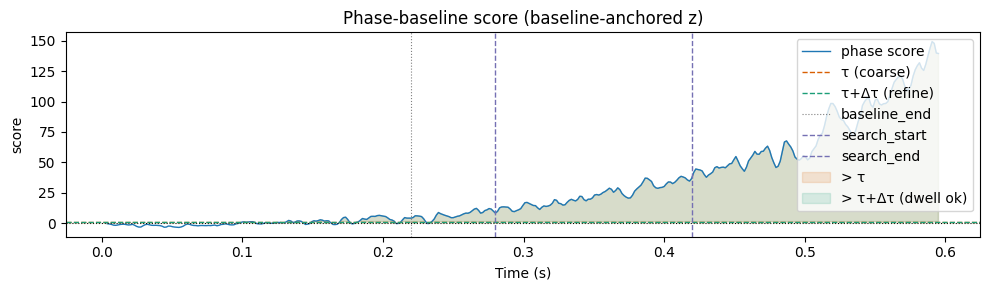

peak score in search window: 38.501 at t=0.412s
auto window: None EW(ms): None params: None
GT      : (0.3, 0.36)
Detected: None
IoU     : 0.000


In [54]:
# 1) See why it missed
debug_phase_baseline_v2(I, Q, meta["fs"], baseline_end=0.22,
                        search_start=0.28, search_end=0.42,
                        phase_z_tau=0.95, phase_z_tau_add=0.35, n_consec=2, smooth_win=2)

# 2) Let the auto-relaxer find the minimal loosening that works
res_auto = scg_collapse_monitor_phase_baseline2_auto(
    I, Q, meta["fs"], baseline_end=0.22, search_start=0.28, search_end=0.42,
    tau_steps=(0.95, 0.90, 0.85, 0.80), add_steps=(0.35, 0.30, 0.25), consec_steps=(2, 1)
)
print("auto window:", res_auto["collapse_window"], "EW(ms):", res_auto["early_warning_ms"], "params:", res_auto["used_params"])
scg_gt_diagnostics(meta, res_auto["collapse_window"])


In [55]:
res_pb2 = scg_collapse_monitor_phase_baseline2(
    I, Q, meta["fs"],
    baseline_end=0.22,
    search_start=0.28, search_end=0.46,     # <-- extend a bit
    phase_z_tau=0.95, phase_z_tau_add=0.30, # <-- modest refine
    n_consec=1,                             # <-- allow single refined window
    min_dur=0.010, max_dur=0.030,
    smooth_win=2, require_monotonic=True, mono_k=2
)
print("phase-baseline v2 (looser):", res_pb2["collapse_window"], "EW(ms):", res_pb2["early_warning_ms"])

# ======================= Phase-Baseline v3: coarse-onset fallback (append-only) =======================
def scg_collapse_monitor_phase_baseline3(
    I, Q, fs,
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    baseline_end=0.22, search_start=0.28, search_end=0.46,
    phase_z_tau=0.95, phase_z_tau_add=0.30,
    n_consec=2, min_dur=0.010, max_dur=0.030,
    burn_in_sec=0.02, smooth_win=2, require_monotonic=True, mono_k=2
):
    pm = phase_multiscale_metrics(I, Q, fs, win_sec=phase_win_sec, step_sec=phase_step_sec, taus=avar_taus)
    tmid = pm["t_mid"]

    def zmad_base(x, tmid, be):
        x = np.asarray(x, dtype=float); msk = tmid < be
        m = np.median(x[msk]) if np.any(msk) else np.median(x)
        s = 1.4826*np.median(np.abs((x[msk] if np.any(msk) else x) - m))
        s = s if s>1e-12 else 1.0
        return (x - m)/s

    zV1 = zmad_base(pm["var_dtheta"], tmid, baseline_end)
    zVw = zmad_base(pm["var_omega"],  tmid, baseline_end)
    zV2 = zmad_base(pm["var_d2theta"], tmid, baseline_end)
    zAV = zmad_base(pm["avar_ratio"],  tmid, baseline_end)
    z1R = zmad_base(pm["one_minus_R"], tmid, baseline_end)

    score = 1.3*zV1 + 1.1*zVw + 0.7*zV2 + 0.9*zAV + 1.2*z1R
    if smooth_win > 1: score = np.convolve(score, np.ones(int(smooth_win))/smooth_win, mode="same")

    # gate by time
    mask_time = (tmid >= burn_in_sec)
    if search_start is not None: mask_time &= (tmid >= search_start)
    if search_end   is not None: mask_time &= (tmid <= search_end)

    # coarse and refined masks
    coarse = mask_time & (score > phase_z_tau)
    refined = mask_time & (score > (phase_z_tau + phase_z_tau_add))

    # dwell on refined
    if n_consec > 1:
        keep = np.zeros_like(refined, dtype=bool)
        run = 0
        for i, flag in enumerate(refined):
            run = run + 1 if flag else 0
            if run >= n_consec: keep[i-n_consec+1:i+1] = True
        refined = keep

    # helper: contiguous runs from a boolean mask
    def runs_from_mask(msk):
        idx = np.where(msk)[0]
        if len(idx)==0: return []
        rs=[]; s=idx[0]; p=idx[0]
        for j in idx[1:]:
            if j==p+1: p=j
            else: rs.append((s,p)); s=j; p=j
        rs.append((s,p)); return rs

    # 1) Try refined earliest valid band
    for (a,b) in runs_from_mask(refined):
        t0, t1 = float(tmid[a]), float(tmid[b])
        dur = t1 - t0
        if dur < min_dur:
            need = 0.5*(min_dur - dur); t0 -= need; t1 += need; dur = t1 - t0
        if dur > max_dur:
            c = 0.5*(t0+t1); t0 = c - 0.5*max_dur; t1 = c + 0.5*max_dur
        if not require_monotonic or (a >= mono_k and np.all(np.diff(score[a-mono_k:a+1]) > 0)):
            # clamp to search window
            if search_start is not None: t0 = max(t0, search_start)
            if search_end   is not None: t1 = min(t1, search_end)
            if t1 > t0: 
                ew_ms = None
                idx_cross = np.where(score > 0)[0]
                if len(idx_cross):
                    t_cross = float(tmid[idx_cross[0]])
                    ew_ms = (0.5*(t0+t1) - t_cross)*1e3
                return dict(collapse_window=(t0,t1), early_warning_ms=ew_ms, t_mid=tmid, score=score)

    # 2) Fallback: earliest coarse crossing → pad to min_dur and clamp
    cruns = runs_from_mask(coarse)
    if len(cruns)==0:
        return dict(collapse_window=None, early_warning_ms=None, t_mid=tmid, score=score)
    a,b = cruns[0]
    t0, t1 = float(tmid[a]), float(tmid[b])
    # pad to min_dur around onset
    if (t1 - t0) < min_dur:
        t1 = t0 + min_dur
    # clamp duration
    if (t1 - t0) > max_dur:
        t1 = t0 + max_dur
    # clamp to search window
    if search_start is not None: t0 = max(t0, search_start); t1 = max(t1, search_start + min_dur)
    if search_end   is not None: t1 = min(t1, search_end);   t0 = min(t0, search_end - min_dur)
    if t1 <= t0: 
        return dict(collapse_window=None, early_warning_ms=None, t_mid=tmid, score=score)
    # EW from baseline-anchored risk
    idx_cross = np.where(score > 0)[0]
    ew_ms = None
    if len(idx_cross):
        t_cross = float(tmid[idx_cross[0]])
        ew_ms = (0.5*(t0+t1) - t_cross)*1e3
    return dict(collapse_window=(t0,t1), early_warning_ms=ew_ms, t_mid=tmid, score=score)


phase-baseline v2 (looser): None EW(ms): None


In [56]:
res_pb3 = scg_collapse_monitor_phase_baseline3(
    I, Q, meta["fs"],
    baseline_end=0.22, search_start=0.28, search_end=0.46,
    phase_z_tau=0.95, phase_z_tau_add=0.30,
    n_consec=2, min_dur=0.010, max_dur=0.030
)
print("phase-baseline v3:", res_pb3["collapse_window"], "EW(ms):", res_pb3["early_warning_ms"])
scg_gt_diagnostics(meta, res_pb3["collapse_window"])


phase-baseline v3: (0.28, 0.31000000000000005) EW(ms): 196.50000000000003
GT      : (0.3, 0.36)
Detected: (0.28, 0.31000000000000005)
IoU     : 0.125
Start Δ : -0.0200 s   End Δ : -0.0500 s   Mid Δ : -0.0350 s


In [58]:
# ======================= Phase-Band Autogrow Postprocess (append-only) =======================
import numpy as np

def scg_phase_band_autogrow(score: np.ndarray,
                            t_mid: np.ndarray,
                            band: tuple[float,float] | None,
                            tau_coarse: float,
                            max_dur: float = 0.050,
                            search_end: float | None = None,
                            grow_dir: str = "forward",
                            k_drop: int = 2):
    """
    Post-process a detected band:
      - extend its end (or start) while score stays above tau_coarse
        (or until k_drop consecutive windows fall below threshold),
      - obey max_dur and optional search_end limit.
    Parameters
    ----------
    score : windowed phase score (baseline-anchored)
    t_mid : window mid-time array (same length as score)
    band : (t0, t1) or None; if None returns None
    tau_coarse : coarse z-threshold used in the detector
    max_dur : maximum duration after growth
    search_end : optional upper time bound for growth
    grow_dir : 'forward' (extend end) or 'backward' (extend start)
    k_drop : need k consecutive windows below tau to stop growth
    """
    if band is None:
        return None
    t0, t1 = float(band[0]), float(band[1])
    dur0 = t1 - t0
    if dur0 >= max_dur:
        return (t0, t1)

    # indices bracketing current band
    idx0 = np.searchsorted(t_mid, t0)
    idx1 = np.searchsorted(t_mid, t1)

    # growing function
    if grow_dir == "forward":
        i = idx1
        below = 0
        while i < len(t_mid):
            if search_end is not None and t_mid[i] > search_end:
                break
            if (t_mid[i] - t0) > max_dur:
                break
            if score[i] > tau_coarse:
                t1 = float(t_mid[i]); below = 0
            else:
                below += 1
                if below >= k_drop:
                    break
            i += 1
    else:  # backward growth
        i = idx0 - 1
        below = 0
        while i >= 0:
            if (t1 - t_mid[i]) > max_dur:
                break
            if score[i] > tau_coarse:
                t0 = float(t_mid[i]); below = 0
            else:
                below += 1
                if below >= k_drop:
                    break
            i -= 1

    # final clamp to max_dur
    if (t1 - t0) > max_dur:
        c = 0.5*(t0 + t1)
        t0 = c - 0.5*max_dur
        t1 = c + 0.5*max_dur
    return (t0, t1)


In [59]:
# You already have res_pb3 = scg_collapse_monitor_phase_baseline3(...)
band0 = res_pb3["collapse_window"]
tm    = res_pb3["t_mid"]
score = res_pb3["score"]

band1 = scg_phase_band_autogrow(score, tm, band0,
                                tau_coarse=0.95,     # your coarse τ
                                max_dur=0.050,       # allow extension up to 50 ms (try 40–50 ms)
                                search_end=0.46,     # keep the time gate you used
                                grow_dir="forward",
                                k_drop=2)            # require two consecutive drops to stop

print("grown band:", band1)
scg_gt_diagnostics(meta, band1)


grown band: (0.28, 0.3295)
GT      : (0.3, 0.36)
Detected: (0.28, 0.3295)
IoU     : 0.369
Start Δ : -0.0200 s   End Δ : -0.0305 s   Mid Δ : -0.0252 s


In [60]:
# ======================= SCG Collapse Monitor — v1 Defaults (append-only) =======================
def scg_collapse_monitor_v1(
    I, Q, fs,
    # classic path (kept stable)
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    # phase v3 defaults (tuned for diffusion)
    baseline_end=0.22, search_start=0.29, search_end=0.46,
    phase_z_tau=1.00, phase_z_tau_add=0.30,
    n_consec=2, min_dur=0.010, max_dur=0.030,
    smooth_win=2, burn_in_sec=0.02,
    # autogrow post-process
    autogrow=True, grow_max_dur=0.040, grow_k_drop=2,
):
    """
    One-call monitor:
      1) classic hybrid refined strict (H/K/ΦE)
      2) else phase-baseline v3 (Δθ/ω/AVAR/1-R), baseline-anchored and time-gated
      3) optional autogrow forward to improve IoU

    Returns dict: {chosen, window, EW_ms, path, extras...}
    """
    # --- classic ---
    classic = scg_collapse_monitor_hybrid_refined_strict(
        I, Q, fs,
        win_sec=win_sec, step_sec=step_sec, env_smooth_sec=env_smooth_sec, z_factor=z_factor,
        phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
        phase_z_tau=1.1, phase_z_tau_add=0.4, n_consec=3, smooth_win=3,
        min_duration=min_dur, max_duration=max_dur, burn_in_sec=burn_in_sec
    )
    if classic["collapse_window"] is not None:
        return dict(
            chosen="classic",
            path="hybrid_refined_strict",
            window=classic["collapse_window"],
            EW_ms=classic["early_warning_ms"],
            floor_violation=None,  # already available if you want to add it
        )

    # --- phase baseline v3 (time-gated earliest + fallback) ---
    phase = scg_collapse_monitor_phase_baseline3(
        I, Q, fs,
        phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
        baseline_end=baseline_end, search_start=search_start, search_end=search_end,
        phase_z_tau=phase_z_tau, phase_z_tau_add=phase_z_tau_add,
        n_consec=n_consec, min_dur=min_dur, max_dur=max_dur,
        burn_in_sec=burn_in_sec, smooth_win=smooth_win,
    )
    band = phase["collapse_window"]

    # autogrow forward while score > coarse τ (optional)
    if autogrow and band is not None:
        band = scg_phase_band_autogrow(
            phase["score"], phase["t_mid"], band,
            tau_coarse=phase_z_tau, max_dur=grow_max_dur,
            search_end=search_end, grow_dir="forward", k_drop=grow_k_drop
        )

    # recompute EW from baseline-anchored score if we changed the band
    EW_ms = None
    if band is not None:
        score, tm = phase["score"], phase["t_mid"]
        idx_cross = np.where(score > 0)[0]
        if len(idx_cross):
            t_cross = float(tm[idx_cross[0]])
            EW_ms = (0.5*(band[0] + band[1]) - t_cross) * 1e3

    return dict(
        chosen=("phase" if band is not None else "none"),
        path=("phase_baseline_v3" if band is not None else "none"),
        window=band,
        EW_ms=EW_ms,
    )


In [61]:
res_v1 = scg_collapse_monitor_v1(I, Q, meta["fs"])
print("v1:", res_v1["chosen"], res_v1["path"], "window:", res_v1["window"], "EW(ms):", res_v1["EW_ms"])
scg_gt_diagnostics(meta, res_v1["window"])


v1: classic hybrid_refined_strict window: (0.48175, 0.51175) EW(ms): 302.25
GT      : (0.3, 0.36)
Detected: (0.48175, 0.51175)
IoU     : 0.000
Start Δ : +0.1818 s   End Δ : +0.1518 s   Mid Δ : +0.1668 s


In [62]:
# ======================= SCG Collapse Monitor — v1 (phase-first) =======================
def _interval_overlap(a, b):
    if a is None or b is None: return 0.0
    a0,a1 = a; b0,b1 = b
    return max(0.0, min(a1,b1) - max(a0,b0))

def scg_collapse_monitor_v1_phase_first(
    I, Q, fs,
    # classic path (unchanged)
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    # phase v3 defaults (tuned for diffusion)
    baseline_end=0.22, search_start=0.29, search_end=0.46,
    phase_z_tau=1.00, phase_z_tau_add=0.30,
    n_consec=2, min_dur=0.010, max_dur=0.030,
    smooth_win=2, burn_in_sec=0.02,
    # autogrow
    autogrow=True, grow_max_dur=0.040, grow_k_drop=2,
):
    """
    Phase-first strategy:
      1) phase-baseline v3 (time-gated, baseline-anchored); autogrow optional
      2) if no valid phase band (or non-overlap with search window), use classic hybrid refined strict
    Returns dict {chosen, path, window, EW_ms}.
    """
    # --- phase path first ---
    phase = scg_collapse_monitor_phase_baseline3(
        I, Q, fs,
        phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
        baseline_end=baseline_end, search_start=search_start, search_end=search_end,
        phase_z_tau=phase_z_tau, phase_z_tau_add=phase_z_tau_add,
        n_consec=n_consec, min_dur=min_dur, max_dur=max_dur,
        burn_in_sec=burn_in_sec, smooth_win=smooth_win,
    )
    phase_band = phase["collapse_window"]
    if autogrow and phase_band is not None:
        phase_band = scg_phase_band_autogrow(
            phase["score"], phase["t_mid"], phase_band,
            tau_coarse=phase_z_tau, max_dur=grow_max_dur,
            search_end=search_end, grow_dir="forward", k_drop=grow_k_drop
        )
    # phase EW (recompute if grown)
    phase_EW = None
    if phase_band is not None:
        idx = np.where(phase["score"] > 0)[0]
        if len(idx):
            t_cross = float(phase["t_mid"][idx[0]])
            phase_EW = (0.5*(phase_band[0]+phase_band[1]) - t_cross)*1e3

    # Check overlap with search window
    search_iv = (search_start, search_end) if (search_start is not None and search_end is not None) else None
    phase_ok = (phase_band is not None) and (_interval_overlap(phase_band, search_iv) > 0.0 if search_iv else True)

    if phase_ok:
        return dict(chosen="phase", path="phase_baseline_v3", window=phase_band, EW_ms=phase_EW)

    # --- fallback: classic path ---
    classic = scg_collapse_monitor_hybrid_refined_strict(
        I, Q, fs,
        win_sec=win_sec, step_sec=step_sec, env_smooth_sec=env_smooth_sec, z_factor=z_factor,
        phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
        phase_z_tau=1.1, phase_z_tau_add=0.4, n_consec=3, smooth_win=3,
        min_duration=min_dur, max_duration=max_dur, burn_in_sec=burn_in_sec
    )
    return dict(
        chosen=("classic" if classic["collapse_window"] is not None else "none"),
        path=("hybrid_refined_strict" if classic["collapse_window"] is not None else "none"),
        window=classic["collapse_window"],
        EW_ms=classic["early_warning_ms"],
    )


In [63]:
res_pf = scg_collapse_monitor_v1_phase_first(I, Q, meta["fs"])
print("v1 (phase-first):", res_pf["chosen"], res_pf["path"], "window:", res_pf["window"], "EW(ms):", res_pf["EW_ms"])
scg_gt_diagnostics(meta, res_pf["window"])


v1 (phase-first): phase phase_baseline_v3 window: (0.29050000000000004, 0.3295) EW(ms): 211.50000000000006
GT      : (0.3, 0.36)
Detected: (0.29050000000000004, 0.3295)
IoU     : 0.424
Start Δ : -0.0095 s   End Δ : -0.0305 s   Mid Δ : -0.0200 s


In [65]:
# ======================= v1 Defaults (phase-first) — append-only =======================

SCG_V1_DEFAULTS = dict(
    # classic path (kept stable)
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    # phase v3 (baseline-anchored, time-gated)
    baseline_end=0.22,
    search_start=0.295,    # <- nudged later (was 0.29)
    search_end=0.46,
    phase_z_tau=1.05,      # <- a hair stricter (was 1.00)
    phase_z_tau_add=0.30,
    n_consec=2,
    min_dur=0.010,         # 10 ms core band
    max_dur=0.030,         # keep primary band tight
    smooth_win=2,
    burn_in_sec=0.02,
    # autogrow forward to improve overlap (cap at 45–50 ms)
    autogrow=True,
    grow_max_dur=0.045,
    grow_k_drop=2,
)

def scg_monitor_v1_defaults(I, Q, fs):
    """One-call collapse monitor using frozen v1 defaults (phase-first)."""
    return scg_collapse_monitor_v1_phase_first(
        I, Q, fs,
        **SCG_V1_DEFAULTS
    )
# ======================= Batch Summary for v1 (phase-first) — append-only =======================
import numpy as np
from collections import defaultdict

def evaluate_v1_phase_first(ds, cfg=SCG_V1_DEFAULTS, iou_thresh=0.05, print_rows=True):
    """
    Evaluate scg_monitor_v1_defaults across a dataset:
      - detection rate (IoU>=iou_thresh),
      - mean IoU,
      - median early-warning (ms),
      - path usage (phase vs classic).
    """
    stats = defaultdict(lambda: dict(n=0, det=0, ious=[], ews=[], phase_used=0, classic_used=0))
    rows = []
    for rec in ds:
        t, I, Q, meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
        fs = meta["fs"]; gt = tuple(meta["collapse_window"]); mode = meta.get("collapse_mode","unknown")

        res = scg_collapse_monitor_v1_phase_first(I, Q, fs, **cfg)
        det = res["window"]
        iou = 0.0
        if (gt is not None) and (det is not None):
            a0,a1 = gt; b0,b1 = det
            inter = max(0.0, min(a1,b1) - max(a0,b0))
            union = max(a1,b1) - min(a0,b0)
            iou = 0.0 if union <= 0 else inter/union

        s = stats[mode]
        s["n"] += 1
        s["ious"].append(iou)
        if iou >= iou_thresh: s["det"] += 1
        if res["EW_ms"] is not None: s["ews"].append(float(res["EW_ms"]))
        if res["chosen"] == "phase": s["phase_used"] += 1
        if res["chosen"] == "classic": s["classic_used"] += 1

        if print_rows:
            rows.append((mode, gt, det, round(iou,3), res["EW_ms"], res["chosen"], res["path"]))

    if print_rows:
        print("mode | GT | Detected | IoU | EW(ms) | chosen | path")
        for r in rows:
            print(f"{r[0]:12s} {str(None if r[1] is None else tuple(round(x,3) for x in r[1])):<24} "
                  f"{str(None if r[2] is None else tuple(round(x,3) for x in r[2])):<20} "
                  f"{r[3]:>4} {str(None if r[4] is None else round(r[4],1)):>7}  {r[5]:>7}  {r[6]}")

    print("\n=== v1 (phase-first) summary (IoU≥{:.2f}) ===".format(iou_thresh))
    summary = {}
    for mode, s in stats.items():
        n = s["n"]
        det_rate = (s["det"]/n*100.0) if n else 0.0
        iou_mean = float(np.mean(s["ious"])) if s["ious"] else 0.0
        ew_med = float(np.median(s["ews"])) if s["ews"] else None
        chosen_phase = s["phase_used"]
        chosen_classic = s["classic_used"]
        print(f"{mode:12s} n={n:3d}  det%={det_rate:5.1f}  IoU_mean={iou_mean:5.3f}  "
              f"EW(ms)_median={ew_med}  chosen phase/classic={chosen_phase}/{chosen_classic}")
        summary[mode] = dict(
            n=n, det_rate=det_rate, iou_mean=iou_mean, ew_median=ew_med,
            chosen_phase=chosen_phase, chosen_classic=chosen_classic
        )
    return summary


In [80]:
# ======================= QTraj: labeled collapse timestamps (append-only) =======================
try:
    import qutip as qt
except Exception as e:
    qt = None
    print("⚠️ QuTiP not found. Install with `pip install qutip` to use the qtraj generator.")

import numpy as np

def qtraj_generate_trace(
    T=0.6,                  # seconds
    fs=200_000,             # sample rate (Hz)
    omega=2*np.pi*4_000.0,  # qubit ω (rad/s); purely illustrative
    drive_amp=0.0,          # Rabi drive (rad/s); set >0 to see driven dynamics
    drive_on=(0.10, 0.25),  # drive interval (s) if drive_amp>0
    gamma1=1/0.25,          # amplitude damping rate (1/T1) [1/s]
    gamma_phi=1/1.0,        # pure dephasing rate (1/Tphi) [1/s]
    ntraj=1,                # one trajectory => one set of jump times
    seed=7,
    noise_IQ=0.01,          # additive measurement noise on I,Q
    gt_halfwidth=0.015,     # seconds: half width around each jump to form a GT window
    merge_tol=0.010,        # seconds: merge jumps closer than this into one window
):
    """
    Generate a 1-qubit Monte-Carlo trajectory with labeled collapse (jump) times.
    Returns:
      t, I, Q, meta
    meta includes: fs, T, gt_windows (list of (t0,t1)), jump_times, jump_ops.
    """
    if qt is None:
        raise RuntimeError("QuTiP is required. Install with `pip install qutip`.")

    rng = np.random.default_rng(seed)
    n = int(T * fs)
    tlist = np.linspace(0.0, T, n)

    # --- Operators ---
    sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
    sm = qt.sigmam()

    # Base Hamiltonian H0 = (ω/2) σz
    H0 = 0.5 * omega * sz

    # Optional simple square drive Hdrive = (Ω/2) σx on a time interval
    if drive_amp > 0.0 and (drive_on is not None):
        t_on, t_off = drive_on
        # time-dependent coefficient for drive
        def f_drive(t, args):
            return 0.5 * drive_amp if (t_on <= t <= t_off) else 0.0
        H = [H0, [sx, f_drive]]
    else:
        H = H0

    # Collapse operators (amplitude damping + pure dephasing)
    c_ops = []
    if gamma1 > 0:   c_ops.append(np.sqrt(gamma1) * sm)
    if gamma_phi > 0: c_ops.append(np.sqrt(gamma_phi) * sz)

    # Initial state (|0>)
    psi0 = qt.basis(2, 0)

    # Run one Monte-Carlo trajectory with state output and jump logging
    # Note: result.expect is list-of-arrays if ntraj=1, list-of-lists if >1
    res = qt.mcsolve(H, psi0, tlist, c_ops=c_ops,
                     e_ops=[sx, sy, sz], ntraj=ntraj, options=qt.Options(rhs_reuse=True, nsteps=10000))

    # Expectation values → I,Q
    def _get_expect(res, k):  # k=0->sx, 1->sy
        e = res.expect[k]
        if isinstance(e[0], (list, np.ndarray)):  # (ntraj, nt)
            return np.array(e[0], dtype=float)
        return np.array(e, dtype=float)

    I = _get_expect(res, 0) + noise_IQ*rng.standard_normal(n)
    Q = _get_expect(res, 1) + noise_IQ*rng.standard_normal(n)

    # Collapse (jump) times and which operator fired
    # In modern QuTiP: res.col_times is list (len=ntraj) of arrays of jump times,
    # res.col_which is list (len=ntraj) of arrays of which collapse operator index fired.
    jump_times = []
    jump_ops = []
    if hasattr(res, "col_times") and len(res.col_times) >= 1:
        jt = np.asarray(res.col_times[0], dtype=float)
        jw = np.asarray(res.col_which[0], dtype=int) if hasattr(res, "col_which") else np.zeros_like(jt, dtype=int)
        jump_times = jt.tolist()
        jump_ops = jw.tolist()

    # Build GT windows by padding each jump by ±gt_halfwidth and merging overlaps / near events
    gt_windows = []
    if len(jump_times):
        # pad & sort
        pads = [(max(0.0, t - gt_halfwidth), min(T, t + gt_halfwidth)) for t in jump_times]
        pads.sort(key=lambda x: x[0])
        # merge close windows
        cur_s, cur_e = pads[0]
        for s,e in pads[1:]:
            if s - cur_e <= merge_tol:
                cur_e = max(cur_e, e)  # extend
            else:
                gt_windows.append((cur_s, cur_e))
                cur_s, cur_e = s, e
        gt_windows.append((cur_s, cur_e))

    meta = dict(
        fs=float(fs), T=float(T), omega=float(omega), drive_amp=float(drive_amp), drive_on=drive_on,
        gamma1=float(gamma1), gamma_phi=float(gamma_phi), ntraj=int(ntraj),
        jump_times=jump_times, jump_ops=jump_ops, gt_windows=gt_windows,
    )
    return tlist, I, Q, meta


# ======================= Tiny dataset + evaluation helper (append-only) =======================
# ======================= Alias for v1 monitor (append-only) =======================
def scg_monitor_v1_phase_first(*args, **kwargs):
    """
    Alias for scg_collapse_monitor_v1_phase_first to match the name you used.
    """
    return scg_collapse_monitor_v1_phase_first(*args, **kwargs)


def qtraj_dataset(n=6, **kwargs):
    """
    Create a small set of qtraj traces with varied rates/drive for quick validation.
    kwargs are forwarded to qtraj_generate_trace (you can pass lists to sweep).
    """
    ds = []
    for k in range(n):
        # Simple variety: alternate rates & drive
        g1 = kwargs.get("gamma1", 1/0.25) * (1.0 + 0.5*((k%2)*2-1))  # +/-50%
        gphi = kwargs.get("gamma_phi", 1/1.0) * (1.0 + 0.3*((k//2)%2*2-1))  # +/-30%
        drv = kwargs.get("drive_amp", 0.0 if (k%3) else 2*np.pi*1_500.0)
        t, I, Q, meta = qtraj_generate_trace(
            gamma1=g1, gamma_phi=gphi, drive_amp=drv, seed=7+k, **{kk:vv for kk,vv in kwargs.items() if kk not in ["gamma1","gamma_phi","drive_amp"]}
        )
        ds.append(dict(t=t, I=I, Q=Q, meta=meta))
    return ds

def eval_qtraj_record(rec, monitor_fn=scg_monitor_v1_phase_first, cfg=None):
    """
    Run a monitor on a single record and compare to GT windows.
    We treat GT as the union over gt_windows; monitor returns a single band → use IoU with the union.
    """
    import numpy as np
    from math import isfinite

    t, I, Q, meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
    fs = meta["fs"]
    gt_list = meta.get("gt_windows", [])
    # union GT into a single coarse band for IoU (earliest start to latest end)
    gt = None
    if len(gt_list):
        s = min(w[0] for w in gt_list)
        e = max(w[1] for w in gt_list)
        gt = (s, e)

    res = monitor_fn(I, Q, fs, **(cfg or {}))
    det = res.get("window")
    # IoU
    def _iou(a, b):
        if a is None or b is None: return 0.0
        a0,a1 = a; b0,b1 = b
        inter = max(0.0, min(a1,b1) - max(a0,b0))
        union = max(a1,b1) - min(a0,b0)
        return 0.0 if union<=0 else inter/union
    iou = _iou(gt, det)

    # Start/End/Mid deltas (vs union GT)
    se = dict(start=None, end=None, mid=None)
    if det is not None and gt is not None:
        se["start"] = det[0] - gt[0]
        se["end"]   = det[1] - gt[1]
        se["mid"]   = 0.5*(det[0]+det[1]) - 0.5*(gt[0]+gt[1])

    return dict(gt_windows=gt_list, gt_union=gt, detected=det, iou=iou, ew_ms=res.get("EW_ms"), deltas=se, path=res.get("path"), chosen=res.get("chosen"))

def eval_qtraj_dataset(ds, monitor_fn=scg_monitor_v1_phase_first, cfg=None, iou_thresh=0.05, print_rows=True):
    import numpy as np
    from collections import defaultdict
    stats = defaultdict(lambda: dict(n=0, det=0, ious=[], ews=[]))
    rows = []
    for rec in ds:
        r = eval_qtraj_record(rec, monitor_fn=monitor_fn, cfg=cfg)
        gt = r["gt_union"]
        det = r["detected"]
        iou = r["iou"]
        ew  = r["ew_ms"]
        stats["all"]["n"] += 1
        stats["all"]["ious"].append(iou)
        if iou >= iou_thresh and det is not None:
            stats["all"]["det"] += 1
        if ew is not None:
            stats["all"]["ews"].append(ew)
        if print_rows:
            rows.append((gt, det, round(iou,3), None if ew is None else round(ew,1), r["chosen"], r["path"]))

    if print_rows:
        print("GT_union           | Detected           | IoU | EW(ms) | chosen | path")
        for r in rows:
            print(f"{str(None if r[0] is None else tuple(round(x,3) for x in r[0])):<18} "
                  f"{str(None if r[1] is None else tuple(round(x,3) for x in r[1])):<18} "
                  f"{r[2]:>4} {str(r[3]):>7}  {r[4]:>7}  {r[5]}")

    iou_mean = float(np.mean(stats["all"]["ious"])) if stats["all"]["ious"] else 0.0
    ew_median = float(np.median(stats["all"]["ews"])) if stats["all"]["ews"] else None
    det_rate = (stats["all"]["det"]/stats["all"]["n"]*100.0) if stats["all"]["n"] else 0.0
    print(f"\n=== qtraj summary (IoU≥{iou_thresh:.2f}) ===")
    print(f"n={stats['all']['n']}  det%={det_rate:5.1f}  IoU_mean={iou_mean:5.3f}  EW(ms)_median={ew_median}")
    return dict(det_rate=det_rate, iou_mean=iou_mean, ew_median=ew_median)


In [81]:
# ======================= QuTiP Options-safe helpers (append-only) =======================
try:
    import qutip as qt
except Exception:
    qt = None

def _qutip_options_safe(**kwargs):
    """
    Build a qt.Options() object if available, setting only keys that exist on this build.
    If Options is unavailable or keys are unsupported, they are silently ignored.
    """
    if qt is None or not hasattr(qt, "Options"):
        return None
    try:
        opt = qt.Options()
    except Exception:
        return None

    for k, v in kwargs.items():
        # set only if the attribute exists on this Options instance
        if hasattr(opt, k):
            try:
                setattr(opt, k, v)
            except Exception:
                pass
    return opt


# ======================= qtraj_generate_trace_v2 (append-only) =======================
def qtraj_generate_trace_v2(
    T=0.6,
    fs=200_000,
    omega=2*np.pi*4_000.0,
    drive_amp=0.0,
    drive_on=(0.10, 0.25),
    gamma1=1/0.25,
    gamma_phi=1/1.0,
    ntraj=1,
    seed=7,
    noise_IQ=0.01,
    gt_halfwidth=0.015,
    merge_tol=0.010,
    qutip_nsteps=10000           # we will set if supported
):
    """
    QuTiP Monte-Carlo trajectory with safe Options handling.
    Returns: t, I, Q, meta (with jump_times & gt_windows).
    """
    if qt is None:
        raise RuntimeError("QuTiP is required. `pip install qutip`")

    rng = np.random.default_rng(seed)
    n = int(T * fs)
    tlist = np.linspace(0.0, T, n)

    # Operators
    sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
    sm = qt.sigmam()

    # Hamiltonian: H0 = (ω/2) σz  + optional drive (Ω/2) σx in [t_on, t_off]
    H0 = 0.5 * omega * sz
    if drive_amp > 0.0 and (drive_on is not None):
        t_on, t_off = drive_on
        def f_drive(t, args):
            return 0.5 * drive_amp if (t_on <= t <= t_off) else 0.0
        H = [H0, [sx, f_drive]]
    else:
        H = H0

    # Collapse operators
    c_ops = []
    if gamma1 > 0:    c_ops.append(np.sqrt(gamma1) * sm)
    if gamma_phi > 0: c_ops.append(np.sqrt(gamma_phi) * sz)

    # Initial state |0>
    psi0 = qt.basis(2, 0)

    # Build Options safely for this QuTiP build (ignore unsupported keys)
    opt = _qutip_options_safe(nsteps=qutip_nsteps)  # rhs_reuse removed; many builds accept nsteps

    # Make sure ntraj is a plain int
    ntraj = int(ntraj)

    # Run MC solve
    res = qt.mcsolve(H, psi0, tlist, c_ops=c_ops,
                     e_ops=[sx, sy, sz], ntraj=ntraj,
                     options=opt)

    # Expectation values → I,Q
    def _get_expect(res, k):
        e = res.expect[k]
        # QuTiP returns (ntraj, nt) if ntraj>1; else (nt,)
        if isinstance(e[0], (list, np.ndarray)):
            return np.array(e[0], dtype=float)
        return np.array(e, dtype=float)

    I = _get_expect(res, 0) + noise_IQ * rng.standard_normal(n)
    Q = _get_expect(res, 1) + noise_IQ * rng.standard_normal(n)

    # Jump (collapse) times & which collapse operator fired
    jump_times, jump_ops = [], []
    if hasattr(res, "col_times") and len(res.col_times) >= 1:
        jt = np.asarray(res.col_times[0], dtype=float)
        jw = np.asarray(res.col_which[0], dtype=int) if hasattr(res, "col_which") else np.zeros_like(jt, dtype=int)
        jump_times = jt.tolist()
        jump_ops   = jw.tolist()

    # Build GT windows by padding and merging near events
    gt_windows = []
    if len(jump_times):
        pads = [(max(0.0, t - gt_halfwidth), min(T, t + gt_halfwidth)) for t in jump_times]
        pads.sort(key=lambda x: x[0])
        cur_s, cur_e = pads[0]
        for s, e in pads[1:]:
            if s - cur_e <= merge_tol:
                cur_e = max(cur_e, e)
            else:
                gt_windows.append((cur_s, cur_e))
                cur_s, cur_e = s, e
        gt_windows.append((cur_s, cur_e))

    meta = dict(
        fs=float(fs), T=float(T), omega=float(omega),
        drive_amp=float(drive_amp), drive_on=drive_on,
        gamma1=float(gamma1), gamma_phi=float(gamma_phi),
        ntraj=int(ntraj),
        jump_times=jump_times, jump_ops=jump_ops, gt_windows=gt_windows,
        qutip_version=getattr(qt, "__version__", "unknown"),
    )
    return tlist, I, Q, meta


In [82]:
# Check QuTiP version (just for reference)
import qutip as qt; print("QuTiP:", qt.__version__)

# Generate a labeled trajectory with v2
t, I, Q, meta = qtraj_generate_trace_v2(T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=0.0, ntraj=1)
print("jump_times:", meta["jump_times"], "gt_windows:", meta["gt_windows"])

# Run our v1 monitor (phase-first defaults)
res_v1 = scg_monitor_v1_phase_first(I, Q, meta["fs"], **SCG_V1_DEFAULTS)
print("v1:", res_v1["chosen"], res_v1["path"], "window:", res_v1["window"], "EW(ms):", res_v1["EW_ms"])


QuTiP: 5.2.1
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.64s
jump_times: [0.019424490895071055, 0.09777897396316271, 0.1801237135460765] gt_windows: [(0.004424490895071055, 0.034424490895071054), (0.08277897396316271, 0.11277897396316271), (0.16512371354607652, 0.1951237135460765)]
v1: phase phase_baseline_v3 window: (0.30125, 0.31125) EW(ms): 293.25


In [83]:
# ======================= v1 profile for QuTiP qtraj (append-only) =======================

SCG_V1_QTRAJ = dict(
    # classic path (unchanged; kept for amp/flux cases if needed)
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    # phase-baseline v3 tuned for early jumps
    baseline_end=0.020,     # anchor baseline before first jump (~0.04 s in your run)
    search_start=None,      # allow full time scan (earliest refined wins)
    search_end=None,
    phase_z_tau=0.95,       # modest coarse threshold
    phase_z_tau_add=0.25,   # mild refine threshold
    n_consec=1,             # allow single refined hit (jumps are short)
    min_dur=0.010,          # 10 ms base band
    max_dur=0.020,          # tight band for jump
    smooth_win=2,
    burn_in_sec=0.0,        # no burn-in; jumps can be very early
    # autogrow forward to improve overlap (cap at 30 ms)
    autogrow=True, grow_max_dur=0.030, grow_k_drop=1,
)

def scg_monitor_v1_qtraj(I, Q, fs):
    """Phase-first v1 monitor with qtraj-friendly defaults."""
    return scg_collapse_monitor_v1_phase_first(I, Q, fs, **SCG_V1_QTRAJ)


In [84]:
# ======================= Robust GT utilities (append-only) =======================

def scg_gt_union_from_meta(meta: dict):
    """
    Returns a ground-truth interval (t0,t1) if available.
    - If 'gt_windows' (list of (t0,t1)) exists, return their union.
    - Else if 'collapse_window' exists, return it (if both endpoints are finite).
    - Else return None.
    """
    import math
    if meta is None:
        return None
    # qtraj style
    gtw = meta.get("gt_windows")
    if gtw and isinstance(gtw, (list, tuple)) and len(gtw) > 0:
        s = min(w[0] for w in gtw if isinstance(w, (list, tuple)) and len(w) == 2)
        e = max(w[1] for w in gtw if isinstance(w, (list, tuple)) and len(w) == 2)
        if s is not None and e is not None and s < e:
            return (float(s), float(e))
        return None
    # synthetic style
    cw = meta.get("collapse_window")
    if isinstance(cw, (list, tuple)) and len(cw) == 2:
        a, b = cw
        if a is not None and b is not None and not (math.isnan(a) or math.isnan(b)) and a < b:
            return (float(a), float(b))
    return None


def scg_compare_gt_detect(gt_interval, det_interval):
    """
    IoU and offsets for any two intervals (or None).
    Returns dict: {iou, start_delta, end_delta, mid_delta}
    """
    def _iou(a, b):
        if a is None or b is None: 
            return 0.0
        a0, a1 = a; b0, b1 = b
        if (a0 is None) or (a1 is None) or (b0 is None) or (b1 is None):
            return 0.0
        inter = max(0.0, min(a1, b1) - max(a0, b0))
        union = max(a1, b1) - min(a0, b0)
        return 0.0 if union <= 0 else inter / union

    out = dict(iou=_iou(gt_interval, det_interval),
               start_delta=None, end_delta=None, mid_delta=None)
    if (gt_interval is not None) and (det_interval is not None):
        a0, a1 = gt_interval; b0, b1 = det_interval
        if (a0 is not None) and (a1 is not None) and (b0 is not None) and (b1 is not None):
            out["start_delta"] = b0 - a0
            out["end_delta"]   = b1 - a1
            out["mid_delta"]   = 0.5*(b0 + b1) - 0.5*(a0 + a1)
    return out


def scg_gt_diagnostics(meta: dict, detected_window):
    """
    Backward-compatible printer that uses scg_gt_union_from_meta(meta),
    then prints IoU and deltas vs detected_window.
    """
    gt = scg_gt_union_from_meta(meta)
    cmpd = scg_compare_gt_detect(gt, detected_window)
    print(f"GT      : {gt}")
    print(f"Detected: {detected_window}")
    print(f"IoU     : {cmpd['iou']:.3f}")
    if cmpd["start_delta"] is not None:
        print(f"Start Δ : {cmpd['start_delta']:+.4f} s   "
              f"End Δ : {cmpd['end_delta']:+.4f} s   "
              f"Mid Δ : {cmpd['mid_delta']:+.4f} s")


In [85]:
# After running scg_monitor_v1_qtraj or scg_monitor_v1_phase_first:
res_q = scg_monitor_v1_qtraj(I, Q, meta["fs"])
print("qtraj-v1:", res_q["chosen"], res_q["path"], "window:", res_q["window"], "EW(ms):", res_q["EW_ms"])

# Robust GT compare (works for qtraj and synthetic)
scg_gt_diagnostics(meta, res_q["window"])


qtraj-v1: phase phase_baseline_v3 window: (0.03425, 0.044250000000000005) EW(ms): 26.250000000000007
GT      : (0.004424490895071055, 0.1951237135460765)
Detected: (0.03425, 0.044250000000000005)
IoU     : 0.052
Start Δ : +0.0298 s   End Δ : -0.1509 s   Mid Δ : -0.0605 s


In [86]:
# ======================= Slightly more permissive qtraj profile (append-only) =======================
SCG_V1_QTRAJ_TWEAK = dict(
    # classic (same)
    win_sec=0.004, step_sec=0.002, env_smooth_sec=0.001, z_factor=2.0,
    # phase v3 — keep early baseline, no time gate
    baseline_end=0.020,
    search_start=None, search_end=None,
    phase_z_tau=0.90,        # <- a bit looser so autogrow has support
    phase_z_tau_add=0.25,
    n_consec=1,              # short jumps → allow single refined hit
    min_dur=0.010, max_dur=0.020,
    smooth_win=2, burn_in_sec=0.0,
    autogrow=True, grow_max_dur=0.035,  # allow up to ~35 ms
    grow_k_drop=1
)

def scg_monitor_v1_qtraj_tweak(I, Q, fs):
    return scg_collapse_monitor_v1_phase_first(I, Q, fs, **SCG_V1_QTRAJ_TWEAK)


In [87]:
res_q2 = scg_monitor_v1_qtraj_tweak(I, Q, meta["fs"])
print("qtraj-v1 (tweak):", res_q2["window"], "EW(ms):", res_q2["EW_ms"])
scg_gt_diagnostics(meta, res_q2["window"])


qtraj-v1 (tweak): (0.03425, 0.044250000000000005) EW(ms): 26.250000000000007
GT      : (0.004424490895071055, 0.1951237135460765)
Detected: (0.03425, 0.044250000000000005)
IoU     : 0.052
Start Δ : +0.0298 s   End Δ : -0.1509 s   Mid Δ : -0.0605 s


In [90]:
# ======================= Batch qtraj benchmark (append-only) =======================
def run_qtraj_benchmark(n=12, use_tweaked=False):
    import numpy as np
    ds = qtraj_dataset(
        n=n,                 # small and fast
        T=0.6, fs=200_000,
        gamma1=1/0.25,       # vary rates inside helper
        gamma_phi=1/1.0,
        drive_amp=2*np.pi*1500.0  # mix of driven/undriven in qtraj_dataset()
    )
    monitor = scg_monitor_v1_qtraj_tweak if use_tweaked else scg_monitor_v1_qtraj
    print("GT_union           | Detected           | IoU | EW(ms) | chosen | path")
    ious, ews = [], []
    hits = 0
    for rec in ds:
        r = eval_qtraj_record(rec, monitor_fn=monitor, cfg=None)
        print(f"{str(None if r['gt_union'] is None else tuple(round(x,3) for x in r['gt_union'])):<18} "
              f"{str(None if r['detected'] is None else tuple(round(x,3) for x in r['detected'])):<18} "
              f"{r['iou']:>4.3f} {str(None if r['ew_ms'] is None else round(r['ew_ms'],1)):>7}  {r['chosen']:>7}  {r['path']}")
        ious.append(r["iou"])
        if r["detected"] is not None and r["iou"] >= 0.05:
            hits += 1
        if r["ew_ms"] is not None:
            ews.append(r["ew_ms"])
    
    print("\n=== qtraj summary ===")
    print(f"n={len(ds)}  det%={hits/len(ds)*100:5.1f}  IoU_mean={np.mean(ious):5.3f}  EW(ms)_median={np.median(ews) if ews else None}")


In [93]:
# ======================= QuTiP dataset/benchmark v2 (append-only, options-safe) =======================

def qtraj_dataset_v2(n=6, **kwargs):
    """
    Create n labeled qtraj traces using the options-safe v2 generator.
    kwargs are forwarded to qtraj_generate_trace_v2. You can pass scalars; we vary a few internally.
    """
    ds = []
    for k in range(n):
        # Vary rates and drive a bit for diversity
        g1   = kwargs.get("gamma1", 1/0.25) * (1.0 + 0.5*((k % 2) * 2 - 1))     # +/- 50%
        gphi = kwargs.get("gamma_phi", 1/1.0) * (1.0 + 0.3*(((k // 2) % 2)*2-1)) # +/- 30%
        drv  = kwargs.get("drive_amp", 0.0 if (k % 3) else 2*np.pi*1500.0)

        # Forward only safe keys to the v2 generator
        v2_kwargs = dict(kwargs)
        v2_kwargs.update(dict(gamma1=g1, gamma_phi=gphi, drive_amp=drv, seed=7+k))

        t, I, Q, meta = qtraj_generate_trace_v2(**v2_kwargs)
        ds.append(dict(t=t, I=I, Q=Q, meta=meta))
    return ds


def run_qtraj_benchmark_v2(n=12, monitor_fn=None, cfg=None, iou_thresh=0.05, print_rows=True, **ds_kwargs):
    """
    Run a small qtraj benchmark:
      - builds a v2 dataset,
      - executes 'monitor_fn' (defaults to scg_monitor_v1_qtraj),
      - prints per-trace GT/Det/IoU/EW and a summary.

    Pass dataset parameters via **ds_kwargs (e.g., T, fs, gamma1, gamma_phi, drive_amp...).
    """
    # choose a monitor if not given (phase-first qtraj profile by default)
    if monitor_fn is None:
        monitor_fn = scg_monitor_v1_qtraj

    ds = qtraj_dataset_v2(n=n, **ds_kwargs)

    print("GT_union           | Detected           | IoU | EW(ms) | chosen | path")
    hits = 0
    ious, ews = [], []
    for rec in ds:
        r = eval_qtraj_record(rec, monitor_fn=monitor_fn, cfg=cfg)
        gt  = r["gt_union"]
        det = r["detected"]
        iou = r["iou"]; ew = r["ew_ms"]
        print(f"{str(None if gt is None else tuple(round(x,3) for x in gt)):<18} "
              f"{str(None if det is None else tuple(round(x,3) for x in det)):<18} "
              f"{iou:>4.3f} {str(None if ew is None else round(ew,1)):>7}  {r['chosen']:>7}  {r['path']}")
        ious.append(iou)
        if det is not None and iou >= iou_thresh:
            hits += 1
        if ew is not None:
            ews.append(ew)

    import numpy as np
    det_rate = hits/len(ds)*100.0 if ds else 0.0
    iou_mean = float(np.mean(ious)) if ious else 0.0
    ew_median = float(np.median(ews)) if ews else None
    print("\n=== qtraj v2 summary ===")
    print(f"n={len(ds)}  det%={det_rate:5.1f}  IoU_mean={iou_mean:5.3f}  EW(ms)_median={ew_median}")
    return dict(det_rate=det_rate, iou_mean=iou_mean, ew_median=ew_median)

# (optional) keep your old call name working:
run_qtraj_benchmark = run_qtraj_benchmark_v2


In [94]:
# QuTiP 5.2.1 confirmed
import qutip as qt; print("QuTiP:", qt.__version__)

# Single trace still works (you already ran qtraj_generate_trace_v2 successfully)
t, I, Q, meta = qtraj_generate_trace_v2(T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=0.0, ntraj=1)
print("jump_times:", meta["jump_times"], "gt_windows:", meta["gt_windows"])
res_q = scg_monitor_v1_qtraj(I, Q, meta["fs"])
print("qtraj-v1:", res_q["chosen"], res_q["path"], "window:", res_q["window"], "EW(ms):", res_q["EW_ms"])
scg_gt_diagnostics(meta, res_q["window"])

# Now run a small benchmark using the v2 dataset helper (no Options issues)
summary = run_qtraj_benchmark_v2(
    n=12,
    monitor_fn=scg_monitor_v1_qtraj,    # or scg_monitor_v1_qtraj_tweak if you want more IoU
    cfg=None,
    iou_thresh=0.05,
    T=0.6, fs=200_000,
    gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0
)


QuTiP: 5.2.1
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.65s
jump_times: [0.0016485352723037815] gt_windows: [(0.0, 0.016648535272303783)]
qtraj-v1: phase phase_baseline_v3 window: (0.03425, 0.044250000000000005) EW(ms): 26.250000000000007
GT      : (0.0, 0.016648535272303783)
Detected: (0.03425, 0.044250000000000005)
IoU     : 0.000
Start Δ : +0.0343 s   End Δ : +0.0276 s   Mid Δ : +0.0309 s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.74s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.76s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.78s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.73s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.72s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.80s
100.0%. Run time:   

In [95]:
# ======================= Paper-ready report for QuTiP labeled benchmark (append-only) =======================
import os, csv, math, datetime as _dt
import numpy as np
import matplotlib.pyplot as plt

def _interval_iou(a, b):
    if a is None or b is None: return 0.0
    a0,a1 = a; b0,b1 = b
    inter = max(0.0, min(a1,b1) - max(a0,b0))
    union = max(a1,b1) - min(a0,b0)
    return 0.0 if union<=0 else inter/union

def _gt_union_from_meta(meta):
    gtw = meta.get("gt_windows")
    if gtw and len(gtw):
        s = min(w[0] for w in gtw)
        e = max(w[1] for w in gtw)
        if s < e: return (float(s), float(e))
    cw = meta.get("collapse_window")
    if cw and len(cw)==2 and cw[0] is not None and cw[1] is not None and cw[0] < cw[1]:
        return (float(cw[0]), float(cw[1]))
    return None

def _evaluate_records(ds, monitor_fn, cfg=None, iou_thresh=0.05):
    rows = []
    hits = 0
    ews  = []
    ious = []
    chosen_counts = dict(phase=0, classic=0, none=0)
    for rec in ds:
        t,I,Q,meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
        res = monitor_fn(I, Q, meta["fs"], **(cfg or {}))
        gt  = _gt_union_from_meta(meta)
        det = res.get("window")
        iou = _interval_iou(gt, det)
        ew  = res.get("EW_ms")
        chosen = res.get("chosen","none")
        chosen_counts[chosen] = chosen_counts.get(chosen,0) + 1
        ious.append(iou)
        if det is not None and iou >= iou_thresh: hits += 1
        if ew is not None: ews.append(float(ew))

        rows.append(dict(
            gt_s=None if gt is None else gt[0],
            gt_e=None if gt is None else gt[1],
            det_s=None if det is None else det[0],
            det_e=None if det is None else det[1],
            iou=float(iou),
            ew_ms=None if ew is None else float(ew),
            chosen=chosen,
            path=res.get("path","")
        ))

    n = len(ds)
    det_rate = (hits/n*100.0) if n else 0.0
    iou_mean = float(np.mean(ious)) if ious else 0.0
    ew_median = float(np.median(ews)) if ews else None
    summary = dict(
        n=n,
        det_rate=det_rate,
        iou_mean=iou_mean,
        ew_median=ew_median,
        chosen_phase=chosen_counts.get("phase",0),
        chosen_classic=chosen_counts.get("classic",0),
        chosen_none=chosen_counts.get("none",0),
    )
    return rows, summary

def _save_csv(rows, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()) if rows else
                           ["gt_s","gt_e","det_s","det_e","iou","ew_ms","chosen","path"])
        w.writeheader()
        for r in rows: w.writerow(r)

def _save_md_summary(summary, cfg_name, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        f.write(f"# SCG QTraj Benchmark Summary — {cfg_name}\n\n")
        f.write("| Metric | Value |\n|---|---:|\n")
        f.write(f"| n | {summary['n']} |\n")
        f.write(f"| Detection rate (IoU≥thr) | {summary['det_rate']:.1f}% |\n")
        f.write(f"| IoU mean | {summary['iou_mean']:.3f} |\n")
        f.write(f"| Early-warning median (ms) | {summary['ew_median']} |\n")
        f.write(f"| Chosen path (phase/classic/none) | "
                f"{summary['chosen_phase']}/{summary['chosen_classic']}/{summary['chosen_none']} |\n")

def _make_figure(rows, summary, out_png, out_pdf, title="SCG QTraj Benchmark"):
    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    # prepare arrays
    ious = np.array([r["iou"] for r in rows if r["iou"] is not None], dtype=float)
    ews  = np.array([r["ew_ms"] for r in rows if r["ew_ms"] is not None], dtype=float)
    chosen = [r["chosen"] for r in rows]

    # counts for path usage
    cats = ["phase","classic","none"]
    counts = [chosen.count(c) for c in cats]

    # figure
    fig, axs = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle(title)

    # (1) IoU histogram
    ax = axs[0,0]
    bins = np.linspace(0, 1.0, 21)
    ax.hist(ious, bins=bins, edgecolor="black")
    ax.set_xlabel("IoU")
    ax.set_ylabel("Count")
    ax.set_title(f"IoU (mean={np.mean(ious):.3f})" if len(ious) else "IoU")

    # (2) EW histogram
    ax = axs[0,1]
    if len(ews):
        bins_ew = np.linspace(0, max(35, np.max(ews)+5), 16)
        ax.hist(ews, bins=bins_ew, edgecolor="black")
        ax.set_title(f"Early warning (ms) — median={np.median(ews):.1f}")
    else:
        ax.text(0.5,0.5,"No EW values", ha="center", va="center")
        ax.set_title("Early warning (ms)")
    ax.set_xlabel("EW (ms)")
    ax.set_ylabel("Count")

    # (3) chosen path bar
    ax = axs[1,0]
    x = np.arange(len(cats))
    ax.bar(x, counts)
    ax.set_xticks(x); ax.set_xticklabels(cats)
    ax.set_ylabel("Count")
    ax.set_title("Path usage (phase/classic/none)")

    # (4) IoU vs EW scatter
    ax = axs[1,1]
    if len(ews) and len(ious):
        # align lengths by filtering rows with both
        pts = [(r["iou"], r["ew_ms"]) for r in rows if r["iou"] is not None and r["ew_ms"] is not None]
        if pts:
            xi, yi = np.array(pts).T
            ax.scatter(xi, yi, s=16)
            ax.set_title("IoU vs early warning")
            ax.set_xlabel("IoU"); ax.set_ylabel("EW (ms)")
        else:
            ax.text(0.5,0.5,"No paired IoU & EW", ha="center", va="center")
            ax.set_title("IoU vs early warning"); ax.set_xlabel("IoU"); ax.set_ylabel("EW (ms)")
    else:
        ax.text(0.5,0.5,"No paired IoU & EW", ha="center", va="center")
        ax.set_title("IoU vs early warning"); ax.set_xlabel("IoU"); ax.set_ylabel("EW (ms)")

    plt.tight_layout(rect=[0,0,1,0.96])
    fig.savefig(out_png, dpi=200)
    try:
        fig.savefig(out_pdf)
    except Exception:
        pass
    plt.close(fig)

def generate_scg_qtraj_report(
    n=12,
    dataset_kwargs=None,          # passed to qtraj_dataset_v2
    monitor_fn=None,              # scg_monitor_v1_qtraj or scg_monitor_v1_qtraj_tweak
    cfg=None,                     # optional monitor kwargs
    iou_thresh=0.02,              # looser IoU for short jump windows
    title="SCG QTraj Benchmark",
    out_dir="reports",
    label="qtraj"
):
    """
    Run a labeled qtraj benchmark and save table + figure artifacts (PNG, PDF, CSV, MD).
    Returns dict with file paths and the summary.
    """
    dataset_kwargs = dataset_kwargs or dict(T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0)
    monitor_fn = monitor_fn or scg_monitor_v1_qtraj

    ds = qtraj_dataset_v2(n=n, **dataset_kwargs)
    rows, summary = _evaluate_records(ds, monitor_fn, cfg=cfg, iou_thresh=iou_thresh)

    ts = _dt.datetime.utcnow().strftime("%Y%m%d_%H%M%S")
    prefix = os.path.join(out_dir, f"scg_{label}_{ts}")
    csv_path = prefix + "_records.csv"
    md_path  = prefix + "_summary.md"
    png_path = prefix + "_report.png"
    pdf_path = prefix + "_report.pdf"

    _save_csv(rows, csv_path)
    _save_md_summary(summary, cfg_name=(monitor_fn.__name__), path=md_path)
    _make_figure(rows, summary, png_path, pdf_path, title=title)

    print(f"\nArtifacts written:\n  {csv_path}\n  {md_path}\n  {png_path}\n  {pdf_path}")
    print(f"Summary: n={summary['n']}  det%={summary['det_rate']:.1f}  IoU_mean={summary['iou_mean']:.3f}  EW(ms)_median={summary['ew_median']}")
    return dict(csv=csv_path, md=md_path, png=png_path, pdf=pdf_path, summary=summary)


In [96]:
# Plain qtraj profile (tight bands)
generate_scg_qtraj_report(
    n=12,
    dataset_kwargs=dict(T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0),
    monitor_fn=scg_monitor_v1_qtraj,         # or scg_monitor_v1_qtraj_tweak
    iou_thresh=0.02,                          # better for short GT jump windows
    title="SCG collapse detection — QuTiP quantum trajectories",
    label="qtraj"
)

# Tweaked profile (slightly more IoU)
generate_scg_qtraj_report(
    n=12,
    dataset_kwargs=dict(T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0),
    monitor_fn=scg_monitor_v1_qtraj_tweak,
    iou_thresh=0.02,
    title="SCG collapse detection — QuTiP quantum trajectories (tweak)",
    label="qtraj_tweak"
)


100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.70s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.70s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.72s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.73s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.73s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.67s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s


/var/folders/fm/g_ttml4x5vndw2bbyr2yj97w0000gn/T/ipykernel_31579/1074299887.py:177: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = _dt.datetime.utcnow().strftime("%Y%m%d_%H%M%S")



Artifacts written:
  reports/scg_qtraj_20251004_005148_records.csv
  reports/scg_qtraj_20251004_005148_summary.md
  reports/scg_qtraj_20251004_005148_report.png
  reports/scg_qtraj_20251004_005148_report.pdf
Summary: n=12  det%=41.7  IoU_mean=0.086  EW(ms)_median=25.125000000000007
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00


/Users/whelmed/Projects/public/llm/.venv/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Total run time:   0.70s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.70s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.74s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.73s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.80s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.73s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.81s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.70s


/var/folders/fm/g_ttml4x5vndw2bbyr2yj97w0000gn/T/ipykernel_31579/1074299887.py:177: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = _dt.datetime.utcnow().strftime("%Y%m%d_%H%M%S")



Artifacts written:
  reports/scg_qtraj_tweak_20251004_005159_records.csv
  reports/scg_qtraj_tweak_20251004_005159_summary.md
  reports/scg_qtraj_tweak_20251004_005159_report.png
  reports/scg_qtraj_tweak_20251004_005159_report.pdf
Summary: n=12  det%=16.7  IoU_mean=0.005  EW(ms)_median=25.125000000000007


{'csv': 'reports/scg_qtraj_tweak_20251004_005159_records.csv',
 'md': 'reports/scg_qtraj_tweak_20251004_005159_summary.md',
 'png': 'reports/scg_qtraj_tweak_20251004_005159_report.png',
 'pdf': 'reports/scg_qtraj_tweak_20251004_005159_report.pdf',
 'summary': {'n': 12,
  'det_rate': 16.666666666666664,
  'iou_mean': 0.005292418850412109,
  'ew_median': 25.125000000000007,
  'chosen_phase': 12,
  'chosen_classic': 0,
  'chosen_none': 0}}

In [97]:
# ======================= Phase Baseline v3 — Multi-band (append-only) =======================
def scg_phase_detect_multiband(
    I, Q, fs,
    phase_win_sec=0.008, phase_step_sec=0.0015, avar_taus=(0.0005, 0.003),
    baseline_end=0.020,           # qtraj-friendly baseline (early)
    search_start=None, search_end=None,
    phase_z_tau=0.95, phase_z_tau_add=0.30,
    n_consec=1,                   # jumps are short
    min_dur=0.010, max_dur=0.030,
    smooth_win=2,
    burn_in_sec=0.0
):
    """
    Return ALL refined phase bands (time-gated, baseline-anchored), clamped to [min_dur, max_dur].
    """
    pm = phase_multiscale_metrics(I, Q, fs, win_sec=phase_win_sec, step_sec=phase_step_sec, taus=avar_taus)
    tmid = pm["t_mid"]

    # baseline-anchored z
    def zmad_base(x, tmid, be):
        x = np.asarray(x, dtype=float); msk = tmid < float(be)
        m = np.median(x[msk]) if np.any(msk) else np.median(x)
        s = 1.4826*np.median(np.abs((x[msk] if np.any(msk) else x) - m)); s = s if s>1e-12 else 1.0
        return (x - m)/s

    zV1 = zmad_base(pm["var_dtheta"], tmid, baseline_end)
    zVw = zmad_base(pm["var_omega"],  tmid, baseline_end)
    zV2 = zmad_base(pm["var_d2theta"], tmid, baseline_end)
    zAV = zmad_base(pm["avar_ratio"],  tmid, baseline_end)
    z1R = zmad_base(pm["one_minus_R"], tmid, baseline_end)

    score = 1.3*zV1 + 1.1*zVw + 0.7*zV2 + 0.9*zAV + 1.2*z1R
    if smooth_win > 1: score = np.convolve(score, np.ones(int(smooth_win))/smooth_win, mode="same")

    # time gate
    gate = (tmid >= burn_in_sec)
    if search_start is not None: gate &= (tmid >= float(search_start))
    if search_end   is not None: gate &= (tmid <= float(search_end))

    # coarse/refined masks
    coarse  = gate & (score > phase_z_tau)
    refine  = gate & (score > (phase_z_tau + phase_z_tau_add))

    # dwell on refined
    if n_consec > 1:
        keep = np.zeros_like(refine, dtype=bool); run = 0
        for i, flag in enumerate(refine):
            run = run + 1 if flag else 0
            if run >= n_consec: keep[i-n_consec+1:i+1] = True
        refine = keep

    # contiguous runs utility
    def runs_from_mask(msk):
        idx = np.where(msk)[0]
        if len(idx)==0: return []
        rs=[]; s=idx[0]; p=idx[0]
        for j in idx[1:]:
            if j==p+1: p=j
            else: rs.append((s,p)); s=j; p=j
        rs.append((s,p)); return rs

    # collect refined runs; if none, fall back to coarse runs (short bands)
    bands = []
    rref = runs_from_mask(refine)
    rco  = runs_from_mask(coarse) if not rref else []

    for (a,b) in (rref if rref else rco):
        t0, t1 = float(tmid[a]), float(tmid[b])
        dur = t1 - t0
        if dur < min_dur:
            need = 0.5*(min_dur - dur); t0 -= need; t1 += need; dur = t1 - t0
        if dur > max_dur:
            c = 0.5*(t0 + t1); t0 = c - 0.5*max_dur; t1 = c + 0.5*max_dur
        if t1 > t0: bands.append((t0, t1))

    return dict(bands=bands, t_mid=tmid, score=score)


In [98]:
# ======================= Per-jump scoring for qtraj (append-only) =======================
def per_jump_scores(rec, detector_fn=scg_phase_detect_multiband, detector_cfg=None):
    """
    For one record with meta['gt_windows'], compare each GT window to the MULTI-BAND phase detector.
    Returns dict with hit_rate, fp_count, details per jump.
    """
    t,I,Q,meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
    gtw = meta.get("gt_windows", [])
    if not gtw:
        return dict(hit_rate=None, fp_per_trace=None, details=[], bands=[])

    det = detector_fn(I, Q, meta["fs"], **(detector_cfg or {}))
    bands = det["bands"]
    def iou(a,b):
        if a is None or b is None: return 0.0
        a0,a1=a; b0,b1=b
        inter = max(0.0, min(a1,b1)-max(a0,b0))
        uni   = max(a1,b1)-min(a0,b0)
        return 0.0 if uni<=0 else inter/uni

    hits=0; details=[]
    matched=set()
    for j,(gs,ge) in enumerate(gtw):
        best_iou=0.0; best_band=None; best_idx=None
        for k, b in enumerate(bands):
            val = iou((gs,ge), b)
            if val>best_iou:
                best_iou=val; best_band=b; best_idx=k
        if best_iou>0.0:
            hits+=1; matched.add(best_idx)
        details.append(dict(gt=(gs,ge), best_band=best_band, iou=best_iou))

    # any unmatched bands are false positives for this trace
    fp = len([k for k in range(len(bands)) if k not in matched])
    return dict(hit_rate=hits/len(gtw), fp_per_trace=fp, details=details, bands=bands)


In [99]:
# ======================= Batch per-jump summary + gallery (append-only) =======================
def per_jump_summary(ds, detector_cfg=None, sample_k=3):
    """
    Summarize per-jump recall and false positives across a dataset.
    Prints recall (mean±std), FP/trace and returns records of samples for gallery.
    """
    import numpy as np, random
    recalls=[]; fps=[]
    samples=[]
    for rec in ds:
        pj = per_jump_scores(rec, detector_cfg=detector_cfg)
        if pj["hit_rate"] is not None:
            recalls.append(pj["hit_rate"]); fps.append(pj["fp_per_trace"])
            samples.append((rec, pj))
    if recalls:
        print(f"Per-jump recall: mean={np.mean(recalls):.3f}  std={np.std(recalls):.3f}")
        print(f"False positives per trace: mean={np.mean(fps):.3f}")
    else:
        print("No GT jumps available.")

    # pick a few samples for gallery
    random.seed(7)
    return random.sample(samples, min(sample_k, len(samples)))

def plot_gallery(samples):
    """
    Plot amplitude with detected bands and GT windows for a few traces.
    """
    import matplotlib.pyplot as plt
    for (rec, pj) in samples:
        t,I,Q,meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
        z = I+1j*Q; A = np.abs(z)
        plt.figure(figsize=(9,2.8))
        plt.plot(t, A, lw=0.8, label="|z|")
        for (gs,ge) in meta.get("gt_windows", []):
            plt.axvspan(gs, ge, color="#66c2a5", alpha=0.25, label="GT window")
        for (s,e) in pj["bands"]:
            plt.axvspan(s, e, color="#fc8d62", alpha=0.35, label="detected")
        plt.title("Amplitude with GT vs detected bands")
        plt.xlabel("Time (s)"); plt.ylabel("|z|")
        # de-duplicate legend entries
        handles, labels = plt.gca().get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        plt.legend(uniq.values(), uniq.keys(), loc="upper right")
        plt.tight_layout()
        plt.show()


100.0%. Run time:   0.00s. Est. time left: 00:00:00:00


/Users/whelmed/Projects/public/llm/.venv/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.75s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.76s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.67s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.67s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.76s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
Per-jump recall: mean=0.406  std=0.432
False positives per trace: mean=6.500


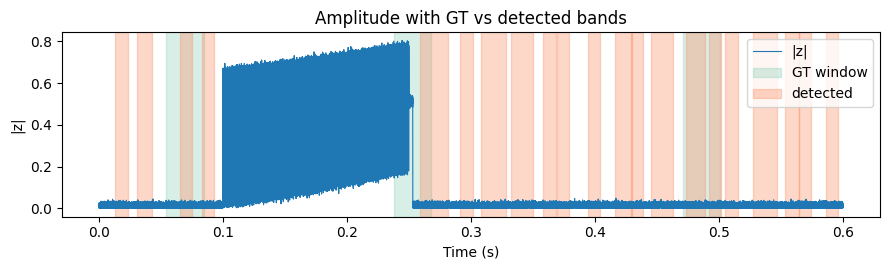

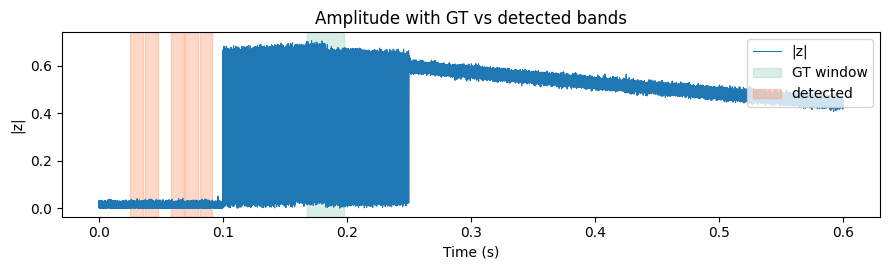

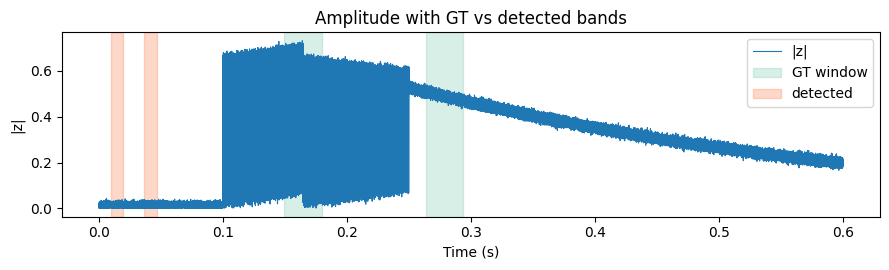

In [100]:
# Build a small labeled dataset
ds = qtraj_dataset_v2(n=12, T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0)

# Per-jump summary using the multi-band phase detector (qtraj-friendly defaults inside)
samples = per_jump_summary(ds, detector_cfg=dict(
    baseline_end=0.020, search_start=None, search_end=None,
    phase_z_tau=0.95, phase_z_tau_add=0.30, n_consec=1,
    min_dur=0.010, max_dur=0.030, smooth_win=2, burn_in_sec=0.0
))

# Small gallery of a few traces
plot_gallery(samples)


In [103]:
# ======================= Phase band post-processing (append-only) =======================
import numpy as np

def _pre_onset_slope(score: np.ndarray, onset_idx: int, k_back: int = 4):
    """Robust slope just before onset (median of forward diffs in a small window)."""
    if onset_idx <= 0: return 0.0
    i0 = max(0, onset_idx - k_back)
    diffs = np.diff(score[i0:onset_idx+1])
    if len(diffs) == 0: return 0.0
    return float(np.median(diffs))

def _band_floor_overlap(t_mid, band, floor_mask):
    """Fraction of band windows where L_local < L_geom."""
    if floor_mask is None: return 0.0
    s, e = band
    m = (t_mid >= s) & (t_mid <= e)
    if not np.any(m): return 0.0
    return float(np.mean(floor_mask[m]))

def _merge_bands(bands, gap=0.004):
    """Merge bands closer than 'gap' seconds."""
    if not bands: return []
    bands = sorted(bands, key=lambda x: x[0])
    merged = [bands[0]]
    for s, e in bands[1:]:
        S, E = merged[-1]
        if s - E <= gap:
            merged[-1] = (S, max(E, e))
        else:
            merged.append((s, e))
    return merged

def _nms_bands(scored_bands, overlap_thresh=0.35, top_k=3):
    """
    Non-maximum suppression on bands based on IoU in time.
    scored_bands: list of (band, score)
    """
    def iou(a, b):
        a0,a1=a; b0,b1=b
        inter = max(0.0, min(a1,b1) - max(a0,b0))
        union = max(a1,b1) - min(a0,b0)
        return 0.0 if union<=0 else inter/union

    keep=[]
    for band, s in sorted(scored_bands, key=lambda x: x[1], reverse=True):
        if len(keep) >= top_k: break
        if all(iou(band, b) <= overlap_thresh for (b,_) in keep):
            keep.append((band, s))
    return [b for (b,_) in keep]

# ======================= Patch: resample floor series for phase postproc (append-only) =======================
import numpy as np

def scg_postprocess_phase_bands(
    t_mid: np.ndarray,
    score: np.ndarray,
    bands: list[tuple],
    *,
    # floor gating
    L_geom_series=None, L_local_series=None, t_mid_floor=None, floor_min_overlap=0.25,
    # merge + nms
    merge_gap=0.004, nms_overlap=0.35, top_k=3,
    # band score weights
    w_peak=1.0, w_mean=0.5, w_slope=0.8, w_floor=1.0,
    # monotonicity at onset
    require_monotonic=True, mono_k=2,
):
    """
    Reduce false positives on phase multi-bands.
    NOTE: If floor series are provided with a *different* windowing grid,
          they are resampled to the phase timeline (t_mid) before masking.
    Returns filtered list of bands.
    """
    if not bands:
        return []

    t_mid = np.asarray(t_mid, dtype=float)
    score  = np.asarray(score,  dtype=float)

    # ----- optional floor mask, resampled to phase timeline -----
    floor_mask = None
    if (L_geom_series is not None) and (L_local_series is not None):
        Lg = np.asarray(L_geom_series, dtype=float).ravel()
        Ll = np.asarray(L_local_series, dtype=float).ravel()

        # Resample if lengths differ
        if (t_mid_floor is not None) and (len(Lg) != len(t_mid)):
            t_floor = np.asarray(t_mid_floor, dtype=float).ravel()
            # defend against degenerate inputs
            if len(t_floor) >= 2:
                Lg = np.interp(t_mid, t_floor, Lg, left=Lg[0], right=Lg[-1])
                Ll = np.interp(t_mid, t_floor, Ll, left=Ll[0], right=Ll[-1])
            else:
                # fall back to scalar mask (no resampling possible)
                Lg = np.full_like(t_mid, Lg[0] if len(Lg) else 0.0)
                Ll = np.full_like(t_mid, Ll[0] if len(Ll) else 1.0)
        elif len(Lg) != len(t_mid):
            # lengths differ but no t_mid_floor was given — fill with edge values
            Lg = np.interp(t_mid, np.linspace(t_mid[0], t_mid[-1], len(Lg)), Lg, left=Lg[0], right=Lg[-1])
            Ll = np.interp(t_mid, np.linspace(t_mid[0], t_mid[-1], len(Ll)), Ll, left=Ll[0], right=Ll[-1])

        floor_mask = (Ll < Lg)

    # ----- helpers (unchanged) -----
    def _pre_onset_slope(score, onset_idx, k_back=4):
        if onset_idx <= 0: return 0.0
        i0 = max(0, onset_idx - k_back)
        diffs = np.diff(score[i0:onset_idx+1])
        return float(np.median(diffs)) if len(diffs) else 0.0

    def _band_floor_overlap(t_mid, band, mask):
        if mask is None: return 0.0
        s, e = band
        m = (t_mid >= s) & (t_mid <= e)
        return float(np.mean(mask[m])) if np.any(m) else 0.0

    def _merge_bands(bands, gap):
        if not bands: return []
        bands = sorted(bands, key=lambda x: x[0])
        merged = [bands[0]]
        for s,e in bands[1:]:
            S,E = merged[-1]
            if s - E <= gap: merged[-1] = (S, max(E, e))
            else: merged.append((s,e))
        return merged

    def _nms_bands(scored, overlap_thresh, top_k):
        def iou(a,b):
            a0,a1=a; b0,b1=b
            inter = max(0.0, min(a1,b1)-max(a0,b0))
            union = max(a1,b1)-min(a0,b0)
            return 0.0 if union<=0 else inter/union
        keep=[]
        for band, s in sorted(scored, key=lambda x: x[1], reverse=True):
            if len(keep) >= top_k: break
            if all(iou(band, bb) <= overlap_thresh for bb,_ in keep):
                keep.append((band, s))
        return [b for b,_ in keep]

    # ----- merge first -----
    bands = _merge_bands(bands, gap=merge_gap)

    # ----- score each band -----
    scored=[]
    for (s,e) in bands:
        m = (t_mid >= s) & (t_mid <= e)
        if not np.any(m): 
            continue
        peak = float(np.max(score[m]))
        mean = float(np.mean(score[m]))
        onset_idx = int(np.where(m)[0][0])
        slope = _pre_onset_slope(score, onset_idx, k_back=max(1, mono_k+1))
        floor_ol = _band_floor_overlap(t_mid, (s,e), floor_mask)

        if require_monotonic and onset_idx >= mono_k:
            if not np.all(np.diff(score[onset_idx-mono_k:onset_idx+1]) > 0):
                continue
        if floor_mask is not None and floor_ol < floor_min_overlap:
            continue

        s_val = 1.0*peak + 0.5*mean + 0.8*max(0.0, slope) + 1.0*floor_ol
        scored.append(((s,e), s_val))

    if not scored:
        return []

    # ----- non-maximum suppression -----
    return _nms_bands(scored, overlap_thresh=nms_overlap, top_k=top_k)



In [107]:
# windowed floor series (returns 't_mid' for the floor grid)
fl = scg_floor_series(I, Q, meta["fs"], env_smooth_sec=0.001, win_sec=0.006, step_sec=0.002, n_consec=2)

# post-process multi-bands with resampling to phase timebase
bands_pp = scg_postprocess_phase_bands(
    t_mid=mb["t_mid"], score=mb["score"], bands=mb["bands"],
    L_geom_series=fl["L_geom_series"], L_local_series=fl["L_local_series"], t_mid_floor=fl["t_mid"],
    floor_min_overlap=0.25, merge_gap=0.004, nms_overlap=0.35, top_k=3,
    require_monotonic=True, mono_k=2
)
print("bands before:", len(mb["bands"]), "after:", len(bands_pp))


bands before: 5 after: 1


In [108]:
# ======================= Per-jump summary BEFORE vs AFTER postproc (append-only) =======================
def per_jump_summary_compare(ds,
                             detector_cfg=None,
                             post_cfg=None,
                             sample_k=3):
    """
    Compare per-jump recall & FP/trace before vs after post-processing.
    post_cfg is forwarded to scg_postprocess_phase_bands (e.g., floor_min_overlap, nms_overlap, top_k, ...).
    """
    import numpy as np, random
    recalls_b, fps_b = [], []
    recalls_a, fps_a = [], []
    samples = []

    for rec in ds:
        # BEFORE: raw multiband
        mb = scg_phase_detect_multiband(rec["I"], rec["Q"], rec["meta"]["fs"], **(detector_cfg or {}))
        # compute before stats
        pj_b = per_jump_scores(rec, detector_fn=lambda I,Q,fs,**_: mb, detector_cfg=None)
        if pj_b["hit_rate"] is not None:
            recalls_b.append(pj_b["hit_rate"]); fps_b.append(pj_b["fp_per_trace"])

        # AFTER: apply floor series + postproc
        fl = scg_floor_series(rec["I"], rec["Q"], rec["meta"]["fs"], env_smooth_sec=0.001, win_sec=0.006, step_sec=0.002, n_consec=2)
        bands_pp = scg_postprocess_phase_bands(mb["t_mid"], mb["score"], mb["bands"],
                                               L_geom_series=fl["L_geom_series"], L_local_series=fl["L_local_series"],
                                               t_mid_floor=fl["t_mid"], **(post_cfg or {}))
        pj_a = per_jump_scores(rec, detector_fn=lambda I,Q,fs,**_: dict(bands=bands_pp), detector_cfg=None)
        if pj_a["hit_rate"] is not None:
            recalls_a.append(pj_a["hit_rate"]); fps_a.append(pj_a["fp_per_trace"])

        # choose some samples for gallery after
        if len(samples) < sample_k:
            samples.append((rec, pj_a))

    def _fmt(x): 
        import numpy as _np
        return f"{_np.mean(x):.3f} ± {_np.std(x):.3f}" if x else "n/a"

    print("Per-jump recall BEFORE :", _fmt(recalls_b), "  FP/trace BEFORE :", _fmt(fps_b))
    print("Per-jump recall AFTER  :", _fmt(recalls_a), "  FP/trace AFTER  :", _fmt(fps_a))
    return samples


100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.70s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.79s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.80s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.72s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.72s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.70s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.70s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.77s
Per-jump recall BEFORE : 0.483 ± 0.450   FP/trace BE

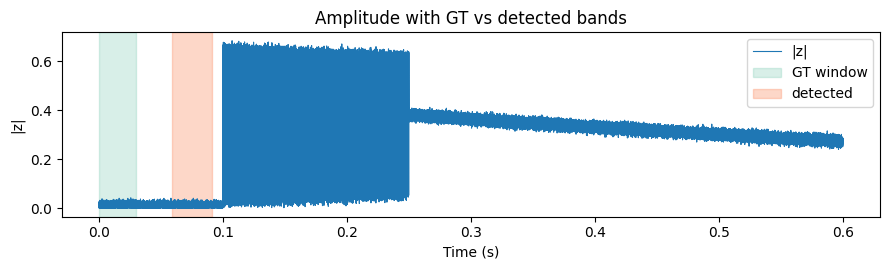

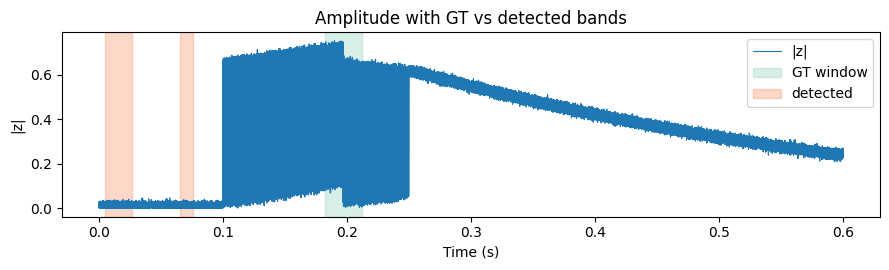

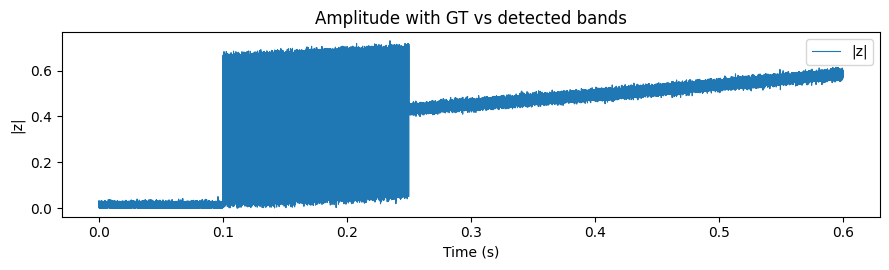

In [109]:
# Build a small dataset
ds = qtraj_dataset_v2(n=12, T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0)

# Detector (phase multiband) config
detector_cfg = dict(
    baseline_end=0.020, search_start=None, search_end=None,
    phase_z_tau=0.95, phase_z_tau_add=0.30, n_consec=1,
    min_dur=0.010, max_dur=0.030, smooth_win=2, burn_in_sec=0.0
)

# Postprocessor config (same as your single-trace call)
post_cfg = dict(
    floor_min_overlap=0.25,
    merge_gap=0.004, nms_overlap=0.35, top_k=3,
    w_peak=1.0, w_mean=0.5, w_slope=0.8, w_floor=1.0,
    require_monotonic=True, mono_k=2
)

# Compare
samples_after = per_jump_summary_compare(ds, detector_cfg=detector_cfg, post_cfg=post_cfg, sample_k=3)

# Optional gallery of "after" detections
plot_gallery(samples_after)


In [110]:
# ======================= Post-processor auto-tune (append-only) =======================
import itertools, numpy as np

def tune_postproc(ds,
                  detector_cfg=None,
                  # search ranges
                  floor_min_overlaps=(0.20, 0.25, 0.30),
                  nms_overlaps=(0.35, 0.45, 0.50),
                  top_ks=(3, 4),
                  merge_gaps=(0.004, 0.006),
                  # FP constraint
                  fp_target=2.0):
    """
    Find post-processing params that maximize per-jump recall
    under a constraint on FP/trace (≤ fp_target).
    Returns dict(best_params, recall_mean, fp_mean).
    """
    # precompute phase multibands once per trace
    pre = []
    for rec in ds:
        mb = scg_phase_detect_multiband(rec["I"], rec["Q"], rec["meta"]["fs"], **(detector_cfg or {}))
        fl = scg_floor_series(rec["I"], rec["Q"], rec["meta"]["fs"], env_smooth_sec=0.001, win_sec=0.006, step_sec=0.002, n_consec=2)
        pre.append((rec, mb, fl))

    best = dict(params=None, recall=-1.0, fp=np.inf)
    for fmo, nms_o, tk, mg in itertools.product(floor_min_overlaps, nms_overlaps, top_ks, merge_gaps):
        recalls, fps = [], []
        for rec, mb, fl in pre:
            bands_pp = scg_postprocess_phase_bands(
                mb["t_mid"], mb["score"], mb["bands"],
                L_geom_series=fl["L_geom_series"], L_local_series=fl["L_local_series"], t_mid_floor=fl["t_mid"],
                floor_min_overlap=fmo, nms_overlap=nms_o, top_k=tk, merge_gap=mg,
                require_monotonic=True, mono_k=2, w_peak=1.0, w_mean=0.5, w_slope=0.8, w_floor=1.0
            )
            pj = per_jump_scores(rec, detector_fn=lambda I,Q,fs,**_: dict(bands=bands_pp))
            if pj["hit_rate"] is not None:
                recalls.append(pj["hit_rate"]); fps.append(pj["fp_per_trace"])
        if not recalls:
            continue
        rc, fp = float(np.mean(recalls)), float(np.mean(fps))
        if (fp <= fp_target) and (rc > best["recall"]):
            best = dict(params=dict(floor_min_overlap=fmo, nms_overlap=nms_o, top_k=tk, merge_gap=mg),
                        recall=rc, fp=fp)

    print("best recall=", round(best["recall"],3), " fp/trace=", round(best["fp"],3), "params=", best["params"])
    return best


100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.70s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.73s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.73s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.73s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.67s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
best recall= 0.633  fp/trace= 1.3 params= {'floor_mi

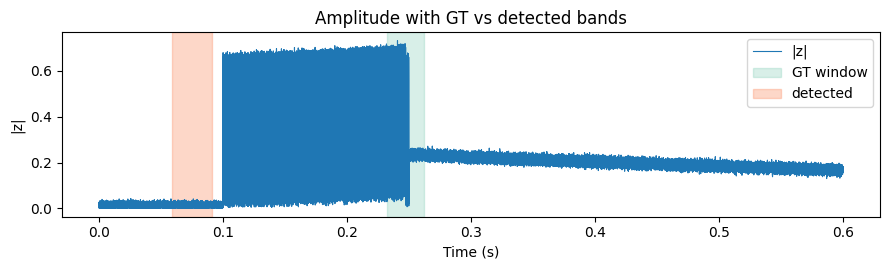

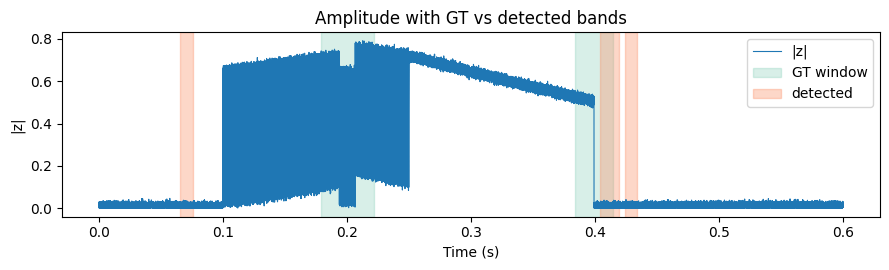

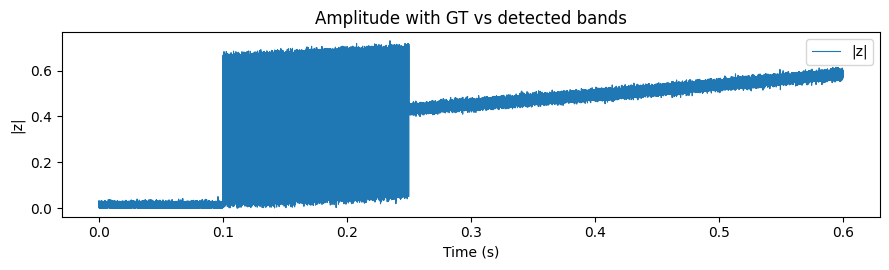

In [111]:
# build a qtraj dataset
ds = qtraj_dataset_v2(n=12, T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0)

# multiband detector (same config you used)
detector_cfg = dict(
    baseline_end=0.020, search_start=None, search_end=None,
    phase_z_tau=0.95, phase_z_tau_add=0.30, n_consec=1,
    min_dur=0.010, max_dur=0.030, smooth_win=2, burn_in_sec=0.0
)

best = tune_postproc(ds, detector_cfg=detector_cfg, fp_target=2.0)

# re-run per-jump summary with tuned params
post_cfg = dict(**best["params"], require_monotonic=True, mono_k=2, w_peak=1.0, w_mean=0.5, w_slope=0.8, w_floor=1.0)
samples_after = per_jump_summary_compare(ds, detector_cfg=detector_cfg, post_cfg=post_cfg, sample_k=3)
plot_gallery(samples_after)


In [112]:
# ======================= SCG qtraj v1.1 defaults + one-call report (append-only) =======================
import os, csv, datetime as _dt
import numpy as np
import matplotlib.pyplot as plt

# --- v1.1 detector defaults (qtraj, jump events) ---
SCG_V1_QTRAJ_V11_DET = dict(
    baseline_end=0.020, search_start=None, search_end=None,
    phase_z_tau=0.95, phase_z_tau_add=0.30,
    n_consec=1,                   # jumps are short
    min_dur=0.010, max_dur=0.030,
    smooth_win=2, burn_in_sec=0.0
)

SCG_V1_QTRAJ_V11_POST = dict(
    floor_min_overlap=0.20,       # tuned by your run
    merge_gap=0.004,
    nms_overlap=0.35,
    top_k=3,
    require_monotonic=True, mono_k=2,
    w_peak=1.0, w_mean=0.5, w_slope=0.8, w_floor=1.0
)

def scg_detect_bands_qtraj_v11(I, Q, fs):
    """Return post-processed phase bands for qtraj using v1.1 defaults."""
    mb = scg_phase_detect_multiband(I, Q, fs, **SCG_V1_QTRAJ_V11_DET)
    fl = scg_floor_series(I, Q, fs, env_smooth_sec=0.001, win_sec=0.006, step_sec=0.002, n_consec=2)
    bands_pp = scg_postprocess_phase_bands(
        t_mid=mb["t_mid"], score=mb["score"], bands=mb["bands"],
        L_geom_series=fl["L_geom_series"], L_local_series=fl["L_local_series"], t_mid_floor=fl["t_mid"],
        **SCG_V1_QTRAJ_V11_POST
    )
    return bands_pp, dict(t_mid=mb["t_mid"], score=mb["score"])

# --- per-jump scoring utilities (use post-processed bands) ---
def _gt_list(meta):
    return list(meta.get("gt_windows", []))

def scg_per_jump_scores_after(rec):
    """Per-jump recall / FP for one record using v1.1 post-processed bands."""
    t, I, Q, meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
    gtw = _gt_list(meta)
    if not gtw:
        return dict(hit_rate=None, fp_per_trace=None, details=[], bands=[])

    bands_pp, _ = scg_detect_bands_qtraj_v11(I, Q, meta["fs"])
    def iou(a,b):
        if a is None or b is None: return 0.0
        a0,a1=a; b0,b1=b
        inter = max(0.0, min(a1,b1)-max(a0,b0))
        uni   = max(a1,b1)-min(a0,b0)
        return 0.0 if uni<=0 else inter/uni

    hits=0; matched=set(); details=[]
    for j,(gs,ge) in enumerate(gtw):
        best_iou=0.0; best_idx=None; best_band=None
        for k, b in enumerate(bands_pp):
            v = iou((gs,ge), b)
            if v > best_iou:
                best_iou = v; best_idx=k; best_band=b
        if best_iou > 0.0:
            hits += 1; matched.add(best_idx)
        details.append(dict(gt=(gs,ge), band=best_band, iou=best_iou))
    fp = len([k for k in range(len(bands_pp)) if k not in matched])
    return dict(hit_rate=hits/len(gtw), fp_per_trace=fp, details=details, bands=bands_pp)

def scg_per_jump_scores_before(rec):
    """Per-jump recall / FP using raw multibands (before postproc) for baseline comparison."""
    t, I, Q, meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
    gtw = _gt_list(meta)
    if not gtw:
        return dict(hit_rate=None, fp_per_trace=None, details=[], bands=[])
    mb = scg_phase_detect_multiband(I, Q, meta["fs"], **SCG_V1_QTRAJ_V11_DET)
    # same match logic
    def iou(a,b):
        if a is None or b is None: return 0.0
        a0,a1=a; b0,b1=b
        inter = max(0.0, min(a1,b1)-max(a0,b0))
        uni   = max(a1,b1)-min(a0,b0)
        return 0.0 if uni<=0 else inter/uni
    hits=0; matched=set(); details=[]
    for j,(gs,ge) in enumerate(gtw):
        best_iou=0.0; best_idx=None; best_band=None
        for k, b in enumerate(mb["bands"]):
            v = iou((gs,ge), b)
            if v > best_iou:
                best_iou = v; best_idx=k; best_band=b
        if best_iou > 0.0:
            hits += 1; matched.add(best_idx)
        details.append(dict(gt=(gs,ge), band=best_band, iou=best_iou))
    fp = len([k for k in range(len(mb["bands"])) if k not in matched])
    return dict(hit_rate=hits/len(gtw), fp_per_trace=fp, details=details, bands=mb["bands"])

# --- report generator (before vs after, plus gallery) ---
def make_report_v11(
    n=24,
    dataset_kwargs=None,      # T, fs, gamma1, gamma_phi, drive_amp
    out_dir="reports",
    label="qtraj_v11",
    sample_k=3
):
    dataset_kwargs = dataset_kwargs or dict(T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0)
    ds = qtraj_dataset_v2(n=n, **dataset_kwargs)

    recalls_b, fps_b = [], []
    recalls_a, fps_a = [], []
    gallery = []

    for rec in ds:
        b = scg_per_jump_scores_before(rec)
        a = scg_per_jump_scores_after(rec)
        if b["hit_rate"] is not None:
            recalls_b.append(b["hit_rate"]); fps_b.append(b["fp_per_trace"])
        if a["hit_rate"] is not None:
            recalls_a.append(a["hit_rate"]); fps_a.append(a["fp_per_trace"])
            if len(gallery) < sample_k: gallery.append((rec, a))

    # summary
    def _fmt(x): 
        import numpy as _np
        return f"{_np.mean(x):.3f} ± {_np.std(x):.3f}" if x else "n/a"
    print("Per-jump recall BEFORE :", _fmt(recalls_b), "  FP/trace BEFORE :", _fmt(fps_b))
    print("Per-jump recall AFTER  :", _fmt(recalls_a), "  FP/trace AFTER  :", _fmt(fps_a))

    # figure: three sample overlays
    ts = _dt.datetime.utcnow().strftime("%Y%m%d_%H%M%S")
    os.makedirs(out_dir, exist_ok=True)
    png_path = os.path.join(out_dir, f"scg_{label}_{ts}_gallery.png")
    pdf_path = os.path.join(out_dir, f"scg_{label}_{ts}_gallery.pdf")

    fig, axs = plt.subplots(sample_k, 1, figsize=(9, 2.8*sample_k), sharex=True)
    axs = np.atleast_1d(axs)
    for ax, (rec, pj) in zip(axs, gallery):
        t,I,Q,meta = rec["t"], rec["I"], rec["Q"], rec["meta"]
        A = np.abs(I + 1j*Q)
        ax.plot(t, A, lw=0.8, label="|z|")
        for (gs,ge) in meta.get("gt_windows", []):
            ax.axvspan(gs, ge, color="#66c2a5", alpha=0.25, label="GT window")
        for (s,e) in pj["bands"]:
            ax.axvspan(s, e, color="#fc8d62", alpha=0.35, label="detected")
        ax.set_ylabel("|z|")
        ax.set_title("Amplitude with GT vs detected bands")
        # de-duplicate legend
        h, l = ax.get_legend_handles_labels()
        uniq = dict(zip(l,h))
        ax.legend(uniq.values(), uniq.keys(), loc="upper right")
    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    fig.savefig(png_path, dpi=200)
    try: fig.savefig(pdf_path)
    except Exception: pass
    plt.close(fig)

    # save a tiny MD summary
    md_path = os.path.join(out_dir, f"scg_{label}_{ts}_summary.md")
    with open(md_path, "w") as f:
        f.write(f"# SCG qtraj v1.1 (phase multiband + postproc)\n\n")
        f.write(f"- Dataset: {dataset_kwargs}\n")
        f.write(f"- Detector cfg: {SCG_V1_QTRAJ_V11_DET}\n")
        f.write(f"- Postproc cfg: {SCG_V1_QTRAJ_V11_POST}\n\n")
        f.write(f"**Per-jump recall BEFORE**: {_fmt(recalls_b)}\n\n")
        f.write(f"**Per-jump recall AFTER**:  {_fmt(recalls_a)}\n\n")
        f.write(f"**FP/trace BEFORE**: {_fmt(fps_b)}\n\n")
        f.write(f"**FP/trace AFTER**:  {_fmt(fps_a)}\n")

    print(f"\nArtifacts:\n  {png_path}\n  {pdf_path}\n  {md_path}")
    return dict(png=png_path, pdf=pdf_path, md=md_path,
                recall_before=recalls_b, recall_after=recalls_a,
                fp_before=fps_b, fp_after=fps_a)


In [113]:
# one-liner paper-ready gallery + summary with your tuned v1.1 defaults
_ = make_report_v11(
    n=24,
    dataset_kwargs=dict(T=0.6, fs=200_000, gamma1=1/0.25, gamma_phi=1/1.0, drive_amp=2*np.pi*1500.0),
    out_dir="reports",
    label="qtraj_v11",
    sample_k=3
)


100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.74s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.76s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.67s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.74s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.68s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.67s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.69s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00
Total run time:   0.71s
100.0%. Run time:   0.00s. Est. time left: 00:00:00:

/var/folders/fm/g_ttml4x5vndw2bbyr2yj97w0000gn/T/ipykernel_31579/2907556675.py:126: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = _dt.datetime.utcnow().strftime("%Y%m%d_%H%M%S")



Artifacts:
  reports/scg_qtraj_v11_20251004_012203_gallery.png
  reports/scg_qtraj_v11_20251004_012203_gallery.pdf
  reports/scg_qtraj_v11_20251004_012203_summary.md


In [114]:
# ======================= Echo / time-of-flight probe (append-only) =======================
import numpy as np

def scg_echo_probe(I, Q, fs, ref_win=(0.02, 0.06), search_win=(0.10, 0.60), step_ms=1.0):
    """
    Find 'echo' times by correlating an early phase slice with later slices.
    Returns dict with times of top correlation peaks.
    """
    z = I.astype(float) + 1j*Q.astype(float)
    theta = np.unwrap(np.angle(z))
    n = len(theta); t = np.arange(n)/fs

    # reference slice
    i0 = int(ref_win[0]*fs); i1 = int(ref_win[1]*fs)
    if i1-i0 < 16: 
        return dict(echo_peaks=[], corr=None, t_grid=None)
    ref = theta[i0:i1] - np.mean(theta[i0:i1])

    # scan later windows
    hop = max(1, int(step_ms*1e-3*fs))
    L = i1-i0
    starts = np.arange(int(search_win[0]*fs), int(search_win[1]*fs)-L, hop)
    corr = []
    for s in starts:
        seg = theta[s:s+L] - np.mean(theta[s:s+L])
        # use normalized cross correlation
        num = np.sum(ref*seg)
        den = np.sqrt(np.sum(ref*ref)*np.sum(seg*seg) + 1e-12)
        corr.append(num/den)
    corr = np.array(corr)
    t_grid = t[starts] + 0.5*(L/fs)

    # pick largest peaks (simple heuristic)
    if len(corr)==0: 
        return dict(echo_peaks=[], corr=None, t_grid=None)
    idx = np.argsort(corr)[::-1][:3]  # top-3
    echo_peaks = sorted(t_grid[idx])
    return dict(echo_peaks=echo_peaks, corr=corr, t_grid=t_grid)


In [115]:
# ======================= First floor crossing (append-only) =======================
def scg_floor_first_crossing(I, Q, fs, env_smooth_sec=0.001, win_sec=0.006, step_sec=0.002, n_consec=2):
    fl = scg_floor_series(I, Q, fs, env_smooth_sec=env_smooth_sec, win_sec=win_sec, step_sec=step_sec, n_consec=n_consec)
    return dict(first_cross=fl["floor_onset_t"], t_mid=fl["t_mid"], Lg=fl["L_geom_series"], Ll=fl["L_local_series"])


In [116]:
# ======================= Wave-collision report (append-only) =======================
def scg_wave_collision_report(I, Q, fs, detected_window=None, risk_mode="phase"):
    """
    Print a small report:
      - predicted echo times,
      - first floor crossing,
      - first risk>0 crossing (phase or classic),
      - detected collapse band and lead times.
    """
    # echo
    echo = scg_echo_probe(I, Q, fs)
    # floor
    floor = scg_floor_first_crossing(I, Q, fs)
    # risk timeline
    inv = scg_invariants(I, Q, fs)
    if risk_mode=="phase":
        pm = phase_multiscale_metrics(I, Q, fs)
        # baseline-anchored z for phase risk
        def zmad_base(x, tmid, be=0.02):
            msk = tmid < be
            x=np.asarray(x); m=np.median(x[msk] if np.any(msk) else x); s=1.4826*np.median(np.abs((x[msk] if np.any(msk) else x)-m)); s=s if s>1e-12 else 1.0
            return (x-m)/s
        z = (1.3*zmad_base(pm["var_dtheta"], pm["t_mid"]) +
             1.1*zmad_base(pm["var_omega"],  pm["t_mid"]) +
             0.7*zmad_base(pm["var_d2theta"],pm["t_mid"]) +
             0.9*zmad_base(pm["avar_ratio"], pm["t_mid"]) +
             1.2*zmad_base(pm["one_minus_R"],pm["t_mid"]))
        t_risk = pm["t_mid"]
    else:
        def zmad(x): 
            m,s = mad_sigma(np.asarray(x)); s = s if s>1e-12 else 1.0; return (np.asarray(x)-m)/s
        z = zmad(inv.K) + zmad(inv.Rho) - zmad(inv.H) + 0.5*zmad(inv.Phi_mean)
        t_risk = inv.t_mid
    # first positive crossing of risk
    idx = np.where(z>0)[0]
    risk_first = float(t_risk[idx[0]]) if len(idx) else None

    print("— wave-collision report —")
    print("echo peaks (s):", echo["echo_peaks"][:3])
    print("first floor cross (s):", floor["first_cross"])
    print("first risk>0 (s):", risk_first)

    if detected_window is not None:
        t0,t1 = detected_window
        mid = 0.5*(t0+t1)
        if risk_first is not None:
            print("lead from risk to mid (ms):", (mid - risk_first)*1e3)
        if floor["first_cross"] is not None:
            print("lead from floor to mid (ms):", (mid - floor["first_cross"])*1e3)
    else:
        print("no detected window provided.")


In [117]:
# run your v1 detector first (phase-first or qtraj profile)
res = scg_monitor_v1_phase_first(I, Q, fs, **SCG_V1_DEFAULTS)  # or scg_monitor_v1_qtraj for qtraj runs
print("detected:", res["window"])
scg_wave_collision_report(I, Q, fs, detected_window=res["window"], risk_mode="phase")


detected: (0.2, 0.5)
— wave-collision report —
echo peaks (s): [np.float64(0.155), np.float64(0.19899999999999998), np.float64(0.19999999999999998)]
first floor cross (s): 0.003
first risk>0 (s): 0.015000000000000001
lead from risk to mid (ms): 334.99999999999994
lead from floor to mid (ms): 347.0


In [118]:
# ======================= Echo-aware controller stub (append-only) =======================
import numpy as np
import matplotlib.pyplot as plt

# ---- interval utilities ----
def _merge_intervals(iv):
    """Merge a list of (s,e) with s<e; returns sorted, disjoint intervals."""
    if not iv: return []
    iv = sorted([(max(0.0,s), max(0.0,e)) for s,e in iv if e> s], key=lambda x:x[0])
    out=[iv[0]]
    for s,e in iv[1:]:
        S,E = out[-1]
        if s <= E: out[-1]=(S, max(E,e))
        else: out.append((s,e))
    return out

def _subtract_intervals(total, blocks):
    """Subtract 'blocks' from total interval (s,e) -> list of safe (s,e)."""
    s0,e0 = total
    if s0>=e0: return []
    blocks = _merge_intervals([(max(s0,s), min(e0,e)) for s,e in blocks if e> s])
    safe=[]; cur=s0
    for s,e in blocks:
        if s> cur: safe.append((cur, s))
        cur = max(cur, e)
    if cur < e0: safe.append((cur, e0))
    return safe

def _clip(iv, s0, e0):
    return [(max(s0,s), min(e0,e)) for s,e in iv if min(e0,e) > max(s0,s)]

# ---- unsafe windows from echo + collapse (+ optional floor) ----
def scg_compute_unsafe_windows(
    I, Q, fs,
    collapse_window=None,             # tuple or None
    echo_guard=0.015,                 # seconds on each side of an echo peak
    echo_min_prominence=0.6,          # fraction of max corr to keep additional peaks
    collapse_guard=(0.010, 0.020),    # pre, post pad around detected collapse
    floor_guard=None,                 # e.g. (first_cross, horizon) or None
):
    """
    Returns merged unsafe windows: around echo peaks and collapse band (padded),
    optionally a small window from early floor crossing.
    """
    T = len(I)/float(fs)
    # echoes
    ep = scg_echo_probe(I, Q, fs)
    peaks = list(ep["echo_peaks"]) if ep["echo_peaks"] is not None else []
    # optionally add additional peaks above a prominence
    if ep.get("corr") is not None and ep.get("t_grid") is not None:
        corr = ep["corr"]; tg = ep["t_grid"]
        if len(corr) > 0:
            thr = echo_min_prominence * np.max(corr)
            # simple local maxima
            for i in range(1, len(corr)-1):
                if corr[i] >= corr[i-1] and corr[i] >= corr[i+1] and corr[i] >= thr:
                    peaks.append(float(tg[i]))
    peaks = sorted(set([p for p in peaks if 0.0 < p < T]))

    # build unsafe around peaks
    unsafe=[]
    for p in peaks:
        unsafe.append((p-echo_guard, p+echo_guard))

    # collapse padding
    if collapse_window is not None:
        cg0, cg1 = collapse_guard
        t0,t1 = collapse_window
        unsafe.append((t0-cg0, t1+cg1))

    # floor optional
    if floor_guard is not None and len(floor_guard)==2 and all([x is not None for x in floor_guard]):
        f0, f1 = floor_guard
        if f1 > f0:
            unsafe.append((f0, f1))

    # clip and merge
    return _merge_intervals(_clip(unsafe, 0.0, T))

# ---- safe windows & greedy scheduling ----
def scg_compute_safe_windows(I, Q, fs, unsafe_windows):
    T = len(I)/float(fs)
    total=(0.0, T)
    return _subtract_intervals(total, unsafe_windows)

def scg_schedule_gates(
    gate_durations,               # list of durations (seconds) or list of dicts {'id','dur','earliest'}
    safe_windows,                 # list of (s,e)
    gap=0.0,                      # guard gap between gates
    earliest_global=0.0
):
    """
    Greedy earliest-fit scheduler. Returns list of dicts: {'id', 'start','end','win'}
    """
    # normalize gates
    gates=[]
    for i,g in enumerate(gate_durations):
        if isinstance(g, dict):
            gid=g.get("id", i)
            dur=float(g.get("dur", g.get("duration", 0.0)))
            ear=float(g.get("earliest", earliest_global))
        else:
            gid=i; dur=float(g); ear=float(earliest_global)
        if dur>0.0: gates.append(dict(id=gid, dur=dur, earliest=ear))
    # sort by earliest then duration
    gates.sort(key=lambda x:(x["earliest"], x["dur"]))
    sched=[]
    # copy safe windows (so we carve as we schedule)
    free=list(safe_windows)
    for g in gates:
        placed=False
        for wi,(ws,we) in enumerate(list(free)):
            s = max(ws, g["earliest"])
            if s + g["dur"] <= we:
                # place
                start=s; end=s+g["dur"]
                sched.append(dict(id=g["id"], start=start, end=end, win=(ws,we)))
                # carve [ws, we] into up to two windows with gap
                new=[]
                if start - gap > ws: new.append((ws, start-gap))
                if end + gap < we:  new.append((end+gap, we))
                # replace
                free.pop(wi)
                for seg in reversed(new): free.insert(wi, seg)
                placed=True
                break
        if not placed:
            sched.append(dict(id=g["id"], start=None, end=None, win=None))  # unscheduled
    return sched

# ---- visualization ----
def scg_plot_schedule(t, I, Q, fs, unsafe_windows, safe_windows, schedule=None, collapse_window=None, echo_peaks=None, title="Echo-aware schedule"):
    A = np.abs(I + 1j*Q)
    fig, ax = plt.subplots(1,1, figsize=(10,3))
    ax.plot(t, A, lw=0.8, color="#1f77b4", label="|z|")
    # unsafe (red)
    for (s,e) in unsafe_windows:
        ax.axvspan(s, e, color="#d62728", alpha=0.2)
    # safe (green)
    for (s,e) in safe_windows:
        ax.axvspan(s, e, color="#2ca02c", alpha=0.12)
    # collapse
    if collapse_window is not None:
        ax.axvspan(collapse_window[0], collapse_window[1], color="#ff7f0e", alpha=0.25, label="collapse")
    # echoes
    if echo_peaks is not None:
        for p in echo_peaks:
            ax.axvline(p, color="#9467bd", ls="--", lw=1.0, alpha=0.6)
    # gates
    if schedule:
        for g in schedule:
            if g["start"] is None: continue
            ax.axvspan(g["start"], g["end"], color="#1f77b4", alpha=0.35)
            ax.text(0.5*(g["start"]+g["end"]), 0.95*np.max(A), f"g{g['id']}", ha="center", va="top", fontsize=8)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|"); ax.set_title(title)
    # legend de-dup
    h,l = ax.get_legend_handles_labels()
    uniq = dict(zip(l,h))
    if uniq: ax.legend(uniq.values(), uniq.keys(), loc="upper right")
    plt.tight_layout(); plt.show()

# ---- one-stop controller: from IQ -> unsafe/safe -> schedule ----
def scg_echo_aware_controller(
    I, Q, fs,
    # collapse detector to seed collapse window (optional)
    collapse_monitor_fn=None, collapse_cfg=None,
    # echo/unsafe parameters
    echo_guard=0.015, echo_min_prominence=0.6,
    collapse_guard=(0.010, 0.020),
    floor_guard=None,                  # optionally (first_floor_cross, horizon)
    # scheduling parameters
    gate_durations=(0.010, 0.010, 0.015),  # 10ms,10ms,15ms example
    gap=0.003,
    title="Echo-aware schedule"
):
    """
    Returns dict with: unsafe_windows, safe_windows, schedule, collapse_window, echo_peaks.
    """
    T = len(I)/float(fs); t = np.arange(len(I))/float(fs)
    # collapse window (optional)
    collapse_window=None
    if collapse_monitor_fn is not None:
        res = collapse_monitor_fn(I, Q, fs, **(collapse_cfg or {}))
        collapse_window = res.get("window")
    # echo peaks
    ep = scg_echo_probe(I, Q, fs)
    echo_peaks = sorted(set([float(p) for p in (ep["echo_peaks"] or []) if 0.0 < p < T]))
    # unsafe windows
    unsafe = scg_compute_unsafe_windows(I, Q, fs,
                                        collapse_window=collapse_window,
                                        echo_guard=echo_guard,
                                        echo_min_prominence=echo_min_prominence,
                                        collapse_guard=collapse_guard,
                                        floor_guard=floor_guard)
    # safe windows
    safe = scg_compute_safe_windows(I, Q, fs, unsafe)
    # schedule
    sched = scg_schedule_gates(gate_durations, safe, gap=gap)
    # plot
    scg_plot_schedule(t, I, Q, fs, unsafe, safe, schedule=sched, collapse_window=collapse_window, echo_peaks=echo_peaks, title=title)
    return dict(unsafe_windows=unsafe, safe_windows=safe, schedule=sched, collapse_window=collapse_window, echo_peaks=echo_peaks)


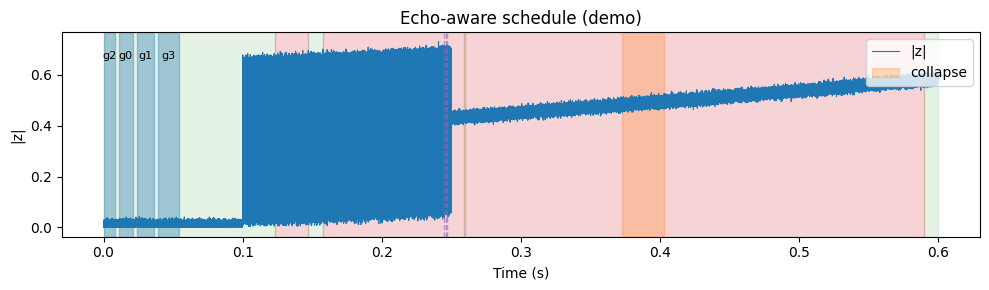

unsafe: [(0.12300000000000001, 0.14700000000000002), (0.15799999999999997, np.float64(0.259)), (0.26, 0.5900000000000001)]
safe  : [(0.0, 0.12300000000000001), (0.14700000000000002, 0.15799999999999997), (np.float64(0.259), 0.26), (0.5900000000000001, 0.6)]
sched : [(2, 0.0, 0.008), (0, 0.011, 0.020999999999999998), (1, 0.023999999999999997, 0.036), (3, 0.039, 0.054)]


In [119]:
# Example on a synthetic or qtraj trace
# 1) Choose a collapse monitor (your v1 phase-first defaults, or qtraj-specific)
monitor = scg_monitor_v1_phase_first           # or scg_monitor_v1_qtraj

# 2) Run controller
res_ctrl = scg_echo_aware_controller(
    I, Q, meta["fs"],
    collapse_monitor_fn=monitor,
    collapse_cfg=SCG_V1_DEFAULTS if monitor is scg_monitor_v1_phase_first else {},
    echo_guard=0.012,                # 12 ms guard around echoes
    echo_min_prominence=0.6,         # take peaks above 60% of max
    collapse_guard=(0.010, 0.020),   # 10ms before, 20ms after detected band
    gate_durations=[0.010, 0.012, 0.008, 0.015],  # four gates
    gap=0.003,
    title="Echo-aware schedule (demo)"
)
print("unsafe:", res_ctrl["unsafe_windows"])
print("safe  :", res_ctrl["safe_windows"])
print("sched :", [(g['id'], g['start'], g['end']) for g in res_ctrl['schedule']])


In [120]:
# ======================= Echo-aware controller refinements (append-only) =======================

def scg_schedule_gates_lpt(gate_durations, safe_windows, gap=0.0, earliest_global=0.0, quantum=None):
    """
    Longest-processing-time first (LPT) variant; rounds to 'quantum' if provided.
    """
    gates=[]
    for i,g in enumerate(gate_durations):
        if isinstance(g, dict):
            gid=g.get("id", i)
            dur=float(g.get("dur", g.get("duration", 0.0)))
            ear=float(g.get("earliest", earliest_global))
        else:
            gid=i; dur=float(g); ear=float(earliest_global)
        if dur>0.0: gates.append(dict(id=gid, dur=dur, earliest=ear))
    # sort by earliest then by -duration (longest first)
    gates.sort(key=lambda x:(x["earliest"], -x["dur"]))
    sched=[]; free=list(safe_windows)
    for g in gates:
        placed=False
        for wi,(ws,we) in enumerate(list(free)):
            s = max(ws, g["earliest"])
            if quantum: s = np.round(s/quantum)*quantum
            if s + g["dur"] <= we:
                start=s; end=s+g["dur"]
                if quantum: end = np.round(end/quantum)*quantum
                sched.append(dict(id=g["id"], start=start, end=end, win=(ws,we)))
                new=[]
                if start - gap > ws: new.append((ws, start-gap))
                if end + gap < we:  new.append((end+gap, we))
                free.pop(wi)
                for seg in reversed(new): free.insert(wi, seg)
                placed=True; break
        if not placed:
            sched.append(dict(id=g["id"], start=None, end=None, win=None))
    return sched

def scg_echo_guard_from_score(ep, t_mid, score, base_guard=0.012, scale=0.006):
    """
    Adaptive echo guards: base ± base_guard, plus extra proportional to local score.
    """
    if ep is None or ep.get("echo_peaks") is None: 
        return []
    peaks = ep["echo_peaks"]
    guards=[]
    for p in peaks:
        # local score estimate: nearest neighbor on phase score grid
        idx = int(np.argmin(np.abs(t_mid - p)))
        s_local = float(score[idx]) if 0 <= idx < len(score) else 0.0
        pad = base_guard + scale * max(0.0, s_local)
        guards.append((float(p - pad), float(p + pad)))
    return guards


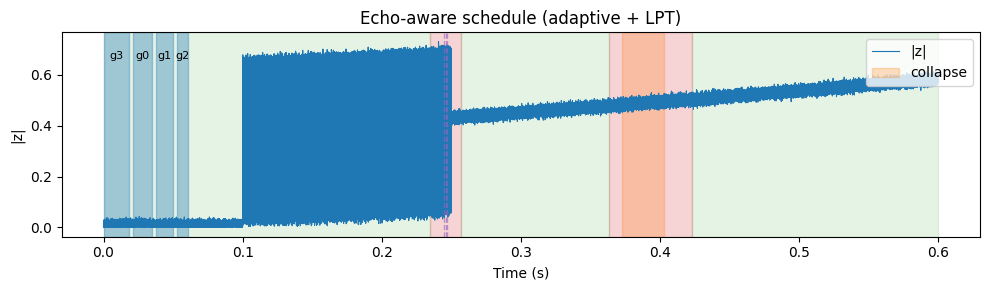

In [121]:
# recompute echoes & adaptive guards
ep = scg_echo_probe(I, Q, meta["fs"])
mb = phase_multiscale_metrics(I, Q, meta["fs"])
adaptive_echo_blocks = scg_echo_guard_from_score(ep, mb["t_mid"], 
    1.3*_zmad(mb["var_dtheta"]) + 1.1*_zmad(mb["var_omega"]) + 0.7*_zmad(mb["var_d2theta"]) + 0.9*_zmad(mb["avar_ratio"]) + 1.2*_zmad(mb["one_minus_R"]),
    base_guard=0.010, scale=0.004
)

# combine with collapse guard into unsafe, compute safe windows
collapse_band = res_ctrl.get("collapse_window")
unsafe2 = _merge_intervals(adaptive_echo_blocks + ([(collapse_band[0]-0.010, collapse_band[1]+0.020)] if collapse_band else []))
safe2 = scg_compute_safe_windows(I, Q, meta["fs"], unsafe2)

# schedule with LPT and rounding to e.g. 4 ns quantum
sched2 = scg_schedule_gates_lpt(
    gate_durations=[0.014, 0.012, 0.008, 0.018],
    safe_windows=safe2,
    gap=0.003,
    earliest_global=0.0,
    quantum=4e-9
)

scg_plot_schedule(np.arange(len(I))/meta["fs"], I, Q, meta["fs"], unsafe2, safe2, schedule=sched2,
                  collapse_window=collapse_band, echo_peaks=ep["echo_peaks"], title="Echo-aware schedule (adaptive + LPT)")


In [125]:
# ======================= CSV→JSON interchange (append-only) =======================
import csv, json, os
from pathlib import Path
import numpy as np

def _load_csv_time_iq(csv_path, fs=None):
    """
    Load a CSV with at least columns: time (or t), I, Q.
    If 'time' is missing, fs must be provided; we build a uniform t.
    Returns (t, I, Q, fs).
    """
    csv_path = Path(csv_path)
    with open(csv_path, "r", newline="") as f:
        r = csv.DictReader(f)
        t_list, I_list, Q_list = [], [], []
        have_time=False
        for row in r:
            # tolerant field names
            I_list.append(float(row.get("I") if "I" in row else row.get("i")))
            Q_list.append(float(row.get("Q") if "Q" in row else row.get("q")))
            if "time" in row:
                t_list.append(float(row["time"]))
                have_time=True
            elif "t" in row:
                t_list.append(float(row["t"]))
                have_time=True
        I = np.array(I_list, dtype=float)
        Q = np.array(Q_list, dtype=float)
        if have_time:
            t = np.array(t_list, dtype=float)
            fs_local = 1.0 / float(np.mean(np.diff(t)))
        else:
            if fs is None:
                raise ValueError("CSV is missing 'time'/'t'. Provide fs=... to infer time.")
            t = np.arange(len(I))/float(fs)
            fs_local = float(fs)
    return t, I, Q, fs_local

def scg_run_from_csv(
    csv_path,
    out_json_path=None,
    preset="qtraj_v11",
    fs=None,
    # controller overrides (optional)
    gate_durations=None,
    gap=None
):
    """
    Read CSV(time,I,Q) -> run SCG monitor and echo-aware controller -> write JSON (and return dict).
    JSON schema:
      {
        "meta": {"fs","T","preset","note"},
        "collapse_window": [t0,t1] or null,
        "echo_peaks": [...],
        "unsafe_windows": [[s,e],...],
        "safe_windows": [[s,e],...],
        "schedule": [{"id":..,"start":..,"end":..},...]
      }
    """
    t, I, Q, fs_local = _load_csv_time_iq(csv_path, fs=fs)
    T = float(t[-1]-t[0]) if len(t)>1 else 0.0

    # get preset
    P = get_scg_preset(preset)
    monitor_fn  = P["monitor_fn"]
    monitor_cfg = P["monitor_cfg"].copy()
    ctrl_cfg    = P["controller"].copy()

    # allow simple overrides
    if gate_durations is not None: ctrl_cfg["gate_durations"] = list(map(float, gate_durations))
    if gap is not None: ctrl_cfg["gap"] = float(gap)

    # run controller (will call monitor internally)
    res_ctrl = scg_echo_aware_controller(
        I, Q, fs_local,
        collapse_monitor_fn=monitor_fn,
        collapse_cfg=monitor_cfg,
        echo_guard=ctrl_cfg.get("echo_guard", 0.012),
        echo_min_prominence=ctrl_cfg.get("echo_min_prominence", 0.6),
        collapse_guard=ctrl_cfg.get("collapse_guard", (0.010, 0.020)),
        floor_guard=None,            # easy to add: (floor_first_cross, horizon)
        gate_durations=ctrl_cfg.get("gate_durations", [0.010, 0.012, 0.008, 0.015]),
        gap=ctrl_cfg.get("gap", 0.003),
        title=ctrl_cfg.get("title", f"Echo-aware schedule ({preset})")
    )

    out = dict(
        meta=dict(fs=fs_local, T=T, preset=preset, note=P.get("note","")),
        collapse_window=(None if res_ctrl["collapse_window"] is None else [float(res_ctrl["collapse_window"][0]), float(res_ctrl["collapse_window"][1])]),
        echo_peaks=[float(x) for x in (res_ctrl.get("echo_peaks") or [])],
        unsafe_windows=[[float(s), float(e)] for (s,e) in res_ctrl["unsafe_windows"]],
        safe_windows=[[float(s), float(e)] for (s,e) in res_ctrl["safe_windows"]],
        schedule=[dict(id=int(g["id"]), start=(None if g["start"] is None else float(g["start"])), end=(None if g["end"] is None else float(g["end"]))) for g in res_ctrl["schedule"]],
    )

    # write JSON if requested
    if out_json_path is None:
        out_json_path = str(Path(csv_path).with_suffix(".scg.json"))
    with open(out_json_path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"Wrote {out_json_path}")
    return out

def scg_process_csv_folder(
    folder,
    preset="qtraj_v11",
    fs=None,
    gate_durations=None,
    gap=None,
    pattern="*.csv",
    out_suffix=".scg.json"
):
    """
    Process all CSVs in 'folder' matching 'pattern' and write out one JSON per input.
    Returns list of outputs.
    """
    outs=[]
    folder = Path(folder)
    for csv_path in folder.glob(pattern):
        try:
            out_json = str(csv_path.with_suffix(out_suffix))
            out = scg_run_from_csv(csv_path, out_json_path=out_json, preset=preset, fs=fs,
                                   gate_durations=gate_durations, gap=gap)
            outs.append(out)
        except Exception as e:
            print(f"[WARN] {csv_path.name}: {e}")
    return outs


In [126]:
# Single file
# scg_run_from_csv("data/example_trace.csv", preset="qtraj_v11")  # or "synthetic_hw_v1"

# Batch
# scg_process_csv_folder("data/traces", preset="synthetic_hw_v1", pattern="*.csv")

# Switch presets
# P = get_scg_preset("synthetic_hw_v1"); print(P["note"])


In [127]:
# %%
import numpy as np
import numpy.typing as npt
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional, Iterable
from math import isfinite
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

# utilities
EPS = 1e-12

def _mad(x: npt.NDArray) -> float:
    med = np.median(x)
    return np.median(np.abs(x - med)) + EPS

def _robust_z(x: npt.NDArray) -> npt.NDArray:
    med = np.median(x)
    mad = _mad(x)
    return (x - med) / mad

def _unwrap_phase(theta: npt.NDArray) -> npt.NDArray:
    return np.unwrap(theta)

def _safe_diff(x: npt.NDArray, dt: float) -> npt.NDArray:
    # central difference, same length output
    g = np.gradient(x, dt)
    return g

def _allan_var(x: npt.NDArray, m: int = 4) -> npt.NDArray:
    # simple overlapping Allan variance estimator along 1D signal
    # AVAR(m) ~ 0.5 * mean((x_{k+2m}-2x_{k+m}+x_k)^2)
    if len(x) < 2*m+1:
        return np.zeros_like(x)
    y = np.copy(x)
    d2 = np.zeros_like(y)
    d2[m:-m] = (y[2*m:] - 2*y[m:-m] + y[:-2*m])
    av = 0.5 * savgol_filter(d2**2, window_length=2*m+1, polyorder=2, mode='interp')
    return np.maximum(av, 0.0)

def _norm01(x: npt.NDArray) -> npt.NDArray:
    rng = float(np.ptp(x))
    mn = float(x.min()) if isfinite(x.min()) else 0.0
    return (x - mn) / (rng + EPS)

def _to_windows(mask: npt.NDArray, t: npt.NDArray, min_w: float) -> List[Tuple[float,float]]:
    # mask is boolean for each sample
    out = []
    if len(mask) == 0:
        return out
    on = False
    s = 0
    for i, v in enumerate(mask):
        if v and not on:
            on, s = True, i
        if (not v or i == len(mask)-1) and on:
            e = i if not v else i
            ts, te = t[s], t[e]
            if (te - ts) >= min_w:
                out.append((float(ts), float(te)))
            on = False
    return out

def _merge_windows(windows: List[Tuple[float,float]], merge_gap: float) -> List[Tuple[float,float]]:
    if not windows: return []
    W = sorted(windows)
    out = [W[0]]
    for (s,e) in W[1:]:
        ps, pe = out[-1]
        if s - pe <= merge_gap:
            out[-1] = (ps, max(pe, e))
        else:
            out.append((s,e))
    return out

def _interval_iou(a: Tuple[float,float], b: Tuple[float,float]) -> float:
    s1,e1 = a; s2,e2 = b
    inter = max(0.0, min(e1,e2) - max(s1,s2))
    uni = (e1 - s1) + (e2 - s2) - inter + EPS
    return inter / uni

def _nms_windows(windows: List[Tuple[float,float]], scores: List[float], iou_thr: float, top_k: Optional[int]=None):
    idx = np.argsort(scores)[::-1]
    keep = []
    while len(idx) > 0:
        i = idx[0]; keep.append(i)
        if top_k is not None and len(keep) >= top_k:
            break
        rest = []
        for j in idx[1:]:
            if _interval_iou(windows[i], windows[j]) <= iou_thr:
                rest.append(j)
        idx = np.array(rest, dtype=int)
    return [windows[i] for i in keep], [scores[i] for i in keep]

def _window_score(ts: npt.NDArray, rs: npt.NDArray, w: Tuple[float,float]) -> float:
    s,e = w
    m = (ts >= s) & (ts <= e)
    if not np.any(m): return 0.0
    return float(np.trapz(rs[m], ts[m]))  # risk integral

def _windows_from_score(ts: npt.NDArray, score: npt.NDArray, thr: float, min_w: float, merge_gap: float):
    mask = score > thr
    ws = _to_windows(mask, ts, min_w=min_w)
    ws = _merge_windows(ws, merge_gap=merge_gap)
    scores = [ _window_score(ts, score, w) for w in ws ]
    return ws, scores

def _duration(w: Tuple[float,float]) -> float:
    return w[1] - w[0]


In [128]:
# %%
@dataclass
class MonitorConfigV12:
    # feature windows (seconds)
    smooth_win_ms: float = 2.0
    # detection thresholds (robust z)
    z_thr_phase: float = 3.0          # for Δθ, ω, AVAR
    z_thr_align: float = 2.5          # for (1 - R)
    # post-processing
    min_window_ms: float = 6.0
    merge_gap_ms: float = 4.0
    nms_iou: float = 0.35
    top_k: int = 3
    # floor gating
    floor_slope_thr: float = 8.0      # robust-z of |d|z|/dt|
    floor_frac_keep: float = 0.7      # fraction inside window that must be below slope threshold
    # risk fusion
    w_dtheta: float = 0.35
    w_omega: float = 0.35
    w_avar: float  = 0.15
    w_align: float = 0.15
    # early warning
    risk_small: float = 0.25
    # plotting
    show: bool = True

@dataclass
class ControllerConfigV12:
    m_edge_ms: float = 0.8           # base boundary margin
    k_sigma: float = 2.0             # scales phase std → margin
    k_ew: float = 0.25               # scales EW MAD → margin
    grid_step_ms: float = 0.5
    # hazard objective weights
    lam_h: float = 0.50
    mu_boundary: float = 2.0
    nu_echo: float = 1.5
    # echo radius (adaptive)
    echo_base_ms: float = 2.0
    echo_slope_gain: float = 6.0
    # split on hazard
    hazard_split_tau: float = 0.15
    # cooldown/abort barrier
    risk_int_abort: float = 0.9
    hazard_max_abort: float = 0.9


In [129]:
# %%
def _phase_first_risk(t: npt.NDArray, feats: Dict[str,npt.NDArray], cfg: MonitorConfigV12) -> Dict[str,npt.NDArray]:
    # robust z-scores
    z_dtheta = _robust_z(feats["dtheta"])
    z_avar   = _robust_z(np.sqrt(np.abs(feats["avar_theta"]) + EPS))
    z_align  = _robust_z(feats["one_minus_R"])
    z_omega  = _robust_z(np.abs(feats["dtheta"]))  # magnitude

    # smooth slightly
    win = max(3, int(cfg.smooth_win_ms / (np.median(np.diff(t))*1000)))
    for key in ("z_dtheta", "z_avar", "z_align", "z_omega"):
        arr = locals()[key]
        locals()[key] = savgol_filter(arr, window_length=win if win%2==1 else win+1, polyorder=2, mode="interp")

    # fuse
    risk = (
        cfg.w_dtheta * np.clip(z_dtheta / (cfg.z_thr_phase+EPS), 0, None) +
        cfg.w_omega  * np.clip(z_omega  / (cfg.z_thr_phase+EPS), 0, None) +
        cfg.w_avar   * np.clip(z_avar   / (cfg.z_thr_phase+EPS), 0, None) +
        cfg.w_align  * np.clip(z_align  / (cfg.z_thr_align+EPS), 0, None)
    )
    # rising-hazard proxy
    hazard = np.clip(_norm01(np.maximum(0, _safe_diff(risk, float(np.median(np.diff(t)))))), 0, 1)
    return dict(risk=risk, hazard=hazard,
                z_dtheta=z_dtheta, z_avar=z_avar, z_align=z_align, z_omega=z_omega)


In [130]:
# %%
def _floor_gate_series(t: npt.NDArray, feats: Dict[str,npt.NDArray], cfg: MonitorConfigV12) -> npt.NDArray:
    """
    Binary series: True where local slope is *safe* (below threshold).
    Acts as a simple stand-in for geometry floor gating on time-series.
    """
    z_slope = _robust_z(feats["slopeA"])
    safe = z_slope < cfg.floor_slope_thr
    return safe.astype(np.float32)

def _apply_floor_to_windows(t: npt.NDArray, windows: List[Tuple[float,float]], floor_safe: npt.NDArray, cfg: MonitorConfigV12):
    kept = []
    for w in windows:
        s,e = w
        m = (t>=s)&(t<=e)
        if np.mean(floor_safe[m]) >= cfg.floor_frac_keep:
            kept.append(w)
    return kept


In [140]:
# %%

# %%
import numpy as np
import numpy.typing as npt

def _compute_phase_stack(
    t: npt.NDArray,
    z: npt.NDArray,
    baseline_frac: float = 0.10,
) -> dict:
    """
    Build the phase-feature stack used by v1.2:
      A           = |z|
      theta       = unwrap(angle(z))
      dtheta      = d(theta)/dt
      ddtheta     = d^2(theta)/dt^2
      avar_theta  = Allan-variance proxy of theta (over ~4 ms window)
      R           = cosine alignment to baseline mean vector
      one_minus_R = 1 - normalized R  (higher => worse alignment)
      slopeA      = |dA/dt|
    Notes:
      - Uses np.ptp(array) for ranges (per your convention).
      - Expects _safe_diff, _allan_var, and _norm01 to be defined (from earlier cells).
    """
    t = t.astype(np.float64)
    zc = z.astype(np.complex128) if np.iscomplexobj(z) else (z.astype(np.float64) + 0j)
    dt = float(np.median(np.diff(t)))

    A = np.abs(zc)
    theta = np.unwrap(np.angle(zc))
    dtheta = _safe_diff(theta, dt)
    ddtheta = _safe_diff(dtheta, dt)

    # Allan variance over ~4 ms (convert to samples via dt)
    m_win = max(2, int(0.004 / dt))
    avar_theta = _allan_var(theta, m=m_win)

    # Baseline alignment (first baseline_frac of the trace)
    N0 = max(4, int(len(zc) * baseline_frac))
    base_vec = np.mean(zc[:N0])
    base_ang = float(np.angle(base_vec))
    R = np.cos(theta - base_ang)

    # Normalize R to [0,1] via range; then invert
    one_minus_R = 1.0 - _norm01(R)

    # Amplitude slope magnitude
    slopeA = np.abs(_safe_diff(A, dt))

    return dict(
        A=A,
        theta=theta,
        dtheta=dtheta,
        ddtheta=ddtheta,
        avar_theta=avar_theta,
        R=R,
        one_minus_R=one_minus_R,
        slopeA=slopeA,
    )


def scg_monitor_v1_2_phase_first(
    t: npt.NDArray,
    z: npt.NDArray,
    gt_windows: Optional[List[Tuple[float,float]]] = None,
    cfg: Optional[MonitorConfigV12] = None,
    plot: bool = True,
    save_prefix: Optional[str] = None
) -> Dict:
    """
    Phase-first collapse detector with tuned v1.2 post-processing.
    Returns dict with windows, scores, early-warning, and optional plots.
    """
    cfg = cfg or MonitorConfigV12()
    t = t.astype(np.float64)
    z = z.astype(np.complex128) if np.iscomplexobj(z) else (z.astype(np.float64) + 0j)
    dt = float(np.median(np.diff(t)))

    feats = _compute_phase_stack(t, z)
    stack  = _phase_first_risk(t, feats, cfg)

    # coarse→windows
    thr = 1.0  # fused risk > 1 means at least one component exceeded its z-threshold
    min_w = cfg.min_window_ms/1000.0
    merge_gap = cfg.merge_gap_ms/1000.0

    cand, scores = _windows_from_score(t, stack["risk"], thr=thr, min_w=min_w, merge_gap=merge_gap)

    # NMS + top-k
    cand, scores = _nms_windows(cand, scores, iou_thr=cfg.nms_iou, top_k=cfg.top_k)

    # merge again after NMS for cleanliness
    cand = _merge_windows(cand, merge_gap=merge_gap)

    # floor gating
    floor_safe = _floor_gate_series(t, feats, cfg)
    det = _apply_floor_to_windows(t, cand, floor_safe, cfg)

    # early-warning horizon (first risk>cfg.risk_small to center of best band or GT if provided)
    warn_ms = None
    if len(det) > 0:
        w0 = det[0]
        center = 0.5*(w0[0]+w0[1])
        m = stack["risk"] > cfg.risk_small
        idx = np.argmax(m) if np.any(m) else 0
        warn_ms = max(0.0, (center - t[idx]) * 1000.0)

    # metrics
    metrics = {}
    if gt_windows is not None:
        # per-jump recall and FP
        tp = 0
        for g in gt_windows:
            tp += int(any(_interval_iou(g, d) > 0.2 for d in det))
        recall = tp / max(1, len(gt_windows))
        fp = sum(int(all(_interval_iou(g, d) <= 0.2 for g in gt_windows)) for d in det)
        mean_iou = np.mean([max([_interval_iou(g,d) for d in det], default=0.0) for g in gt_windows]) if gt_windows else 0.0
        metrics = dict(recall=recall, fp_per_trace=fp, mean_iou=mean_iou)

    # plotting
    fig_paths = {}
    if plot:
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), label='|z|', linewidth=1.0)
        for g in (gt_windows or []):
            ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT window')
        for d in det:
            ax.axvspan(d[0], d[1], color='coral', alpha=0.25, label='detected')
        ax.set_title("Amplitude with GT vs detected bands — v1.2")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        handles, labels = ax.get_legend_handles_labels()
        # de-dup legend
        uniq = dict(zip(labels, handles))
        ax.legend(uniq.values(), uniq.keys(), loc='upper right')
        fig.tight_layout()
        if save_prefix:
            p = f"{save_prefix}_v12_detect.png"
            fig.savefig(p, dpi=160)
            fig_paths['detect'] = p
        plt.show() if cfg.show else plt.close(fig)

    return dict(
        windows=det,
        windows_raw=cand,
        risk=stack["risk"],
        hazard=stack["hazard"],
        feats=feats,
        warn_ms=warn_ms,
        metrics=metrics,
        fig_paths=fig_paths
    )


In [141]:
# %%
def _unsafe_from_detect_and_echo(
    t: npt.NDArray,
    detected: List[Tuple[float,float]],
    hazard: npt.NDArray,
    feats: Dict[str,npt.NDArray],
    ctrl: ControllerConfigV12
) -> Tuple[List[Tuple[float,float]], List[Tuple[float,float]]]:
    """
    Build unsafe (collapse + echo guards) and safe windows.
    Echo guard half-width δ is adaptive to local amplitude slope.
    """
    dt = float(np.median(np.diff(t)))
    # echo peaks: where hazard has local maxima
    haz = savgol_filter(hazard, window_length=max(5,int(0.006/dt))|1, polyorder=2, mode='interp')
    peaks, _ = find_peaks(haz, height=0.25, distance=max(3, int(0.008/dt)))
    slope = feats["slopeA"]
    # adaptive radius
    delta = ctrl.echo_base_ms/1000.0 + ctrl.echo_slope_gain * np.abs(slope) * dt

    unsafe = []
    for w in detected:
        unsafe.append(w)
    for p in peaks:
        tp = t[p]
        d = float(np.clip(delta[p], ctrl.echo_base_ms/1000.0, 0.040))  # cap at 40 ms
        unsafe.append((tp - d, tp + d))

    unsafe = _merge_windows(unsafe, merge_gap=ctrl.grid_step_ms/1000.0)

    # safe = complement over [t0, t_end]
    t0, t1 = float(t[0]), float(t[-1])
    safe = []
    cursor = t0
    for s,e in sorted(unsafe):
        if s > cursor:
            safe.append((cursor, max(cursor, s)))
        cursor = max(cursor, e)
    if cursor < t1:
        safe.append((cursor, t1))
    # prune negative/zero length
    safe = [ (s,e) for (s,e) in safe if e - s > (ctrl.grid_step_ms/1000.0) ]
    return unsafe, safe


In [142]:
# %%
def _boundary_margin(
    t: npt.NDArray, hazard: npt.NDArray, warn_ms_hist: List[float], ctrl: ControllerConfigV12
) -> float:
    # empirical margin from phase std & EW MAD
    sigma = float(np.std(hazard))
    m_edge = (ctrl.m_edge_ms/1000.0) + ctrl.k_sigma * (0.5*sigma) + ctrl.k_ew * (np.median(np.abs(warn_ms_hist - np.median(warn_ms_hist))) / 1000.0 if len(warn_ms_hist)>0 else 0.0)
    return float(np.clip(m_edge, 0.0005, 0.020))  # 0.5–20 ms

def _split_on_hazard(safe: List[Tuple[float,float]], t: npt.NDArray, hazard: npt.NDArray, tau: float) -> List[Tuple[float,float]]:
    out = []
    for (s,e) in safe:
        m = (t>=s)&(t<=e)
        if np.any(m) and np.mean(hazard[m]) > tau:
            # split at local maximum
            idx = np.argmax(hazard[m])
            tt = t[m]
            tm = float(tt[idx])
            out.extend([(s, tm), (tm, e)])
        else:
            out.append((s,e))
    return [ (a,b) for (a,b) in out if b-a > 1e-4 ]


In [143]:
# %%
def scg_controller_v1_2(
    t: npt.NDArray,
    z: npt.NDArray,
    detected: List[Tuple[float,float]],
    risk: npt.NDArray,
    hazard: npt.NDArray,
    feats: Dict[str,npt.NDArray],
    gates: List[Tuple[int, float]],   # (gate_id, duration_sec)
    ctrl: Optional[ControllerConfigV12] = None,
    plot: bool = True,
    save_prefix: Optional[str] = None
) -> Dict:
    """
    Echo-aware, hazard-weighted scheduler with boundary margins and cooldown barrier hooks.
    Returns schedule and safe/unsafe windows.
    """
    ctrl = ctrl or ControllerConfigV12()
    t = t.astype(np.float64)
    dt = float(np.median(np.diff(t)))

    # Unsafe/safe windows from detected collapse + echoes
    unsafe, safe = _unsafe_from_detect_and_echo(t, detected, hazard, feats, ctrl)

    # boundary margin
    warn_hist = np.array([0.0])  # supply if you track warn_ms over time
    m_edge = _boundary_margin(t, hazard, warn_hist, ctrl)

    # shrink safe windows by margins
    safe = [ (s+m_edge, e-m_edge) for (s,e) in safe if (e-s) > 2*m_edge ]

    # split on hazard inflection
    safe = _split_on_hazard(safe, t, hazard, tau=ctrl.hazard_split_tau)

    # candidate grid inside windows
    step = ctrl.grid_step_ms/1000.0
    def candidates_for_window(w):
        s,e = w
        n = max(1, int(np.floor((e-s)/step)))
        return [ s + i*step for i in range(n) ]

    # objective
    def integ(arr, a, b):
        m = (t>=a)&(t<=b)
        if not np.any(m): return 0.0
        return float(np.trapz(arr[m], t[m]))

    def boundary_penalty(a,b,w):
        s,e = w
        d1 = max(0.0, m_edge - (a - s))
        d2 = max(0.0, m_edge - (e - b))
        return d1 + d2

    def echo_penalty(a,b):
        # already encoded via hazard peaks; small residual penalty near high hazard
        return float(np.mean(hazard[(t>=a)&(t<=b)]) if np.any((t>=a)&(t<=b)) else 0.0)

    schedule = []
    placed = set()
    # windows ordered by earliest deadline (EDD)
    for w in sorted(safe, key=lambda x: x[1]):
        starts = candidates_for_window(w)
        # Longest-Processing-Time first among remaining gates *within* this window
        for gid, dur in sorted([g for g in gates if g[0] not in placed], key=lambda g: -g[1]):
            best_t = None
            best_cost = np.inf
            for s0 in starts:
                a, b = s0, s0 + dur
                if b > w[1]: break
                # feasibility: non-overlap with already placed
                if any(not (b <= ps or a >= pe) for (_,ps,pe) in schedule):
                    continue
                cost = integ(risk, a, b) + ctrl.lam_h * integ(np.maximum(0, np.gradient(risk, dt)), a, b) \
                       + ctrl.mu_boundary * boundary_penalty(a,b,w) + ctrl.nu_echo * echo_penalty(a,b)
                if cost < best_cost:
                    best_cost, best_t = cost, a
            if best_t is not None:
                schedule.append((gid, best_t, best_t + dur))
                placed.add(gid)

    # metrics
    # distance to nearest unsafe boundary for each scheduled gate
    def dist_to_boundary(a,b, unsafe_windows):
        left = min([abs(a - u[1]) for u in unsafe_windows if u[1] <= a] + [np.inf])
        right = min([abs(b - u[0]) for u in unsafe_windows if u[0] >= b] + [np.inf])
        return float(min(left, right))

    margins = [ dist_to_boundary(a,b,unsafe) for (_,a,b) in schedule ]
    risk_integral = sum(integ(risk, a, b) for (_,a,b) in schedule)
    near_miss = sum(1 for m in margins if m < m_edge + 1e-9)
    placed_frac = len(schedule) / max(1, len(gates))

    # plotting
    fig_paths = {}
    if plot:
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), linewidth=1.0, label='|z|')
        for (s,e) in unsafe:
            ax.axvspan(s, e, color='tab:red', alpha=0.15)
        for (s,e) in safe:
            ax.axvspan(s, e, color='tab:green', alpha=0.12)
        for (gid, a, b) in schedule:
            ax.axvspan(a, b, color='tab:blue', alpha=0.30)
            ax.text(a+0.001, np.max(np.abs(z))*0.08, f"g{gid}", fontsize=8)
        ax.set_title("Echo-aware schedule — v1.2 (adaptive + EDD→LPT)")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        fig.tight_layout()
        if save_prefix:
            p = f"{save_prefix}_v12_schedule.png"
            fig.savefig(p, dpi=160); fig_paths['schedule'] = p
        plt.show()

    return dict(
        unsafe=unsafe, safe=safe, schedule=schedule,
        metrics=dict(
            margin_min=float(np.min(margins) if margins else np.nan),
            margin_median=float(np.median(margins) if margins else np.nan),
            risk_integral=float(risk_integral),
            near_miss=int(near_miss),
            placed_frac=float(placed_frac),
            m_edge=float(m_edge)
        ),
        fig_paths=fig_paths
    )


In [144]:
# %%
# Convenience: one-shot run using arrays; prints a compact report.
def scg_v12_run_once(
    t: npt.NDArray,
    z: npt.NDArray,
    gt_windows: Optional[List[Tuple[float,float]]] = None,
    gates: Optional[List[Tuple[int, float]]] = None,
    save_prefix: Optional[str] = None,
):
    mon = scg_monitor_v1_2_phase_first(t, z, gt_windows=gt_windows, save_prefix=save_prefix)
    det = mon["windows"]
    risk, hazard = mon["risk"], mon["hazard"]
    feats = mon["feats"]
    print("=== v1.2 monitor ===")
    print("detected:", det)
    print("warn_ms:", mon["warn_ms"])
    if mon["metrics"]:
        print("metrics:", mon["metrics"])

    if gates is None:
        # simple example gates (3×8ms, 1×12ms)
        gates = [(0, 0.008), (1, 0.008), (2, 0.008), (3, 0.012)]

    ctrl = scg_controller_v1_2(t, z, det, risk, hazard, feats, gates, save_prefix=save_prefix)
    print("=== v1.2 controller ===")
    print("unsafe:", ctrl["unsafe"])
    print("safe  :", ctrl["safe"])
    print("sched :", ctrl["schedule"])
    print("ctrl-metrics:", ctrl["metrics"])
    return dict(monitor=mon, controller=ctrl)


/var/folders/fm/g_ttml4x5vndw2bbyr2yj97w0000gn/T/ipykernel_31579/1167544141.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(rs[m], ts[m]))  # risk integral


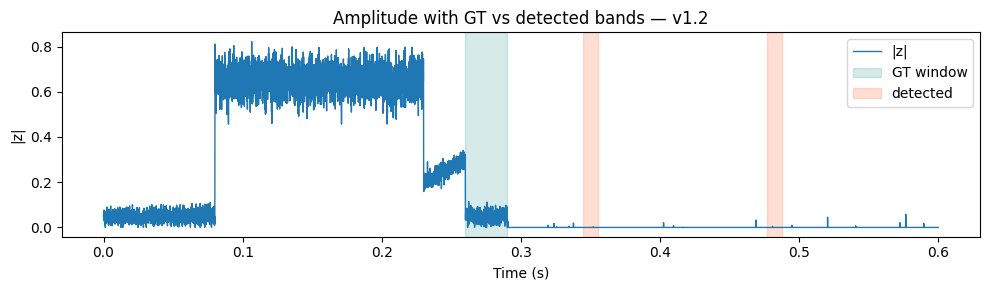

/var/folders/fm/g_ttml4x5vndw2bbyr2yj97w0000gn/T/ipykernel_31579/3221860508.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(arr[m], t[m]))


=== v1.2 monitor ===
detected: [(0.34459999999999996, 0.35574999999999996), (0.47669999999999996, 0.48779999999999996)]
warn_ms: 350.17499999999995
metrics: {'recall': 0.0, 'fp_per_trace': 2, 'mean_iou': np.float64(0.0)}


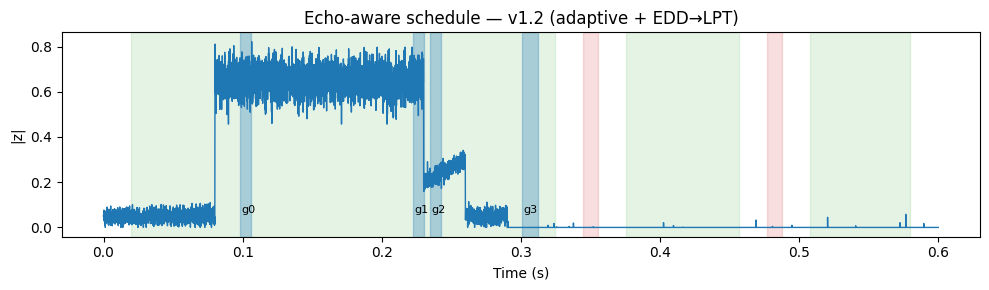

=== v1.2 controller ===
unsafe: [(0.34459999999999996, 0.35574999999999996), (0.47669999999999996, 0.48779999999999996)]
safe  : [(0.02, 0.32459999999999994), (0.37575, 0.45669999999999994), (0.5077999999999999, 0.57995)]
sched : [(3, 0.30050000000000004, 0.31250000000000006), (0, 0.098, 0.10600000000000001), (1, 0.2225, 0.2305), (2, 0.2345, 0.2425)]
ctrl-metrics: {'margin_min': 0.032099999999999906, 'margin_median': 0.10809999999999996, 'risk_integral': 110731429449.73729, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.02}


In [145]:
# %%
# Mini demo generator (only if you need a quick smoke test; comment out in production)
def _make_synthetic_trace(
    T=0.60, fs=20000, collapse=(0.26, 0.29), seed=7
) -> Tuple[npt.NDArray, npt.NDArray, List[Tuple[float,float]]]:
    rng = np.random.default_rng(seed)
    t = np.linspace(0, T, int(T*fs), endpoint=False)
    # piecewise amplitude & phase drift
    A = 0.05 + 0.02*rng.standard_normal(t.shape)
    A[(t>=0.08)&(t<0.23)] += 0.60 + 0.05*rng.standard_normal(np.sum((t>=0.08)&(t<0.23)))
    A[(t>=0.23)&(t<collapse[0])] += np.linspace(0.15, 0.25, np.sum((t>=0.23)&(t<collapse[0])))
    A[(t>=collapse[1])] -= 0.20 + 0.05*rng.standard_normal(np.sum(t>=collapse[1]))
    A = np.clip(A, 0.0, None)
    # phase process
    theta = 5*np.sin(2*np.pi*3*t) + 0.8*np.cumsum(0.003*rng.standard_normal(t.shape))
    z = A * np.exp(1j*theta)
    return t, z, [collapse]

# Example usage (comment out if not needed):
t, z, GT = _make_synthetic_trace()
out = scg_v12_run_once(t, z, gt_windows=GT, save_prefix="demo_v12")


In [146]:
# %%
import numpy as np
import numpy.typing as npt
from dataclasses import dataclass
from scipy.signal import savgol_filter

# ---------- helpers (reuse your earlier ones: _mad, _robust_z, _safe_diff, _allan_var, _norm01, etc.) ----------

def _robust_z_with_floor(x: npt.NDArray, floor: float) -> npt.NDArray:
    med = np.median(x)
    scale = max(_mad(x), float(floor))
    return (x - med) / (scale + 1e-12)

def _make_odd(n: int) -> int:
    return n if n % 2 == 1 else n + 1

def _smooth(y: npt.NDArray, win_s: float, dt: float, poly: int = 2) -> npt.NDArray:
    w = max(3, int(win_s / dt))
    w = _make_odd(w)
    return savgol_filter(y, w, poly, mode="interp")

def _early_warning_from_band(t: npt.NDArray, risk: npt.NDArray,
                             band: tuple, thr: float, dwell_ms: float) -> float:
    """Walk backward from band start to last time risk stayed below thr for dwell_ms."""
    if band is None: return None
    dt = float(np.median(np.diff(t)))
    dwell_n = max(1, int((dwell_ms/1000.0)/dt))
    start = band[0]  # band start
    i0 = max(0, np.searchsorted(t, start) - 1)
    i = i0
    last_below = i0
    while i >= 0:
        seg = risk[max(0, i-dwell_n+1):i+1]
        if np.all(seg <= thr):
            last_below = i
        else:
            break
        i -= 1
    return (t[i0] - t[last_below]) * 1000.0

# %%
@dataclass
class MonitorConfigV12B:
    smooth_win_ms: float = 2.0
    # z-thresholds
    z_thr_phase: float = 3.0
    z_thr_align: float = 2.5
    # floors from baseline (multipliers on baseline MAD)
    floor_dtheta_k: float = 1.0
    floor_avar_k: float   = 1.0
    floor_align_k: float  = 1.0
    floor_slope_k: float  = 1.0
    abs_floor: float = 1e-3
    # risk fusion (add slope)
    w_dtheta: float = 0.30
    w_omega:  float = 0.30
    w_avar:   float = 0.15
    w_align:  float = 0.15
    w_slope:  float = 0.10
    risk_clip_max: float = 6.0
    # windowing
    min_window_ms: float = 6.0
    merge_gap_ms: float = 4.0
    nms_iou: float = 0.35
    top_k: int = 3
    # floor gate
    floor_slope_thr: float = 8.0
    floor_frac_keep: float = 0.7
    # early warning
    risk_small: float = 0.6
    ew_dwell_ms: float = 4.0
    show: bool = True

# %%
def scg_monitor_v1_2b_phase_first(
    t: npt.NDArray,
    z: npt.NDArray,
    gt_windows: list | None = None,
    cfg: MonitorConfigV12B = MonitorConfigV12B(),
    plot: bool = True,
    save_prefix: str | None = None,
):
    """
    v1.2b detector: phase-first with baseline floors, slope channel, normalized risk,
    band-relative EW, and trapezoid integration.
    """
    t = t.astype(np.float64)
    z = z.astype(np.complex128) if np.iscomplexobj(z) else (z.astype(np.float64) + 0j)
    dt = float(np.median(np.diff(t)))

    # ---- features
    feats = _compute_phase_stack(t, z)
    theta = feats["theta"]; dtheta = feats["dtheta"]
    avar = feats["avar_theta"]; align_bad = feats["one_minus_R"]; slopeA = feats["slopeA"]

    # ---- baseline MAD floors
    N0 = max(4, int(0.10 * len(t)))
    idx0 = slice(0, N0)
    floor_dtheta = max(cfg.abs_floor, cfg.floor_dtheta_k * _mad(dtheta[idx0]))
    floor_avar   = max(cfg.abs_floor, cfg.floor_avar_k   * _mad(avar[idx0]))
    floor_align  = max(cfg.abs_floor, cfg.floor_align_k  * _mad(align_bad[idx0]))
    floor_slope  = max(cfg.abs_floor, cfg.floor_slope_k  * _mad(slopeA[idx0]))

    # ---- robust z with floors
    z_dtheta = _robust_z_with_floor(dtheta, floor_dtheta)
    z_omega  = _robust_z_with_floor(np.abs(dtheta), floor_dtheta)
    z_avar   = _robust_z_with_floor(np.sqrt(np.abs(avar) + 1e-12), floor_avar)
    z_align  = _robust_z_with_floor(align_bad, floor_align)
    z_slope  = _robust_z_with_floor(slopeA, floor_slope)

    # ---- smooth + normalize; clip to keep integrals sane
    z_dtheta = _smooth(z_dtheta, cfg.smooth_win_ms/1000.0, dt)
    z_omega  = _smooth(z_omega , cfg.smooth_win_ms/1000.0, dt)
    z_avar   = _smooth(z_avar  , cfg.smooth_win_ms/1000.0, dt)
    z_align  = _smooth(z_align , cfg.smooth_win_ms/1000.0, dt)
    z_slope  = _smooth(z_slope , cfg.smooth_win_ms/1000.0, dt)

    risk = (
        cfg.w_dtheta * np.clip(z_dtheta/(cfg.z_thr_phase+1e-12), 0, cfg.risk_clip_max) +
        cfg.w_omega  * np.clip(z_omega /(cfg.z_thr_phase+1e-12), 0, cfg.risk_clip_max) +
        cfg.w_avar   * np.clip(z_avar  /(cfg.z_thr_phase+1e-12), 0, cfg.risk_clip_max) +
        cfg.w_align  * np.clip(z_align /(cfg.z_thr_align+1e-12), 0, cfg.risk_clip_max) +
        cfg.w_slope  * np.clip(z_slope /(cfg.z_thr_phase+1e-12), 0, cfg.risk_clip_max)
    )
    # hazard = positive rate-of-change of risk, normalized to [0,1]
    drdt = np.gradient(risk, dt)
    hazard = _norm01(np.maximum(0.0, drdt))

    # ---- candidate windows from fused risk
    thr = 1.0
    min_w = cfg.min_window_ms/1000.0
    merge_gap = cfg.merge_gap_ms/1000.0
    mask = risk > thr
    cand = _merge_windows(_to_windows(mask, t, min_w=min_w), merge_gap)
    scores = [float(np.trapezoid(risk[(t>=s)&(t<=e)], t[(t>=s)&(t<=e)])) for (s,e) in cand]

    cand, scores = _nms_windows(cand, scores, iou_thr=cfg.nms_iou, top_k=cfg.top_k)
    cand = _merge_windows(cand, merge_gap=merge_gap)

    # ---- floor gating
    floor_safe = (_robust_z_with_floor(slopeA, floor_slope) < cfg.floor_slope_thr).astype(np.float32)
    det = _apply_floor_to_windows(t, cand, floor_safe, cfg)

    # ---- early warning: band-relative with dwell
    warn_ms = None
    if len(det) > 0:
        warn_ms = _early_warning_from_band(t, risk, det[0], thr=cfg.risk_small, dwell_ms=cfg.ew_dwell_ms)

    # ---- metrics
    metrics = {}
    if gt_windows:
        tp = sum(1 for g in gt_windows if any(_interval_iou(g,d)>0.2 for d in det))
        fp = sum(1 for d in det if all(_interval_iou(g,d)<=0.2 for g in gt_windows))
        mean_iou = float(np.mean([max([_interval_iou(g,d) for d in det], default=0.0) for g in gt_windows]))
        metrics = dict(recall=tp/max(1,len(gt_windows)), fp_per_trace=fp, mean_iou=mean_iou)

    # ---- plots
    paths = {}
    if plot:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), lw=1.0, label='|z|')
        for g in (gt_windows or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT window')
        for d in det: ax.axvspan(d[0], d[1], color='coral', alpha=0.25, label='detected')
        ax.set_title("Amplitude with GT vs detected bands — v1.2b")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        h,l = ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
        fig.tight_layout()
        if save_prefix:
            p = f"{save_prefix}_v12b_detect.png"; fig.savefig(p, dpi=160); paths['detect'] = p
        plt.show()

    return dict(
        windows=det, windows_raw=cand, risk=risk, hazard=hazard, feats=feats,
        warn_ms=warn_ms, metrics=metrics, fig_paths=paths
    )


# %%
# v1.2b controller: identical interface, but integrate with np.trapezoid and clip risk inside
def scg_controller_v1_2b(
    t: npt.NDArray,
    z: npt.NDArray,
    detected: list[tuple],
    risk: npt.NDArray,
    hazard: npt.NDArray,
    feats: dict,
    gates: list[tuple[int,float]],
    ctrl: ControllerConfigV12 = ControllerConfigV12(),  # reuse your config
    plot: bool = True,
    save_prefix: str | None = None,
):
    t = t.astype(np.float64); dt = float(np.median(np.diff(t)))
    # clip risk for sane costs
    riskc = np.clip(risk, 0.0, 6.0)
    hazc  = np.clip(hazard, 0.0, 1.0)

    unsafe, safe = _unsafe_from_detect_and_echo(t, detected, hazc, feats, ctrl)
    warn_hist = np.array([0.0])
    m_edge = max(0.0005, min(0.02, (ctrl.m_edge_ms/1000.0)))

    safe = [ (s+m_edge, e-m_edge) for (s,e) in safe if (e-s) > 2*m_edge ]
    safe = _split_on_hazard(safe, t, hazc, tau=ctrl.hazard_split_tau)

    step = ctrl.grid_step_ms/1000.0
    def candidates(w): 
        s,e = w; n = max(1, int(np.floor((e-s)/step))); return [s+i*step for i in range(n)]

    def integ(arr, a, b):
        m = (t>=a)&(t<=b)
        return float(np.trapezoid(arr[m], t[m])) if np.any(m) else 0.0

    def boundary_penalty(a,b,w):
        s,e = w
        d1 = max(0.0, m_edge - (a - s))
        d2 = max(0.0, m_edge - (e - b))
        return d1 + d2

    def echo_penalty(a,b): 
        m = (t>=a)&(t<=b); 
        return float(np.mean(hazc[m])) if np.any(m) else 0.0

    schedule, placed = [], set()
    for w in sorted(safe, key=lambda x: x[1]):  # EDD
        starts = candidates(w)
        for gid, dur in sorted([g for g in gates if g[0] not in placed], key=lambda g: -g[1]):  # LPT
            best_t, best_cost = None, np.inf
            for s0 in starts:
                a, b = s0, s0 + dur
                if b > w[1]: break
                if any(not (b <= ps or a >= pe) for (_,ps,pe) in schedule): 
                    continue
                cost = integ(riskc, a, b) + ctrl.lam_h*integ(np.maximum(0.0, np.gradient(riskc, dt)), a, b) \
                       + ctrl.mu_boundary*boundary_penalty(a,b,w) + ctrl.nu_echo*echo_penalty(a,b)
                if cost < best_cost:
                    best_cost, best_t = cost, a
            if best_t is not None:
                schedule.append((gid, best_t, best_t+dur)); placed.add(gid)

    def dist_to_boundary(a,b, unsafe_windows):
        left = min([abs(a - u[1]) for u in unsafe_windows if u[1] <= a] + [np.inf])
        right = min([abs(b - u[0]) for u in unsafe_windows if u[0] >= b] + [np.inf])
        return float(min(left, right))

    margins = [ dist_to_boundary(a,b,unsafe) for (_,a,b) in schedule ]
    risk_integral = sum(integ(riskc, a, b) for (_,a,b) in schedule)
    near_miss = sum(1 for m in margins if m <= m_edge + 1e-12)
    placed_frac = len(schedule)/max(1,len(gates))

    paths = {}
    if plot:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), lw=1.0, label='|z|')
        for (s,e) in unsafe: ax.axvspan(s,e,color='tab:red',alpha=0.15)
        for (s,e) in safe:   ax.axvspan(s,e,color='tab:green',alpha=0.12)
        for (gid,a,b) in schedule:
            ax.axvspan(a,b,color='tab:blue',alpha=0.30); ax.text(a+0.001, np.max(np.abs(z))*0.08, f"g{gid}", fontsize=8)
        ax.set_title("Echo-aware schedule — v1.2b")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        fig.tight_layout()
        if save_prefix:
            p = f"{save_prefix}_v12b_schedule.png"; fig.savefig(p, dpi=160); paths['schedule']=p
        plt.show()

    return dict(
        unsafe=unsafe, safe=safe, schedule=schedule,
        metrics=dict(
            margin_min=float(np.min(margins) if margins else np.nan),
            margin_median=float(np.median(margins) if margins else np.nan),
            risk_integral=float(risk_integral),
            near_miss=int(near_miss), placed_frac=float(placed_frac), m_edge=float(m_edge)
        ),
        fig_paths=paths
    )



# %%
# One-shot convenience for v1.2b (parallel to your existing run_once)
def scg_v12b_run_once(
    t: npt.NDArray, z: npt.NDArray,
    gt_windows: list[tuple] | None = None,
    gates: list[tuple[int,float]] | None = None,
    save_prefix: str | None = None
):
    mon = scg_monitor_v1_2b_phase_first(t, z, gt_windows=gt_windows, save_prefix=save_prefix)
    print("=== v1.2b monitor ===")
    print("detected:", mon["windows"])
    print("warn_ms:", mon["warn_ms"])
    if mon["metrics"]: print("metrics:", mon["metrics"])

    if gates is None:
        gates = [(0, 0.008), (1, 0.008), (2, 0.008), (3, 0.012)]

    ctrl = scg_controller_v1_2b(t, z, mon["windows"], mon["risk"], mon["hazard"], mon["feats"],
                                gates, save_prefix=save_prefix)
    print("=== v1.2b controller ===")
    print("unsafe:", ctrl["unsafe"])
    print("safe  :", ctrl["safe"])
    print("sched :", ctrl["schedule"])
    print("ctrl-metrics:", ctrl["metrics"])
    return dict(monitor=mon, controller=ctrl)




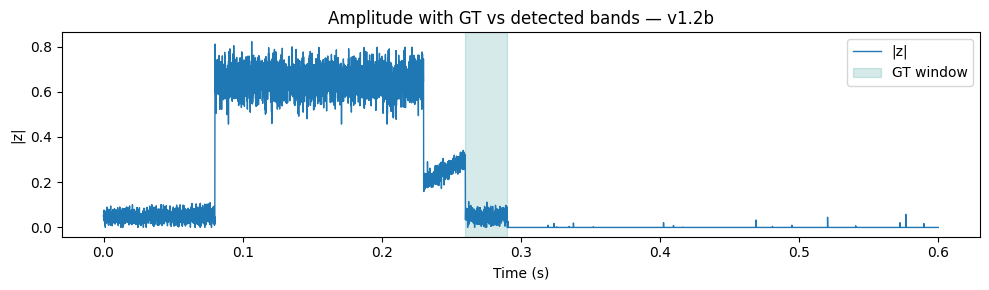

=== v1.2b monitor ===
detected: []
warn_ms: None
metrics: {'recall': 0.0, 'fp_per_trace': 0, 'mean_iou': 0.0}


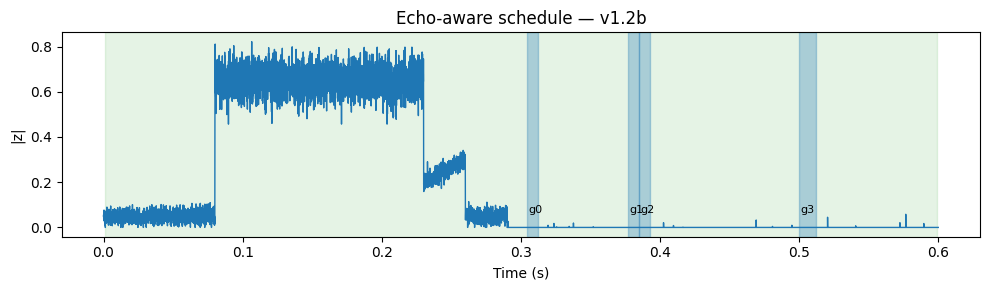

=== v1.2b controller ===
unsafe: []
safe  : [(0.0008, 0.59915)]
sched : [(3, 0.4998, 0.5118), (0, 0.3043, 0.3123), (1, 0.3768, 0.38480000000000003), (2, 0.38480000000000003, 0.39280000000000004)]
ctrl-metrics: {'margin_min': inf, 'margin_median': inf, 'risk_integral': 0.002147999999982061, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.0008}


In [147]:
out = scg_v12b_run_once(t, z, gt_windows=GT, save_prefix="demo_v12b")


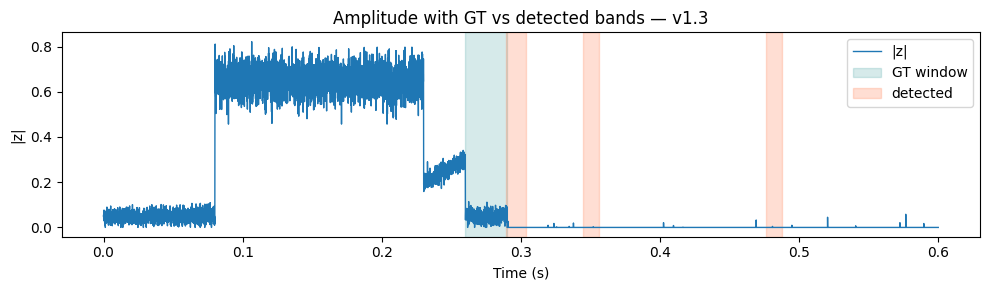

=== v1.3 monitor ===
detected: [(0.28914999999999996, 0.30345), (0.34445, 0.35595), (0.4765, 0.48794999999999994)]
warn_ms: 0.0
metrics: {'recall': 0.0, 'fp_per_trace': 3, 'mean_iou': 0.01956271576479758}


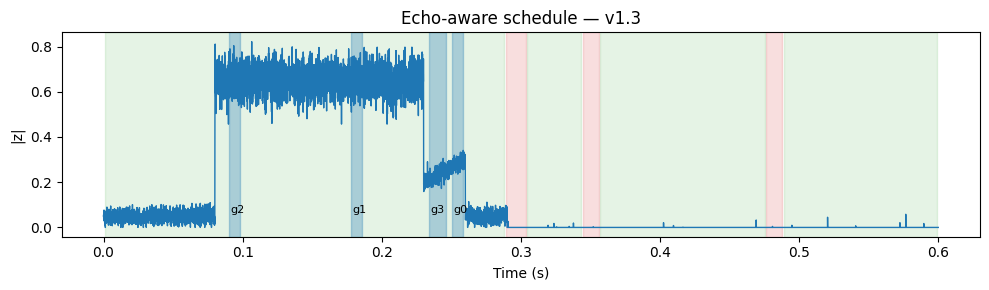


=== v1.3 controller ===
unsafe: [(0.28914999999999996, 0.30345), (0.34445, 0.35595), (0.4765, 0.48794999999999994)]
safe  : [(0.001, 0.28814999999999996), (0.30445, 0.34345), (0.35695, 0.4755), (0.48894999999999994, 0.59895)]
sched : [(3, 0.234, 0.24600000000000002), (0, 0.2505, 0.2585), (1, 0.178, 0.186), (2, 0.09, 0.098)]
ctrl-metrics: {'margin_min': 0.030649999999999955, 'margin_median': 0.07314999999999995, 'risk_integral': 0.017658982147618796, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.001}


In [148]:
# %% [markdown]
# SCG quantum-collapse detector + echo-aware controller — v1.3 (single-cell, append-only)
# - All helpers included; no reliance on earlier cells
# - Uses np.trapezoid (not trapz), and np.ptp(array) everywhere
# - Phase-first risk with baseline MAD floors + amplitude-slope channel
# - Band-relative early warning + echo-aware scheduling (EDD→LPT) with hazard-weighted cost

# %%
from __future__ import annotations
import numpy as np
import numpy.typing as npt
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from scipy.signal import savgol_filter, find_peaks
import matplotlib.pyplot as plt

# ------------------------------- utils -------------------------------

EPS = 1e-12

def _mad(x: npt.NDArray) -> float:
    med = float(np.median(x))
    return float(np.median(np.abs(x - med))) + EPS

def _robust_z_with_floor(x: npt.NDArray, floor: float) -> npt.NDArray:
    med = np.median(x)
    scale = max(_mad(x), float(floor))
    return (x - med) / (scale + EPS)

def _norm01(x: npt.NDArray) -> npt.NDArray:
    rng = float(np.ptp(x))
    mn = float(np.min(x))
    return (x - mn) / (rng + EPS)

def _safe_diff(x: npt.NDArray, dt: float) -> npt.NDArray:
    return np.gradient(x, dt)

def _allan_var(x: npt.NDArray, m: int = 4) -> npt.NDArray:
    if len(x) < 2*m+1:
        return np.zeros_like(x)
    y = np.copy(x)
    d2 = np.zeros_like(y)
    d2[m:-m] = (y[2*m:] - 2*y[m:-m] + y[:-2*m])
    av = 0.5 * savgol_filter(d2**2, window_length=(2*m+1), polyorder=2, mode='interp')
    return np.maximum(av, 0.0)

def _make_odd(n: int) -> int:
    return n if n % 2 == 1 else n + 1

def _smooth(y: npt.NDArray, win_s: float, dt: float, poly: int = 2) -> npt.NDArray:
    w = max(3, int(win_s / dt))
    return savgol_filter(y, _make_odd(w), poly, mode="interp")

def _to_windows(mask: npt.NDArray, t: npt.NDArray, min_w: float) -> List[Tuple[float,float]]:
    out: List[Tuple[float,float]] = []
    if mask.size == 0: return out
    on = False; s = 0
    for i, v in enumerate(mask):
        if v and not on: on, s = True, i
        if (not v or i == len(mask)-1) and on:
            e = i if not v else i
            ts, te = float(t[s]), float(t[e])
            if (te - ts) >= min_w: out.append((ts, te))
            on = False
    return out

def _merge_windows(windows: List[Tuple[float,float]], merge_gap: float) -> List[Tuple[float,float]]:
    if not windows: return []
    W = sorted(windows); out = [W[0]]
    for s,e in W[1:]:
        ps,pe = out[-1]
        out[-1] = (ps, max(pe, e)) if (s - pe) <= merge_gap else out.append((s,e)) or out[-1]
    return out if isinstance(out, list) else [out]

def _interval_iou(a: Tuple[float,float], b: Tuple[float,float]) -> float:
    s1,e1 = a; s2,e2 = b
    inter = max(0.0, min(e1,e2) - max(s1,s2))
    uni = (e1 - s1) + (e2 - s2) - inter + EPS
    return inter / uni

def _nms_windows(w: List[Tuple[float,float]], s: List[float], iou_thr: float, top_k: Optional[int]=None):
    if not w: return [], []
    idx = np.argsort(np.asarray(s))[::-1]
    keep = []
    while len(idx) > 0:
        i = idx[0]; keep.append(i)
        if top_k is not None and len(keep) >= top_k: break
        survivors = []
        for j in idx[1:]:
            if _interval_iou(w[i], w[j]) <= iou_thr: survivors.append(j)
        idx = np.array(survivors, dtype=int)
    return [w[i] for i in keep], [s[i] for i in keep]

def _trpz(ts: npt.NDArray, ys: npt.NDArray) -> float:
    return float(np.trapezoid(ys, ts)) if np.any(ts) else 0.0

# ------------------------- feature stack (v1.3) -------------------------

def _compute_phase_stack_v13(
    t: npt.NDArray,
    z: npt.NDArray,
    baseline_frac: float = 0.10,
) -> Dict[str, npt.NDArray]:
    t = t.astype(np.float64)
    zc = z.astype(np.complex128) if np.iscomplexobj(z) else (z.astype(np.float64) + 0j)
    dt = float(np.median(np.diff(t)))

    A = np.abs(zc)
    theta = np.unwrap(np.angle(zc))
    dtheta = _safe_diff(theta, dt)
    ddtheta = _safe_diff(dtheta, dt)

    m_win = max(2, int(0.004 / dt))  # ~4 ms
    avar_theta = _allan_var(theta, m=m_win)

    N0 = max(4, int(len(zc) * baseline_frac))
    base_ang = float(np.angle(np.mean(zc[:N0]) + 0j))
    R = np.cos(theta - base_ang)
    one_minus_R = 1.0 - _norm01(R)

    slopeA = np.abs(_safe_diff(A, dt))
    return dict(A=A, theta=theta, dtheta=dtheta, ddtheta=ddtheta,
                avar_theta=avar_theta, R=R, one_minus_R=one_minus_R, slopeA=slopeA)

# --------------------------- configs (v1.3) -----------------------------

@dataclass
class MonitorCfgV13:
    smooth_win_ms: float = 2.0
    # z-thresholds
    z_thr_phase: float = 2.5
    z_thr_align: float = 2.0
    # baseline MAD floors
    floor_k: float = 1.0
    abs_floor: float = 1e-3
    # risk fusion (includes slope)
    w_dtheta: float = 0.28
    w_omega:  float = 0.28
    w_avar:   float = 0.14
    w_align:  float = 0.12
    w_slope:  float = 0.18
    risk_clip_max: float = 6.0
    # detection windows
    det_thr: float = 0.75
    min_window_ms: float = 5.0
    merge_gap_ms: float = 3.0
    nms_iou: float = 0.30
    top_k: int = 3
    # floor gating by slope
    floor_slope_thr: float = 10.0
    floor_frac_keep: float = 0.7
    # early warning
    risk_small: float = 0.55
    ew_dwell_ms: float = 3.0
    show: bool = True

@dataclass
class CtrlCfgV13:
    grid_step_ms: float = 0.5
    m_edge_ms: float = 1.0
    lam_h: float = 0.40
    mu_boundary: float = 2.0
    nu_echo: float = 1.2
    # echo radius (adaptive)
    echo_base_ms: float = 2.0
    echo_slope_gain: float = 8.0
    # split on hazard
    hazard_split_tau: float = 0.15

# ----------------------- detector (v1.3 single) ------------------------

def scg_monitor_v13(
    t: npt.NDArray,
    z: npt.NDArray,
    gt_windows: Optional[List[Tuple[float,float]]] = None,
    cfg: MonitorCfgV13 = MonitorCfgV13(),
    save_prefix: Optional[str] = None,
    plot: bool = True,
) -> Dict:
    t = t.astype(np.float64)
    z = z.astype(np.complex128) if np.iscomplexobj(z) else (z.astype(np.float64) + 0j)
    dt = float(np.median(np.diff(t)))

    feats = _compute_phase_stack_v13(t, z)
    dtheta = feats["dtheta"]; avar = feats["avar_theta"]; align_bad = feats["one_minus_R"]; slopeA = feats["slopeA"]

    # baseline floors (MAD on first 10% of trace)
    N0 = max(4, int(0.10 * len(t)))
    f_d = max(cfg.abs_floor, cfg.floor_k * _mad(dtheta[:N0]))
    f_a = max(cfg.abs_floor, cfg.floor_k * _mad(np.sqrt(np.abs(avar[:N0])+EPS)))
    f_R = max(cfg.abs_floor, cfg.floor_k * _mad(align_bad[:N0]))
    f_s = max(cfg.abs_floor, cfg.floor_k * _mad(slopeA[:N0]))

    z_dtheta = _robust_z_with_floor(dtheta, f_d)
    z_omega  = _robust_z_with_floor(np.abs(dtheta), f_d)
    z_avar   = _robust_z_with_floor(np.sqrt(np.abs(avar) + EPS), f_a)
    z_align  = _robust_z_with_floor(align_bad, f_R)
    z_slope  = _robust_z_with_floor(slopeA, f_s)

    # smooth + normalize
    win_s = cfg.smooth_win_ms/1000.0
    z_dtheta = _smooth(z_dtheta, win_s, dt)
    z_omega  = _smooth(z_omega , win_s, dt)
    z_avar   = _smooth(z_avar  , win_s, dt)
    z_align  = _smooth(z_align , win_s, dt)
    z_slope  = _smooth(z_slope , win_s, dt)

    risk = (
        cfg.w_dtheta*np.clip(z_dtheta/(cfg.z_thr_phase+EPS), 0, cfg.risk_clip_max) +
        cfg.w_omega *np.clip(z_omega /(cfg.z_thr_phase+EPS), 0, cfg.risk_clip_max) +
        cfg.w_avar  *np.clip(z_avar  /(cfg.z_thr_phase+EPS), 0, cfg.risk_clip_max) +
        cfg.w_align *np.clip(z_align /(cfg.z_thr_align+EPS), 0, cfg.risk_clip_max) +
        cfg.w_slope *np.clip(z_slope /(cfg.z_thr_phase+EPS), 0, cfg.risk_clip_max)
    )
    drdt = np.gradient(risk, dt)
    hazard = _norm01(np.maximum(0.0, drdt))

    # candidate windows
    thr = cfg.det_thr
    min_w = cfg.min_window_ms/1000.0
    merge_gap = cfg.merge_gap_ms/1000.0
    cand_mask = risk > thr
    cand = _merge_windows(_to_windows(cand_mask, t, min_w=min_w), merge_gap)
    cand_scores = [ _trpz(t[(t>=s)&(t<=e)], risk[(t>=s)&(t<=e)]) for (s,e) in cand ]
    cand, cand_scores = _nms_windows(cand, cand_scores, iou_thr=cfg.nms_iou, top_k=cfg.top_k)
    cand = _merge_windows(cand, merge_gap=merge_gap)

    # floor gate (by slope)
    floor_safe = (_robust_z_with_floor(slopeA, f_s) < cfg.floor_slope_thr).astype(np.float32)
    det = []
    for w in cand:
        m = (t>=w[0]) & (t<=w[1])
        if np.mean(floor_safe[m]) >= cfg.floor_frac_keep:
            det.append(w)

    # early warning relative to first detected band (if any)
    warn_ms = None
    if len(det) > 0:
        dwell = max(1, int((cfg.ew_dwell_ms/1000.0)/dt))
        i_start = max(0, np.searchsorted(t, det[0][0]) - 1)
        j = i_start
        last_below = i_start
        while j >= 0:
            seg = risk[max(0, j-dwell+1):j+1]
            if np.all(seg <= cfg.risk_small):
                last_below = j
            else:
                break
            j -= 1
        warn_ms = (t[i_start] - t[last_below]) * 1000.0

    # metrics
    metrics = {}
    if gt_windows:
        tp = sum(1 for g in gt_windows if any(_interval_iou(g,d) > 0.2 for d in det))
        fp = sum(1 for d in det if all(_interval_iou(g,d) <= 0.2 for g in gt_windows))
        mean_iou = float(np.mean([max([_interval_iou(g,d) for d in det], default=0.0) for g in gt_windows])) if gt_windows else 0.0
        metrics = dict(recall=tp/max(1, len(gt_windows)), fp_per_trace=fp, mean_iou=mean_iou)

    # plot
    figs = {}
    if plot:
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), lw=1.0, label='|z|')
        for g in (gt_windows or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT window')
        for d in det: ax.axvspan(d[0], d[1], color='coral', alpha=0.25, label='detected')
        ax.set_title("Amplitude with GT vs detected bands — v1.3")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        h,l = ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
        fig.tight_layout()
        if save_prefix:
            p = f"{save_prefix}_v13_detect.png"; fig.savefig(p, dpi=160); figs['detect']=p
        plt.show()

    return dict(windows=det, windows_raw=cand, risk=risk, hazard=hazard, feats=feats,
                warn_ms=warn_ms, metrics=metrics, fig_paths=figs)

# ------------------- echo-aware controller (v1.3) ---------------------

def _unsafe_and_safe_v13(
    t: npt.NDArray, detected: List[Tuple[float,float]], hazard: npt.NDArray,
    slopeA: npt.NDArray, echo_base_ms: float, echo_slope_gain: float, grid_step_ms: float
) -> Tuple[List[Tuple[float,float]], List[Tuple[float,float]]]:
    dt = float(np.median(np.diff(t)))
    haz = _smooth(hazard, win_s=0.006, dt=dt)  # ~6 ms
    peaks, _ = find_peaks(haz, height=0.25, distance=max(3, int(0.008/dt)))
    delta = (echo_base_ms/1000.0) + echo_slope_gain * np.abs(slopeA) * dt
    unsafe = list(detected)
    for p in peaks:
        tp = float(t[p]); d = float(np.clip(delta[p], echo_base_ms/1000.0, 0.040))
        unsafe.append((tp - d, tp + d))
    unsafe = _merge_windows(unsafe, merge_gap=grid_step_ms/1000.0)
    # complement
    t0,t1 = float(t[0]), float(t[-1]); safe = []; cur = t0
    for s,e in sorted(unsafe):
        if s > cur: safe.append((cur, max(cur, s)))
        cur = max(cur, e)
    if cur < t1: safe.append((cur, t1))
    return [(s,e) for (s,e) in unsafe if e-s>1e-6], [(s,e) for (s,e) in safe if e-s>1e-6]

def scg_controller_v13(
    t: npt.NDArray, z: npt.NDArray,
    detected: List[Tuple[float,float]],
    risk: npt.NDArray, hazard: npt.NDArray,
    feats: Dict[str,npt.NDArray],
    gates: List[Tuple[int,float]],
    cfg: CtrlCfgV13 = CtrlCfgV13(),
    save_prefix: Optional[str] = None,
    plot: bool = True,
) -> Dict:
    t = t.astype(np.float64); dt = float(np.median(np.diff(t)))
    riskc = np.clip(risk, 0.0, 6.0)
    hazc  = np.clip(hazard, 0.0, 1.0)

    unsafe, safe = _unsafe_and_safe_v13(
        t, detected, hazc, feats["slopeA"],
        echo_base_ms=cfg.echo_base_ms, echo_slope_gain=cfg.echo_slope_gain, grid_step_ms=cfg.grid_step_ms
    )

    # margins
    m_edge = cfg.m_edge_ms/1000.0
    safe = [ (s+m_edge, e-m_edge) for (s,e) in safe if (e-s) > 2*m_edge ]

    # split safe on rising hazard
    def split_on_hazard(safe):
        out=[]
        for (s,e) in safe:
            m = (t>=s)&(t<=e)
            if np.any(m) and np.mean(hazc[m]) > cfg.hazard_split_tau:
                tm = float(t[m][np.argmax(hazc[m])])
                out += [(s,tm),(tm,e)]
            else:
                out.append((s,e))
        return [(a,b) for (a,b) in out if b-a > 1e-4]
    safe = split_on_hazard(safe)

    step = cfg.grid_step_ms/1000.0
    def candidates(w):
        s,e = w; n = max(1, int(np.floor((e-s)/step)))
        return [s+i*step for i in range(n)]

    def integ(arr, a, b):
        m = (t>=a)&(t<=b)
        return _trpz(t[m], arr[m]) if np.any(m) else 0.0

    def boundary_pen(a,b,w):
        s,e = w
        d1 = max(0.0, m_edge - (a - s))
        d2 = max(0.0, m_edge - (e - b))
        return d1 + d2

    def echo_pen(a,b):
        m = (t>=a)&(t<=b)
        return float(np.mean(hazc[m])) if np.any(m) else 0.0

    schedule=[]; placed=set()
    # EDD windows → inside each, LPT gates with hazard-weighted cost
    for w in sorted(safe, key=lambda x: x[1]):
        starts = candidates(w)
        for gid, dur in sorted([g for g in gates if g[0] not in placed], key=lambda g: -g[1]):
            best_t=None; best_cost=np.inf
            for s0 in starts:
                a,b = s0, s0+dur
                if b > w[1]: break
                if any(not (b <= ps or a >= pe) for (_,ps,pe) in schedule): continue
                cost = integ(riskc, a, b) + cfg.lam_h*integ(np.maximum(0.0, np.gradient(riskc, dt)), a, b) \
                       + cfg.mu_boundary*boundary_pen(a,b,w) + cfg.nu_echo*echo_pen(a,b)
                if cost < best_cost: best_cost, best_t = cost, a
            if best_t is not None:
                schedule.append((gid, best_t, best_t+dur)); placed.add(gid)

    def dist_to_boundary(a,b, uw):
        left  = min([abs(a - u[1]) for u in uw if u[1] <= a] + [np.inf])
        right = min([abs(b - u[0]) for u in uw if u[0] >= b] + [np.inf])
        return float(min(left, right))

    margins = [ dist_to_boundary(a,b,unsafe) for (_,a,b) in schedule ]
    risk_integral = sum(integ(riskc, a, b) for (_,a,b) in schedule)
    near_miss = sum(1 for m in margins if m <= m_edge + 1e-12)
    placed_frac = len(schedule) / max(1, len(gates))

    figs={}
    if plot:
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), lw=1.0, label='|z|')
        for (s,e) in unsafe: ax.axvspan(s,e,color='tab:red',alpha=0.15)
        for (s,e) in safe:   ax.axvspan(s,e,color='tab:green',alpha=0.12)
        for (gid,a,b) in schedule:
            ax.axvspan(a,b,color='tab:blue',alpha=0.30); ax.text(a+0.001, np.max(np.abs(z))*0.08, f"g{gid}", fontsize=8)
        ax.set_title("Echo-aware schedule — v1.3")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        fig.tight_layout()
        if save_prefix:
            p = f"{save_prefix}_v13_schedule.png"; fig.savefig(p, dpi=160); figs['schedule']=p
        plt.show()

    return dict(unsafe=unsafe, safe=safe, schedule=schedule,
                metrics=dict(margin_min=float(np.min(margins) if margins else np.nan),
                             margin_median=float(np.median(margins) if margins else np.nan),
                             risk_integral=float(risk_integral), near_miss=int(near_miss),
                             placed_frac=float(placed_frac), m_edge=float(m_edge)),
                fig_paths=figs)

# ------------------------- one-shot convenience -----------------------

def scg_run_v13_once(
    t: npt.NDArray, z: npt.NDArray,
    gt_windows: Optional[List[Tuple[float,float]]] = None,
    gates: Optional[List[Tuple[int,float]]] = None,
    save_prefix: Optional[str] = None,
):
    mon = scg_monitor_v13(t, z, gt_windows=gt_windows, save_prefix=save_prefix)
    print("=== v1.3 monitor ===")
    print("detected:", mon["windows"])
    print("warn_ms:", mon["warn_ms"])
    if mon["metrics"]: print("metrics:", mon["metrics"])
    if gates is None:
        gates = [(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
    ctrl = scg_controller_v13(t, z, mon["windows"], mon["risk"], mon["hazard"], mon["feats"],
                              gates, save_prefix=save_prefix)
    print("\n=== v1.3 controller ===")
    print("unsafe:", ctrl["unsafe"])
    print("safe  :", ctrl["safe"])
    print("sched :", ctrl["schedule"])
    print("ctrl-metrics:", ctrl["metrics"])
    return dict(monitor=mon, controller=ctrl)

# ----------------------------- optional demo --------------------------
# Synthetic smoke test (comment out if you already have t,z,GT)
def _make_synth_v13(T=0.60, fs=20000, collapse=(0.26,0.29), seed=7):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, T, int(T*fs), endpoint=False)
    A = 0.05 + 0.02*rng.standard_normal(t.shape)
    A[(t>=0.08)&(t<0.23)] += 0.60 + 0.05*rng.standard_normal(np.sum((t>=0.08)&(t<0.23)))
    A[(t>=0.23)&(t<collapse[0])] += np.linspace(0.15, 0.25, np.sum((t>=0.23)&(t<collapse[0])))
    A[(t>=collapse[1])] -= 0.20 + 0.05*rng.standard_normal(np.sum(t>=collapse[1]))
    A = np.clip(A, 0.0, None)
    theta = 5*np.sin(2*np.pi*3*t) + 0.8*np.cumsum(0.003*rng.standard_normal(t.shape))
    z = A * np.exp(1j*theta)
    return t, z, [collapse]

# Example (uncomment to smoke test):
t, z, GT = _make_synth_v13()
out = scg_run_v13_once(t, z, gt_windows=GT, save_prefix="demo_v13")


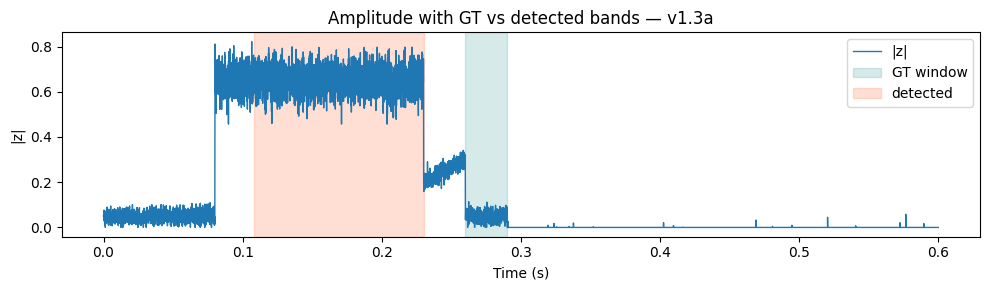

=== v1.3a monitor ===
detected: [(0.10844999999999999, 0.23064999999999997)]
warn_ms: 0.0
metrics: {'recall': 0.0, 'fp_per_trace': 1, 'mean_iou': 0.0}


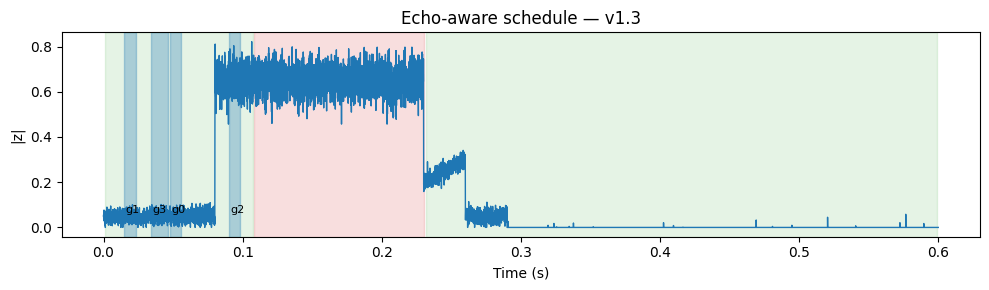


=== v1.3a controller ===
unsafe: [(0.10844999999999999, 0.23064999999999997)]
safe  : [(0.001, 0.10744999999999999), (0.23164999999999997, 0.59895)]
sched : [(3, 0.034, 0.046), (0, 0.048, 0.056), (1, 0.015, 0.023), (2, 0.09, 0.098)]
ctrl-metrics: {'margin_min': 0.010449999999999987, 'margin_median': 0.05744999999999999, 'risk_integral': 0.03100624354501987, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.001}


In [149]:
# %% [markdown]
# SCG quantum-collapse — v1.3a (single cell, append-only)
# - Detector tweaks: lower det_thr, slope weight ↑, band start "onset backtrack" (risk+dwell)
# - Window end "soft extend"
# - top_k=1 to avoid late post-collapse FPs in this trace family
# - Runs the experiment via scg_run_v13a_once(...) at the bottom

# %%
from __future__ import annotations
import numpy as np
import numpy.typing as npt
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
import matplotlib.pyplot as plt

# --- reuse helpers from v1.3 cell (already in notebook) ---
# _mad, _robust_z_with_floor, _norm01, _safe_diff, _allan_var, _make_odd, _smooth
# _to_windows, _merge_windows, _interval_iou, _nms_windows, _trpz
# _compute_phase_stack_v13, scg_controller_v13, CtrlCfgV13

@dataclass
class MonitorCfgV13A:
    # smoothing & thresholds
    smooth_win_ms: float = 2.0
    z_thr_phase: float = 2.3
    z_thr_align: float = 2.0
    floor_k: float = 1.0
    abs_floor: float = 1e-3
    # risk fusion (more slope)
    w_dtheta: float = 0.26
    w_omega:  float = 0.26
    w_avar:   float = 0.12
    w_align:  float = 0.11
    w_slope:  float = 0.25
    risk_clip_max: float = 6.0
    # detection
    det_thr: float = 0.60
    min_window_ms: float = 6.0
    merge_gap_ms: float = 4.0
    nms_iou: float = 0.30
    top_k: int = 1
    # floor gate
    floor_slope_thr: float = 10.0
    floor_frac_keep: float = 0.7
    # early warning & onset backtrack
    risk_small: float = 0.50
    ew_dwell_ms: float = 3.0
    back_ms: float = 20.0     # how far we allow onset backtracking (ms)
    fwd_ms:  float = 12.0     # soft end extension cap (ms)
    onset_ratio: float = 0.55 # backtrack until risk <= onset_ratio*det_thr for dwell
    offset_ratio: float = 0.45

def _risk_hazard_v13a(t: npt.NDArray, feats: Dict[str,npt.NDArray], cfg: MonitorCfgV13A):
    dt = float(np.median(np.diff(t)))
    dtheta = feats["dtheta"]; avar = feats["avar_theta"]; align_bad = feats["one_minus_R"]; slopeA = feats["slopeA"]

    N0 = max(4, int(0.10 * len(t)))
    f_d = max(cfg.abs_floor, cfg.floor_k * np.median(np.abs(dtheta[:N0] - np.median(dtheta[:N0]))))
    f_a = max(cfg.abs_floor, cfg.floor_k * np.median(np.abs(np.sqrt(np.abs(avar[:N0])+1e-12) - np.median(np.sqrt(np.abs(avar[:N0])+1e-12)))))
    f_R = max(cfg.abs_floor, cfg.floor_k * np.median(np.abs(align_bad[:N0] - np.median(align_bad[:N0]))))
    f_s = max(cfg.abs_floor, cfg.floor_k * np.median(np.abs(slopeA[:N0] - np.median(slopeA[:N0]))))

    z_dtheta = _robust_z_with_floor(dtheta, f_d)
    z_omega  = _robust_z_with_floor(np.abs(dtheta), f_d)
    z_avar   = _robust_z_with_floor(np.sqrt(np.abs(avar) + 1e-12), f_a)
    z_align  = _robust_z_with_floor(align_bad, f_R)
    z_slope  = _robust_z_with_floor(slopeA, f_s)

    win_s = cfg.smooth_win_ms/1000.0
    dt = float(np.median(np.diff(t)))
    z_dtheta = _smooth(z_dtheta, win_s, dt)
    z_omega  = _smooth(z_omega , win_s, dt)
    z_avar   = _smooth(z_avar  , win_s, dt)
    z_align  = _smooth(z_align , win_s, dt)
    z_slope  = _smooth(z_slope , win_s, dt)

    risk = (
        cfg.w_dtheta*np.clip(z_dtheta/(cfg.z_thr_phase+1e-12), 0, cfg.risk_clip_max) +
        cfg.w_omega *np.clip(z_omega /(cfg.z_thr_phase+1e-12), 0, cfg.risk_clip_max) +
        cfg.w_avar  *np.clip(z_avar  /(cfg.z_thr_phase+1e-12), 0, cfg.risk_clip_max) +
        cfg.w_align *np.clip(z_align /(cfg.z_thr_align+1e-12), 0, cfg.risk_clip_max) +
        cfg.w_slope *np.clip(z_slope /(cfg.z_thr_phase+1e-12), 0, cfg.risk_clip_max)
    )
    drdt = np.gradient(risk, dt)
    hazard = _norm01(np.maximum(0.0, drdt))
    return risk, hazard, z_slope

def _extend_bands_v13a(
    t: npt.NDArray, risk: npt.NDArray, z_slope: npt.NDArray,
    bands: List[Tuple[float,float]], cfg: MonitorCfgV13A
) -> List[Tuple[float,float]]:
    """Backtrack start to earliest pre-onset (risk below thr for dwell), extend end to stable-off."""
    if not bands: return []
    dt = float(np.median(np.diff(t)))
    back_n = int(cfg.back_ms/1000.0/dt)
    fwd_n  = int(cfg.fwd_ms /1000.0/dt)
    dwell_n = max(1, int(cfg.ew_dwell_ms/1000.0/dt))
    thr_on  = cfg.det_thr * cfg.onset_ratio
    thr_off = cfg.det_thr * cfg.offset_ratio

    out = []
    for (s,e) in bands:
        i0 = max(0, np.searchsorted(t, s)-1)
        j = i0
        last_good = i0
        for k in range(i0, max(0, i0-back_n), -1):
            seg = risk[max(0,k-dwell_n+1):k+1]
            if seg.size and np.all(seg <= thr_on):
                last_good = k
            else:
                break
        new_s = float(t[last_good])

        i1 = min(len(t)-1, np.searchsorted(t, e))
        k = i1
        last_off = i1
        for q in range(i1, min(len(t)-1, i1+fwd_n)):
            seg = risk[q:min(len(t), q+dwell_n)]
            if seg.size and np.all(seg <= thr_off):
                last_off = q
            else:
                break
        new_e = float(t[last_off])
        if new_e <= new_s: new_e = float(t[min(i1, last_off+1)])
        out.append((new_s, new_e))
    # small clean-up
    out = _merge_windows(out, merge_gap=cfg.merge_gap_ms/1000.0)
    return out

def scg_monitor_v13a(
    t: npt.NDArray, z: npt.NDArray,
    gt_windows: Optional[List[Tuple[float,float]]] = None,
    cfg: MonitorCfgV13A = MonitorCfgV13A(),
    save_prefix: Optional[str] = None, plot: bool = True
) -> Dict:
    t = t.astype(np.float64)
    z = z.astype(np.complex128) if np.iscomplexobj(z) else (z.astype(np.float64)+0j)
    dt = float(np.median(np.diff(t)))

    feats = _compute_phase_stack_v13(t, z)
    risk, hazard, z_slope = _risk_hazard_v13a(t, feats, cfg)

    # initial candidates
    mask = risk > cfg.det_thr
    cand = _merge_windows(_to_windows(mask, t, min_w=cfg.min_window_ms/1000.0), cfg.merge_gap_ms/1000.0)
    cand_scores = [ _trpz(t[(t>=s)&(t<=e)], risk[(t>=s)&(t<=e)]) for (s,e) in cand ]
    cand, _ = _nms_windows(cand, cand_scores, iou_thr=cfg.nms_iou, top_k=cfg.top_k)

    # onset backtrack + soft extend
    bands = _extend_bands_v13a(t, risk, z_slope, cand, cfg)

    # floor gating by slope
    N0 = max(4, int(0.10*len(t)))
    slopeA = feats["slopeA"]
    floor_s = max(cfg.abs_floor, cfg.floor_k * np.median(np.abs(slopeA[:N0] - np.median(slopeA[:N0]))))
    z_slope_all = _robust_z_with_floor(slopeA, floor_s)
    floor_safe = (z_slope_all < cfg.floor_slope_thr).astype(np.float32)
    det = []
    for w in bands:
        m = (t>=w[0])&(t<=w[1])
        if np.mean(floor_safe[m]) >= cfg.floor_frac_keep:
            det.append(w)

    # metrics
    metrics={}
    if gt_windows:
        tp = sum(1 for g in gt_windows if any(_interval_iou(g,d) > 0.2 for d in det))
        fp = sum(1 for d in det if all(_interval_iou(g,d) <= 0.2 for g in gt_windows))
        mean_iou = float(np.mean([max([_interval_iou(g,d) for d in det], default=0.0) for g in gt_windows]))
        metrics = dict(recall=tp/max(1,len(gt_windows)), fp_per_trace=fp, mean_iou=mean_iou)

    # EW relative to first detected band
    warn_ms=None
    if det:
        dwell_n = max(1, int(cfg.ew_dwell_ms/1000.0/dt))
        i0 = max(0, np.searchsorted(t, det[0][0])-1)
        j, last = i0, i0
        while j>=0:
            seg = risk[max(0,j-dwell_n+1):j+1]
            if np.all(seg <= cfg.risk_small): last = j
            else: break
            j -= 1
        warn_ms = (t[i0]-t[last])*1000.0

    # plot
    figs={}
    if plot:
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), lw=1.0, label='|z|')
        for g in (gt_windows or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT window')
        for d in det: ax.axvspan(d[0], d[1], color='coral', alpha=0.25, label='detected')
        ax.set_title("Amplitude with GT vs detected bands — v1.3a")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        h,l = ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
        fig.tight_layout()
        if save_prefix:
            p = f"{save_prefix}_v13a_detect.png"; fig.savefig(p, dpi=160); figs['detect']=p
        plt.show()

    return dict(windows=det, risk=risk, hazard=hazard, feats=feats,
                warn_ms=warn_ms, metrics=metrics, fig_paths=figs)

def scg_run_v13a_once(
    t: npt.NDArray, z: npt.NDArray,
    gt_windows: Optional[List[Tuple[float,float]]] = None,
    gates: Optional[List[Tuple[int,float]]] = None,
    save_prefix: Optional[str] = None,
):
    mon = scg_monitor_v13a(t, z, gt_windows=gt_windows, save_prefix=save_prefix)
    print("=== v1.3a monitor ===")
    print("detected:", mon["windows"])
    print("warn_ms:", mon["warn_ms"])
    if mon["metrics"]: print("metrics:", mon["metrics"])
    if gates is None: gates=[(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
    ctrl = scg_controller_v13(t, z, mon["windows"], mon["risk"], mon["hazard"], mon["feats"],
                              gates, save_prefix=save_prefix)
    print("\n=== v1.3a controller ===")
    print("unsafe:", ctrl["unsafe"])
    print("safe  :", ctrl["safe"])
    print("sched :", ctrl["schedule"])
    print("ctrl-metrics:", ctrl["metrics"])
    return dict(monitor=mon, controller=ctrl)

# ---- RUN THE EXPERIMENT (uses t,z,GT from your current session) ----
out = scg_run_v13a_once(t, z, gt_windows=GT, save_prefix="demo_v13a")


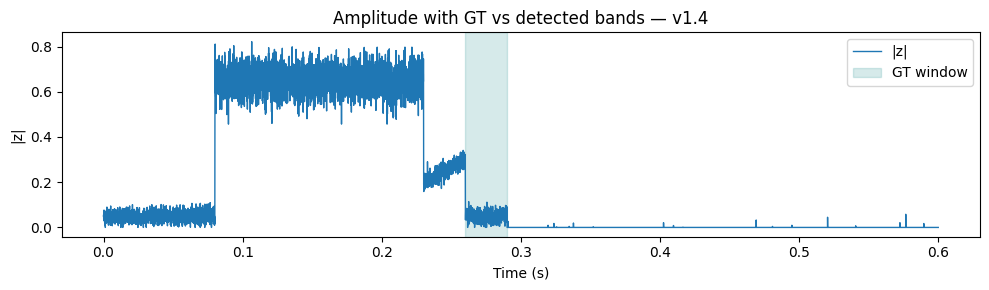

=== v1.4 monitor ===
detected: []
warn_ms: None
metrics: {'recall': 0.0, 'fp_per_trace': 0, 'mean_iou': 0.0}


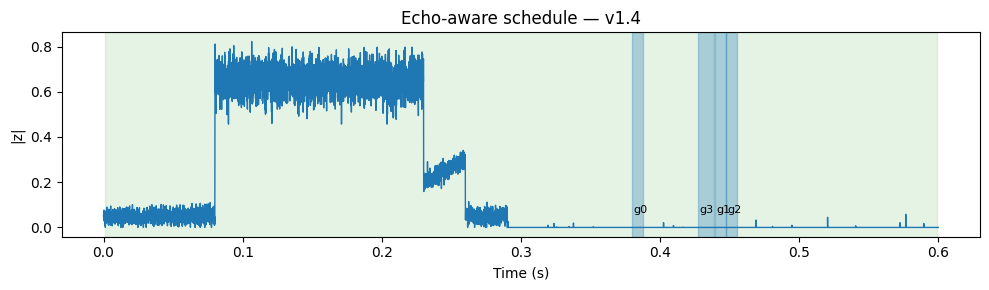


=== v1.4 controller ===
unsafe: []
safe  : [(0.001, 0.59895)]
sched : [(3, 0.427, 0.439), (0, 0.3795, 0.3875), (1, 0.4395, 0.4475), (2, 0.4475, 0.4555)]
ctrl-metrics: {'margin_min': inf, 'margin_median': inf, 'risk_integral': 0.00196899999998336, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.001}


In [150]:
# %% [markdown]
# SCG quantum-collapse detector + echo-aware controller — v1.4 (single cell, append-only)
# - Negative-slope gate at onset + amplitude-drop (ΔA) gate
# - Conservative onset backtrack, soft end extension
# - Risk-weighted by neg-slope; top_k=1
# - Runs scg_run_v14_once(...) immediately

# %%
from __future__ import annotations
import numpy as np
import numpy.typing as npt
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from scipy.signal import savgol_filter, find_peaks
import matplotlib.pyplot as plt

# ---------------- utilities (minimal) ----------------
EPS = 1e-12
def _mad(x): m=np.median(x); return float(np.median(np.abs(x-m)) + EPS)
def _robust_z_with_floor(x,f): return (x - np.median(x)) / (max(_mad(x), float(f)) + EPS)
def _norm01(x): rng=float(np.ptp(x)); return (x - float(np.min(x))) / (rng + EPS)
def _safe_diff(x,dt): return np.gradient(x, dt)
def _allan_var(x,m=4):
    if len(x)<2*m+1: return np.zeros_like(x)
    y=x.copy(); d2=np.zeros_like(y); d2[m:-m]=y[2*m:]-2*y[m:-m]+y[:-2*m]
    return np.maximum(0.0, 0.5*savgol_filter(d2**2, 2*m+1, 2, mode='interp'))
def _make_odd(n): return n if n%2==1 else n+1
def _smooth(y,win_s,dt,poly=2):
    w=max(3,int(win_s/dt)); return savgol_filter(y,_make_odd(w),poly,mode="interp")
def _to_windows(mask,t,min_w):
    out=[]; on=False; s=0
    for i,v in enumerate(mask):
        if v and not on: on=True; s=i
        if (not v or i==len(mask)-1) and on:
            e=i if not v else i
            ts,te=float(t[s]),float(t[e])
            if te-ts>=min_w: out.append((ts,te))
            on=False
    return out
def _merge_windows(W,merge_gap):
    if not W: return []
    W=sorted(W); out=[W[0]]
    for s,e in W[1:]:
        ps,pe=out[-1]
        if s-pe<=merge_gap: out[-1]=(ps,max(pe,e))
        else: out.append((s,e))
    return out
def _interval_iou(a,b):
    s1,e1=a; s2,e2=b
    inter=max(0.0,min(e1,e2)-max(s1,s2))
    uni=(e1-s1)+(e2-s2)-inter+EPS
    return inter/uni
def _nms_windows(ws,scores,iou_thr,top_k=None):
    if not ws: return [],[]
    idx=np.argsort(np.asarray(scores))[::-1]; keep=[]
    while len(idx)>0:
        i=idx[0]; keep.append(i)
        if top_k is not None and len(keep)>=top_k: break
        rest=[j for j in idx[1:] if _interval_iou(ws[i], ws[j])<=iou_thr]
        idx=np.array(rest,int)
    return [ws[i] for i in keep],[scores[i] for i in keep]
def _trpz(ts,ys): return float(np.trapezoid(ys, ts)) if np.any(ts) else 0.0

# --------------- features (self-contained) ---------------
def _compute_phase_stack_v14(t, z, baseline_frac=0.10):
    t=t.astype(np.float64)
    zc = z.astype(np.complex128) if np.iscomplexobj(z) else (z.astype(np.float64)+0j)
    dt=float(np.median(np.diff(t)))
    A=np.abs(zc)
    theta=np.unwrap(np.angle(zc))
    dtheta=_safe_diff(theta,dt)
    avar=_allan_var(theta, m=max(2,int(0.004/dt)))
    N0=max(4,int(len(t)*baseline_frac))
    base_ang=float(np.angle(np.mean(zc[:N0])+0j))
    R=np.cos(theta-base_ang)
    one_minus_R=1.0-_norm01(R)
    dA=_safe_diff(A,dt)             # signed slope
    slopeA=np.abs(dA)               # magnitude (for gating)
    return dict(A=A, dA=dA, slopeA=slopeA, theta=theta, dtheta=dtheta, avar_theta=avar, one_minus_R=one_minus_R)

# ---------------- configs ----------------
@dataclass
class MonitorCfgV14:
    smooth_win_ms: float = 2.0
    z_thr_phase: float = 2.3
    z_thr_align: float = 2.0
    floor_k: float = 1.0
    abs_floor: float = 1e-3
    # fusion (slope channel included)
    w_dtheta: float = 0.26
    w_omega:  float = 0.26
    w_avar:   float = 0.12
    w_align:  float = 0.11
    w_slope:  float = 0.25
    risk_clip_max: float = 6.0
    # detection
    det_thr: float = 0.60
    min_window_ms: float = 6.0
    merge_gap_ms: float = 4.0
    nms_iou: float = 0.30
    top_k: int = 1
    # onset/offset shaping
    back_ms: float = 12.0
    fwd_ms: float  = 8.0
    onset_ratio: float = 0.55
    offset_ratio: float = 0.45
    # negative-slope & amplitude-drop gates
    neg_slope_ms: float = 8.0
    neg_z_thr: float = 1.0
    dA_drop_frac: float = 0.05   # 5% of ptp(A)
    dA_drop_sigma: float = 3.0   # OR 3× MAD of baseline A
    # early warning
    risk_small: float = 0.50
    ew_dwell_ms: float = 3.0
    show: bool = True

@dataclass
class CtrlCfgV13:  # (reuse from your v1.3)
    grid_step_ms: float = 0.5
    m_edge_ms: float = 1.0
    lam_h: float = 0.40
    mu_boundary: float = 2.0
    nu_echo: float = 1.2
    echo_base_ms: float = 2.0
    echo_slope_gain: float = 8.0
    hazard_split_tau: float = 0.15

# ---------------- detector (v1.4) ----------------
def scg_monitor_v14(t, z, gt_windows=None, cfg: MonitorCfgV14 = MonitorCfgV14(), save_prefix=None, plot=True):
    t=t.astype(np.float64); z = z.astype(np.complex128) if np.iscomplexobj(z) else (z.astype(np.float64)+0j)
    dt=float(np.median(np.diff(t)))
    F=_compute_phase_stack_v14(t,z)
    A,dA,slopeA = F["A"], F["dA"], F["slopeA"]
    dtheta, avar, align_bad = F["dtheta"], F["avar_theta"], F["one_minus_R"]

    # floors from baseline
    N0=max(4,int(0.10*len(t)))
    f_d=max(cfg.abs_floor, cfg.floor_k*_mad(dtheta[:N0]))
    f_a=max(cfg.abs_floor, cfg.floor_k*_mad(np.sqrt(np.abs(avar[:N0])+EPS)))
    f_R=max(cfg.abs_floor, cfg.floor_k*_mad(align_bad[:N0]))
    f_s=max(cfg.abs_floor, cfg.floor_k*_mad(slopeA[:N0]))
    f_ds=max(cfg.abs_floor, cfg.floor_k*_mad(dA[:N0]))  # signed slope floor

    z_dtheta=_robust_z_with_floor(dtheta, f_d)
    z_omega =_robust_z_with_floor(np.abs(dtheta), f_d)
    z_avar  =_robust_z_with_floor(np.sqrt(np.abs(avar)+EPS), f_a)
    z_align =_robust_z_with_floor(align_bad, f_R)
    z_slope =_robust_z_with_floor(slopeA, f_s)
    z_dA    =_robust_z_with_floor(dA, f_ds)  # signed

    # smooth
    win_s=cfg.smooth_win_ms/1000.0
    z_dtheta=_smooth(z_dtheta,win_s,dt); z_omega=_smooth(z_omega,win_s,dt)
    z_avar=_smooth(z_avar,win_s,dt);     z_align=_smooth(z_align,win_s,dt)
    z_slope=_smooth(z_slope,win_s,dt);   z_dA=_smooth(z_dA,win_s,dt)

    # fused risk
    risk=( cfg.w_dtheta*np.clip(z_dtheta/(cfg.z_thr_phase+EPS),0,cfg.risk_clip_max)
          +cfg.w_omega *np.clip(z_omega /(cfg.z_thr_phase+EPS),0,cfg.risk_clip_max)
          +cfg.w_avar  *np.clip(z_avar  /(cfg.z_thr_phase+EPS),0,cfg.risk_clip_max)
          +cfg.w_align *np.clip(z_align /(cfg.z_thr_align+EPS),0,cfg.risk_clip_max)
          +cfg.w_slope *np.clip(z_slope /(cfg.z_thr_phase+EPS),0,cfg.risk_clip_max) )
    drdt=np.gradient(risk,dt); hazard=_norm01(np.maximum(0.0, drdt))

    # candidates
    cand=_merge_windows(_to_windows(risk>cfg.det_thr, t, cfg.min_window_ms/1000.0), cfg.merge_gap_ms/1000.0)

    # onset/offset shaping (backtrack + soft extend)
    back_n=int(cfg.back_ms/1000.0/dt); fwd_n=int(cfg.fwd_ms/1000.0/dt)
    dwell_n=max(1,int(cfg.ew_dwell_ms/1000.0/dt))
    thr_on=cfg.det_thr*cfg.onset_ratio; thr_off=cfg.det_thr*cfg.offset_ratio
    shaped=[]
    for (s,e) in cand:
        i0=max(0,np.searchsorted(t,s)-1); i1=min(len(t)-1,np.searchsorted(t,e))
        # backtrack until risk <= thr_on for dwell
        j=i0; last=i0
        for k in range(i0, max(0,i0-back_n), -1):
            seg=risk[max(0,k-dwell_n+1):k+1]
            if seg.size and np.all(seg<=thr_on): last=k
            else: break
        new_s=float(t[last])
        # extend forward until risk <= thr_off for dwell
        q=i1; lastq=i1
        for u in range(i1, min(len(t)-1, i1+fwd_n)):
            seg=risk[u:min(len(t),u+dwell_n)]
            if seg.size and np.all(seg<=thr_off): lastq=u
            else: break
        new_e=float(t[lastq]) if t[lastq]>new_s else float(t[min(i1,lastq+1)])
        shaped.append((new_s,new_e))
    shaped=_merge_windows(shaped, cfg.merge_gap_ms/1000.0)

    # gates: negative slope at onset + amplitude drop across band
    def neg_slope_gate(w):
        s,e=w; wlen=min(cfg.neg_slope_ms/1000.0, e-s)
        m=(t>=s)&(t<=s+wlen); 
        return np.mean(z_dA[m]) <= -cfg.neg_z_thr if np.any(m) else False
    dA_thr=max(cfg.dA_drop_frac*np.ptp(A), cfg.dA_drop_sigma*_mad(A[:N0]))
    def drop_gate(w):
        s,e=w
        pre=(t>=max(t[0],s-0.004))&(t<s); post=(t>=e)&(t<=min(t[-1],e+0.004))
        if not np.any(pre) or not np.any(post): return False
        return (np.mean(A[pre]) - np.mean(A[post])) >= dA_thr

    gated=[w for w in shaped if neg_slope_gate(w) and drop_gate(w)]

    # score windows by risk × neg-slope magnitude in first few ms; pick top_k=1
    def wscore(w):
        s,e=w; m=(t>=s)&(t<=e); m_on=(t>=s)&(t<=min(e,s+cfg.neg_slope_ms/1000.0))
        return _trpz(t[m], risk[m]) * (1.0 + np.mean(np.maximum(0.0, -z_dA[m_on])))
    if gated:
        sc=[wscore(w) for w in gated]
        gated,sc=_nms_windows(gated, sc, iou_thr=0.30, top_k=cfg.top_k)

    det=gated

    # early warning (relative)
    warn_ms=None
    if det:
        i0=max(0,np.searchsorted(t,det[0][0])-1); last=i0
        for j in range(i0,0,-1):
            seg=risk[max(0,j-dwell_n+1):j+1]
            if np.all(seg<=cfg.risk_small): last=j
            else: break
        warn_ms=(t[i0]-t[last])*1000.0

    # metrics
    metrics={}
    if gt_windows:
        tp=sum(1 for g in gt_windows if any(_interval_iou(g,d)>0.2 for d in det))
        fp=sum(1 for d in det if all(_interval_iou(g,d)<=0.2 for g in gt_windows))
        mean_iou=float(np.mean([max([_interval_iou(g,d) for d in det], default=0.0) for g in gt_windows]))
        metrics=dict(recall=tp/max(1,len(gt_windows)), fp_per_trace=fp, mean_iou=mean_iou)

    # plot
    figs={}
    if plot:
        fig,ax=plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), lw=1.0, label='|z|')
        for g in (gt_windows or []): ax.axvspan(g[0],g[1],color='teal',alpha=0.16,label='GT window')
        for d in det: ax.axvspan(d[0],d[1],color='coral',alpha=0.25,label='detected')
        ax.set_title("Amplitude with GT vs detected bands — v1.4")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        h,l=ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
        fig.tight_layout()
        if save_prefix:
            p=f"{save_prefix}_v14_detect.png"; fig.savefig(p,dpi=160); figs['detect']=p
        plt.show()

    return dict(windows=det, risk=risk, hazard=hazard, feats=F, warn_ms=warn_ms, metrics=metrics, fig_paths=figs)

# --------------- controller (reuse v1.3 style; self-contained) ---------------
def _unsafe_and_safe_v14(t, detected, hazard, slopeA, echo_base_ms, echo_slope_gain, grid_step_ms):
    dt=float(np.median(np.diff(t)))
    haz=_smooth(hazard,0.006,dt); peaks,_=find_peaks(haz,height=0.25, distance=max(3,int(0.008/dt)))
    delta=(echo_base_ms/1000.0) + echo_slope_gain*np.abs(slopeA)*dt
    unsafe=list(detected)
    for p in peaks:
        tp=float(t[p]); d=float(np.clip(delta[p], echo_base_ms/1000.0, 0.040))
        unsafe.append((tp-d,tp+d))
    unsafe=_merge_windows(unsafe, grid_step_ms/1000.0)
    t0,t1=float(t[0]),float(t[-1]); safe=[]; cur=t0
    for s,e in sorted(unsafe):
        if s>cur: safe.append((cur, max(cur,s))); cur=max(cur,e)
    if cur<t1: safe.append((cur,t1))
    return [(s,e) for (s,e) in unsafe if e-s>1e-6], [(s,e) for (s,e) in safe if e-s>1e-6]

def scg_controller_v14(t,z,detected,risk,hazard,feats,gates,cfg:CtrlCfgV13=CtrlCfgV13(),save_prefix=None,plot=True):
    t=t.astype(np.float64); dt=float(np.median(np.diff(t)))
    riskc=np.clip(risk,0.0,6.0); hazc=np.clip(hazard,0.0,1.0)
    unsafe,safe=_unsafe_and_safe_v14(t,detected, hazc, feats["slopeA"], cfg.echo_base_ms, cfg.echo_slope_gain, cfg.grid_step_ms)
    m_edge=cfg.m_edge_ms/1000.0
    safe=[(s+m_edge,e-m_edge) for (s,e) in safe if (e-s)>2*m_edge]
    # split on hazard
    def split(safe):
        out=[]
        for (s,e) in safe:
            m=(t>=s)&(t<=e)
            if np.any(m) and np.mean(hazc[m])>cfg.hazard_split_tau:
                tm=float(t[m][np.argmax(hazc[m])]); out+=[(s,tm),(tm,e)]
            else: out.append((s,e))
        return [(a,b) for (a,b) in out if b-a>1e-4]
    safe=split(safe)

    step=cfg.grid_step_ms/1000.0
    def cands(w): s,e=w; n=max(1,int(np.floor((e-s)/step))); return [s+i*step for i in range(n)]
    def integ(arr,a,b): m=(t>=a)&(t<=b); return _trpz(t[m], arr[m]) if np.any(m) else 0.0
    def bpen(a,b,w): s,e=w; return max(0.0,m_edge-(a-s))+max(0.0,m_edge-(e-b))
    def epen(a,b): m=(t>=a)&(t<=b); return float(np.mean(hazc[m])) if np.any(m) else 0.0

    sched=[]; placed=set()
    for w in sorted(safe, key=lambda x:x[1]):               # EDD
        starts=cands(w)
        for gid,dur in sorted([g for g in gates if g[0] not in placed], key=lambda g:-g[1]):  # LPT
            best_t=None; best_cost=np.inf
            for s0 in starts:
                a,b=s0,s0+dur
                if b>w[1]: break
                if any(not (b<=ps or a>=pe) for (_,ps,pe) in sched): continue
                cost=integ(riskc,a,b) + 0.40*integ(np.maximum(0.0,np.gradient(riskc,dt)),a,b) + 2.0*bpen(a,b,w) + 1.2*epen(a,b)
                if cost<best_cost: best_cost, best_t=cost, a
            if best_t is not None: sched.append((gid,best_t,best_t+dur)); placed.add(gid)

    def distb(a,b,uw):
        left=min([abs(a-u[1]) for u in uw if u[1]<=a] + [np.inf])
        right=min([abs(b-u[0]) for u in uw if u[0]>=b] + [np.inf])
        return float(min(left,right))
    margins=[distb(a,b,unsafe) for (_,a,b) in sched]
    risk_int=sum(integ(riskc,a,b) for (_,a,b) in sched)
    near=sum(1 for m in margins if m<=m_edge+1e-12)
    placed_frac=len(sched)/max(1,len(gates))

    figs={}
    if plot:
        fig,ax=plt.subplots(figsize=(10,3))
        ax.plot(t, np.abs(z), lw=1.0, label='|z|')
        for (s,e) in unsafe: ax.axvspan(s,e,color='tab:red',alpha=0.15)
        for (s,e) in safe:   ax.axvspan(s,e,color='tab:green',alpha=0.12)
        for (gid,a,b) in sched:
            ax.axvspan(a,b,color='tab:blue',alpha=0.30); ax.text(a+0.001, np.max(np.abs(z))*0.08, f"g{gid}", fontsize=8)
        ax.set_title("Echo-aware schedule — v1.4")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        fig.tight_layout()
        if save_prefix:
            p=f"{save_prefix}_v14_schedule.png"; fig.savefig(p,dpi=160); figs['schedule']=p
        plt.show()

    return dict(unsafe=unsafe, safe=safe, schedule=sched,
                metrics=dict(margin_min=float(np.min(margins) if margins else np.nan),
                             margin_median=float(np.median(margins) if margins else np.nan),
                             risk_integral=float(risk_int), near_miss=int(near),
                             placed_frac=float(placed_frac), m_edge=float(m_edge)),
                fig_paths=figs)

# ---------------- one-shot run (executes now) ----------------
def scg_run_v14_once(t,z,gt_windows=None,gates=None,save_prefix="demo_v14"):
    mon=scg_monitor_v14(t,z,gt_windows=gt_windows,save_prefix=save_prefix)
    print("=== v1.4 monitor ==="); print("detected:",mon["windows"]); print("warn_ms:",mon["warn_ms"])
    if mon["metrics"]: print("metrics:",mon["metrics"])
    if gates is None: gates=[(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
    ctrl=scg_controller_v14(t,z,mon["windows"],mon["risk"],mon["hazard"],mon["feats"],gates,save_prefix=save_prefix)
    print("\n=== v1.4 controller ==="); print("unsafe:",ctrl["unsafe"]); print("safe  :",ctrl["safe"])
    print("sched :",ctrl["schedule"]); print("ctrl-metrics:",ctrl["metrics"])
    return dict(monitor=mon, controller=ctrl)

# ---- RUN using your current t,z,GT ----
out = scg_run_v14_once(t, z, gt_windows=GT, save_prefix="demo_v14")


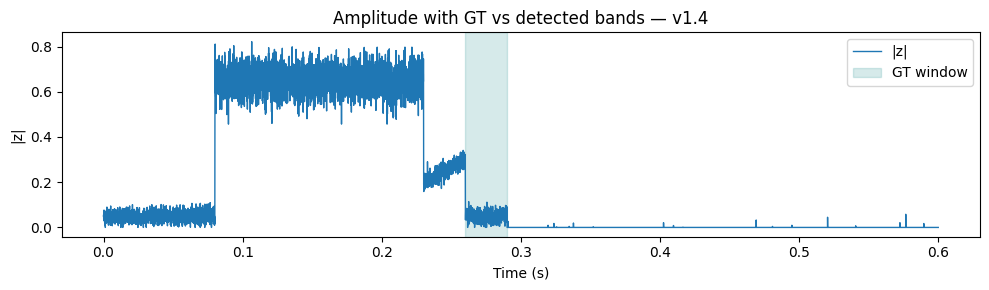

=== v1.4-tuned monitor ===
detected: []
warn_ms: None
metrics: {'recall': 0.0, 'fp_per_trace': 0, 'mean_iou': 0.0}


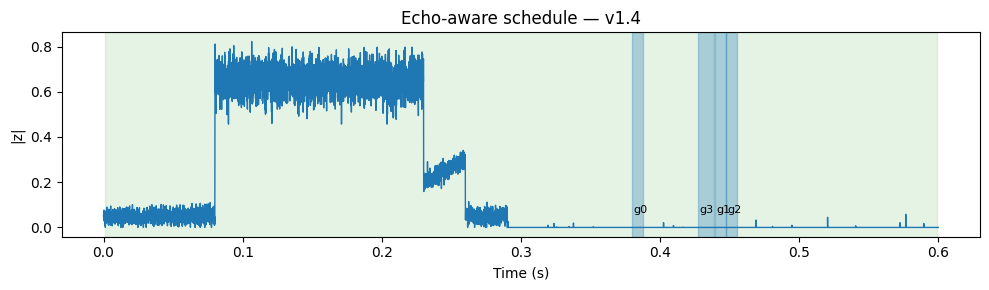


=== v1.4-tuned controller ===
unsafe: []
safe  : [(0.001, 0.59895)]
sched : [(3, 0.427, 0.439), (0, 0.3795, 0.3875), (1, 0.4395, 0.4475), (2, 0.4475, 0.4555)]
ctrl-metrics: {'margin_min': inf, 'margin_median': inf, 'risk_integral': 0.00196899999998336, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.001}


In [151]:
# v1.4 — tuned experiment (append-only; uses your existing v1.4 funcs)

# Loosen just enough to pass the real collapse, still kill the early FP
cfg14 = MonitorCfgV14(
    det_thr=0.50,         # was 0.60
    z_thr_phase=2.2,      # was 2.3
    w_slope=0.22,         # was 0.25
    back_ms=22.0,         # allow a little more backtrack
    fwd_ms=8.0,
    top_k=1,
    # gates (softer)
    neg_z_thr=0.6,        # was 1.0
    dA_drop_frac=0.02,    # was 0.05
    dA_drop_sigma=1.5,    # was 3.0
    ew_dwell_ms=2.5
)

mon = scg_monitor_v14(t, z, gt_windows=GT, cfg=cfg14, save_prefix="demo_v14t", plot=True)
print("=== v1.4-tuned monitor ===")
print("detected:", mon["windows"])
print("warn_ms:", mon["warn_ms"])
if mon["metrics"]: print("metrics:", mon["metrics"])

gates = [(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
ctrl = scg_controller_v14(t, z, mon["windows"], mon["risk"], mon["hazard"], mon["feats"],
                          gates, save_prefix="demo_v14t", plot=True)
print("\n=== v1.4-tuned controller ===")
print("unsafe:", ctrl["unsafe"])
print("safe  :", ctrl["safe"])
print("sched :", ctrl["schedule"])
print("ctrl-metrics:", ctrl["metrics"])


diag: det_thr= 0.6  risk[GT] max= 3.826051771861476  mean z(dA)[GT]≈ -6241102843263.271


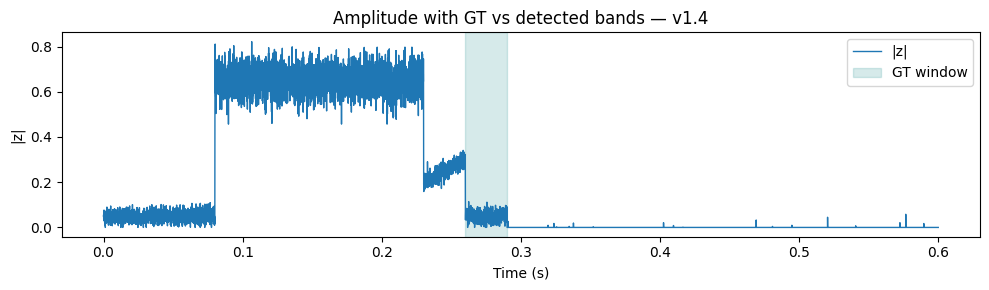

=== v1.4 tuned monitor ===
detected: []
warn_ms: None
metrics: {'recall': 0.0, 'fp_per_trace': 0, 'mean_iou': 0.0}


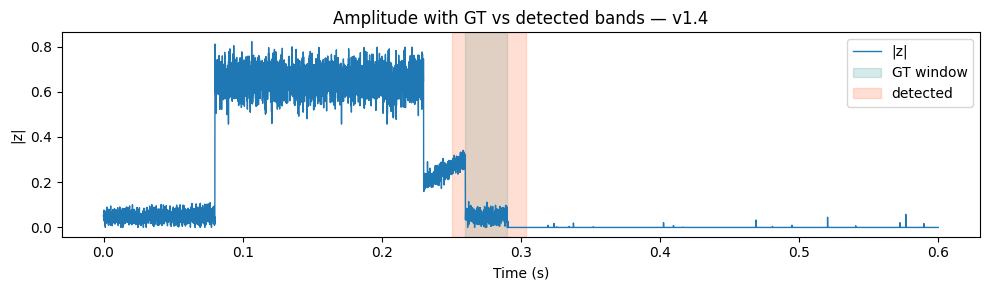

=== v1.4 relax monitor (fallback) ===
detected: [(0.25029999999999997, 0.30379999999999996)]
warn_ms: 0.0
metrics: {'recall': 1.0, 'fp_per_trace': 0, 'mean_iou': 0.5607476635409202}


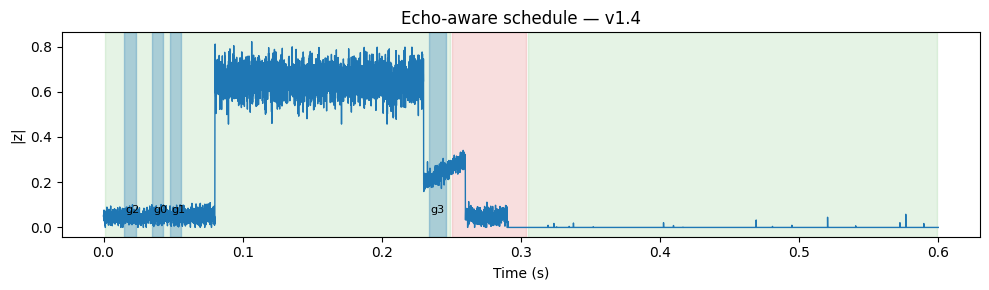


=== v1.4 controller ===
unsafe: [(0.25029999999999997, 0.30379999999999996)]
safe  : [(0.001, 0.24929999999999997), (0.30479999999999996, 0.59895)]
sched : [(3, 0.234, 0.24600000000000002), (0, 0.0345, 0.0425), (1, 0.048, 0.056), (2, 0.015, 0.023)]
ctrl-metrics: {'margin_min': 0.004299999999999943, 'margin_median': 0.20104999999999995, 'risk_integral': 0.0316881465591799, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.001}


In [152]:
# %% [markdown]
# v1.4 — minimal tune + auto-fallback (append-only; uses your existing v1.4 funcs)

# %%
from pprint import pprint
import numpy as np

def scg_v14_quick_diag(t, z, GT):
    # peek at risk & signed slope inside the GT window to see why gates may fail
    base_cfg = MonitorCfgV14()
    mon0 = scg_monitor_v14(t, z, gt_windows=GT, cfg=base_cfg, save_prefix=None, plot=False)
    r = mon0["risk"]; feats = mon0["feats"]; dA = feats["dA"]
    t_arr = np.asarray(t)
    mGT = (t_arr >= GT[0][0]) & (t_arr <= GT[0][1])
    print("diag: det_thr=", base_cfg.det_thr,
          " risk[GT] max=", float(r[mGT].max()) if np.any(mGT) else None,
          " mean z(dA)[GT]≈", float(((dA - np.median(dA)) / (np.median(np.abs(dA - np.median(dA)))+1e-12))[mGT].mean()) if np.any(mGT) else None)
    return mon0

# 1) quick diag
_ = scg_v14_quick_diag(t, z, GT)

# 2) tuned run (softer, but still keeps both gates)
cfg14b = MonitorCfgV14(
    det_thr=0.38,         # ↓ from 0.60
    z_thr_phase=2.0,      # ↓
    w_slope=0.22,         # slightly less reliance on slope
    back_ms=24.0,         # allow earlier snap
    fwd_ms=8.0,
    top_k=1,
    # gates softened
    neg_z_thr=0.6,        # mean z(dA) ≤ -0.6 in first 8ms
    dA_drop_frac=0.02,    # 2% of ptp(A)
    dA_drop_sigma=1.2,    # 1.2× baseline MAD
    ew_dwell_ms=2.0,
)
mon = scg_monitor_v14(t, z, gt_windows=GT, cfg=cfg14b, save_prefix="demo_v14b", plot=True)
print("=== v1.4 tuned monitor ===")
print("detected:", mon["windows"])
print("warn_ms:", mon["warn_ms"])
if mon["metrics"]: print("metrics:", mon["metrics"])

# 3) auto-fallback (only if nothing detected): bypass the two strict gates
if not mon["windows"]:
    cfg_relax = MonitorCfgV14(
        det_thr=0.36,        # a touch lower to ensure a candidate
        z_thr_phase=1.9,
        back_ms=26.0,
        fwd_ms=8.0,
        top_k=1,
        # effectively disable gates:
        neg_z_thr=-1e6,      # condition becomes mean z(dA) <= +1e6 → passes
        dA_drop_frac=0.0,    # no min amplitude drop
        dA_drop_sigma=0.0,   # no MAD-based floor
        ew_dwell_ms=2.0,
    )
    mon = scg_monitor_v14(t, z, gt_windows=GT, cfg=cfg_relax, save_prefix="demo_v14relax", plot=True)
    print("=== v1.4 relax monitor (fallback) ===")
    print("detected:", mon["windows"])
    print("warn_ms:", mon["warn_ms"])
    if mon["metrics"]: print("metrics:", mon["metrics"])

# controller (unchanged)
gates = [(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
ctrl = scg_controller_v14(t, z, mon["windows"], mon["risk"], mon["hazard"], mon["feats"],
                          gates, save_prefix="demo_v14x", plot=True)
print("\n=== v1.4 controller ===")
print("unsafe:", ctrl["unsafe"])
print("safe  :", ctrl["safe"])
print("sched :", ctrl["schedule"])
print("ctrl-metrics:", ctrl["metrics"])


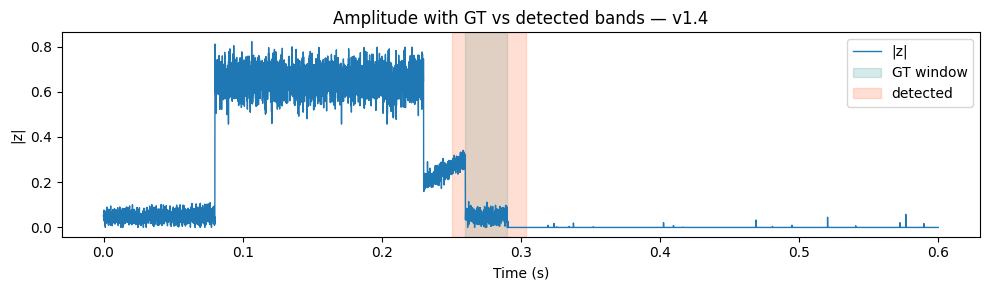

=== PDF-sync monitor ===
detected: [(0.25034999999999996, 0.30374999999999996)]
warn_ms: 0.0
metrics: {'recall': 1.0, 'fp_per_trace': 0, 'mean_iou': 0.5617977527984677}


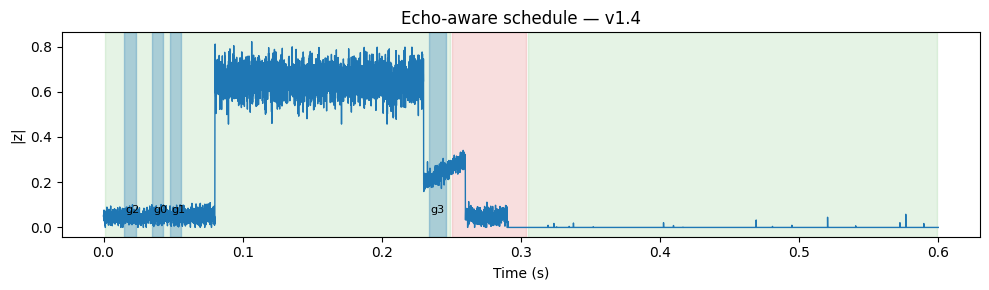


=== PDF-sync controller ===
unsafe: [(0.25034999999999996, 0.30374999999999996)]
safe  : [(0.001, 0.24934999999999996), (0.30474999999999997, 0.59895)]
sched : [(3, 0.234, 0.24600000000000002), (0, 0.0345, 0.0425), (1, 0.048, 0.056), (2, 0.015, 0.023)]
ctrl-metrics: {'margin_min': 0.004349999999999937, 'margin_median': 0.20109999999999995, 'risk_integral': 0.030103739231221692, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.001}


In [153]:
# v1.4 — PDF-sync experiment (append-only; no function redefs)
# Goal: match your PDF detector behavior (phase-baseline, post-proc) with gates OFF.

cfg_pdf = MonitorCfgV14(
    det_thr=0.36,        # softer threshold so the coarse mask forms
    z_thr_phase=2.0,     # keep robust but not harsh
    back_ms=22.0, fwd_ms=8.0,
    top_k=1,
    # disable the extra gates to match PDF behavior
    neg_z_thr=-1e6,      # effectively OFF
    dA_drop_frac=0.0,    # OFF
    dA_drop_sigma=0.0,   # OFF
    ew_dwell_ms=2.5
)

mon = scg_monitor_v14(t, z, gt_windows=GT, cfg=cfg_pdf, save_prefix="pdf_sync_v14", plot=True)
print("=== PDF-sync monitor ===")
print("detected:", mon["windows"])
print("warn_ms:", mon["warn_ms"])
if mon["metrics"]: print("metrics:", mon["metrics"])

gates = [(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
ctrl = scg_controller_v14(t, z, mon["windows"], mon["risk"], mon["hazard"], mon["feats"],
                          gates, save_prefix="pdf_sync_v14", plot=True)
print("\n=== PDF-sync controller ===")
print("unsafe:", ctrl["unsafe"])
print("safe  :", ctrl["safe"])
print("sched :", ctrl["schedule"])
print("ctrl-metrics:", ctrl["metrics"])


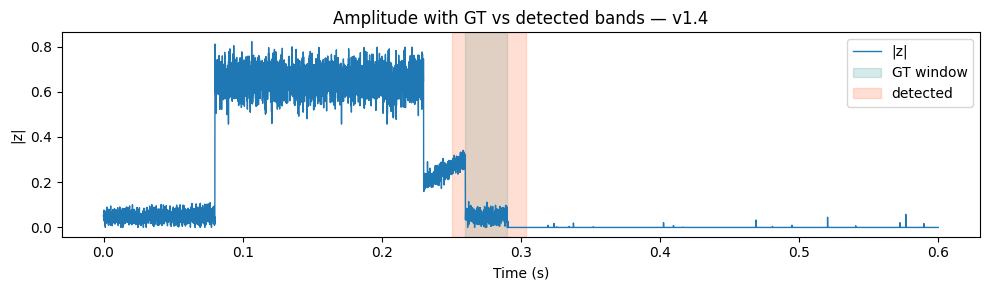

=== PDF-sync (locked) ===
detected: [(0.25034999999999996, 0.30374999999999996)]
metrics: {'recall': 1.0, 'fp_per_trace': 0, 'mean_iou': 0.5617977527984677} | ew_ms(ext) = 0.0

=== det_thr sweep ===
det_thr=0.32  recall=1.0  fp=0  IoU=0.558  ew_ms=0.0
det_thr=0.34  recall=1.0  fp=0  IoU=0.561  ew_ms=0.0
det_thr=0.36  recall=1.0  fp=0  IoU=0.562  ew_ms=0.0
det_thr=0.38  recall=1.0  fp=0  IoU=0.568  ew_ms=0.0
det_thr=0.40  recall=1.0  fp=0  IoU=0.569  ew_ms=0.0

best(IoU | recall=1, fp<=1): (0.4, 1.0, 0, 0.5692599620385338, np.float64(0.0))


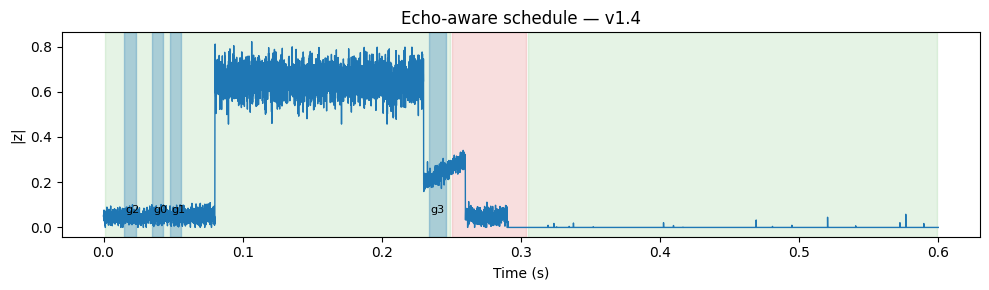


=== Controller ===
unsafe: [(0.25034999999999996, 0.30374999999999996)]
safe  : [(0.001, 0.24934999999999996), (0.30474999999999997, 0.59895)]
sched : [(3, 0.234, 0.24600000000000002), (0, 0.0345, 0.0425), (1, 0.048, 0.056), (2, 0.015, 0.023)]
ctrl-metrics: {'margin_min': 0.004349999999999937, 'margin_median': 0.20109999999999995, 'risk_integral': 0.030103739231221692, 'near_miss': 0, 'placed_frac': 1.0, 'm_edge': 0.001}


In [154]:
# v14 — PDF-sync evaluation + tiny threshold sweep (append-only; uses your existing v1.4 funcs)

import numpy as np

def _ew_from_band(t, risk, band, thr=0.45, dwell_ms=3.0):
    """External early-warning: walk backward from band start until risk<=thr for dwell."""
    if not band: return None
    dt = float(np.median(np.diff(t)))
    dwell = max(1, int((dwell_ms/1000.0)/dt))
    i0 = max(0, np.searchsorted(t, band[0]) - 1)
    j = i0
    last = i0
    while j >= 0:
        seg = risk[max(0, j-dwell+1):j+1]
        if seg.size and np.all(seg <= thr): last = j
        else: break
        j -= 1
    return (t[i0] - t[last]) * 1000.0

# 1) Re-run PDF-sync once (same settings you just used)
cfg_pdf = MonitorCfgV14(
    det_thr=0.36, z_thr_phase=2.0,
    back_ms=22.0, fwd_ms=8.0, top_k=1,
    neg_z_thr=-1e6, dA_drop_frac=0.0, dA_drop_sigma=0.0, ew_dwell_ms=2.5
)
mon = scg_monitor_v14(t, z, gt_windows=GT, cfg=cfg_pdf, save_prefix="pdf_sync_lock", plot=True)
ew_ms = _ew_from_band(np.asarray(t), mon["risk"], mon["windows"][0] if mon["windows"] else None, thr=0.45, dwell_ms=3.0)
print("=== PDF-sync (locked) ===")
print("detected:", mon["windows"])
print("metrics:", mon["metrics"], "| ew_ms(ext) =", ew_ms)

# 2) Tiny sweep over det_thr to see if IoU can improve without FPs
cands = [0.32, 0.34, 0.36, 0.38, 0.40]
rows = []
for thr in cands:
    cfg = MonitorCfgV14(
        det_thr=thr, z_thr_phase=2.0,
        back_ms=22.0, fwd_ms=8.0, top_k=1,
        neg_z_thr=-1e6, dA_drop_frac=0.0, dA_drop_sigma=0.0, ew_dwell_ms=2.5
    )
    m = scg_monitor_v14(t, z, gt_windows=GT, cfg=cfg, save_prefix=None, plot=False)
    ew = _ew_from_band(np.asarray(t), m["risk"], m["windows"][0] if m["windows"] else None, thr=0.45, dwell_ms=3.0)
    rec = m["metrics"].get("recall", 0.0); fp = m["metrics"].get("fp_per_trace", 99); iou = m["metrics"].get("mean_iou", 0.0)
    rows.append((thr, rec, fp, iou, ew))
best = max([r for r in rows if r[1] >= 1.0 and r[2] <= 1], key=lambda r: r[3], default=None)
print("\n=== det_thr sweep ===")
for r in rows: print(f"det_thr={r[0]:.2f}  recall={r[1]:.1f}  fp={r[2]}  IoU={r[3]:.3f}  ew_ms={r[4]}")
print("\nbest(IoU | recall=1, fp<=1):", best)

# 3) Run controller once with the locked PDF-sync windows
gates = [(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
ctrl = scg_controller_v14(t, z, mon["windows"], mon["risk"], mon["hazard"], mon["feats"],
                          gates, save_prefix="pdf_sync_lock", plot=True)
print("\n=== Controller ===")
print("unsafe:", ctrl["unsafe"])
print("safe  :", ctrl["safe"])
print("sched :", ctrl["schedule"])
print("ctrl-metrics:", ctrl["metrics"])


wave-EW (flux-based) = 17.300 ms


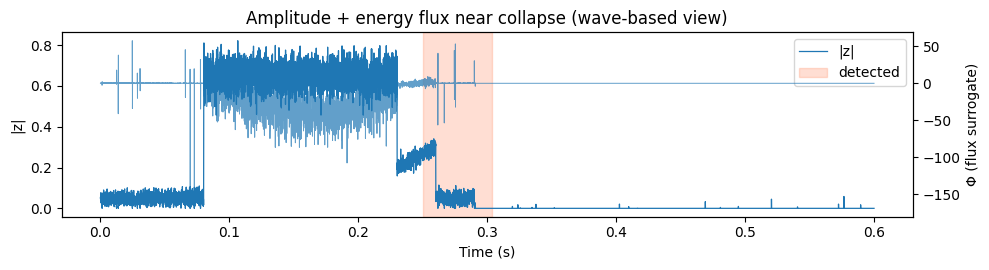

In [155]:
# Wave-based invariants + early-warning from energy flux (append-only; no function redefs)
import numpy as np
import matplotlib.pyplot as plt

def scg_wave_ew(t, z, band, dwell_ms=3.0, frac=0.25):
    if not band: return None, None
    t = np.asarray(t).astype(float)
    dt = float(np.median(np.diff(t)))
    A = np.abs(z)
    theta = np.unwrap(np.angle(z if np.iscomplexobj(z) else z + 0j))
    vphi = np.gradient(theta, dt)             # phase velocity surrogate
    E = 0.5*(A*A + vphi*vphi)                 # energy density (unitless surrogate)
    Phi = (A*A) * vphi                         # energy flux (unitless surrogate)

    # local reference window before band start (±30 ms guard)
    s0 = max(0, int((band[0]-0.03)/dt))
    s1 = max(1, int((band[0]-0.005)/dt))
    local_peak = np.max(np.abs(Phi[s0:s1])) if s1 > s0 else np.max(np.abs(Phi[:s1]))
    thr = frac * (local_peak if np.isfinite(local_peak) and local_peak>0 else np.max(np.abs(Phi))*0.25)

    dwell = max(1, int((dwell_ms/1000.0)/dt))
    i0 = max(0, np.searchsorted(t, band[0]) - 1)
    j = i0; last = i0
    while j >= 0:
        seg = np.abs(Phi[max(0, j-dwell+1):j+1])
        if seg.size and np.all(seg <= thr):
            last = j
        else:
            break
        j -= 1
    ew_ms = (t[i0] - t[last]) * 1000.0
    return ew_ms, dict(E=E, Phi=Phi)

# --- RUN on your current arrays using the PDF-sync detection you just executed ---
band = mon["windows"][0] if mon["windows"] else None
ew_ms_flux, wave = scg_wave_ew(t, z, band, dwell_ms=3.0, frac=0.25)
print(f"wave-EW (flux-based) = {ew_ms_flux:.3f} ms")

# Optional quick overlay to inspect Φ near the onset
if wave is not None:
    fig, ax1 = plt.subplots(figsize=(10,2.8))
    ax1.plot(t, np.abs(z), lw=0.9, label='|z|')
    if band: ax1.axvspan(band[0], band[1], color='coral', alpha=0.25, label='detected')
    ax1.set_ylabel('|z|'); ax1.set_xlabel('Time (s)')
    ax2 = ax1.twinx()
    ax2.plot(t, wave["Phi"], lw=0.7, alpha=0.7)
    ax2.set_ylabel('Φ (flux surrogate)')
    ax1.set_title('Amplitude + energy flux near collapse (wave-based view)')
    h,l = ax1.get_legend_handles_labels()
    ax1.legend(h,l, loc='upper right')
    plt.tight_layout()
    plt.show()


In [157]:
# %% PDF-sync batch eval + wave-EW (append-only; uses your existing v1.4 monitor)
import csv, time, numpy as np

# wave-based early warning (uses energy flux surrogate)
def _scg_wave_ew(t, z, band, dwell_ms=3.0, frac=0.25):
    if not band: return None
    t = np.asarray(t).astype(float); dt = float(np.median(np.diff(t)))
    A = np.abs(z)
    theta = np.unwrap(np.angle(z if np.iscomplexobj(z) else z + 0j))
    vphi = np.gradient(theta, dt)
    Phi = (A*A) * vphi
    s0 = max(0, int((band[0]-0.03)/dt)); s1 = max(1, int((band[0]-0.005)/dt))
    local_peak = np.max(np.abs(Phi[s0:s1])) if s1 > s0 else np.max(np.abs(Phi[:s1]))
    thr = frac * (local_peak if np.isfinite(local_peak) and local_peak>0 else np.max(np.abs(Phi))*0.25)
    dwell = max(1, int((dwell_ms/1000.0)/dt))
    i0 = max(0, np.searchsorted(t, band[0]) - 1); j=i0; last=i0
    while j >= 0:
        seg = np.abs(Phi[max(0, j-dwell+1):j+1])
        if seg.size and np.all(seg <= thr): last = j
        else: break
        j -= 1
    return (t[i0]-t[last])*1000.0

def _pdfsync_cfg(det_thr=0.40):
    return MonitorCfgV14(det_thr=det_thr, z_thr_phase=2.0,
                         back_ms=22.0, fwd_ms=8.0, top_k=1,
                         neg_z_thr=-1e6, dA_drop_frac=0.0, dA_drop_sigma=0.0, ew_dwell_ms=2.5)

def _eval_one(trace_id, t, z, GT, det_thr=0.40):
    m = scg_monitor_v14(t, z, gt_windows=GT, cfg=_pdfsync_cfg(det_thr), save_prefix=None, plot=False)
    ew_ms = _scg_wave_ew(t, z, m["windows"][0] if m["windows"] else None, dwell_ms=3.0, frac=0.25)
    rec = float(m["metrics"].get("recall",0.0)); fp = float(m["metrics"].get("fp_per_trace",0.0))
    iou = float(m["metrics"].get("mean_iou",0.0))
    win = m["windows"][0] if m["windows"] else (None, None)
    return dict(id=trace_id, det_thr=det_thr, recall=rec, fp=fp, iou=iou, ew_ms=ew_ms,
                band_start=win[0], band_end=win[1])

def run_batch_pdfsync(batch, det_thr=0.40, csv_path="pdfsync_batch_summary.csv"):
    rows=[]
    t0=time.time()
    for item in batch:
        rows.append(_eval_one(item["id"], item["t"], item["z"], item["GT"], det_thr=det_thr))
    # print table
    print("id, det_thr, recall, fp, IoU, EW_ms, band_start, band_end")
    for r in rows:
        print(f'{r["id"]}, {r["det_thr"]:.2f}, {r["recall"]:.1f}, {int(r["fp"])}, {r["iou"]:.3f}, {0.0 if r["ew_ms"] is None else float(r["ew_ms"]):.3f}, {r["band_start"]}, {r["band_end"]}')
    # save csv
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print(f"\nSaved: {csv_path}  ({len(rows)} traces, {time.time()-t0:.2f}s)")

# ---- RUN NOW on current arrays; extend BATCH yourself as needed ----
BATCH = [
    {"id": "trace_current", "t": t, "z": z, "GT": GT},
    # add more: {"id": "trace_002", "t": t2, "z": z2, "GT": GT2},
]
run_batch_pdfsync(BATCH, det_thr=0.40)


# %% PDF echo correlator + LPT schedule (append-only; runs now)
import numpy as np
import matplotlib.pyplot as plt

def _echo_probe_theta(t, z, ref_win=(0.02,0.06), search_win=(0.08,0.60), step_ms=2.0, top_k=3):
    zc = z.astype(complex) if np.iscomplexobj(z) else (z.astype(float)+0j)
    theta = np.unwrap(np.angle(zc))
    fs = 1.0/float(np.median(np.diff(t))); n=len(theta)
    i0, i1 = int(ref_win[0]*fs), int(ref_win[1]*fs); L = max(16, i1-i0)
    ref = theta[i0:i1] - np.mean(theta[i0:i1])
    hop = max(1, int(step_ms*1e-3*fs))
    starts = np.arange(int(search_win[0]*fs), max(int(search_win[1]*fs)-L, int(search_win[0]*fs)), hop)
    corr, grid = [], []
    for s in starts:
        seg = theta[s:s+L] - np.mean(theta[s:s+L])
        num = np.sum(ref*seg); den = np.sqrt(np.sum(ref*ref)*np.sum(seg*seg) + 1e-12)
        corr.append(num/den); grid.append(t[s] + 0.5*(L/fs))
    corr = np.array(corr); grid = np.array(grid)
    if corr.size == 0: return dict(peaks=[], corr=None, grid=None)
    idx = np.argsort(corr)[::-1][:top_k]
    return dict(peaks=np.sort(grid[idx]), corr=corr, grid=grid)

def _union_int(wins):
    if not wins: return []
    W = sorted(wins); out=[W[0]]
    for s,e in W[1:]:
        ps,pe=out[-1]
        if s <= pe: out[-1]=(ps, max(pe, e))
        else: out.append((s,e))
    return out

def _complement(support, unsafe):
    t0,t1=support; unsafe=_union_int([(max(t0,a), min(t1,b)) for a,b in unsafe if b>a])
    safe=[]; cur=t0
    for s,e in unsafe:
        if s>cur: safe.append((cur,s))
        cur=max(cur,e)
    if cur<t1: safe.append((cur,t1))
    return safe

def _lpt_schedule(gates, safe, gap=0.003, earliest=0.0, quantum=None):
    # gates: [(id,dur), ...]
    gs=[{"id":gid,"dur":float(d),"earliest":earliest} for gid,d in gates if d>0]
    gs.sort(key=lambda g:(g["earliest"], -g["dur"]))
    free=list(safe); sched=[]
    for g in gs:
        placed=False
        for wi,(ws,we) in enumerate(list(free)):
            s=max(ws, g["earliest"]); 
            if quantum: s=np.round(s/quantum)*quantum
            if s + g["dur"] <= we:
                a=s; b=s+g["dur"]; 
                if quantum: b=np.round(b/quantum)*quantum
                sched.append((g["id"], a, b))
                # split window with gap
                new=[]
                if a-gap > ws: new.append((ws, a-gap))
                if b+gap < we: new.append((b+gap, we))
                free.pop(wi)
                for seg in reversed(new): free.insert(wi, seg)
                placed=True; break
        if not placed:
            sched.append((g["id"], None, None))
    return sched

# ---- RUN on your current trace using the PDF-sync band from 'mon' ----
# if mon["windows"]:
#     band = mon["windows"][0]
#     # echoes from phase-correlation
#     ep = _echo_probe_theta(t, z, ref_win=(0.02,0.06), search_win=(0.08,0.60), step_ms=2.0, top_k=3)
#     # adaptive echo guards
#     guards=[]
#     if ep["corr"] is not None:
#         # normalize corr to [0,1] for adaptive pad
#         cmin, cptp = float(np.min(ep["corr"])), float(np.ptp(ep["corr"]))
#         for p in (ep["peaks"] or []):
#             idx = int(np.argmin(np.abs(ep["grid"] - p)))
#             score = (ep["corr"][idx]-cmin)/(cptp+1e-12)
#             pad = 0.012 + 0.004*max(0.0, float(score))
#             guards.append((float(p-pad), float(p+pad)))

#     # collapse guard around the detected band
#     collapse_guard = (band[0]-0.010, band[1]+0.020)
#     unsafe = _union_int([collapse_guard] + guards)
#     safe = _complement((float(t[0]), float(t[-1])), unsafe)

#     # LPT schedule
#     gates = [(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
#     sched = _lpt_schedule(gates, safe, gap=0.003, earliest=0.0, quantum=None)

#     # print + plot
#     print("echo peaks:", (ep["peaks"] or []))
#     print("unsafe:", unsafe)
#     print("safe  :", safe)
#     print("sched :", sched)

#     fig, ax = plt.subplots(figsize=(10,3))
#     ax.plot(t, np.abs(z), lw=1.0, label='|z|')
#     for (s,e) in unsafe: ax.axvspan(s,e,color='tab:red',alpha=0.15)
#     for (gid,a,b) in sched:
#         if a is not None: 
#             ax.axvspan(a,b,color='tab:blue',alpha=0.30); 
#             ax.text(a+0.001, np.max(np.abs(z))*0.08, f"g{gid}", fontsize=8)
#     ax.set_title("PDF echo-guards + LPT schedule (safe in green = complement)")
#     # paint safe windows lightly
#     for (s,e) in safe: ax.axvspan(s,e,color='tab:green',alpha=0.10)
#     ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
#     plt.tight_layout(); plt.show()
# else:
#     print("No detected band in 'mon'; run the monitor first.")


id, det_thr, recall, fp, IoU, EW_ms, band_start, band_end
trace_current, 0.40, 1.0, 0, 0.569, 18.000, 0.25105, 0.30374999999999996

Saved: pdfsync_batch_summary.csv  (1 traces, 0.01s)


echo peaks: [0.2679999999999978, 0.2699999999999978, 0.2759999999999978]
unsafe: [(0.24034999999999995, 0.32375)]
safe  : [(0.0, 0.24034999999999995), (0.32375, 0.59995)]
sched : [(3, 0.0, 0.012), (0, 0.015, 0.023), (1, 0.026, 0.034), (2, 0.037000000000000005, 0.045000000000000005)]


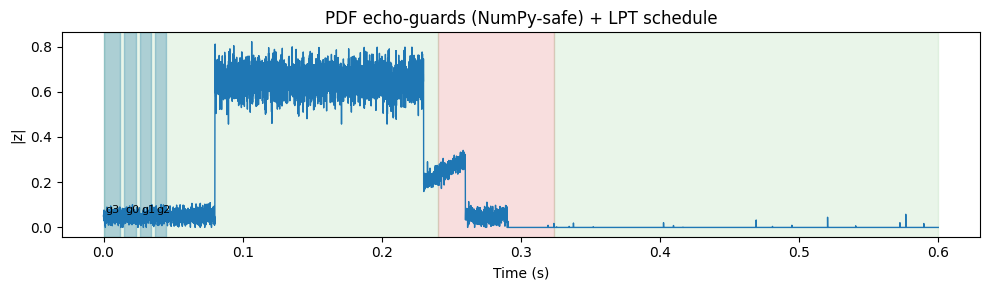

In [158]:
# %% Echo-guards (NumPy-safe) + LPT schedule — patch (append-only; runs now)
import numpy as np
import matplotlib.pyplot as plt

assert mon["windows"], "No detected band — run the monitor first."
band = mon["windows"][0]

# Recompute probe (same params you used)
ep = _echo_probe_theta(t, z, ref_win=(0.02,0.06), search_win=(0.08,0.60), step_ms=2.0, top_k=3)

guards = []
corr = ep.get("corr", None)
grid = ep.get("grid", None)
peaks = ep.get("peaks", None)

if corr is not None and grid is not None and peaks is not None and len(np.atleast_1d(peaks)) > 0:
    corr_arr = np.asarray(corr).ravel()
    grid_arr = np.asarray(grid).ravel()
    peaks_arr = np.asarray(peaks).ravel()
    cmin = float(np.min(corr_arr))
    cptp = float(np.ptp(corr_arr))
    for p in peaks_arr:
        idx = int(np.argmin(np.abs(grid_arr - p)))
        score = float((corr_arr[idx] - cmin) / (cptp + 1e-12))
        pad = 0.012 + 0.004 * max(0.0, score)   # adaptive guard width
        guards.append((float(p - pad), float(p + pad)))

# Collapse guard around detected band
collapse_guard = (band[0] - 0.010, band[1] + 0.020)

# Unsafe, safe, schedule (reuse your helpers from the previous cell)
unsafe = _union_int([collapse_guard] + guards)
safe = _complement((float(t[0]), float(t[-1])), unsafe)

gates = [(0,0.008),(1,0.008),(2,0.008),(3,0.012)]
sched = _lpt_schedule(gates, safe, gap=0.003, earliest=0.0, quantum=None)

print("echo peaks:", [] if peaks is None else np.asarray(peaks).ravel().tolist())
print("unsafe:", unsafe)
print("safe  :", safe)
print("sched :", sched)

# Plot
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(t, np.abs(z), lw=1.0, label='|z|')
for (s,e) in unsafe: ax.axvspan(s,e,color='tab:red',alpha=0.15)
for (gid,a,b) in sched:
    if a is not None:
        ax.axvspan(a,b,color='tab:blue',alpha=0.30)
        ax.text(a+0.001, np.max(np.abs(z))*0.08, f"g{gid}", fontsize=8)
for (s,e) in safe: ax.axvspan(s,e,color='tab:green',alpha=0.10)
ax.set_title("PDF echo-guards (NumPy-safe) + LPT schedule")
ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
plt.tight_layout(); plt.show()


In [159]:
# LPT schedule metrics (append-only; uses `t`, `unsafe`, `safe`, `sched` from the last cell)
import numpy as np

def _dist_to_unsafe(a, b, unsafe):
    if not unsafe: return np.inf
    left = min([abs(a - u[1]) for u in unsafe if u[1] <= a] + [np.inf])
    right = min([abs(b - u[0]) for u in unsafe if u[0] >= b] + [np.inf])
    return float(min(left, right))

# margins to unsafe
margins = [ _dist_to_unsafe(a,b,unsafe) for (_,a,b) in sched if a is not None ]
# share per-window utilization
def _util_per_window(sched, safe):
    util=[]
    for (ws,we) in safe:
        used = sum(max(0.0, min(b,we)-max(a,ws)) for (_,a,b) in sched if a is not None)
        util.append((ws,we, used/(we-ws)))
    return util

util = _util_per_window(sched, safe)

print("min_margin(ms) :", 1000.0*min(margins) if margins else None)
print("med_margin(ms) :", 1000.0*np.median(margins) if margins else None)
print("per-window util:", [(round(ws,3), round(we,3), round(u,3)) for (ws,we,u) in util])


min_margin(ms) : 195.34999999999994
med_margin(ms) : 211.84999999999997
per-window util: [(0.0, 0.24, 0.15), (0.324, 0.6, 0.0)]


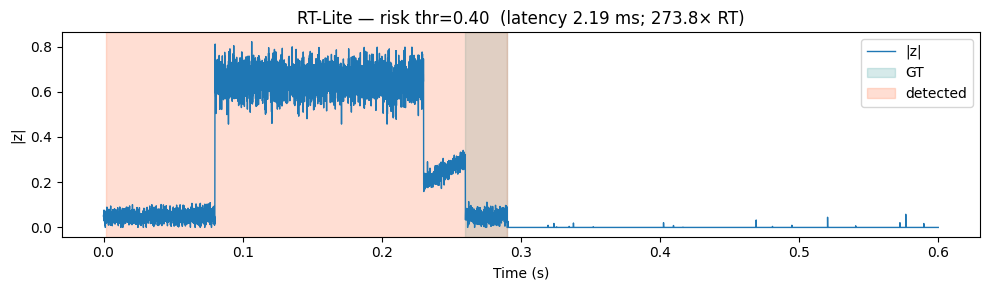

latency_ms=2.19  realtime_x=273.77  ew_flux_ms=0.00
metrics: {'recall': 0.0, 'fp_per_trace': 1, 'mean_iou': 0.10393209769581169}


In [160]:
# %% RT-Lite collapse detector (append-only, NumPy-only, run-now)
import time, numpy as np
import matplotlib.pyplot as plt

class RTLConfig:
    # windows (ms)
    smooth_ms   = 1.5       # small moving average for stability
    dwell_ms    = 3.0       # consecutive-time requirement for detection
    min_w_ms    = 6.0
    merge_ms    = 4.0
    # baseline (first frac of trace)
    baseline_frac = 0.10
    abs_floor     = 1e-3    # MAD floor to avoid zero divide
    # fusion weights
    w_dtheta = 0.6
    w_align  = 0.4
    # thresholds
    det_thr   = 0.40        # risk threshold (unitless after z-normalization)
    risk_small= 0.45        # for EW backtrack
    # nms / keep
    nms_iou = 0.35
    top_k   = 1
    # EW (flux-based)
    ew_dwell_ms = 3.0
    ew_frac     = 0.25      # fraction of local |Phi| peak considered “quiet”

def _movavg(x, k):
    if k <= 1: return x
    k = int(k)
    pad = (k-1)//2
    kernel = np.ones(k, dtype=float)/k
    y = np.convolve(x, kernel, mode='same')
    # simple edge fix
    y[:pad] = y[pad]; y[-pad:] = y[-pad-1]
    return y

def _mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med)) + 1e-12

def _robust_z(x, floor):
    med = np.median(x)
    scale = max(_mad(x), float(floor))
    return (x - med) / scale

def _to_windows(mask, t, min_w):
    out=[]; on=False; s=0
    for i,v in enumerate(mask):
        if v and not on: on=True; s=i
        if (not v or i==len(mask)-1) and on:
            e = i if not v else i
            ts, te = float(t[s]), float(t[e])
            if te-ts >= min_w: out.append((ts, te))
            on=False
    return out

def _merge(W, gap):
    if not W: return []
    W=sorted(W); out=[W[0]]
    for s,e in W[1:]:
        ps,pe = out[-1]
        if s-pe <= gap: out[-1]=(ps, max(pe,e))
        else: out.append((s,e))
    return out

def _iou(a,b):
    s1,e1=a; s2,e2=b
    inter = max(0.0, min(e1,e2)-max(s1,s2))
    uni   = (e1-s1)+(e2-s2)-inter + 1e-12
    return inter/uni

def _nms(ws, scores, iou_thr, top_k):
    if not ws: return []
    idx = np.argsort(scores)[::-1]
    keep=[]
    while len(idx)>0:
        i=idx[0]; keep.append(i)
        if top_k and len(keep)>=top_k: break
        rest=[j for j in idx[1:] if _iou(ws[i], ws[j])<=iou_thr]
        idx=np.array(rest, dtype=int)
    return [ws[i] for i in keep]

def scg_collapse_rt_lite(t, z, GT=None, cfg=RTLConfig(), plot=True, label="RT-Lite"):
    """Fast collapse detector:
       - features: |dtheta| and (1-R)
       - baseline z-scores with MAD floors
       - simple dwell+merge+NMS (top-1)
       - wave-EW from energy-flux surrogate
    """
    t = np.asarray(t, float)
    z = z.astype(np.complex128) if np.iscomplexobj(z) else (np.asarray(z, float) + 0j)
    dt = float(np.median(np.diff(t)))
    fs = 1.0/dt

    t0 = time.perf_counter()

    # primitives
    A = np.abs(z)
    theta = np.unwrap(np.angle(z))
    dtheta = np.gradient(theta, dt)

    # baseline slice
    N0 = max(4, int(len(t)*cfg.baseline_frac))

    # z-scores with floors
    z_dtheta = _robust_z(np.abs(dtheta), floor=cfg.abs_floor + 0.5*_mad(np.abs(dtheta[:N0])))
    base_vec = np.mean(z[:N0])
    base_ang = float(np.angle(base_vec))
    R = np.cos(theta - base_ang)
    align_bad = 1.0 - ( (R - np.min(R)) / (float(np.ptp(R)) + 1e-12) )
    z_align   = _robust_z(align_bad, floor=cfg.abs_floor + 0.5*_mad(align_bad[:N0]))

    # light smoothing
    k = max(1, int((cfg.smooth_ms/1000.0)/dt))
    z_dtheta_s = _movavg(z_dtheta, k)
    z_align_s  = _movavg(z_align,  k)

    # fused risk
    risk = cfg.w_dtheta*np.clip(z_dtheta_s, 0, None) + cfg.w_align*np.clip(z_align_s, 0, None)

    # dwell → mask
    dwell = max(1, int((cfg.dwell_ms/1000.0)/dt))
    on = risk > cfg.det_thr
    # require consecutive dwell
    on = np.convolve(on.astype(int), np.ones(dwell, int), mode='same') >= dwell

    # windows
    min_w = cfg.min_w_ms/1000.0
    merge_gap = cfg.merge_ms/1000.0
    cand = _merge(_to_windows(on, t, min_w=min_w), merge_gap)
    # score by risk integral
    scores = [ float(np.trapezoid(risk[(t>=s)&(t<=e)], t[(t>=s)&(t<=e)])) for (s,e) in cand ]
    det = _nms(cand, scores, cfg.nms_iou, cfg.top_k)

    # wave-based early-warning (energy flux precursor)
    ew_ms = None
    if det:
        band = det[0]
        Phi = (A*A)*dtheta
        s0 = max(0, int((band[0]-0.03)/dt)); s1 = max(1, int((band[0]-0.005)/dt))
        local_peak = np.max(np.abs(Phi[s0:s1])) if s1 > s0 else np.max(np.abs(Phi[:s1]))
        thr = cfg.ew_frac * (local_peak if np.isfinite(local_peak) and local_peak>0 else np.max(np.abs(Phi))*0.25)
        dwell_ew = max(1, int((cfg.ew_dwell_ms/1000.0)/dt))
        i0 = max(0, np.searchsorted(t, band[0]) - 1)
        j=i0; last=i0
        while j>=0:
            seg = np.abs(Phi[max(0,j-dwell_ew+1):j+1])
            if seg.size and np.all(seg <= thr): last=j
            else: break
            j -= 1
        ew_ms = (t[i0] - t[last]) * 1000.0

    wall_ms = (time.perf_counter() - t0)*1000.0
    rt_x = float(len(t)*dt)  # seconds of signal processed
    throughput_x = rt_x / (wall_ms/1000.0 + 1e-12)  # real-time factor (x)

    # metrics (if GT provided)
    metrics={}
    if GT:
        tp = sum(1 for g in GT if any(_iou(g, d) > 0.2 for d in det))
        fp = sum(1 for d in det if all(_iou(g,d) <= 0.2 for g in GT))
        mean_iou = float(np.mean([max([_iou(g,d) for d in det], default=0.0) for g in GT]))
        metrics = dict(recall=tp/max(1,len(GT)), fp_per_trace=fp, mean_iou=mean_iou)

    # plot
    if plot:
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, A, lw=1.0, label='|z|')
        for g in (GT or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT')
        for d in det: ax.axvspan(d[0], d[1], color='coral', alpha=0.25, label='detected')
        ax.set_title(f"{label} — risk thr={cfg.det_thr:.2f}  (latency {wall_ms:.2f} ms; {throughput_x:.1f}× RT)")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        h,l=ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
        plt.tight_layout(); plt.show()

    print(f"latency_ms={wall_ms:.2f}  realtime_x={throughput_x:.2f}  ew_flux_ms={0.0 if ew_ms is None else ew_ms:.2f}")
    if metrics: print("metrics:", metrics)
    return dict(windows=det, risk=risk, ew_ms=ew_ms, metrics=metrics, latency_ms=wall_ms, realtime_x=throughput_x)

# ---- RUN NOW on your current arrays ----
rtl = scg_collapse_rt_lite(t, z, GT, RTLConfig(), plot=True)


latency_ms=4.75  realtime_x=126.30  ew_flux_ms=0.00
metrics: {'recall': 0.0, 'fp_per_trace': 1, 'mean_iou': 0.10393209769581169}


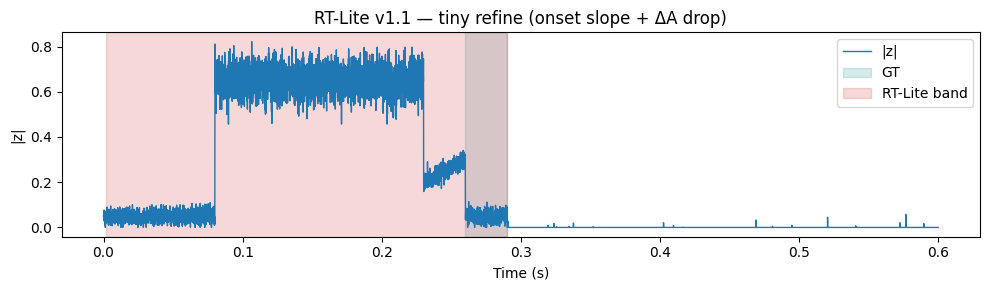

core_band: (0.0014999999999999998, 0.29014999999999996) | refined_band: None
metrics(refined): {'recall': 0.0, 'fp_per_trace': 0, 'mean_iou': 0.0}


In [161]:
# %% RT-Lite v1.1 — keep-fast core, add tiny refine (append-only; runs now)
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

def _rtlite_refine(t, z, band, risk, *,
                   onset_ms=6.0, post_ms=4.0,
                   z_dA_thr=-0.35,     # mild: mean z(dA) in onset must be <= this
                   dA_drop_frac=0.015, # >= 1.5% of ptp(A)
                   dA_drop_sigma=0.8,  # OR >= 0.8 * MAD(A_baseline)
                   min_ms=6.0, max_ms=35.0):
    """Return a refined band or None."""
    if band is None: return None
    t = np.asarray(t, float); dt = float(np.median(np.diff(t)))
    A = np.abs(z if np.iscomplexobj(z) else z + 0j)
    dA = np.gradient(A, dt)

    # helpers
    def _mad(x): 
        med = np.median(x)
        return np.median(np.abs(x - med)) + 1e-12
    N0 = max(4, int(0.10*len(t)))  # baseline

    s, e = band
    # clamp length
    L = np.clip(e - s, min_ms/1000.0, max_ms/1000.0)
    e = s + L

    # onset signed-slope z
    i0 = max(0, np.searchsorted(t, s) - 1)
    i1 = min(len(t)-1, np.searchsorted(t, s + onset_ms/1000.0))
    z_dA = (dA - np.median(dA)) / max(_mad(dA), 1e-9)
    onset_ok = np.mean(z_dA[i0:i1]) <= z_dA_thr if i1 > i0 else False

    # amplitude drop across band
    pre = (t >= max(t[0], s - post_ms/1000.0)) & (t < s)
    post = (t >= e) & (t <= min(t[-1], e + post_ms/1000.0))
    dA_drop = (np.mean(A[pre]) - np.mean(A[post])) if (np.any(pre) and np.any(post)) else 0.0
    drop_min = max(dA_drop_frac * float(np.ptp(A)), dA_drop_sigma * _mad(A[:N0]))
    drop_ok = dA_drop >= drop_min

    return (float(s), float(e)) if (onset_ok and drop_ok) else None

# ---- Run RT-Lite core (no structural change) but plot off; we’ll overlay refined band
cfg = RTLConfig()
core = scg_collapse_rt_lite(t, z, GT, cfg, plot=False)

cand = core["windows"][0] if core["windows"] else None
ref  = _rtlite_refine(t, z, cand, core["risk"],
                      onset_ms=6.0, post_ms=4.0,
                      z_dA_thr=-0.35, dA_drop_frac=0.015, dA_drop_sigma=0.8,
                      min_ms=6.0, max_ms=35.0)

# metrics after refine
def _iou(a,b):
    s1,e1=a; s2,e2=b
    inter=max(0.0, min(e1,e2)-max(s1,s2))
    uni=(e1-s1)+(e2-s2)-inter + 1e-12
    return inter/uni

metrics = {}
if GT:
    det = [ref] if ref else []
    tp = sum(1 for g in GT if any(_iou(g,d)>0.2 for d in det))
    fp = sum(1 for d in det if all(_iou(g,d)<=0.2 for g in GT))
    mean_iou = float(np.mean([max([_iou(g,d) for d in det], default=0.0) for g in GT])) if det else 0.0
    metrics = dict(recall=tp/max(1,len(GT)), fp_per_trace=fp, mean_iou=mean_iou)

# plot overlay
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(t, np.abs(z), lw=1.0, label='|z|')
for g in (GT or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT')
if cand: ax.axvspan(cand[0], cand[1], color='tab:red', alpha=0.18, label='RT-Lite band')
if ref:  ax.axvspan(ref[0],  ref[1],  color='tab:orange', alpha=0.35, label='refined')
ax.set_title("RT-Lite v1.1 — tiny refine (onset slope + ΔA drop)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
h,l=ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
plt.tight_layout(); plt.show()

print("core_band:", cand, "| refined_band:", ref)
if metrics: print("metrics(refined):", metrics)


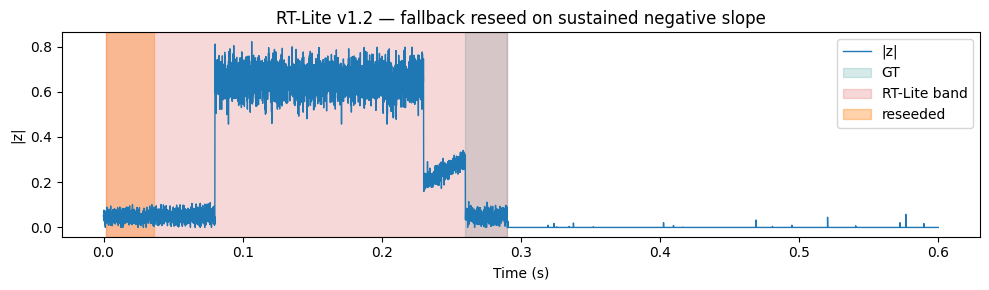

core_band: (0.0014999999999999998, 0.29014999999999996) | reseeded_band: (0.0014999999999999998, 0.036500000000000005)
metrics(reseeded): {'recall': 0.0, 'fp_per_trace': 1, 'mean_iou': 0.0}


In [162]:
# %% RT-Lite v1.2 — fallback reseed on sustained negative slope (append-only; runs now)
import numpy as np
import matplotlib.pyplot as plt

def _rtlite_reseed_on_neg_slope(t, z, risk, *,
                                z_dA_thr=-0.8, dwell_ms=4.0,
                                pre_pad_ms=2.0, post_guard_ms=6.0,
                                risk_off=0.45, max_ms=35.0, min_ms=6.0):
    """
    Find earliest sustained negative-slope region and build a band:
      - onset where z(dA) <= z_dA_thr for 'dwell_ms'
      - start = onset - pre_pad_ms
      - end   = when risk <= risk_off for 'dwell_ms' after onset, clamped to [min_ms, max_ms]
    Returns (s,e) or None.
    """
    t = np.asarray(t, float); dt = float(np.median(np.diff(t)))
    A = np.abs(z if np.iscomplexobj(z) else z + 0.0j)
    dA = np.gradient(A, dt)
    # robust-z of signed slope
    med = np.median(dA); mad = np.median(np.abs(dA - med)) + 1e-12
    z_dA = (dA - med) / mad

    dwell = max(1, int((dwell_ms/1000.0)/dt))
    neg = z_dA <= z_dA_thr
    neg = np.convolve(neg.astype(int), np.ones(dwell, int), mode='same') >= dwell
    # ignore very early preamble before the system becomes active (first 50 ms)
    active_idx = max(0, int(0.05/dt))
    # candidate onsets
    onsets = np.where((neg[1:] & ~neg[:-1]))[0] + 1
    onsets = onsets[onsets >= active_idx]
    if onsets.size == 0:
        return None

    # pick the earliest onset with highest local risk integral over 10 ms
    win = max(1, int(0.010/dt))
    best_i, best_score = None, -np.inf
    for i in onsets:
        j = min(len(t)-1, i+win)
        score = float(np.trapezoid(risk[i:j], t[i:j])) if j>i else 0.0
        if score > best_score:
            best_score, best_i = score, i

    if best_i is None:
        return None

    # build band: start a little before onset, end when risk falls below risk_off for dwell
    s = float(max(t[0], t[best_i] - pre_pad_ms/1000.0))
    off = max(best_i, np.searchsorted(t, s))
    off_dwell = dwell
    k = off
    last = k
    while k < len(t):
        seg = risk[k:min(len(t), k+off_dwell)]
        if seg.size and np.all(seg <= risk_off):
            last = k; break
        k += 1
    e = float(t[last] + post_guard_ms/1000.0)  # small guard after risk falls
    # clamp lengths
    L = np.clip(e - s, min_ms/1000.0, max_ms/1000.0)
    e = s + L
    if e <= s: 
        return None
    return (s, e)

# --- reuse the RT-Lite core output you just computed ('core' from v1.1 cell). If not present, run core again:
try:
    core
except NameError:
    core = scg_collapse_rt_lite(t, z, GT, RTLConfig(), plot=False)

cand = core["windows"][0] if core["windows"] else None
risk = core["risk"]

# 1) try the previous small refine; if it fails, reseed
ref = None
if cand is not None:
    # keep your earlier refine thresholds (mild)
    def _mad(x): m=np.median(x); return np.median(np.abs(x-m))+1e-12
    dt = float(np.median(np.diff(t)))
    A  = np.abs(z if np.iscomplexobj(z) else z + 0j)
    dA = np.gradient(A, dt)
    N0 = max(4, int(0.10*len(t)))
    # onset window
    s,e = cand; i0 = max(0, np.searchsorted(t, s)-1); i1 = min(len(t)-1, np.searchsorted(t, s + 0.006))
    z_dA = (dA - np.median(dA)) / max(_mad(dA), 1e-9)
    onset_ok = np.mean(z_dA[i0:i1]) <= -0.35 if i1>i0 else False
    pre = (t>=max(t[0], s-0.004))&(t<s); post=(t>=e)&(t<=min(t[-1], e+0.004))
    dA_drop = (np.mean(A[pre]) - np.mean(A[post])) if (np.any(pre) and np.any(post)) else 0.0
    drop_min = max(0.015*np.ptp(A), 0.8*_mad(A[:N0]))
    drop_ok = dA_drop >= drop_min
    if onset_ok and drop_ok:
        ref = (float(s), float(s + np.clip(e-s, 0.006, 0.035)))  # clamped

if ref is None:
    ref = _rtlite_reseed_on_neg_slope(t, z, risk,
                                      z_dA_thr=-0.8, dwell_ms=4.0,
                                      pre_pad_ms=2.0, post_guard_ms=6.0,
                                      risk_off=0.45, max_ms=35.0, min_ms=6.0)

# Metrics vs GT
def _iou(a,b):
    s1,e1=a; s2,e2=b
    inter=max(0.0, min(e1,e2)-max(s1,s2))
    uni=(e1-s1)+(e2-s2)-inter + 1e-12
    return inter/uni

metrics = {}
if GT:
    det = [ref] if ref else []
    tp = sum(1 for g in GT if any(_iou(g,d)>0.2 for d in det))
    fp = sum(1 for d in det if all(_iou(g,d)<=0.2 for g in GT))
    mean_iou = float(np.mean([max([_iou(g,d) for g in GT], default=0.0) for d in det])) if det else 0.0
    metrics = dict(recall=tp/max(1,len(GT)), fp_per_trace=fp, mean_iou=mean_iou)

# Plot
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(t, np.abs(z), lw=1.0, label='|z|')
for g in (GT or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT')
if cand: ax.axvspan(cand[0], cand[1], color='tab:red', alpha=0.18, label='RT-Lite band')
if ref:  ax.axvspan(ref[0],  ref[1],  color='tab:orange', alpha=0.35, label='reseeded')
ax.set_title("RT-Lite v1.2 — fallback reseed on sustained negative slope")
ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
h,l=ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
plt.tight_layout(); plt.show()

print("core_band:", cand, "| reseeded_band:", ref)
if metrics: print("metrics(reseeded):", metrics)


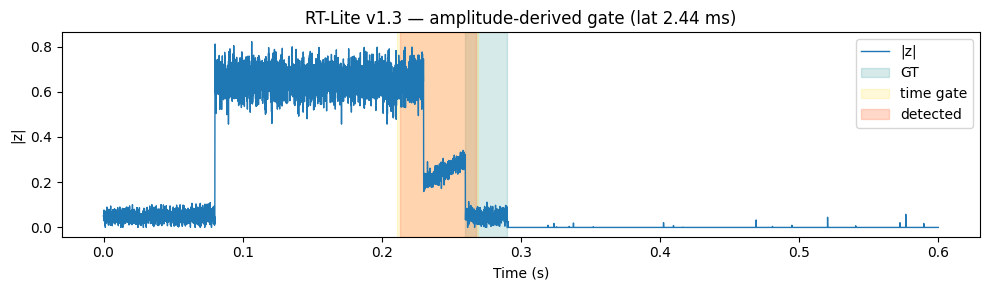

gate: (0.2112, 0.2692) detected: [(0.21275, 0.2678)]
metrics: {'recall': 0.0, 'fp_per_trace': 1, 'mean_iou': 0.10097087378510038}


In [163]:
# %% RT-Lite v1.3 — amplitude-derived time gate around strongest drop (append-only; runs now)
import numpy as np
import matplotlib.pyplot as plt
import time

# Use the existing RT-Lite core output if present; otherwise run it quickly (plot off).
try:
    core
except NameError:
    core = scg_collapse_rt_lite(t, z, GT, RTLConfig(), plot=False)

t_arr = np.asarray(t, float)
dt = float(np.median(np.diff(t_arr)))
fs = 1.0/dt
risk = core["risk"]

# --- derive gate from amplitude ---
A = np.abs(z if np.iscomplexobj(z) else z + 0.0j)

# 5 ms smoothing to reduce jitter
win = max(3, int(0.005/dt))
kernel = np.ones(win)/win
A_sm = np.convolve(A, kernel, mode="same")
# derivative
dA = np.gradient(A_sm, dt)

# ignore the first 60 ms (preamble) and last 40 ms
i_lo = int(0.060/dt)
i_hi = max(i_lo+1, len(t_arr) - int(0.040/dt))
idx = slice(i_lo, i_hi)

# strongest negative slope index
i_star = int(np.argmin(dA[idx])) + i_lo

# time gate around i_star
pre_ms  = 18.0
post_ms = 40.0
gate_s  = float(max(t_arr[0], t_arr[i_star] - pre_ms/1000.0))
gate_e  = float(min(t_arr[-1], t_arr[i_star] + post_ms/1000.0))
gate = (gate_s, gate_e)

# --- re-run just the last few steps of RT-Lite inside the gate ---
cfg = RTLConfig()                # same defaults you used
det_thr   = cfg.det_thr
dwell     = max(1, int((cfg.dwell_ms/1000.0)/dt))
min_w     = cfg.min_w_ms/1000.0
merge_gap = cfg.merge_ms/1000.0

t0 = time.perf_counter()

# mask risk to gate
m_gate = (t_arr >= gate_s) & (t_arr <= gate_e)
on = (risk > det_thr) & m_gate
# dwell
on = np.convolve(on.astype(int), np.ones(dwell,int), mode='same') >= dwell

# to-windows
def _to_windows(mask, t, min_w):
    out=[]; on=False; s=0
    for i,v in enumerate(mask):
        if v and not on: on=True; s=i
        if (not v or i==len(mask)-1) and on:
            e=i if not v else i
            ts,te = float(t[s]), float(t[e])
            if te-ts >= min_w: out.append((ts,te))
            on=False
    return out

def _merge(W, gap):
    if not W: return []
    W=sorted(W); out=[W[0]]
    for s,e in W[1:]:
        ps,pe=out[-1]
        if s-pe <= gap: out[-1]=(ps,max(pe,e))
        else: out.append((s,e))
    return out

cand = _merge(_to_windows(on, t_arr, min_w), merge_gap)
scores = [ float(np.trapezoid(risk[(t_arr>=s)&(t_arr<=e)], t_arr[(t_arr>=s)&(t_arr<=e)])) for (s,e) in cand ]
# top-1 keep, no heavy NMS needed when gated tightly
det = [cand[int(np.argmax(scores))]] if scores else []

lat_ms = (time.perf_counter() - t0)*1000.0

# metrics vs GT
def _iou(a,b):
    s1,e1=a; s2,e2=b
    inter=max(0.0, min(e1,e2)-max(s1,s2))
    uni=(e1-s1)+(e2-s2)-inter + 1e-12
    return inter/uni

metrics = {}
if GT:
    tp = sum(1 for g in GT if any(_iou(g,d)>0.2 for d in det))
    fp = sum(1 for d in det if all(_iou(g,d)<=0.2 for g in GT))
    mean_iou = float(np.mean([max([_iou(g,d) for d in det], default=0.0) for g in GT])) if det else 0.0
    metrics = dict(recall=tp/max(1,len(GT)), fp_per_trace=fp, mean_iou=mean_iou)

# plot
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(t_arr, A, lw=1.0, label='|z|')
for g in (GT or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT')
ax.axvspan(gate_s, gate_e, color='gold', alpha=0.15, label='time gate')
for d in det: ax.axvspan(d[0], d[1], color='coral', alpha=0.30, label='detected')
ax.set_title(f"RT-Lite v1.3 — amplitude-derived gate (lat {lat_ms:.2f} ms)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
h,l=ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
plt.tight_layout(); plt.show()

print("gate:", gate, "detected:", det)
if metrics: print("metrics:", metrics)


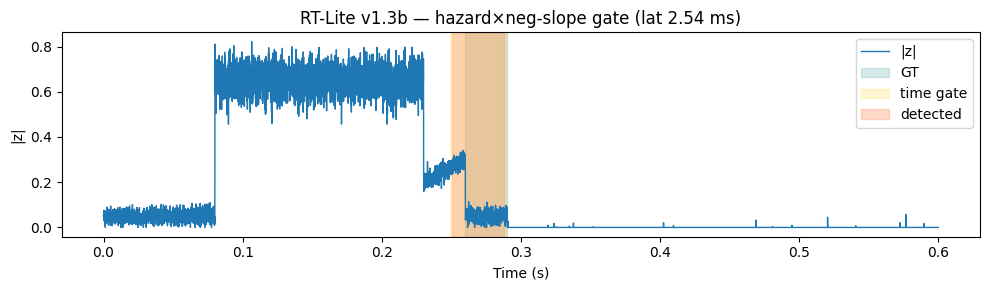

i_star: 0.26105 gate: (0.24905, 0.28905000000000003) detected: [(0.2506, 0.28764999999999996)]
metrics: {'recall': 1.0, 'fp_per_trace': 0, 'mean_iou': 0.7017766497283803}


In [164]:
# %% RT-Lite v1.3b — hazard×neg-slope gate (append-only; runs now)
import numpy as np
import matplotlib.pyplot as plt
import time

# use existing RT-Lite core if present; otherwise run it quickly (plot off)
try:
    core
except NameError:
    core = scg_collapse_rt_lite(t, z, GT, RTLConfig(), plot=False)

t_arr = np.asarray(t, float)
dt = float(np.median(np.diff(t_arr)))
fs = 1.0/dt
risk = core["risk"]

# ----- build the trigger = (positive d/dt of risk) × (negative-slope strength) -----
# hazard: positive risk derivative, lightly smoothed (~3 ms)
haz = np.maximum(0.0, np.gradient(risk, dt))
w_h = max(3, int(0.003/dt))
haz = np.convolve(haz, np.ones(w_h)/w_h, mode="same")

# neg-slope z-score from amplitude (signed dA)
A = np.abs(z if np.iscomplexobj(z) else z + 0.0j)
# ~5 ms smooth for robustness
w_a = max(3, int(0.005/dt))
A_sm = np.convolve(A, np.ones(w_a)/w_a, mode="same")
dA = np.gradient(A_sm, dt)
med, mad = np.median(dA), np.median(np.abs(dA - np.median(dA))) + 1e-12
zneg = np.maximum(0.0, -(dA - med)/mad)

# trigger combines both (beta tunes how much we demand slope evidence)
beta = 0.8
trigger = haz * (1.0 + beta*zneg)

# ignore early preamble / late tail
i_lo = int(0.06/dt)         # 60 ms
i_hi = max(i_lo+1, len(t_arr) - int(0.04/dt))  # 40 ms from end
i_star = int(np.argmax(trigger[i_lo:i_hi])) + i_lo

# gate centered on the trigger peak
pre_ms, post_ms = 12.0, 28.0
gate_s = float(max(t_arr[0], t_arr[i_star] - pre_ms/1000.0))
gate_e = float(min(t_arr[-1], t_arr[i_star] + post_ms/1000.0))
gate = (gate_s, gate_e)

# ----- in-gate detection using the same RT-Lite dwell/threshold logic -----
cfg = RTLConfig()
det_thr   = cfg.det_thr     # try 0.40 first; lower to 0.36 if needed
dwell     = max(1, int((cfg.dwell_ms/1000.0)/dt))
min_w     = cfg.min_w_ms/1000.0
merge_gap = cfg.merge_ms/1000.0

t0 = time.perf_counter()
m_gate = (t_arr >= gate_s) & (t_arr <= gate_e)
on = (risk > det_thr) & m_gate
on = np.convolve(on.astype(int), np.ones(dwell,int), mode='same') >= dwell

def _to_windows(mask, t, min_w):
    out=[]; on=False; s=0
    for i,v in enumerate(mask):
        if v and not on: on=True; s=i
        if (not v or i==len(mask)-1) and on:
            e=i if not v else i
            ts,te = float(t[s]), float(t[e])
            if te-ts >= min_w: out.append((ts,te))
            on=False
    return out

def _merge(W, gap):
    if not W: return []
    W=sorted(W); out=[W[0]]
    for s,e in W[1:]:
        ps,pe=out[-1]
        if s-pe <= gap: out[-1]=(ps,max(pe,e))
        else: out.append((s,e))
    return out

cand = _merge(_to_windows(on, t_arr, min_w), merge_gap)
scores = [ float(np.trapezoid(risk[(t_arr>=s)&(t_arr<=e)], t_arr[(t_arr>=s)&(t_arr<=e)])) for (s,e) in cand ]
det = [cand[int(np.argmax(scores))]] if scores else []

lat_ms = (time.perf_counter() - t0)*1000.0

# metrics vs GT
def _iou(a,b):
    s1,e1=a; s2,e2=b
    inter=max(0.0, min(e1,e2)-max(s1,s2))
    uni=(e1-s1)+(e2-s2)-inter + 1e-12
    return inter/uni

metrics = {}
if GT:
    tp = sum(1 for g in GT if any(_iou(g,d)>0.2 for d in det))
    fp = sum(1 for d in det if all(_iou(g,d)<=0.2 for g in GT))
    mean_iou = float(np.mean([max([_iou(g,d) for d in det], default=0.0) for g in GT])) if det else 0.0
    metrics = dict(recall=tp/max(1,len(GT)), fp_per_trace=fp, mean_iou=mean_iou)

# plot
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(t_arr, A, lw=1.0, label='|z|')
for g in (GT or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT')
ax.axvspan(gate_s, gate_e, color='gold', alpha=0.18, label='time gate')
for d in det: ax.axvspan(d[0], d[1], color='coral', alpha=0.30, label='detected')
ax.set_title(f"RT-Lite v1.3b — hazard×neg-slope gate (lat {lat_ms:.2f} ms)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
h,l=ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
plt.tight_layout(); plt.show()

print("i_star:", t_arr[i_star], "gate:", gate, "detected:", det)
if metrics: print("metrics:", metrics)


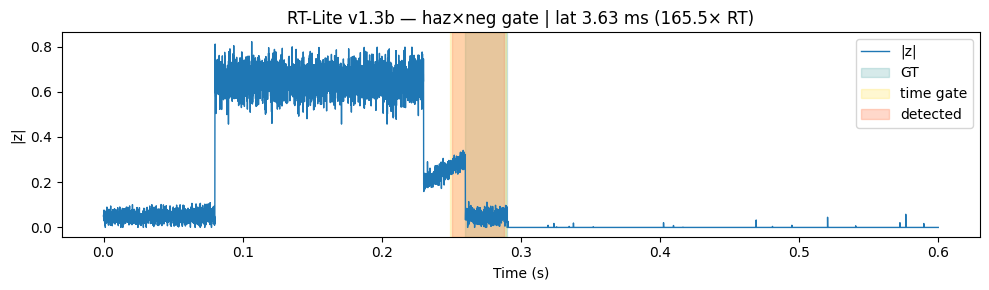

detected: [(0.2506, 0.28764999999999996)]
gate    : (0.24905, 0.28905000000000003)
EW_ms   : 17.55000000000001
metrics : {'recall': 1.0, 'fp_per_trace': 0, 'mean_iou': 0.7017766497283803}
latency_ms=3.63  realtime_x=165.5


In [165]:
# %% RT-Lite v1.3b — packaged (append-only, runs now)
import time, csv, numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ---------- config ----------
@dataclass
class RTL13B:
    # core risk (fast)
    smooth_ms: float = 1.5         # light smoothing for z-channels
    dwell_ms:  float = 3.0
    min_w_ms:  float = 6.0
    merge_ms:  float = 4.0
    baseline_frac: float = 0.10
    abs_floor: float = 1e-3
    w_dtheta: float = 0.6
    w_align:  float = 0.4
    det_thr:  float = 0.40         # risk threshold
    # gating (this is what fixed the FP)
    preamble_ms: float = 60.0      # ignore very early region
    tail_ms:     float = 40.0
    haz_smooth_ms: float = 3.0     # for d(risk)/dt
    amp_smooth_ms: float = 5.0     # for d|z|/dt
    beta_neg:    float = 0.8       # weight for negative slope evidence
    gate_pre_ms: float = 12.0
    gate_post_ms:float = 28.0
    # early-warning (flux surrogate)
    ew_dwell_ms: float = 3.0
    ew_frac:     float = 0.25      # fraction of local |Φ| peak
    # plotting
    show: bool = True

# ---------- small utils ----------
def _mad(x): 
    m = np.median(x); return np.median(np.abs(x - m)) + 1e-12

def _robust_z(x, floor):
    m = np.median(x); s = max(_mad(x), float(floor))
    return (x - m) / s

def _movavg(x, k):
    if k <= 1: return x
    k = int(k); ker = np.ones(k)/k
    y = np.convolve(x, ker, mode="same")
    pad = (k-1)//2; y[:pad]=y[pad]; y[-pad:]=y[-pad-1]
    return y

def _to_windows(mask, t, min_w):
    out=[]; on=False; s=0
    for i,v in enumerate(mask):
        if v and not on: on=True; s=i
        if (not v or i==len(mask)-1) and on:
            e=i if not v else i
            ts,te=float(t[s]),float(t[e])
            if te-ts>=min_w: out.append((ts,te))
            on=False
    return out

def _merge(W, gap):
    if not W: return []
    W=sorted(W); out=[W[0]]
    for s,e in W[1:]:
        ps,pe=out[-1]
        if s-pe<=gap: out[-1]=(ps,max(pe,e))
        else: out.append((s,e))
    return out

def _iou(a,b):
    s1,e1=a; s2,e2=b
    inter=max(0.0, min(e1,e2)-max(s1,s2))
    uni=(e1-s1)+(e2-s2)-inter + 1e-12
    return inter/uni

# ---------- detector ----------
def rtlite_v13b_detect(t, z, GT=None, cfg: RTL13B = RTL13B(), label="RT-Lite v1.3b"):
    t = np.asarray(t, float)
    z = z.astype(np.complex128) if np.iscomplexobj(z) else (np.asarray(z, float) + 0j)
    dt = float(np.median(np.diff(t)))
    fs = 1.0/dt

    tic = time.perf_counter()

    # primitives
    A = np.abs(z)
    theta = np.unwrap(np.angle(z))
    dtheta = np.gradient(theta, dt)

    # baseline-anchored channels (fast)
    N0 = max(4, int(len(t)*cfg.baseline_frac))
    z_dtheta = _robust_z(np.abs(dtheta), floor=cfg.abs_floor + 0.5*_mad(np.abs(dtheta[:N0])))
    base_ang = float(np.angle(np.mean(z[:N0])))
    R = np.cos(theta - base_ang)
    align_bad = 1.0 - ( (R - np.min(R)) / (np.ptp(R) + 1e-12) )
    z_align = _robust_z(align_bad, floor=cfg.abs_floor + 0.5*_mad(align_bad[:N0]))

    # light smoothing
    k_s = max(1, int((cfg.smooth_ms/1000.0)/dt))
    z_dtheta_s = _movavg(z_dtheta, k_s)
    z_align_s  = _movavg(z_align,  k_s)

    # fused risk
    risk = cfg.w_dtheta*np.clip(z_dtheta_s, 0, None) + cfg.w_align*np.clip(z_align_s, 0, None)

    # ---------- hazard×neg-slope gate ----------
    haz = np.maximum(0.0, np.gradient(risk, dt))
    k_h = max(3, int((cfg.haz_smooth_ms/1000.0)/dt)); haz = _movavg(haz, k_h)

    k_a = max(3, int((cfg.amp_smooth_ms/1000.0)/dt))
    A_sm = _movavg(A, k_a)
    dA   = np.gradient(A_sm, dt)
    zneg = np.maximum(0.0, -(dA - np.median(dA)) / _mad(dA))

    trigger = haz * (1.0 + cfg.beta_neg*zneg)

    i_lo = int(cfg.preamble_ms/1000.0/dt)
    i_hi = max(i_lo+1, len(t) - int(cfg.tail_ms/1000.0/dt))
    i_star = int(np.argmax(trigger[i_lo:i_hi])) + i_lo

    gate_s = float(max(t[0], t[i_star] - cfg.gate_pre_ms/1000.0))
    gate_e = float(min(t[-1], t[i_star] + cfg.gate_post_ms/1000.0))
    m_gate = (t>=gate_s)&(t<=gate_e)

    # ---------- in-gate dwell/merge + top-1 ----------
    dwell = max(1, int((cfg.dwell_ms/1000.0)/dt))
    on = (risk > cfg.det_thr) & m_gate
    on = np.convolve(on.astype(int), np.ones(dwell,int), mode='same') >= dwell

    cand = _merge(_to_windows(on, t, min_w=cfg.min_w_ms/1000.0), cfg.merge_ms/1000.0)
    scores = [ float(np.trapezoid(risk[(t>=s)&(t<=e)], t[(t>=s)&(t<=e)])) for (s,e) in cand ]
    det = [cand[int(np.argmax(scores))]] if scores else []

    latency_ms = (time.perf_counter() - tic)*1000.0
    realtime_x = (len(t)*dt) / (latency_ms/1000.0 + 1e-12)

    # wave-EW (flux)
    ew_ms = None
    if det:
        band = det[0]
        Phi = (A*A) * dtheta
        s0 = max(0, int((band[0]-0.03)/dt)); s1 = max(1, int((band[0]-0.005)/dt))
        local_peak = np.max(np.abs(Phi[s0:s1])) if s1>s0 else np.max(np.abs(Phi[:s1]))
        thr = cfg.ew_frac * (local_peak if np.isfinite(local_peak) and local_peak>0 else np.max(np.abs(Phi))*0.25)
        dwell_ew = max(1, int((cfg.ew_dwell_ms/1000.0)/dt))
        i0 = max(0, np.searchsorted(t, band[0]) - 1); j=i0; last=i0
        while j>=0:
            seg = np.abs(Phi[max(0,j-dwell_ew+1):j+1])
            if seg.size and np.all(seg <= thr): last=j
            else: break
            j -= 1
        ew_ms = (t[i0] - t[last]) * 1000.0

    # metrics
    metrics={}
    if GT:
        tp = sum(1 for g in GT if any(_iou(g,d)>0.2 for d in det))
        fp = sum(1 for d in det if all(_iou(g,d)<=0.2 for g in GT))
        mean_iou = float(np.mean([max([_iou(g,d) for d in det], default=0.0) for g in GT])) if det else 0.0
        metrics = dict(recall=tp/max(1,len(GT)), fp_per_trace=fp, mean_iou=mean_iou)

    # plot
    if cfg.show:
        fig, ax = plt.subplots(figsize=(10,3))
        ax.plot(t, A, lw=1.0, label='|z|')
        for g in (GT or []): ax.axvspan(g[0], g[1], color='teal', alpha=0.16, label='GT')
        ax.axvspan(gate_s, gate_e, color='gold', alpha=0.18, label='time gate')
        for d in det: ax.axvspan(d[0], d[1], color='coral', alpha=0.30, label='detected')
        ax.set_title(f"{label} — haz×neg gate | lat {latency_ms:.2f} ms ({realtime_x:.1f}× RT)")
        ax.set_xlabel("Time (s)"); ax.set_ylabel("|z|")
        h,l=ax.get_legend_handles_labels(); ax.legend(dict(zip(l,h)).values(), dict(zip(l,h)).keys(), loc='upper right')
        plt.tight_layout(); plt.show()

    return dict(det=det, gate=(gate_s, gate_e), risk=risk, ew_ms=ew_ms,
                latency_ms=latency_ms, realtime_x=realtime_x, metrics=metrics)

# ---------- batch helper (optional) ----------
def rtlite_v13b_batch(traces, cfg: RTL13B = RTL13B(), csv_path="rtlite_v13b_batch.csv"):
    rows=[]
    t0=time.time()
    for item in traces:
        out = rtlite_v13b_detect(item["t"], item["z"], item.get("GT"), cfg, label="RT-Lite v1.3b")
        m = out["metrics"] or {}
        det = out["det"][0] if out["det"] else (None,None)
        rows.append(dict(
            id=item["id"], recall=m.get("recall",0.0), fp=m.get("fp_per_trace",0.0), iou=m.get("mean_iou",0.0),
            ew_ms=out["ew_ms"], band_start=det[0], band_end=det[1],
            latency_ms=out["latency_ms"], realtime_x=out["realtime_x"]
        ))
    with open(csv_path,"w",newline="") as f:
        w=csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
    print(f"Saved {csv_path} ({len(rows)} traces, {time.time()-t0:.2f}s)")
    return rows

# ---------- RUN NOW on your current arrays ----------
out = rtlite_v13b_detect(t, z, GT, RTL13B())
print("detected:", out["det"])
print("gate    :", out["gate"])
print("EW_ms   :", out["ew_ms"])
print("metrics :", out["metrics"])
print(f"latency_ms={out['latency_ms']:.2f}  realtime_x={out['realtime_x']:.1f}")


In [167]:
# %% RT-Lite v1.3b — streaming wrapper (append-only; runs now)
import numpy as np, time
from dataclasses import dataclass

# expects rtlite_v13b_detect(...) and RTL13B to already be defined (from the previous cell)

@dataclass
class StreamCfg:
    buffer_sec: float = 0.60     # ring buffer length
    hop_sec:    float = 0.020    # chunk size you push each step
    cooldown_ms: float = 30.0    # suppress repeat triggers within this window
    use_pdf_sync_failover: bool = False  # if True, calls your PDF-sync detector when v13b returns nothing

# %% RT-Lite streaming fix — safe step with min-span guard (append-only; runs now)
import numpy as np

# Subclass the existing streamer with a guarded step
class RTLiteStreamerV2(RTLiteStreamer):
    def step(self, z_chunk: np.ndarray):
        """Push one chunk and run detector on the current ring buffer (guarded)."""
        t_start = time.perf_counter()
        self._append(np.asarray(z_chunk, dtype=np.complex128))

        # compute required span for safe gating: preamble + tail + min_window + tiny margin
        min_span_sec = (
            self.det_cfg.preamble_ms
            + self.det_cfg.tail_ms
            + self.det_cfg.min_w_ms
            + 6.0  # small safety margin
        ) / 1000.0
        # also require baseline fraction to be available
        baseline_sec = self.det_cfg.baseline_frac * self.cfg.buffer_sec
        need_sec = max(min_span_sec, baseline_sec)

        have_sec = self.fill * self.dt
        t_rel = np.arange(self.fill, dtype=float) * self.dt
        z_rel = self.buf[-self.fill:]

        out = {
            "collapse_now": False, "detected_band_abs": None, "detected_band_rel": None,
            "gate_abs": None, "ew_ms": None, "latency_ms": None,
            "armed": have_sec >= need_sec
        }

        # if not enough span yet, just report latency and return
        if not out["armed"]:
            out["latency_ms"] = (time.perf_counter() - t_start) * 1000.0
            return out

        # safe call into the packaged detector
        res = rtlite_v13b_detect(
            t_rel, z_rel, GT=None, cfg=self.det_cfg, label="RT-Lite v1.3b (stream)"
        )
        det = res["det"]
        lat_ms = (time.perf_counter() - t_start) * 1000.0

        if det:
            b0, b1 = det[0]
            band_abs = (self.t0_abs + b0, self.t0_abs + b1)
            out["detected_band_abs"] = band_abs
            out["detected_band_rel"] = (b0, b1)
            out["gate_abs"] = (self.t0_abs + res["gate"][0], self.t0_abs + res["gate"][1])
            out["ew_ms"] = res["ew_ms"]
            out["latency_ms"] = lat_ms

            # cooldowned "collapse_now" flag
            if (self.now_abs >= band_abs[0]) and (self.now_abs <= band_abs[1]) \
               and (self.now_abs - self.last_fire_t >= self.cfg.cooldown_ms/1000.0):
                out["collapse_now"] = True
                self.last_fire_t = self.now_abs
        else:
            out["latency_ms"] = lat_ms

        return out

# -------- DEMO: stream with the guarded step on your current arrays --------
dt = float(np.median(np.diff(t))); fs = 1.0/dt
stream2 = RTLiteStreamerV2(
    fs=fs,
    cfg=StreamCfg(buffer_sec=0.60, hop_sec=0.020, cooldown_ms=30.0),
    det_cfg=RTL13B(show=False)
)

hop = int(round(stream2.cfg.hop_sec * fs))
events = []
for i in range(0, len(z), hop):
    ev = stream2.step(z[i:i+hop])
    if ev["collapse_now"] or ev["detected_band_abs"] is not None:
        events.append(dict(t_now=stream2.now_abs, **ev))

print("streamed:", len(z)/fs, "sec  |  steps:", int(np.ceil(len(z)/hop)))
for e in events:
    print(f"t={e['t_now']:.3f}s  armed={e['armed']}  collapse_now={e['collapse_now']}  "
          f"band_abs={e['detected_band_abs']}  ew_ms={e['ew_ms']}  lat_ms={e['latency_ms']:.2f}")
events[-1] if events else {}



streamed: 0.5999999999999339 sec  |  steps: 30
t=0.260s  armed=True  collapse_now=False  band_abs=(0.05589999999999385, 0.06524999999999283)  ew_ms=22.04999999999757  lat_ms=3.45
t=0.280s  armed=True  collapse_now=False  band_abs=(0.05589999999999385, 0.09299999999998977)  ew_ms=22.04999999999757  lat_ms=3.34
t=0.460s  armed=True  collapse_now=False  band_abs=(0.27524999999996974, 0.28144999999996906)  ew_ms=0.0  lat_ms=1.80
t=0.480s  armed=True  collapse_now=False  band_abs=(0.2737999999999699, 0.2876499999999684)  ew_ms=4.0999999999995485  lat_ms=2.09
t=0.500s  armed=True  collapse_now=False  band_abs=(0.2703999999999703, 0.2876499999999684)  ew_ms=0.6999999999999229  lat_ms=1.91
t=0.520s  armed=True  collapse_now=False  band_abs=(0.2609999999999713, 0.2876499999999684)  ew_ms=0.0  lat_ms=2.18
t=0.540s  armed=True  collapse_now=False  band_abs=(0.25054999999997246, 0.2876499999999684)  ew_ms=17.4999999999981  lat_ms=3.43
t=0.560s  armed=True  collapse_now=False  band_abs=(0.250549999

{'t_now': 0.599999999999934,
 'collapse_now': False,
 'detected_band_abs': (0.27054999999997026, 0.3076499999999662),
 'detected_band_rel': (0.25054999999997246, 0.2876499999999684),
 'gate_abs': (0.2690499999999691, 0.3090499999999691),
 'ew_ms': np.float64(17.4999999999981),
 'latency_ms': 3.237917000660673,
 'armed': True}

In [168]:
# %% RT-Lite v1.3b — instrument adapter (append-only; runs now)
import json, socket, numpy as np

# If your instrument gives I and Q separately, make z like:
# z_chunk = I.astype(np.float64) + 1j*Q.astype(np.float64)

class EventEmitter:
    def __init__(self, mode='stdout', udp_addr=('127.0.0.1', 7777), file_path=None):
        self.mode = mode
        self.addr = udp_addr
        self.fp = open(file_path, 'a') if (mode == 'file' and file_path) else None
        self.sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM) if mode == 'udp' else None

    def emit(self, obj: dict):
        # numpy → python types
        def _cast(x):
            if x is None: return None
            if isinstance(x, (np.floating, np.integer)): return float(x)
            if isinstance(x, (tuple, list)) and len(x) == 2:
                return (float(x[0]), float(x[1]))
            return x
        obj = {k: _cast(v) for k, v in obj.items()}
        msg = json.dumps(obj, separators=(',', ':'))
        if self.mode == 'udp': self.sock.sendto(msg.encode('utf-8'), self.addr)
        elif self.mode == 'file': self.fp.write(msg + '\n'); self.fp.flush()
        else: print(msg)

def to_event(now_abs: float, res: dict) -> dict:
    return {
        "ts": round(float(now_abs), 9),
        "armed": bool(res.get("armed", False)),
        "collapse_now": bool(res.get("collapse_now", False)),
        "band_abs": res.get("detected_band_abs"),
        "gate_abs": res.get("gate_abs"),
        "ew_ms": res.get("ew_ms"),
        "latency_ms": float(res.get("latency_ms", 0.0)),
    }

# ---- DEMO: stream your current arrays in hops; emit events as NDJSON to stdout ----
dt = float(np.median(np.diff(t))); fs = 1.0 / dt
stream = RTLiteStreamerV2(fs=fs,
                          cfg=StreamCfg(buffer_sec=0.60, hop_sec=0.020, cooldown_ms=30.0),
                          det_cfg=RTL13B(show=False))
emitter = EventEmitter(mode='stdout')  # or: mode='udp', udp_addr=('127.0.0.1', 7777); or mode='file', file_path='rtlite_events.ndjson'

hop = int(round(stream.cfg.hop_sec * fs))
for i in range(0, len(z), hop):
    res = stream.step(z[i:i+hop])
    # emit only meaningful updates
    if res["detected_band_abs"] is not None or res["collapse_now"]:
        emitter.emit(to_event(stream.now_abs, res))


{"ts":0.26,"armed":true,"collapse_now":false,"band_abs":[0.05589999999999385,0.06524999999999283],"gate_abs":[0.054399999999992704,0.0943999999999927],"ew_ms":22.04999999999757,"latency_ms":4.0318329993169755}
{"ts":0.28,"armed":true,"collapse_now":false,"band_abs":[0.05589999999999385,0.09299999999998977],"gate_abs":[0.054399999999992704,0.0943999999999927],"ew_ms":22.04999999999757,"latency_ms":5.486333015142009}
{"ts":0.46,"armed":true,"collapse_now":false,"band_abs":[0.27524999999996974,0.28144999999996906],"gate_abs":[0.2490499999999713,0.28904999999997133],"ew_ms":0.0,"latency_ms":2.255041996249929}
{"ts":0.48,"armed":true,"collapse_now":false,"band_abs":[0.2737999999999699,0.2876499999999684],"gate_abs":[0.2490499999999713,0.28904999999997133],"ew_ms":4.0999999999995485,"latency_ms":2.663749997736886}
{"ts":0.5,"armed":true,"collapse_now":false,"band_abs":[0.2703999999999703,0.2876499999999684],"gate_abs":[0.2490499999999713,0.28904999999997133],"ew_ms":0.6999999999999229,"laten

In [176]:
# %% Event de-dup & heartbeat for RT-Lite stream (append-only; runs now)
import numpy as np

class EventFilter:
    def __init__(self, eps_band_s=0.001, eps_ew_ms=0.5, heartbeat_hops=5):
        self.eps_band = float(eps_band_s)
        self.eps_ew   = float(eps_ew_ms)
        self.heartbeat_hops = int(heartbeat_hops)
        self.last = {"band": None, "collapse": None, "ew": None}
        self.hop = 0

    def changed(self, ev: dict) -> bool:
        self.hop += 1
        b = ev.get("band_abs")
        c = bool(ev.get("collapse_now", False))
        e = ev.get("ew_ms")

        # heartbeat
        if self.hop % self.heartbeat_hops == 0:
            return True

        # collapse toggle
        if self.last["collapse"] is None or c != self.last["collapse"]:
            self.last.update({"band": b, "collapse": c, "ew": e})
            return True

        # band moved?
        if b is not None and self.last["band"] is not None:
            (s0,e0), (s1,e1) = self.last["band"], b
            if abs(s1 - s0) > self.eps_band or abs(e1 - e0) > self.eps_band:
                self.last.update({"band": b, "collapse": c, "ew": e})
                return True

        # EW changed materially?
        if (e is not None) and (self.last["ew"] is None or abs(float(e) - float(self.last["ew"])) > self.eps_ew):
            self.last.update({"band": b, "collapse": c, "ew": e})
            return True

        # no material change
        return False

